In [233]:
import sys
sys.path.append('..')

import importlib

from util import config
from util.data_loader import DataLoader
import util.utilities as util

# Reload config first (paths live here)
importlib.reload(config)

# Reload utilities so they see the updated config
importlib.reload(util)

import numpy as np
import pandas as pd
from tqdm import tqdm

def add_dist_to_trigger(position, triggerLoc):
    # Add distance to trigger in the position dataframe
    num_triggers = len(triggerLoc)
    for i in range(num_triggers):
        well_x = triggerLoc['x'][i]
        well_y = triggerLoc['y'][i]
        dist_col_name = f'dist_to_trigger_{i+1}'
        position[dist_col_name] = np.sqrt((position['x'].values - well_x)**2 + (position['y'].values - well_y)**2)

    return position

def get_interaction_with_trigger_df(df, r, ti=1):
    '''
    Find each time the mouse enter within radius `r` to trigger `ti` (trigger index), and find the enter, 
    exit time, and durations of each visit
    '''
    inside = df[f'dist_to_trigger_{ti}'] <= r
    # Sometime animal started at the trigger zone by mistake. Set the first inside to False
    inside[0] = False
    inside = np.append(inside, 0)
    inside_diff = np.diff(inside.astype('int16'))
    enter_idx = np.where(inside_diff == 1)[0]
    exit_idx = np.where(inside_diff == -1)[0]

    assert enter_idx.shape == exit_idx.shape

    t_enter = df['t'].values[enter_idx]
    t_exit = df['t'].values[exit_idx]
    duration = t_exit - t_enter
    df_trigger_time = {
        't_enter': t_enter, # Time of entering within r distance to the trigger
        't_exit': t_exit, # Time of leaving within r distance to the trigger
        'duration': duration # Duration animal spent within distance r to the trigger
    }
    return pd.DataFrame(df_trigger_time)

def compute_well_behav_metrics(x_loc, y_loc, well_coord):
    # Find the distance between each well center and the closest trajectory point over time
    distances = np.sqrt((x_loc - well_coord[0])**2 + (y_loc - well_coord[1])**2)
    # Get rid of heading and tail NaN values in distances
    distances = distances[~np.isnan(distances)]
    in_zone = distances < 8  # Assuming well radius is 8 cm

    # Find the time points when the animal is within the well zone
    time_in_well = np.where(in_zone)[0]
    time_to_arrive_zone = time_in_well[0] if len(time_in_well) > 0 else None

    # Get the fraction of time spent in the well zone
    fraction_time_in_well = len(time_in_well) / len(distances) if len(distances) > 0 else 0

    # Get the number of crossings into the well zone
    crossings = np.diff(in_zone.astype(int))
    num_crossings = np.sum(crossings == 1)

    return time_to_arrive_zone, fraction_time_in_well, num_crossings

def compute_well_behav_metrics_all(x_loc, y_loc, well_coords):
    all_metrics = {
        'time_to_arrive_zone': [],
        'fraction_time_in_well': [],
        'num_crossings': []
    }
    for well_coord in well_coords:
        metrics = compute_well_behav_metrics(x_loc, y_loc, well_coord)
        all_metrics['time_to_arrive_zone'].append(metrics[0])
        all_metrics['fraction_time_in_well'].append(metrics[1])
        all_metrics['num_crossings'].append(metrics[2])
    # Convert to pandas DataFrame for easier handling
    all_metrics = pd.DataFrame(all_metrics)
    return all_metrics

import numpy as np
import pandas as pd

def add_distance_travelled(position):
    """
    Adds per-step distance and cumulative distance to a position dataframe.

    Requires columns: ['t','x','y'].
    Returns a COPY with new columns:
      - dx, dy
      - step_dist: distance between consecutive samples
      - cum_dist: cumulative distance from start
    """
    if position is None or len(position) == 0:
        return None

    pos = position.copy()

    # differences between consecutive samples
    dx = np.diff(pos['x'].values, prepend=pos['x'].values[0])
    dy = np.diff(pos['y'].values, prepend=pos['y'].values[0])

    pos['dx'] = dx
    pos['dy'] = dy

    # step distance (same units as x,y)
    pos['step_dist'] = np.sqrt(dx**2 + dy**2)

    # cumulative distance
    pos['cum_dist'] = np.cumsum(pos['step_dist'])

    return pos


def add_speed(position):
    """
    Adds instantaneous speed to the position DataFrame.
    Assumes:
      - x, y in cm
      - t in ms
    Speed returned in cm/s
    """
    pos = position.copy()

    dx = np.diff(pos['x'].values)
    dy = np.diff(pos['y'].values)
    dt = np.diff(pos['t'].values) / 1000.0  # ms → s

    dist = np.sqrt(dx**2 + dy**2)

    speed = np.zeros(len(pos))
    valid = dt > 0
    speed[1:][valid] = dist[valid] / dt[valid]

    pos['speed'] = speed
    return pos

# colour coding
def get_genotype_color(genotype=None):
    # Create a dictionary to match the animal genotype with the colour.
    genotype_color = {}
    genotype_color['ChR2'] = '#F44636ff'
    genotype_color['eYFP_ChR2'] =  '#5ba0d8ff'
    genotype_color['ChR2_short'] = '#FFA623ff'
    genotype_color['CA1'] = '#63D15Aff'
    genotype_color['CA3'] = '#7b62c5ff'
    genotype_color['NAc'] = '#FF9BD6ff'
    genotype_color['ArchT'] = "#0adfc6ff"
    genotype_color['eYFP_ArchT'] = '#5ba0d8ff'
    genotype_color['CA1_control'] = "#62d70fff"
    genotype_color['Control'] = '#5ba0d8ff'
    genotype_color['NAc_control'] = "#00C2B5"
    genotype_color['WT'] = 'grey'
    genotype_color['short_1'] = "#ff6600ff"
    genotype_color['short_2'] = "#ffdd00ff"
    genotype_color['F231A'] = '#F44636ff'
    genotype_color['F231A_wt'] =  '#5ba0d8ff'


    if genotype == None:
        return genotype_color
    else:
        return genotype_color[genotype]

# other good colours i could use
'#00877D'
'#A4B2FF'
'#FF9BD6'
'#A66A5C'
'#1F2A63'
'#C276A5'
"#f468f1ff"

# significance test
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."


In [234]:
from util import config
print(config.trial_info_path)
print(config.animal_info_path)

/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/trial_info_20260511.csv
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/animal_info_20260511.csv


In [235]:
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[45])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

Text(0.5, 1.0, 'Animal Trajectory with Well Locations')

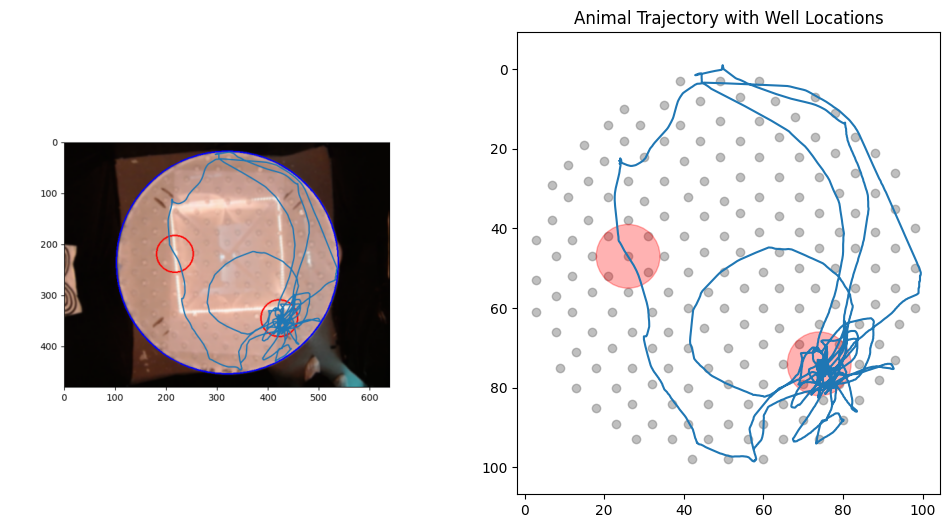

In [236]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(12,6), width_ratios=(1, 1))

axes[0].imshow(img)
axes[0].axis('off')

axes[1].plot(position['x'].values, position['y'].values)
axes[1].scatter(cheeseboardMap['x'].values, cheeseboardMap['y'].values, alpha=0.5, color='gray')
for i in range(len(triggerLoc)):
    x = triggerLoc['x'][i]
    y = triggerLoc['y'][i]
    circle = plt.Circle((x, y), 8, color='r', fill=True, linestyle='-', alpha=0.3)
    axes[1].add_artist(circle)
# Equalize axis scales
axes[1].axis('equal')
# axes[1].axis('off')
# Flip the y-axis to match the coordinate system
axes[1].invert_yaxis()
axes[1].set_title('Animal Trajectory with Well Locations')

In [238]:
triggerLoc

,well_row,well_col,x,y
0,J,3,26,47
1,Q,8,74,74


In [237]:
position_ = add_dist_to_trigger(position, triggerLoc)
trigger_num = len(triggerLoc)
dfs = []
for i in range(trigger_num):
    df_trigger_interaction = get_interaction_with_trigger_df(position_, 8, ti = i+1)
    df_trigger_interaction["trigger_id"] = i + 1
    dfs.append(df_trigger_interaction)
df_all_triggers = pd.concat(dfs, ignore_index=True)
df_all_triggers

,t_enter,t_exit,duration,trigger_id
0,160470,161746,1276,1
1,2017,7183,5166,2
2,8962,14420,5458,2
3,18488,23541,5053,2
4,23672,25425,1753,2
5,28682,31495,2813,2
6,33670,60280,26610,2
7,63489,80872,17383,2
8,82751,86006,3255,2
9,87337,89477,2140,2


In [224]:
metadata

,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,gender,genotype,test_order,remapping,short_duration,LFP,animal_note
0,1,A,20241205,1,1,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
1,1,A,20241205,1,2,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
2,1,A,20241205,1,3,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
3,1,A,20241205,1,4,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
4,1,A,20241205,1,5,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7251,97,F8,20260503,8,6,L,5,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN
7252,97,F8,20260503,8,7,L,5,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN
7253,97,F8,20260503,8,8,L,5,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN
7254,97,F8,20260504,9,1,T,1,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN


In [209]:
# ============================================================
# Compute reward-zone visit duration per trial
#
# For:
#   - trigger 1
#   - trigger 2
#   - combined trigger 1 + 2
#
# Adds per-trial summary columns to metadata:
#   visit_duration_mean_trigger1
#   visit_duration_median_trigger1
#   n_visits_trigger1
#   visit_duration_sum_trigger1
#   visit_durations_s_trigger1
#   ... same for trigger2
#
#   visit_duration_mean_trigger1_2
#   visit_duration_median_trigger1_2
#   n_visits_trigger1_2
#   visit_duration_sum_trigger1_2
#   visit_durations_s_trigger1_2
#
# Also creates:
#   visit_duration_df
#
# where each row = one single visit:
#   sub, id, ses, trial_type, trial_type_day, trial_id,
#   metadata_row, trigger_id, visit_n_in_trigger,
#   t_enter, t_exit, duration_ms, duration_s
# ============================================================

import numpy as np
import pandas as pd
from tqdm import tqdm

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
TRIGGERS_TO_USE = [1, 2]
R_TRIGGER = 10 / 1.2          # analysis-space radius

# If True, only include visits with duration >= 2 s
USE_MIN_DURATION_FILTER = False
MIN_DURATION_MS = 2000

# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------
metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# ------------------------------------------------------------
# Output columns in metadata
# ------------------------------------------------------------
for ti in TRIGGERS_TO_USE:
    metadata[f'visit_duration_mean_trigger{ti}'] = np.nan
    metadata[f'visit_duration_median_trigger{ti}'] = np.nan
    metadata[f'visit_duration_sum_trigger{ti}'] = np.nan
    metadata[f'n_visits_trigger{ti}'] = np.nan

    # stores the actual individual visit durations as a Python list
    metadata[f'visit_durations_s_trigger{ti}'] = None

# combined trigger 1 + 2
metadata['visit_duration_mean_trigger1_2'] = np.nan
metadata['visit_duration_median_trigger1_2'] = np.nan
metadata['visit_duration_sum_trigger1_2'] = np.nan
metadata['n_visits_trigger1_2'] = np.nan
metadata['visit_durations_s_trigger1_2'] = None

# Long-format table: one row = one single visit
visit_rows = []

# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------
def get_visit_df(position_, trigger_id, r_trigger):
    """
    Return visit dataframe for one trigger.

    Expected columns from get_interaction_with_trigger_df:
      t_enter, t_exit, duration

    duration is assumed to be in ms.
    """

    df_trigger_interaction = get_interaction_with_trigger_df(
        position_,
        r_trigger,
        ti=trigger_id
    )

    if df_trigger_interaction is None or len(df_trigger_interaction) == 0:
        return pd.DataFrame()

    df_trigger_interaction = df_trigger_interaction.copy()

    if USE_MIN_DURATION_FILTER:
        df_trigger_interaction = df_trigger_interaction[
            df_trigger_interaction['duration'] >= MIN_DURATION_MS
        ].copy()

    if len(df_trigger_interaction) == 0:
        return pd.DataFrame()

    df_trigger_interaction = (
        df_trigger_interaction
        .sort_values('t_enter')
        .reset_index(drop=True)
    )

    df_trigger_interaction['trigger_id'] = trigger_id
    df_trigger_interaction['visit_n_in_trigger'] = np.arange(1, len(df_trigger_interaction) + 1)

    df_trigger_interaction['duration_ms'] = df_trigger_interaction['duration'].astype(float)
    df_trigger_interaction['duration_s'] = df_trigger_interaction['duration_ms'] / 1000.0

    return df_trigger_interaction


def store_summary(metadata, trial_id, trigger_label, durations_s):
    """
    Store mean, median, sum, n, and individual durations into metadata.

    trigger_label examples:
      'trigger1'
      'trigger2'
      'trigger1_2'
    """

    mean_col = f'visit_duration_mean_{trigger_label}'
    median_col = f'visit_duration_median_{trigger_label}'
    sum_col = f'visit_duration_sum_{trigger_label}'
    n_col = f'n_visits_{trigger_label}'
    list_col = f'visit_durations_s_{trigger_label}'

    durations_s = np.asarray(durations_s, dtype=float)
    durations_s = durations_s[np.isfinite(durations_s)]

    if len(durations_s) == 0:
        metadata.at[trial_id, mean_col] = np.nan
        metadata.at[trial_id, median_col] = np.nan
        metadata.at[trial_id, sum_col] = 0.0
        metadata.at[trial_id, n_col] = 0
        metadata.at[trial_id, list_col] = []
    else:
        metadata.at[trial_id, mean_col] = float(np.nanmean(durations_s))
        metadata.at[trial_id, median_col] = float(np.nanmedian(durations_s))
        metadata.at[trial_id, sum_col] = float(np.nansum(durations_s))
        metadata.at[trial_id, n_col] = int(len(durations_s))
        metadata.at[trial_id, list_col] = list(durations_s)


# ------------------------------------------------------------
# Main loop
# ------------------------------------------------------------
for trial_id in tqdm(range(len(metadata))):
    row = metadata.iloc[trial_id]
    dl = DataLoader(row)

    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        continue

    position_ = add_dist_to_trigger(position.copy(), triggerLoc)

    combined_durations = []

    # --------------------------------------------------------
    # Individual triggers
    # --------------------------------------------------------
    for ti in TRIGGERS_TO_USE:

        trigger_label = f'trigger{ti}'

        if len(triggerLoc) < ti:
            store_summary(
                metadata=metadata,
                trial_id=trial_id,
                trigger_label=trigger_label,
                durations_s=[]
            )
            continue

        df_visit = get_visit_df(
            position_=position_,
            trigger_id=ti,
            r_trigger=R_TRIGGER
        )

        if len(df_visit) == 0:
            store_summary(
                metadata=metadata,
                trial_id=trial_id,
                trigger_label=trigger_label,
                durations_s=[]
            )
            continue

        durations_s = df_visit['duration_s'].values.astype(float)
        combined_durations.append(durations_s)

        # store per-trigger summary in metadata
        store_summary(
            metadata=metadata,
            trial_id=trial_id,
            trigger_label=trigger_label,
            durations_s=durations_s
        )

        # ----------------------------------------------------
        # Add each single visit to long-format visit_duration_df
        # ----------------------------------------------------
        for _, v in df_visit.iterrows():

            visit_row = {
                'metadata_row': trial_id,

                'sub': row['sub'] if 'sub' in metadata.columns else np.nan,
                'id': row['id'] if 'id' in metadata.columns else np.nan,
                'genotype': row['genotype'] if 'genotype' in metadata.columns else np.nan,
                'ses': row['ses'] if 'ses' in metadata.columns else np.nan,
                'trial_type': row['trial_type'] if 'trial_type' in metadata.columns else np.nan,
                'trial_type_day': row['trial_type_day'] if 'trial_type_day' in metadata.columns else np.nan,
                'trial_id': row['trial_id'] if 'trial_id' in metadata.columns else np.nan,
                'date': row['date'] if 'date' in metadata.columns else np.nan,

                'trigger_id': int(v['trigger_id']),
                'visit_n_in_trigger': int(v['visit_n_in_trigger']),

                't_enter': float(v['t_enter']) if np.isfinite(v['t_enter']) else np.nan,
                't_exit': float(v['t_exit']) if np.isfinite(v['t_exit']) else np.nan,
                'duration_ms': float(v['duration_ms']) if np.isfinite(v['duration_ms']) else np.nan,
                'duration_s': float(v['duration_s']) if np.isfinite(v['duration_s']) else np.nan,
            }

            visit_rows.append(visit_row)

    # --------------------------------------------------------
    # Combined trigger 1 + 2
    # This pools all individual visits into trigger 1 and trigger 2,
    # then computes mean/median/sum across pooled visits.
    # --------------------------------------------------------
    if len(combined_durations) == 0:
        combined_durations_s = np.array([])
    else:
        combined_durations_s = np.concatenate(combined_durations)
        combined_durations_s = combined_durations_s[np.isfinite(combined_durations_s)]

    store_summary(
        metadata=metadata,
        trial_id=trial_id,
        trigger_label='trigger1_2',
        durations_s=combined_durations_s
    )

# ------------------------------------------------------------
# Create long-format visit dataframe
# ------------------------------------------------------------
visit_duration_df = pd.DataFrame(visit_rows)

if len(visit_duration_df) > 0:
    visit_duration_df = (
        visit_duration_df
        .sort_values([
            'id',
            'ses',
            'trial_id',
            'trigger_id',
            't_enter'
        ])
        .reset_index(drop=True)
    )

# ------------------------------------------------------------
# Check output: per-trial summaries
# ------------------------------------------------------------
summary_cols = [
    'sub', 'id', 'ses', 'trial_type', 'trial_type_day',
    'visit_duration_mean_trigger1',
    'visit_duration_median_trigger1',
    'visit_duration_sum_trigger1',
    'n_visits_trigger1',
    'visit_durations_s_trigger1',

    'visit_duration_mean_trigger2',
    'visit_duration_median_trigger2',
    'visit_duration_sum_trigger2',
    'n_visits_trigger2',
    'visit_durations_s_trigger2',

    'visit_duration_mean_trigger1_2',
    'visit_duration_median_trigger1_2',
    'visit_duration_sum_trigger1_2',
    'n_visits_trigger1_2',
    'visit_durations_s_trigger1_2',
]

summary_cols = [c for c in summary_cols if c in metadata.columns]

print("\nPer-trial summary columns:")
display(metadata[summary_cols].head())

# ------------------------------------------------------------
# Check output: single-visit table
# ------------------------------------------------------------
print("\nSingle-visit long-format dataframe:")
print(f"visit_duration_df rows = {len(visit_duration_df)}")

if len(visit_duration_df) > 0:
    display(visit_duration_df.head(20))
else:
    print("No visits found.")

 10%|▉         | 644/6611 [00:08<01:16, 77.96it/s]


KeyboardInterrupt: 

Using duration column: visit_duration_mean_trigger1_2
Using visit-count column: n_visits_trigger1_2

Groups used for Plot 1: ['ChR2_short', 'CA1', 'CA3', 'Control']
Original genotypes loaded: ['CA1', 'CA1_control', 'CA3', 'ChR2_short', 'NAc_control']
Control pooled from: ['NAc_control', 'CA1_control']

Plot 1 animals:
  VTA short (ChR2_short): n = 8, ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  CA1 (CA1): n = 7, ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA3 (CA3): n = 7, ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
  Control (Control): n = 6, ids = ['C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']


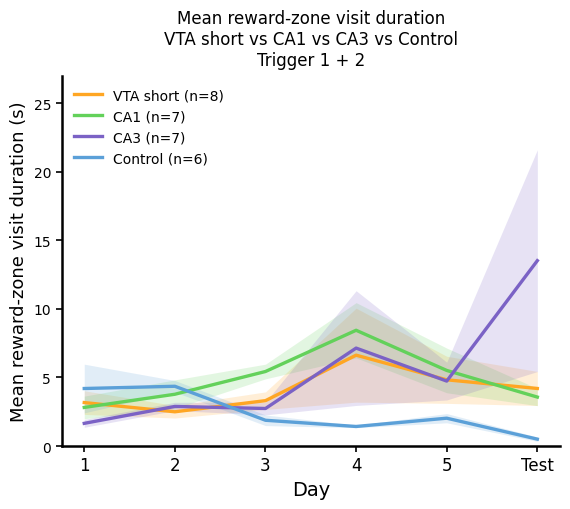


Paired plots for NAc
Day 1 vs Day 5: n = 0, Wilcoxon p = NaN
Day 1 vs Test: n = 0, Wilcoxon p = NaN


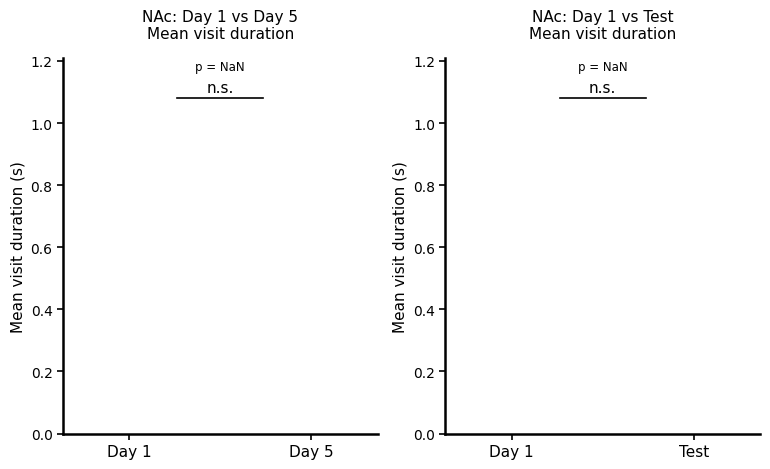

In [183]:
# Plot mean/median reward-zone visit duration across days
# Choose trigger 1, trigger 2, or combined trigger 1+2
# Plot 1: group comparison
# Plot 2: optional paired comparison within one selected group
#
# Adds pooled control group:
#   'Control' = eYFP_ChR2 + NAc_control + CA1_control
#
# You can now use:
#   GROUPS = ['ChR2', 'NAc', 'Control']
#   GROUPS = ['ChR2', 'CA1', 'CA3', 'Control']
#   GROUPS = ['eYFP_ChR2', 'CA1_control', 'NAc_control']
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# ============================================================
# OPTIONS
# ============================================================

# -----------------------------
# Choose trigger metric
# -----------------------------
TRIGGER_MODE = '1_2'   # '1', '2', or '1_2'
# TRIGGER_MODE = '1'
# TRIGGER_MODE = '2'

USE_MEDIAN = False     # True -> median duration ; False -> mean duration

# Only used when USE_MEDIAN = True:
# 'trial_then_average' = use trial-level median column, then average trials within animal/day
# 'pooled_per_day'     = pool all visits across that animal/day, then take one median
MEDIAN_MODE = 'pooled_per_day'

# groups for Plot 1
GROUPS = ['ChR2_short', 'CA1', 'CA3', 'Control']
# GROUPS = ['ChR2', 'Control']
# GROUPS = ['ChR2', 'NAc', 'Control']
# GROUPS = ['ChR2', 'CA1', 'CA3', 'Control']

# These original genotypes will be pooled into genotype == 'Control'
POOLED_CONTROL_ORIGINAL_GROUPS = ['NAc_control', 'CA1_control']

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'CA1': 'CA1',
    'CA3': 'CA3',
    'NAc': 'NAc',
    'CA1_control': 'CA1 control',
    'NAc_control': 'NAc control',
    'Control': 'Control',
}

EXCLUDE_ID = ['AS', 'AN']

PLOT1_SHOW_INDIVIDUAL = False
PLOT1_SHOW_GROUP_MEAN = True
PLOT1_SHOW_SEM_ERRORBAR = False

SHOW_ANIMAL_IDS_PLOT1 = False
DAY1_LABEL_X_OFFSET = 0.00
DAY1_LABEL_Y_OFFSET = 0.00
DAY1_LABEL_FONTSIZE = 8

# Plot 2 options
RUN_PAIRED_PLOTS = True
PAIRED_GROUP = 'NAc'
# PAIRED_GROUP = 'Control'
SHOW_ANIMAL_IDS_PLOT2 = False

PAIR_LABEL_X_OFFSET = 0.03
PAIR_LABEL_Y_OFFSET = 0.00
PAIR_LABEL_FONTSIZE = 7

# If True, animals are only plotted in Plot 1 if they have all L1-L5 + Test.
# If False, missing days remain NaN and animal is still included if it has at least one valid day.
REQUIRE_COMPLETE_DAYS = False

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

# ============================================================
# Metric selection
# ============================================================
if TRIGGER_MODE not in ['1', '2', '1_2']:
    raise ValueError("TRIGGER_MODE must be '1', '2', or '1_2'")

if USE_MEDIAN:
    VALUE_COL = f'visit_duration_median_trigger{TRIGGER_MODE}'
    VALUE_NAME = 'Median'
else:
    VALUE_COL = f'visit_duration_mean_trigger{TRIGGER_MODE}'
    VALUE_NAME = 'Mean'

N_VISITS_COL = f'n_visits_trigger{TRIGGER_MODE}'

# For pooled daily median, we reconstruct visit durations from the stored per-trial data.
# For trigger 1+2, this uses both trigger 1 and trigger 2.
TRIGGERS_FOR_POOLED = [1, 2] if TRIGGER_MODE == '1_2' else [int(TRIGGER_MODE)]

print("Using duration column:", VALUE_COL)
print("Using visit-count column:", N_VISITS_COL)

# ============================================================
# Fixed animal colours for paired plot only
# ============================================================
def get_nature_palette(n):
    palette = [
        '#4E79A7', '#E15759', '#59A14F', '#F28E2B',
        '#B07AA1', '#76B7B2', '#EDC948', '#FF9DA7',
        '#9C755F', '#BAB0AC', '#86BCB6', '#D37295',
        '#8CD17D', '#F1CE63', '#499894', '#E17C05',
    ]
    return [palette[i % len(palette)] for i in range(n)]


def normalize_sub_id(x):
    if pd.isna(x):
        return 'NA'
    if isinstance(x, (int, np.integer)):
        return str(int(x))
    if isinstance(x, (float, np.floating)):
        if float(x).is_integer():
            return str(int(x))
        return str(x)
    return str(x)


def make_animal_color_map(sub_ids):
    sub_ids_sorted = sorted({normalize_sub_id(s) for s in sub_ids})
    palette = get_nature_palette(len(sub_ids_sorted))
    return {sub: palette[i] for i, sub in enumerate(sub_ids_sorted)}


# ============================================================
# Helpers
# ============================================================
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', length=4, width=1.2)
    ax.grid(False)


def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def run_wilcoxon(a, b):
    if len(a) == 0:
        return np.nan, np.nan
    try:
        stat, p = wilcoxon(a, b, alternative='two-sided')
    except ValueError:
        stat, p = np.nan, np.nan
    return stat, p


def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem


def get_animal_label(ms, sub):
    """
    Keeps original group visible for pooled Control animals.
    Example:
      A1 (eYFP_ChR2)
      N8 (NAc_control)
      X3 (CA1_control)
    """
    if 'id' in ms.columns and ms['id'].notna().any():
        animal_id = str(ms['id'].dropna().iloc[0])
    else:
        animal_id = str(sub)

    if 'genotype_original' in ms.columns and ms['genotype'].iloc[0] == 'Control':
        original = str(ms['genotype_original'].dropna().iloc[0])
        return f'{animal_id} ({original})'

    return animal_id


# ============================================================
# 1) Filter metadata + create pooled Control
# ============================================================

# If GROUPS contains 'Control', load its original component genotypes.
groups_to_load = []
for g in GROUPS:
    if g == 'Control':
        groups_to_load.extend(POOLED_CONTROL_ORIGINAL_GROUPS)
    else:
        groups_to_load.append(g)

# If paired plot uses Control but Control is not in GROUPS, also load controls.
if RUN_PAIRED_PLOTS and PAIRED_GROUP == 'Control' and 'Control' not in GROUPS:
    groups_to_load.extend(POOLED_CONTROL_ORIGINAL_GROUPS)

groups_to_load = sorted(set(groups_to_load))

meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(groups_to_load)) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Store original genotype before pooling
meta_LT['genotype_original'] = meta_LT['genotype']

# Pool eYFP_ChR2 + NAc_control + CA1_control into one displayed/statistical group: Control
if ('Control' in GROUPS) or (RUN_PAIRED_PLOTS and PAIRED_GROUP == 'Control'):
    meta_LT.loc[
        meta_LT['genotype_original'].isin(POOLED_CONTROL_ORIGINAL_GROUPS),
        'genotype'
    ] = 'Control'

print("\nGroups used for Plot 1:", GROUPS)
print("Original genotypes loaded:", groups_to_load)
if ('Control' in GROUPS) or (RUN_PAIRED_PLOTS and PAIRED_GROUP == 'Control'):
    print("Control pooled from:", POOLED_CONTROL_ORIGINAL_GROUPS)

# exclude animal IDs
if len(EXCLUDE_ID) > 0:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

# keep rows usable for selected mode
if VALUE_COL not in meta_LT.columns:
    raise ValueError(
        f"{VALUE_COL} does not exist in metadata. "
        f"Run the computation code for trigger {TRIGGER_MODE} first."
    )

if not USE_MEDIAN:
    meta_LT = meta_LT[meta_LT[VALUE_COL].notna()].copy()
else:
    if MEDIAN_MODE == 'trial_then_average':
        meta_LT = meta_LT[meta_LT[VALUE_COL].notna()].copy()
    elif MEDIAN_MODE == 'pooled_per_day':
        # pooled_per_day can reconstruct from raw visits,
        # but still keep rows with usable trials.
        pass
    else:
        raise ValueError("MEDIAN_MODE must be 'trial_then_average' or 'pooled_per_day'")

# ------------------------------------------------------------
# Assign plot_day
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ============================================================
# 2) Build animal-day values
# ============================================================
def get_trial_visit_durations_seconds(meta_row, trigger_to_use, r_trigger):
    dl = DataLoader(meta_row)

    position = dl.get_data('position')
    if position is None or len(position) == 0:
        return np.array([])

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) < trigger_to_use:
        return np.array([])

    position_ = add_dist_to_trigger(position.copy(), triggerLoc)

    df_trigger_interaction = get_interaction_with_trigger_df(
        position_,
        r_trigger,
        ti=trigger_to_use
    )

    if df_trigger_interaction is None or len(df_trigger_interaction) == 0:
        return np.array([])

    if USE_MIN_DURATION_FILTER:
        df_trigger_interaction = df_trigger_interaction[
            df_trigger_interaction['duration'] >= MIN_DURATION_MS
        ].copy()

    if len(df_trigger_interaction) == 0:
        return np.array([])

    durations_s = df_trigger_interaction['duration'].values.astype(float) / 1000.0
    durations_s = durations_s[np.isfinite(durations_s)]

    return durations_s


def get_trial_visit_durations_seconds_for_mode(meta_row):
    pooled = []

    for ti in TRIGGERS_FOR_POOLED:
        durs = get_trial_visit_durations_seconds(
            meta_row,
            trigger_to_use=ti,
            r_trigger=R_TRIGGER
        )

        if len(durs) > 0:
            pooled.append(durs)

    if len(pooled) == 0:
        return np.array([])

    pooled = np.concatenate(pooled)
    pooled = pooled[np.isfinite(pooled)]

    return pooled


def per_subject_day_value(meta_g, day):
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'value'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        animal_id = get_animal_label(ms, sub)

        # -----------------------------
        # Mean mode:
        # use selected per-trial mean column,
        # then average trials within animal/day
        # -----------------------------
        if not USE_MEDIAN:
            vals = ms[VALUE_COL].values.astype(float)
            vals = vals[np.isfinite(vals)]

            if len(vals) == 0:
                continue

            rows.append({
                'sub': sub,
                'id': animal_id,
                'value': float(np.nanmean(vals))
            })
            continue

        # -----------------------------
        # Median mode: trial median then average
        # -----------------------------
        if MEDIAN_MODE == 'trial_then_average':
            vals = ms[VALUE_COL].values.astype(float)
            vals = vals[np.isfinite(vals)]

            if len(vals) == 0:
                continue

            rows.append({
                'sub': sub,
                'id': animal_id,
                'value': float(np.nanmean(vals))
            })
            continue

        # -----------------------------
        # Median mode: pooled visits per animal/day
        # -----------------------------
        if MEDIAN_MODE == 'pooled_per_day':
            pooled = []

            for _, row in ms.iterrows():
                durs = get_trial_visit_durations_seconds_for_mode(row)
                if len(durs) > 0:
                    pooled.append(durs)

            if len(pooled) == 0:
                continue

            pooled = np.concatenate(pooled)
            pooled = pooled[np.isfinite(pooled)]

            if len(pooled) == 0:
                continue

            rows.append({
                'sub': sub,
                'id': animal_id,
                'value': float(np.nanmedian(pooled))
            })
            continue

        raise ValueError("MEDIAN_MODE must be 'trial_then_average' or 'pooled_per_day'")

    return pd.DataFrame(rows)


def build_group_matrix(meta_g):
    rows = []
    subs = []
    ids = []

    for sub in meta_g['sub'].unique():
        vals = []
        animal_id = None

        for d in plot_days:
            df_day = per_subject_day_value(meta_g[meta_g['sub'] == sub], d)

            if len(df_day) == 0:
                vals.append(np.nan)
            else:
                vals.append(float(df_day.iloc[0]['value']))
                animal_id = df_day.iloc[0]['id']

        vals = np.array(vals, dtype=float)

        if REQUIRE_COMPLETE_DAYS and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        if animal_id is None:
            ms = meta_g[meta_g['sub'] == sub]
            animal_id = get_animal_label(ms, sub)

        rows.append(vals)
        subs.append(sub)
        ids.append(animal_id)

    if len(rows) == 0:
        return None, [], []

    return np.vstack(rows), subs, ids


# ============================================================
# 3) Plot 1: group comparison across days
# ============================================================
group_data = {}

print("\nPlot 1 animals:")
for g in GROUPS:
    meta_g = meta_LT[meta_LT['genotype'] == g].copy()
    mat_g, subs_g, ids_g = build_group_matrix(meta_g)

    group_data[g] = {
        'meta': meta_g,
        'mat': mat_g,
        'subs': subs_g,
        'ids': ids_g,
    }

    print(f"  {DISPLAY_NAME.get(g, g)} ({g}): n = {len(subs_g)}, ids = {ids_g}")

fig, ax = plt.subplots(figsize=(5.8, 5.2))

for g in GROUPS:
    mat = group_data[g]['mat']
    subs = group_data[g]['subs']
    ids = group_data[g]['ids']

    if mat is None or len(subs) == 0:
        continue

    col = get_genotype_color(g)
    label = DISPLAY_NAME.get(g, g)

    if PLOT1_SHOW_INDIVIDUAL:
        for i, row in enumerate(mat):
            ax.plot(
                x_vals,
                row,
                '-',
                color=col,
                alpha=0.15,
                linewidth=1.0,
                zorder=1
            )

            if SHOW_ANIMAL_IDS_PLOT1:
                finite_idx = np.where(np.isfinite(row))[0]
                if len(finite_idx) > 0:
                    first_i = finite_idx[0]
                    ax.text(
                        x_vals[first_i] + DAY1_LABEL_X_OFFSET,
                        row[first_i] + DAY1_LABEL_Y_OFFSET,
                        ids[i],
                        fontsize=DAY1_LABEL_FONTSIZE,
                        alpha=0.9,
                        ha='right',
                        va='center',
                        color=col
                    )

    if PLOT1_SHOW_GROUP_MEAN:
        mean_ = np.nanmean(mat, axis=0)
        sem_ = sem_by_day(mat)

        ax.fill_between(
            x_vals,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=0.18,
            linewidth=0,
            zorder=2
        )

        ax.plot(
            x_vals,
            mean_,
            '-',
            color=col,
            linewidth=2.4,
            label=f'{label} (n={len(subs)})',
            zorder=3
        )

        if PLOT1_SHOW_SEM_ERRORBAR:
            ax.errorbar(
                x_vals,
                mean_,
                yerr=sem_,
                fmt='none',
                ecolor=col,
                elinewidth=1.2,
                capsize=3,
                alpha=0.9,
                zorder=4
            )

ax.set_xlabel('Day', fontsize=14)
ax.set_ylabel(f'{VALUE_NAME} reward-zone visit duration (s)', fontsize=13)
ax.set_xticks(np.arange(6))
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)

if TRIGGER_MODE == '1_2':
    title_suffix = 'Trigger 1 + 2'
else:
    title_suffix = f'Trigger {TRIGGER_MODE}'

if USE_MIN_DURATION_FILTER:
    title_suffix += ', visits ≥2 s only'

if USE_MEDIAN:
    title_suffix += ', pooled daily median' if MEDIAN_MODE == 'pooled_per_day' else ', trial median → daily mean'

display_groups = ' vs '.join([DISPLAY_NAME.get(g, g) for g in GROUPS])

ax.set_title(
    f'{VALUE_NAME} reward-zone visit duration\n{display_groups}\n{title_suffix}',
    fontsize=12,
    pad=8
)

style_nature(ax)
ax.legend(frameon=False)

# ------------------------------------------------------------
# Auto y-limit for Plot 1
# Use group mean + SEM, not extreme individual values
# ------------------------------------------------------------
ymax_candidates = []

for g in GROUPS:
    mat = group_data[g]['mat']
    if mat is None:
        continue

    mean_ = np.nanmean(mat, axis=0)
    sem_ = sem_by_day(mat)

    ymax_candidates.append(np.nanmax(mean_ + sem_))

if len(ymax_candidates) > 0:
    ymax = np.nanmax(ymax_candidates)
    if np.isfinite(ymax) and ymax > 0:
        ax.set_ylim(0, ymax * 1.25)

plt.tight_layout()
plt.show()

# ============================================================
# 4) Plot 2: paired dots for one selected group
# ============================================================
if RUN_PAIRED_PLOTS:
    meta_pair = meta_LT[meta_LT['genotype'] == PAIRED_GROUP].copy()

    animal_color_map = make_animal_color_map(meta_pair['sub'].unique())

    def get_day_df(day):
        df = per_subject_day_value(meta_pair, day)
        colname = f'day{day}' if day != 6 else 'test'
        return df.rename(columns={'value': colname})

    d1 = get_day_df(1).rename(columns={'day1': 'day1'})
    d5 = get_day_df(5).rename(columns={'day5': 'day5'})
    dt = get_day_df(6).rename(columns={'test': 'test'})

    pair_15 = (
        d1.merge(d5, on=['sub', 'id'], how='inner')
          .dropna()
          .sort_values('sub')
          .reset_index(drop=True)
    )

    pair_1t = (
        d1.merge(dt, on=['sub', 'id'], how='inner')
          .dropna()
          .sort_values('sub')
          .reset_index(drop=True)
    )

    _, p_15 = run_wilcoxon(
        pair_15['day1'].values.astype(float),
        pair_15['day5'].values.astype(float)
    )

    _, p_1t = run_wilcoxon(
        pair_1t['day1'].values.astype(float),
        pair_1t['test'].values.astype(float)
    )

    print(f"\nPaired plots for {DISPLAY_NAME.get(PAIRED_GROUP, PAIRED_GROUP)}")
    print(
        f"Day 1 vs Day 5: n = {len(pair_15)}, Wilcoxon p = {p_15:.3g}"
        if np.isfinite(p_15)
        else f"Day 1 vs Day 5: n = {len(pair_15)}, Wilcoxon p = NaN"
    )
    print(
        f"Day 1 vs Test: n = {len(pair_1t)}, Wilcoxon p = {p_1t:.3g}"
        if np.isfinite(p_1t)
        else f"Day 1 vs Test: n = {len(pair_1t)}, Wilcoxon p = NaN"
    )

    def draw_paired_panel(ax, df_pair, col1, col2, label1, label2, pval, title):
        x1, x2 = 0.00, 0.55

        for _, row in df_pair.iterrows():
            sub_norm = normalize_sub_id(row['sub'])
            col = animal_color_map[sub_norm]

            ax.plot(
                [x1, x2],
                [row[col1], row[col2]],
                color=col,
                linewidth=1.2,
                alpha=0.95,
                zorder=1
            )

            ax.scatter(
                [x1, x2],
                [row[col1], row[col2]],
                s=34,
                color=col,
                edgecolor='none',
                alpha=0.95,
                zorder=2
            )

            if SHOW_ANIMAL_IDS_PLOT2:
                ax.text(
                    x2 + PAIR_LABEL_X_OFFSET,
                    row[col2] + PAIR_LABEL_Y_OFFSET,
                    str(row['id']),
                    fontsize=PAIR_LABEL_FONTSIZE,
                    alpha=0.9,
                    va='center',
                    ha='left',
                    color=col
                )

        y1 = df_pair[col1].values.astype(float)
        y2 = df_pair[col2].values.astype(float)

        ymax = np.nanmax(np.r_[y1, y2]) if len(df_pair) > 0 else 1
        yrng = max(ymax, 0.2)

        yline = ymax + 0.08 * yrng
        ystar = ymax + 0.09 * yrng
        yp = ymax + 0.16 * yrng

        xmid = (x1 + x2) / 2
        half_len = 0.13

        ax.plot(
            [xmid - half_len, xmid + half_len],
            [yline, yline],
            color='k',
            lw=1.2,
            zorder=5
        )

        ax.text(
            xmid,
            ystar,
            p_to_stars(pval),
            ha='center',
            va='bottom',
            fontsize=11,
            zorder=6
        )

        ax.text(
            xmid,
            yp,
            f'p = {pval:.3g}' if np.isfinite(pval) else 'p = NaN',
            ha='center',
            va='bottom',
            fontsize=8.5,
            zorder=6
        )

        ax.set_xticks([x1, x2])
        ax.set_xticklabels([label1, label2], fontsize=11)
        ax.set_ylabel(f'{VALUE_NAME} visit duration (s)', fontsize=11)
        ax.set_title(title, fontsize=11, pad=14)
        ax.set_xlim(-0.20, 0.95 if SHOW_ANIMAL_IDS_PLOT2 else 0.75)
        ax.set_ylim(0, max(1.0, yp + 0.05))
        style_nature(ax)

    fig, axes = plt.subplots(1, 2, figsize=(7.8, 4.8), sharey=False)

    title_extra = ''
    if USE_MEDIAN:
        title_extra = (
            '\npooled daily median'
            if MEDIAN_MODE == 'pooled_per_day'
            else '\ntrial median → daily mean'
        )

    paired_display = DISPLAY_NAME.get(PAIRED_GROUP, PAIRED_GROUP)

    draw_paired_panel(
        axes[0],
        pair_15,
        'day1',
        'day5',
        'Day 1',
        'Day 5',
        p_15,
        f'{paired_display}: Day 1 vs Day 5\n{VALUE_NAME} visit duration{title_extra}'
    )

    draw_paired_panel(
        axes[1],
        pair_1t,
        'day1',
        'test',
        'Day 1',
        'Test',
        p_1t,
        f'{paired_display}: Day 1 vs Test\n{VALUE_NAME} visit duration{title_extra}'
    )

    plt.tight_layout()
    plt.show()


Single-visit duration distribution
Group: CA3 (CA3)
Trigger mode: 2 = trigger 2
Y mode: animal_average_percent
Bin width: 0.5 s

Eligible animals per day:

  L1: n animals = 7
 sub id
  71 C1
  72 C2
  73 C3
  74 C4
  75 C5
  76 C6
  77 C7

  L2: n animals = 7
 sub id
  71 C1
  72 C2
  73 C3
  74 C4
  75 C5
  76 C6
  77 C7

  L3: n animals = 7
 sub id
  71 C1
  72 C2
  73 C3
  74 C4
  75 C5
  76 C6
  77 C7

  L4: n animals = 7
 sub id
  71 C1
  72 C2
  73 C3
  74 C4
  75 C5
  76 C6
  77 C7

  L5: n animals = 7
 sub id
  71 C1
  72 C2
  73 C3
  74 C4
  75 C5
  76 C6
  77 C7

  Test: n animals = 7
 sub id
  71 C1
  72 C2
  73 C3
  74 C4
  75 C5
  76 C6
  77 C7

Visits available after filtering:
  L1: n visits = 107, n animals with visits = 7
  L2: n visits = 105, n animals with visits = 7
  L3: n visits = 107, n animals with visits = 7
  L4: n visits = 101, n animals with visits = 7
  L5: n visits = 109, n animals with visits = 7
  Test: n visits = 19, n animals with visits = 7


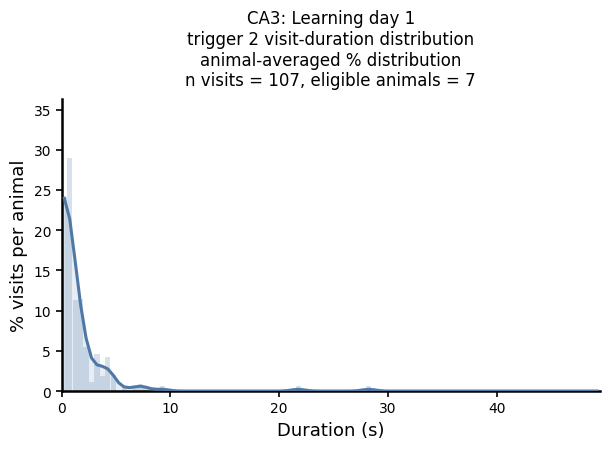

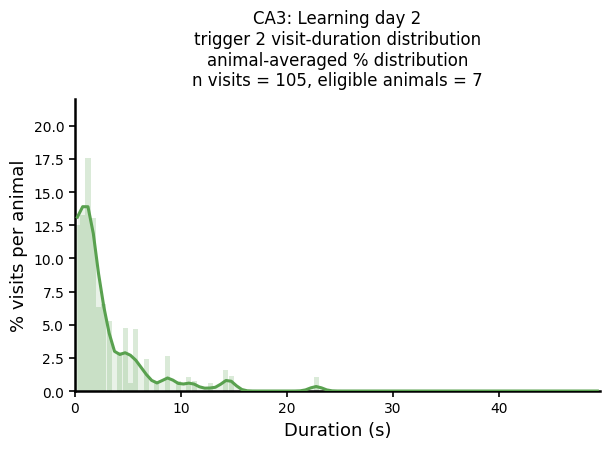

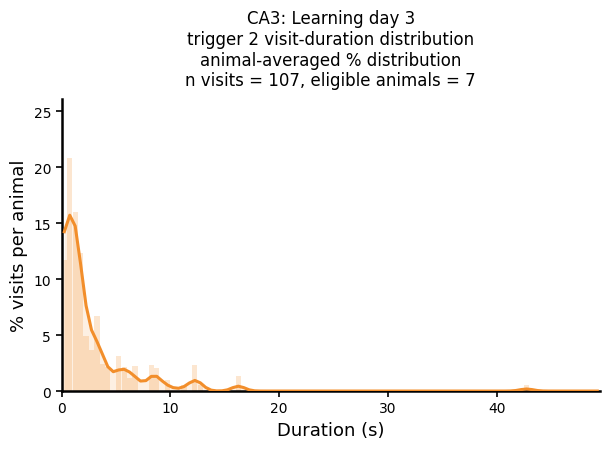

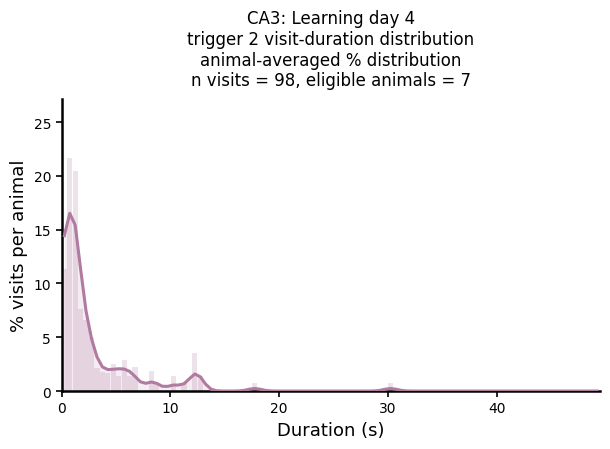

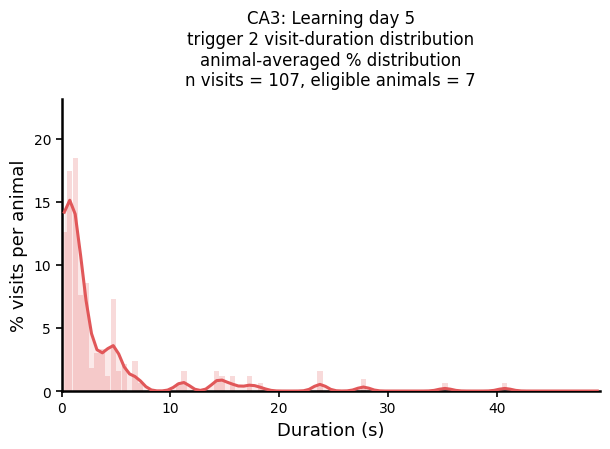

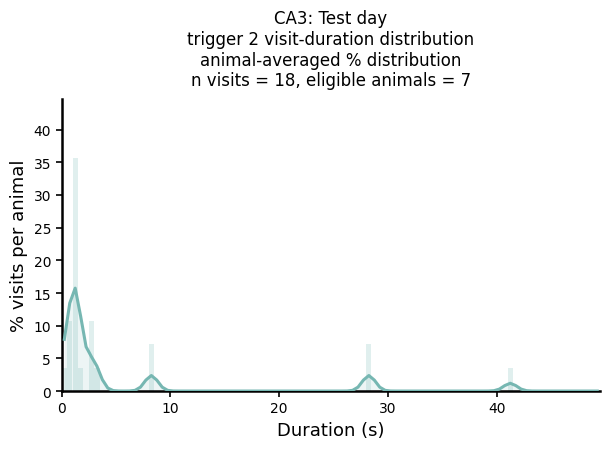

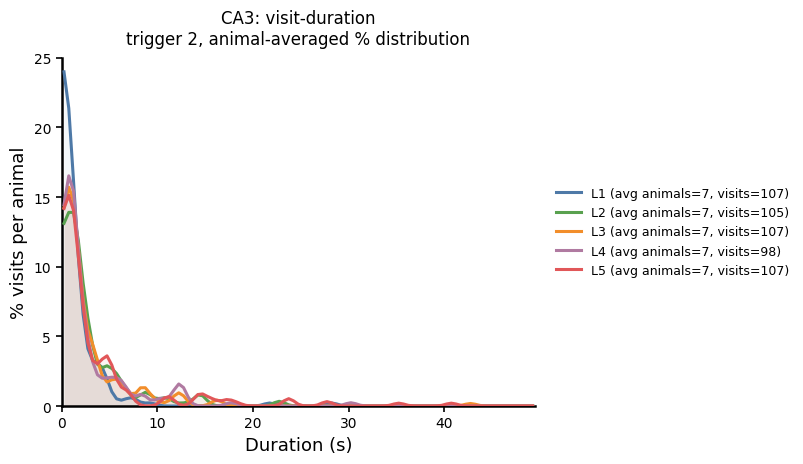


Visits used for plotting:


,sub,id,genotype,plot_day,ses,trial_type,trial_type_day,trial_id,trigger_id,visit_n_in_trigger,duration_s,t_enter,t_exit
0,71,C1,CA3,1.0,4,L,1,2,2,1,0.714,3986.0,4700.0
1,71,C1,CA3,1.0,4,L,1,2,2,2,1.962,122291.0,124253.0
2,71,C1,CA3,1.0,4,L,1,3,2,1,2.292,28604.0,30896.0
3,71,C1,CA3,1.0,4,L,1,3,2,2,0.242,41644.0,41886.0
4,71,C1,CA3,1.0,4,L,1,3,2,3,0.634,91368.0,92002.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,75,C5,CA3,1.0,4,L,1,7,2,1,0.856,131564.0,132420.0
76,76,C6,CA3,1.0,4,L,1,1,2,1,0.562,82579.0,83141.0
77,76,C6,CA3,1.0,4,L,1,1,2,2,1.243,117213.0,118456.0
78,76,C6,CA3,1.0,4,L,1,1,2,3,0.460,162919.0,163379.0


In [175]:
# ============================================================
# Distribution of single reward-zone visit durations
#
# Requires:
#   visit_duration_df
#
# where each row = one single visit, with columns like:
#   metadata_row
#   sub
#   id
#   genotype
#   ses
#   trial_type
#   trial_type_day
#   trial_id
#   trigger_id
#   duration_s
#
# Produces:
#   1) One figure per learning day 1-5 + Test
#      Each figure = one day-level distribution
#
#   2) One combined figure overlaying learning days 1-5
#      to show how visit-duration distribution changes across learning
#
# Y modes:
#   'pooled_visits_percent'
#       Pool all visits from all animals/trials within a day.
#       Convert bin counts to % of all visits that day.
#       Animals with more visits contribute more.
#
#   'animal_average_percent'
#       For each animal, compute its own % histogram for that day.
#       Then average those animal-level % histograms.
#       Each animal contributes equally.
#       Better for comparing genotype groups with different n animals.
#
#   'pooled_visits_count'
#       Raw visit counts pooled from all animals/trials.
#
#   'animal_average_count'
#       Mean number of visits per animal per bin.
#
# Options:
#   TRIGGER_MODE = '1_2', '1', or '2'
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ============================================================
# OPTIONS
# ============================================================

# -----------------------------
# Genotype/group to plot
# -----------------------------
GENOTYPE_TO_PLOT = 'CA3'
# GENOTYPE_TO_PLOT = 'ChR2_short'
# GENOTYPE_TO_PLOT = 'eYFP_ChR2'
# GENOTYPE_TO_PLOT = 'NAc'
# GENOTYPE_TO_PLOT = 'CA1'
# GENOTYPE_TO_PLOT = 'CA3'
# GENOTYPE_TO_PLOT = 'Control'

# -----------------------------
# Trigger selection
# -----------------------------
TRIGGER_MODE = '2'   # '1', '2', or '1_2'
# TRIGGER_MODE = '1'
# TRIGGER_MODE = '1_2'

# -----------------------------
# Y-axis / averaging mode
# -----------------------------
Y_MODE = 'animal_average_percent'
# Y_MODE = 'pooled_visits_percent'
# Y_MODE = 'pooled_visits_count'
# Y_MODE = 'animal_average_count'

# For animal_average_percent:
#   True:
#       animals with eligible trials but zero visits contribute a zero histogram.
#       This reflects "no reward-zone visits".
#
#   False:
#       animals with zero visits are excluded from the average.
#       This describes visit durations only among animals that actually visited.
INCLUDE_ZERO_VISIT_ANIMALS_IN_AVERAGE = True

# -----------------------------
# Histogram / smoothing
# -----------------------------
BIN_WIDTH_S = 0.5

# Set manually, or None to auto from percentile
XMAX_S = None
AUTO_XMAX_PERCENTILE = 99

SMOOTH_SIGMA_BINS = 1.2

# If True, show faint histogram bars underneath smoothed line
SHOW_BARS = True

# If True, fill under smoothed curve
SHOW_SMOOTH_FILL = True

# -----------------------------
# Animals / trials
# -----------------------------
EXCLUDE_ID = ['AN', 'AS']
EXCLUDE_SUBS = []

REQUIRE_USABLE = True

# If True, exclude short-duration trials if column exists
FILTER_SHORT_DURATION = False

# -----------------------------
# Plot appearance
# -----------------------------
FIGSIZE_SINGLE = (6.2, 4.6)
FIGSIZE_COMBINED = (10, 5.0)

BAR_ALPHA = 0.22
LINE_WIDTH = 2.2
FILL_ALPHA = 0.13

YMIN = 0
YMAX_SINGLE = None
YMAX_COMBINED = 25

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

POOLED_CONTROL_ORIGINAL_GROUPS = ['eYFP_ChR2', 'NAc_control', 'CA1_control']

day_labels = {
    1: 'Learning day 1',
    2: 'Learning day 2',
    3: 'Learning day 3',
    4: 'Learning day 4',
    5: 'Learning day 5',
    6: 'Test day',
}

short_day_labels = {
    1: 'L1',
    2: 'L2',
    3: 'L3',
    4: 'L4',
    5: 'L5',
    6: 'Test',
}

# ============================================================
# Colour helpers
# ============================================================

def get_nature_day_palette():
    """
    Muted journal-style colours for learning days.
    """
    return {
        1: '#4E79A7',  # blue
        2: '#59A14F',  # green
        3: '#F28E2B',  # orange
        4: '#B07AA1',  # purple
        5: '#E15759',  # red
        6: '#76B7B2',  # teal
    }


DAY_COLORS = get_nature_day_palette()


def style_nature(ax, linewidth=1.8):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.2)
    ax.grid(False)


def get_group_display_name(g):
    return DISPLAY_NAME.get(g, g)


# ============================================================
# Trigger mode
# ============================================================

if TRIGGER_MODE not in ['1', '2', '1_2']:
    raise ValueError("TRIGGER_MODE must be '1', '2', or '1_2'")

if TRIGGER_MODE == '1':
    TRIGGERS_TO_KEEP = [1]
    TRIGGER_LABEL = 'trigger 1'
elif TRIGGER_MODE == '2':
    TRIGGERS_TO_KEEP = [2]
    TRIGGER_LABEL = 'trigger 2'
else:
    TRIGGERS_TO_KEEP = [1, 2]
    TRIGGER_LABEL = 'trigger 1 + 2'


valid_y_modes = [
    'pooled_visits_percent',
    'animal_average_percent',
    'pooled_visits_count',
    'animal_average_count',
]

if Y_MODE not in valid_y_modes:
    raise ValueError(f"Y_MODE must be one of {valid_y_modes}")

if Y_MODE == 'pooled_visits_percent':
    YLABEL = '% of all pooled visits'
    MODE_LABEL = 'pooled visits, % of visits'
elif Y_MODE == 'animal_average_percent':
    YLABEL = '% visits per animal'
    MODE_LABEL = 'animal-averaged % distribution'
elif Y_MODE == 'pooled_visits_count':
    YLABEL = 'Number of visits'
    MODE_LABEL = 'pooled visit counts'
elif Y_MODE == 'animal_average_count':
    YLABEL = 'Mean number of visits per animal'
    MODE_LABEL = 'animal-averaged visit counts'


# ============================================================
# Check required inputs
# ============================================================

if 'visit_duration_df' not in globals():
    raise NameError(
        "visit_duration_df does not exist. "
        "Run the single-visit duration computation code first."
    )

required_visit_cols = [
    'metadata_row',
    'sub',
    'id',
    'genotype',
    'ses',
    'trial_type',
    'trial_type_day',
    'trigger_id',
    'duration_s',
]

missing_visit_cols = [c for c in required_visit_cols if c not in visit_duration_df.columns]
if len(missing_visit_cols) > 0:
    raise KeyError(f"Missing columns in visit_duration_df: {missing_visit_cols}")

required_meta_cols = [
    'usable',
    'genotype',
    'trial_type',
    'trial_type_day',
    'ses',
    'sub',
]

missing_meta_cols = [c for c in required_meta_cols if c not in metadata.columns]
if len(missing_meta_cols) > 0:
    raise KeyError(f"Missing columns in metadata: {missing_meta_cols}")


# ============================================================
# 1) Prepare metadata: assign learning days + test day
# ============================================================

def assign_learning_and_test_days(meta_df):
    """
    Assign:
      L trial_type_day 1-5 -> plot_day 1-5
      first T session after last L session -> plot_day 6
    """
    meta_df = meta_df.copy()
    meta_df['plot_day'] = np.nan

    mask_L = meta_df['trial_type'] == 'L'
    meta_df.loc[mask_L, 'plot_day'] = meta_df.loc[mask_L, 'trial_type_day']

    # keep learning days 1-5 only
    meta_df = meta_df[
        (~mask_L) | (meta_df['trial_type_day'].isin([1, 2, 3, 4, 5]))
    ].copy()

    for sub in meta_df['sub'].unique():
        ms = meta_df[meta_df['sub'] == sub]

        L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
        if len(L_ses) == 0:
            continue

        last_L_ses = L_ses.max()

        T_after = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] > last_L_ses)
        ]

        if len(T_after) == 0:
            continue

        first_T_ses = T_after['ses'].min()

        idx = meta_df.index[
            (meta_df['sub'] == sub) &
            (meta_df['trial_type'] == 'T') &
            (meta_df['ses'] == first_T_ses)
        ]

        meta_df.loc[idx, 'plot_day'] = 6

    meta_df = meta_df[meta_df['plot_day'].isin([1, 2, 3, 4, 5, 6])].copy()

    return meta_df


# ------------------------------------------------------------
# Select genotypes to load
# ------------------------------------------------------------
if GENOTYPE_TO_PLOT == 'Control':
    genotypes_to_load = POOLED_CONTROL_ORIGINAL_GROUPS.copy()
else:
    genotypes_to_load = [GENOTYPE_TO_PLOT]

meta_plot = metadata.copy()

if REQUIRE_USABLE:
    meta_plot = meta_plot[meta_plot['usable'] == 1].copy()

meta_plot = meta_plot[
    (meta_plot['genotype'].isin(genotypes_to_load)) &
    (meta_plot['trial_type'].isin(['L', 'T']))
].copy()

meta_plot['genotype_original'] = meta_plot['genotype']

if GENOTYPE_TO_PLOT == 'Control':
    meta_plot.loc[
        meta_plot['genotype_original'].isin(POOLED_CONTROL_ORIGINAL_GROUPS),
        'genotype'
    ] = 'Control'

if FILTER_SHORT_DURATION and 'short_duration' in meta_plot.columns:
    meta_plot = meta_plot[meta_plot['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_plot.columns:
    meta_plot = meta_plot[
        ~meta_plot['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_plot = meta_plot[
        ~meta_plot['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

meta_plot = assign_learning_and_test_days(meta_plot)

# Make sure metadata row index is available for merging.
# This assumes visit_duration_df['metadata_row'] refers to metadata.index at the time it was computed.
meta_plot = meta_plot.reset_index().rename(columns={'index': 'metadata_row'})

meta_keep_cols = [
    'metadata_row',
    'plot_day',
    'genotype',
    'genotype_original',
    'sub',
    'id',
    'ses',
    'trial_type',
    'trial_type_day',
]

meta_keep_cols = [c for c in meta_keep_cols if c in meta_plot.columns]
meta_plot_small = meta_plot[meta_keep_cols].copy()


# ============================================================
# 2) Merge visit_duration_df with plot-day info
# ============================================================

vis = visit_duration_df.copy()

# Keep selected trigger(s)
vis = vis[vis['trigger_id'].isin(TRIGGERS_TO_KEEP)].copy()

# Merge with eligible metadata rows, so test-day selection is consistent
vis = vis.merge(
    meta_plot_small,
    on='metadata_row',
    how='inner',
    suffixes=('', '_meta')
)

# Use metadata genotype after pooling, if duplicated columns were created
if 'genotype_meta' in vis.columns:
    vis['genotype'] = vis['genotype_meta']

if 'id_meta' in vis.columns:
    vis['id'] = vis['id_meta']

if 'sub_meta' in vis.columns:
    vis['sub'] = vis['sub_meta']

# Keep finite durations
vis = vis[
    vis['duration_s'].notna() &
    np.isfinite(vis['duration_s']) &
    (vis['duration_s'] >= 0)
].copy()


# ------------------------------------------------------------
# Eligible animals per day
# Used for animal-average modes.
# ------------------------------------------------------------
eligible_animals_by_day = {}

for day in [1, 2, 3, 4, 5, 6]:
    md = meta_plot[meta_plot['plot_day'] == day].copy()

    if len(md) == 0:
        eligible_animals_by_day[day] = []
    else:
        eligible_animals_by_day[day] = sorted(md['sub'].dropna().unique())


print("\n============================================================")
print("Single-visit duration distribution")
print(f"Group: {get_group_display_name(GENOTYPE_TO_PLOT)} ({GENOTYPE_TO_PLOT})")
print(f"Trigger mode: {TRIGGER_MODE} = {TRIGGER_LABEL}")
print(f"Y mode: {Y_MODE}")
print(f"Bin width: {BIN_WIDTH_S} s")
print("============================================================")

print("\nEligible animals per day:")
for day in [1, 2, 3, 4, 5, 6]:
    md = meta_plot[meta_plot['plot_day'] == day].copy()

    if 'id' in md.columns:
        ids = (
            md[['sub', 'id']]
            .drop_duplicates()
            .sort_values('sub')
        )
    else:
        ids = md[['sub']].drop_duplicates().sort_values('sub')

    print(f"\n  {short_day_labels[day]}: n animals = {md['sub'].nunique()}")
    if len(ids) > 0:
        print(ids.to_string(index=False))

print("\nVisits available after filtering:")
for day in [1, 2, 3, 4, 5, 6]:
    vd = vis[vis['plot_day'] == day]
    print(
        f"  {short_day_labels[day]}: "
        f"n visits = {len(vd)}, "
        f"n animals with visits = {vd['sub'].nunique()}"
    )


# ============================================================
# 3) Histogram helpers
# ============================================================

def choose_xmax(vis_df):
    if XMAX_S is not None:
        return float(XMAX_S)

    vals = vis_df['duration_s'].values.astype(float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return 10.0

    xmax = np.nanpercentile(vals, AUTO_XMAX_PERCENTILE)

    if not np.isfinite(xmax) or xmax <= 0:
        xmax = np.nanmax(vals)

    if not np.isfinite(xmax) or xmax <= 0:
        xmax = 10.0

    # round up to nearest bin width
    xmax = np.ceil(xmax / BIN_WIDTH_S) * BIN_WIDTH_S

    return float(xmax)


XMAX_USED = choose_xmax(vis)

bin_edges = np.arange(0, XMAX_USED + BIN_WIDTH_S, BIN_WIDTH_S)

# Ensure last edge is included
if bin_edges[-1] < XMAX_USED:
    bin_edges = np.append(bin_edges, XMAX_USED)

bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2


def compute_pooled_visits_hist(day):
    """
    Pooled all visits from all animals/trials for this day.
    """
    vd = vis[vis['plot_day'] == day].copy()

    durations = vd['duration_s'].values.astype(float)
    durations = durations[np.isfinite(durations)]

    counts, _ = np.histogram(durations, bins=bin_edges)
    counts = counts.astype(float)

    n_visits = int(np.sum(counts))

    if Y_MODE == 'pooled_visits_percent':
        if n_visits > 0:
            return counts / n_visits * 100.0
        return np.zeros_like(counts, dtype=float)

    if Y_MODE == 'pooled_visits_count':
        return counts

    raise ValueError("compute_pooled_visits_hist called with non-pooled Y_MODE")


def compute_animal_average_hist(day):
    """
    Animal-averaged day-level histogram.

    For each animal:
      - build histogram for that animal's visits on that day
      - either convert to % of that animal's visits, or keep raw counts
    Then average across animals.

    This produces one day-level histogram where each animal contributes equally.
    """
    vd = vis[vis['plot_day'] == day].copy()
    eligible_animals = eligible_animals_by_day[day]

    if len(eligible_animals) == 0:
        return np.zeros(len(bin_edges) - 1, dtype=float)

    animal_hists = []

    for sub in eligible_animals:
        v_sub = vd[vd['sub'] == sub]['duration_s'].values.astype(float)
        v_sub = v_sub[np.isfinite(v_sub)]

        counts_sub, _ = np.histogram(v_sub, bins=bin_edges)
        counts_sub = counts_sub.astype(float)

        n_visits_sub = int(np.sum(counts_sub))

        if Y_MODE == 'animal_average_percent':
            if n_visits_sub > 0:
                hist_sub = counts_sub / n_visits_sub * 100.0
                animal_hists.append(hist_sub)
            else:
                if INCLUDE_ZERO_VISIT_ANIMALS_IN_AVERAGE:
                    animal_hists.append(np.zeros_like(counts_sub, dtype=float))
                else:
                    continue

        elif Y_MODE == 'animal_average_count':
            hist_sub = counts_sub
            animal_hists.append(hist_sub)

        else:
            raise ValueError("compute_animal_average_hist called with non-animal-average Y_MODE")

    if len(animal_hists) == 0:
        return np.zeros(len(bin_edges) - 1, dtype=float)

    animal_hists = np.vstack(animal_hists)

    return np.nanmean(animal_hists, axis=0)


def compute_hist_for_day(day):
    """
    Returns:
      hist_values:
          One day-level histogram.
      n_visits:
          raw number of visits in that day.
      n_animals_eligible:
          animals with eligible trials that day.
      n_animals_with_visits:
          animals that actually had at least one visit.
      n_animals_in_average:
          animals contributing to averaged histogram.
    """

    vd = vis[vis['plot_day'] == day].copy()

    durations = vd['duration_s'].values.astype(float)
    durations = durations[np.isfinite(durations)]

    counts_raw, _ = np.histogram(durations, bins=bin_edges)
    n_visits = int(np.sum(counts_raw))

    n_animals_eligible = len(eligible_animals_by_day[day])
    n_animals_with_visits = vd['sub'].nunique()

    if Y_MODE in ['pooled_visits_percent', 'pooled_visits_count']:
        hist_values = compute_pooled_visits_hist(day)
        n_animals_in_average = np.nan

    elif Y_MODE in ['animal_average_percent', 'animal_average_count']:
        hist_values = compute_animal_average_hist(day)

        if Y_MODE == 'animal_average_percent' and not INCLUDE_ZERO_VISIT_ANIMALS_IN_AVERAGE:
            n_animals_in_average = n_animals_with_visits
        else:
            n_animals_in_average = n_animals_eligible

    else:
        raise ValueError(f"Unknown Y_MODE: {Y_MODE}")

    return (
        hist_values.astype(float),
        n_visits,
        n_animals_eligible,
        n_animals_with_visits,
        n_animals_in_average,
    )


def smooth_counts(values):
    values = np.asarray(values, dtype=float)

    if SMOOTH_SIGMA_BINS is None or SMOOTH_SIGMA_BINS <= 0:
        return values

    return gaussian_filter1d(
        values,
        sigma=SMOOTH_SIGMA_BINS,
        mode='nearest'
    )


# ============================================================
# 4) Plot helpers
# ============================================================

def plot_duration_distribution_for_day(day):
    (
        hist_values,
        n_visits,
        n_animals_eligible,
        n_animals_with_visits,
        n_animals_in_average,
    ) = compute_hist_for_day(day)

    smooth = smooth_counts(hist_values)

    fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)

    col = DAY_COLORS[day]

    if SHOW_BARS:
        ax.bar(
            bin_centres,
            hist_values,
            width=BIN_WIDTH_S * 0.95,
            color=col,
            alpha=BAR_ALPHA,
            edgecolor='none',
            label='Histogram',
            zorder=1
        )

    if SHOW_SMOOTH_FILL:
        ax.fill_between(
            bin_centres,
            0,
            smooth,
            color=col,
            alpha=FILL_ALPHA,
            linewidth=0,
            zorder=2
        )

    ax.plot(
        bin_centres,
        smooth,
        color=col,
        linewidth=LINE_WIDTH,
        label='Smoothed distribution',
        zorder=3
    )

    ax.set_xlabel('Duration (s)', fontsize=13)
    ax.set_ylabel(YLABEL, fontsize=13)

    title_lines = [
        f'{get_group_display_name(GENOTYPE_TO_PLOT)}: {day_labels[day]}',
        f'{TRIGGER_LABEL} visit-duration distribution',
        MODE_LABEL,
        f'n visits = {n_visits}, eligible animals = {n_animals_eligible}',
    ]

    ax.set_title(
        '\n'.join(title_lines),
        fontsize=12,
        pad=10
    )

    ax.set_xlim(0, XMAX_USED)

    if YMAX_SINGLE is not None:
        ax.set_ylim(YMIN, YMAX_SINGLE)
    else:
        ymax = np.nanmax(np.r_[hist_values, smooth]) if len(smooth) > 0 else 1.0
        if not np.isfinite(ymax) or ymax <= 0:
            ymax = 1.0
        ax.set_ylim(YMIN, ymax * 1.25)

    style_nature(ax)
    plt.tight_layout()
    plt.show()


# ============================================================
# 5) Individual day-level plots: L1-L5 + Test
# ============================================================

for day in [1, 2, 3, 4, 5, 6]:
    plot_duration_distribution_for_day(day)


# ============================================================
# 6) Combined learning-day plot: L1-L5 overlay
# ============================================================

fig, ax = plt.subplots(figsize=FIGSIZE_COMBINED)

all_smooth = []
all_hist_values = []

for day in [1, 2, 3, 4, 5]:
    (
        hist_values,
        n_visits,
        n_animals_eligible,
        n_animals_with_visits,
        n_animals_in_average,
    ) = compute_hist_for_day(day)

    smooth = smooth_counts(hist_values)

    all_hist_values.append(hist_values)
    all_smooth.append(smooth)

    if Y_MODE in ['animal_average_percent', 'animal_average_count']:
        label = (
            f'{short_day_labels[day]} '
            f'(avg animals={n_animals_in_average}, visits={n_visits})'
        )
    else:
        label = f'{short_day_labels[day]} (visits={n_visits})'

    ax.plot(
        bin_centres,
        smooth,
        color=DAY_COLORS[day],
        linewidth=LINE_WIDTH,
        label=label,
        zorder=3
    )

    if SHOW_SMOOTH_FILL:
        ax.fill_between(
            bin_centres,
            0,
            smooth,
            color=DAY_COLORS[day],
            alpha=0.06,
            linewidth=0,
            zorder=1
        )

ax.set_xlabel('Duration (s)', fontsize=13)
ax.set_ylabel(YLABEL, fontsize=13)

ax.set_title(
    f'{get_group_display_name(GENOTYPE_TO_PLOT)}: visit-duration\n'
    f'{TRIGGER_LABEL}, {MODE_LABEL}',
    fontsize=12,
    pad=10
)

ax.set_xlim(0, XMAX_USED)

if YMAX_COMBINED is not None:
    ax.set_ylim(YMIN, YMAX_COMBINED)
else:
    ymax_candidates = []

    for h in all_hist_values:
        if len(h) > 0:
            ymax_candidates.append(np.nanmax(h))

    for s in all_smooth:
        if len(s) > 0:
            ymax_candidates.append(np.nanmax(s))

    if len(ymax_candidates) > 0:
        ymax = np.nanmax(ymax_candidates)
        if not np.isfinite(ymax) or ymax <= 0:
            ymax = 1.0
    else:
        ymax = 1.0

    ax.set_ylim(YMIN, ymax * 1.25)

style_nature(ax)

ax.legend(
    frameon=False,
    fontsize=9,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 0.95])
plt.show()


# ============================================================
# 7) Optional: inspect the actual visits used
# ============================================================

cols_to_show = [
    'sub',
    'id',
    'genotype',
    'plot_day',
    'ses',
    'trial_type',
    'trial_type_day',
    'trial_id',
    'trigger_id',
    'visit_n_in_trigger',
    'duration_s',
    't_enter',
    't_exit',
]

cols_to_show = [c for c in cols_to_show if c in vis.columns]

print("\nVisits used for plotting:")
display(
    vis[cols_to_show]
    .sort_values(['plot_day', 'id', 'ses', 'trial_id', 'trigger_id', 't_enter'])
    .reset_index(drop=True)
    .head(80)
)

In [33]:
# ============================================================
# Debug missing NAc animals
# ============================================================

DEBUG_GROUP = 'NAc'

print("All NAc animals in metadata:")
print(sorted(metadata[metadata['genotype'] == DEBUG_GROUP]['id'].dropna().unique()))

print("\nNAc animals after initial filters:")
print(sorted(meta_LT[meta_LT['genotype'] == DEBUG_GROUP]['id'].dropna().unique()))

print("\nNAc animal/day availability:")
for animal_id in sorted(meta_LT.loc[meta_LT['genotype'] == DEBUG_GROUP, 'id'].dropna().unique()):
    ms = meta_LT[
        (meta_LT['genotype'] == DEBUG_GROUP) &
        (meta_LT['id'] == animal_id)
    ].copy()

    print(f"\nAnimal {animal_id}")
    print("  sub:", sorted(ms['sub'].dropna().unique()))
    print("  plot_days present:", sorted(ms['plot_day'].dropna().unique()))

    for d in plot_days:
        md = ms[ms['plot_day'] == d]
        if len(md) == 0:
            print(f"  Day {d}: MISSING day")
        else:
            n_rows = len(md)
            n_metric = md[VALUE_COL].notna().sum()
            print(f"  Day {d}: rows={n_rows}, non-NaN {VALUE_COL}={n_metric}")

All NAc animals in metadata:
['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']

NAc animals after initial filters:
['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']

NAc animal/day availability:

Animal N1
  sub: [np.int64(64)]
  plot_days present: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]
  Day 1: rows=8, non-NaN visit_duration_median_trigger2=7
  Day 2: rows=8, non-NaN visit_duration_median_trigger2=7
  Day 3: rows=8, non-NaN visit_duration_median_trigger2=6
  Day 4: rows=8, non-NaN visit_duration_median_trigger2=7
  Day 5: rows=8, non-NaN visit_duration_median_trigger2=7
  Day 6: rows=1, non-NaN visit_duration_median_trigger2=1

Animal N2
  sub: [np.int64(65)]
  plot_days present: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]
  Day 1: rows=8, non-NaN visit_duration_median_trigger2=5
  Day 2: rows=8, non-NaN visit_duration_median_trigger2=8
  Day 3: rows=8, non-NaN visit_duration_m

# compute time in trigger

In [239]:
# ============================================================
# Compute:
#   1) pct_time_in_trigger
#   2) time_in_trigger_s
#   3) pct_time_in_near_reward
#   4) time_in_near_reward_s
#   5) near_reward_to_reward_ratio
#   6) pct_time_in_edge
#   7) time_in_edge_s
#
# PLUS:
#   8) Individual reward-zone time per trigger
#   9) Individual near-reward-zone time per trigger
#
# Definitions:
#   Reward zone      = 0–10 cm from reward centre
#   Near reward zone = 10–15 cm from reward centre
#   Edge zone        = 55–60 cm from cheeseboard centre
#
# Important:
#   If cheeseboard diameter = 120 cm,
#   then radius = 60 cm.
#
#   Therefore a 5 cm edge band is:
#       55–60 cm from centre
#
# Coordinate scaling:
#   Your existing code uses:
#       R_TRIGGER = 10 / 1.2
#   so:
#       10 cm = 10 / 1.2 tracking units
#       15 cm = 15 / 1.2 tracking units
#       55 cm = 55 / 1.2 tracking units
#       60 cm = 60 / 1.2 tracking units
# ============================================================

import numpy as np
import pandas as pd
from tqdm import tqdm

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# ------------------------------------------------------------
# Output columns from code 1
# Do not rename these because plotting code already depends on them.
# ------------------------------------------------------------
metadata['pct_time_in_trigger'] = np.nan
metadata['time_in_trigger_s'] = np.nan

metadata['pct_time_in_near_reward'] = np.nan
metadata['time_in_near_reward_s'] = np.nan

metadata['near_reward_to_reward_ratio'] = np.nan

metadata['pct_time_in_edge'] = np.nan
metadata['time_in_edge_s'] = np.nan

# Optional diagnostic columns
metadata['trial_duration_s'] = np.nan

metadata['reward_radius_cm'] = 10.0
metadata['near_reward_inner_radius_cm'] = 10.0
metadata['near_reward_outer_radius_cm'] = 15.0

metadata['cheeseboard_diameter_cm'] = 120.0
metadata['cheeseboard_radius_cm'] = 60.0
metadata['edge_inner_radius_cm'] = 55.0
metadata['edge_outer_radius_cm'] = 60.0

# ------------------------------------------------------------
# New long-format output table rows
# This is similar to code 2, but now includes:
#   - per-trigger reward-zone time and %
#   - per-trigger near-reward-zone time and %
# ------------------------------------------------------------
pct_rows = []

# ------------------------------------------------------------
# Zone radii
# ------------------------------------------------------------
R_REWARD = 10 / 1.2       # 10 cm reward zone radius, in tracking units
R_TRIGGER = R_REWARD      # kept for compatibility with old code naming

R_NEAR_INNER = 10 / 1.2   # inner edge of near-reward annulus
R_NEAR_OUTER = 15 / 1.2   # outer edge of near-reward annulus

# Edge of cheeseboard:
# Board diameter = 120 cm, so radius = 60 cm.
# Edge band width = 5 cm, so edge zone = 55–60 cm from centre.
R_EDGE_INNER = 55 / 1.2
R_EDGE_OUTER = 60 / 1.2


# ------------------------------------------------------------
# Helper: estimate per-sample dt
# ------------------------------------------------------------
def get_dt_ms(position):
    """
    Returns one dt value per position sample, in ms.

    Logic:
      - If position['t'] exists, use time differences.
      - If t looks like seconds, convert to ms.
      - Last frame gets median dt.
    """
    if 't' not in position.columns:
        return None

    t = position['t'].values.astype(float)

    if len(t) == 0:
        return None

    ok_t = np.isfinite(t)
    if ok_t.sum() < 2:
        return None

    dt = np.diff(t, append=np.nan)

    positive_dt = dt[np.isfinite(dt) & (dt > 0)]

    if len(positive_dt) == 0:
        return None

    median_dt = np.nanmedian(positive_dt)

    dt[~np.isfinite(dt)] = median_dt
    dt[dt <= 0] = median_dt

    # If t is probably in seconds, convert dt to ms.
    if median_dt < 1:
        dt = dt * 1000.0

    return dt


# ------------------------------------------------------------
# Helper: estimate cheeseboard centre
# ------------------------------------------------------------
def get_cheeseboard_centre(position, triggerLoc=None):
    """
    Returns cheeseboard centre in tracking units.

    Preferred options:
      1) If position contains centre columns, use them.
      2) If global variables CENTER_X / CENTER_Y exist, use them.
      3) Otherwise estimate centre from position x/y midpoint.

    If your arena centre is known, the safest option is to define before running:
        CENTER_X = ...
        CENTER_Y = ...
    """

    # Option 1: centre columns in position dataframe
    possible_x_cols = ['center_x', 'centre_x', 'board_center_x', 'board_centre_x']
    possible_y_cols = ['center_y', 'centre_y', 'board_center_y', 'board_centre_y']

    for cx_col in possible_x_cols:
        for cy_col in possible_y_cols:
            if cx_col in position.columns and cy_col in position.columns:
                cx_vals = position[cx_col].values.astype(float)
                cy_vals = position[cy_col].values.astype(float)

                cx = np.nanmedian(cx_vals)
                cy = np.nanmedian(cy_vals)

                if np.isfinite(cx) and np.isfinite(cy):
                    return cx, cy

    # Option 2: global centre variables
    if ('CENTER_X' in globals()) and ('CENTER_Y' in globals()):
        cx = float(globals()['CENTER_X'])
        cy = float(globals()['CENTER_Y'])

        if np.isfinite(cx) and np.isfinite(cy):
            return cx, cy

    # Option 3: estimate from position range
    x = position['x'].values.astype(float)
    y = position['y'].values.astype(float)

    ok = np.isfinite(x) & np.isfinite(y)

    if ok.sum() == 0:
        return np.nan, np.nan

    cx = (np.nanmin(x[ok]) + np.nanmax(x[ok])) / 2.0
    cy = (np.nanmin(y[ok]) + np.nanmax(y[ok])) / 2.0

    return cx, cy


# ------------------------------------------------------------
# Main loop
# ------------------------------------------------------------
for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    # --------------------------------------------------------
    # Load position data
    # --------------------------------------------------------
    position = dl.get_data('position')

    if position is None or len(position) == 0:
        continue

    if ('x' not in position.columns) or ('y' not in position.columns):
        continue

    # --------------------------------------------------------
    # Load trigger locations
    # --------------------------------------------------------
    triggerLoc = dl.get_data('triggerLoc')

    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')

        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        metadata.at[trial_id, 'time_in_trigger_s'] = np.nan

        metadata.at[trial_id, 'pct_time_in_near_reward'] = np.nan
        metadata.at[trial_id, 'time_in_near_reward_s'] = np.nan

        metadata.at[trial_id, 'near_reward_to_reward_ratio'] = np.nan

        metadata.at[trial_id, 'pct_time_in_edge'] = np.nan
        metadata.at[trial_id, 'time_in_edge_s'] = np.nan

        metadata.at[trial_id, 'trial_duration_s'] = np.nan

        continue

    # --------------------------------------------------------
    # Prepare position arrays
    # --------------------------------------------------------
    x_all = position['x'].values.astype(float)
    y_all = position['y'].values.astype(float)

    ok = np.isfinite(x_all) & np.isfinite(y_all)

    if ok.sum() == 0:
        continue

    x = x_all[ok]
    y = y_all[ok]

    dt_ms_all = get_dt_ms(position)

    if dt_ms_all is None:
        # If there is no reliable dt, skip this trial.
        continue

    dt_ms = dt_ms_all[ok]

    if len(dt_ms) != len(x):
        continue

    trial_duration_ms = np.nansum(dt_ms)

    if not np.isfinite(trial_duration_ms) or trial_duration_ms <= 0:
        continue

    # --------------------------------------------------------
    # Compute distance to each trigger centre
    # Shape: n_samples x n_triggers
    # --------------------------------------------------------
    trigger_centres = np.array([
        [float(triggerLoc.iloc[i]['x']), float(triggerLoc.iloc[i]['y'])]
        for i in range(len(triggerLoc))
    ])

    trigger_num = len(triggerLoc)

    dx = x[:, None] - trigger_centres[None, :, 0]
    dy = y[:, None] - trigger_centres[None, :, 1]

    dist_to_triggers = np.sqrt(dx * dx + dy * dy)

    # --------------------------------------------------------
    # Reward-zone time:
    # within 0–10 cm of any reward centre
    #
    # This keeps your original total variables unchanged.
    # --------------------------------------------------------
    in_reward = np.any(dist_to_triggers <= R_REWARD, axis=1)

    total_time_in_trigger_ms = np.nansum(dt_ms[in_reward])

    # --------------------------------------------------------
    # Near-reward time:
    # within 10–15 cm of any reward centre
    #
    # Uses > inner radius and <= outer radius,
    # so reward-zone samples are NOT counted as near-reward.
    #
    # This keeps your original total variables unchanged.
    # --------------------------------------------------------
    in_near_reward = np.any(
        (dist_to_triggers > R_NEAR_INNER) &
        (dist_to_triggers <= R_NEAR_OUTER),
        axis=1
    )

    total_time_in_near_reward_ms = np.nansum(dt_ms[in_near_reward])

    # --------------------------------------------------------
    # NEW:
    # Per-trigger reward-zone and near-reward-zone time.
    #
    # This does not change the original total variables above.
    # --------------------------------------------------------
    per_trigger_reward_ms = np.zeros(trigger_num, dtype=float)
    per_trigger_near_reward_ms = np.zeros(trigger_num, dtype=float)

    for trig_idx in range(trigger_num):
        trig_id = trig_idx + 1

        # Individual reward zone for this trigger only
        in_this_reward = dist_to_triggers[:, trig_idx] <= R_REWARD

        # Individual near-reward annulus for this trigger only
        in_this_near_reward = (
            (dist_to_triggers[:, trig_idx] > R_NEAR_INNER) &
            (dist_to_triggers[:, trig_idx] <= R_NEAR_OUTER)
        )

        time_this_reward_ms = np.nansum(dt_ms[in_this_reward])
        time_this_near_reward_ms = np.nansum(dt_ms[in_this_near_reward])

        per_trigger_reward_ms[trig_idx] = time_this_reward_ms
        per_trigger_near_reward_ms[trig_idx] = time_this_near_reward_ms

        time_this_reward_s = time_this_reward_ms / 1000.0
        pct_this_reward = 100.0 * time_this_reward_ms / trial_duration_ms

        time_this_near_reward_s = time_this_near_reward_ms / 1000.0
        pct_this_near_reward = 100.0 * time_this_near_reward_ms / trial_duration_ms

        if time_this_reward_ms > 0:
            near_reward_to_reward_ratio_trig = (
                time_this_near_reward_ms / time_this_reward_ms
            )
        else:
            near_reward_to_reward_ratio_trig = np.nan

        # Wide columns in metadata
        metadata.at[trial_id, f'time_in_trigger_{trig_id}_s'] = time_this_reward_s
        metadata.at[trial_id, f'pct_time_in_trigger_{trig_id}'] = pct_this_reward

        metadata.at[trial_id, f'time_in_near_reward_{trig_id}_s'] = time_this_near_reward_s
        metadata.at[trial_id, f'pct_time_in_near_reward_{trig_id}'] = pct_this_near_reward

        metadata.at[trial_id, f'near_reward_to_reward_ratio_{trig_id}'] = near_reward_to_reward_ratio_trig

        # Long-format table, similar to code 2
        pct_rows.append({
            'trial_id': trial_id,
            'trigger_id': trig_id,

            # Code 2-compatible name
            'pct_in_trigger_trig': pct_this_reward,

            # Additional per-trigger reward-zone values
            'time_in_trigger_trig_s': time_this_reward_s,
            'pct_time_in_trigger_trig': pct_this_reward,

            # Additional per-trigger near-reward-zone values
            'time_in_near_reward_trig_s': time_this_near_reward_s,
            'pct_time_in_near_reward_trig': pct_this_near_reward,

            # Per-trigger near/reward ratio
            'near_reward_to_reward_ratio_trig': near_reward_to_reward_ratio_trig,
        })

    # --------------------------------------------------------
    # Edge-zone time:
    # 55–60 cm from cheeseboard centre
    #
    # Board diameter = 120 cm.
    # Board radius = 60 cm.
    # Edge band = outer 5 cm, so 55–60 cm from centre.
    # --------------------------------------------------------
    centre_x, centre_y = get_cheeseboard_centre(position, triggerLoc)

    if np.isfinite(centre_x) and np.isfinite(centre_y):
        dx_edge = x - centre_x
        dy_edge = y - centre_y

        dist_to_board_centre = np.sqrt(dx_edge * dx_edge + dy_edge * dy_edge)

        in_edge = (
            (dist_to_board_centre >= R_EDGE_INNER) &
            (dist_to_board_centre <= R_EDGE_OUTER)
        )

        total_time_in_edge_ms = np.nansum(dt_ms[in_edge])
    else:
        total_time_in_edge_ms = np.nan

    # --------------------------------------------------------
    # Convert to seconds and percentages
    # --------------------------------------------------------
    time_in_trigger_s = total_time_in_trigger_ms / 1000.0
    pct_time_in_trigger = 100.0 * total_time_in_trigger_ms / trial_duration_ms

    time_in_near_reward_s = total_time_in_near_reward_ms / 1000.0
    pct_time_in_near_reward = 100.0 * total_time_in_near_reward_ms / trial_duration_ms

    if np.isfinite(total_time_in_edge_ms):
        time_in_edge_s = total_time_in_edge_ms / 1000.0
        pct_time_in_edge = 100.0 * total_time_in_edge_ms / trial_duration_ms
    else:
        time_in_edge_s = np.nan
        pct_time_in_edge = np.nan

    # --------------------------------------------------------
    # Near reward / reward ratio
    # --------------------------------------------------------
    if total_time_in_trigger_ms > 0:
        near_reward_to_reward_ratio = (
            total_time_in_near_reward_ms / total_time_in_trigger_ms
        )
    else:
        near_reward_to_reward_ratio = np.nan

    # --------------------------------------------------------
    # Store original code 1 variables
    # --------------------------------------------------------
    metadata.at[trial_id, 'pct_time_in_trigger'] = pct_time_in_trigger
    metadata.at[trial_id, 'time_in_trigger_s'] = time_in_trigger_s

    metadata.at[trial_id, 'pct_time_in_near_reward'] = pct_time_in_near_reward
    metadata.at[trial_id, 'time_in_near_reward_s'] = time_in_near_reward_s

    metadata.at[trial_id, 'near_reward_to_reward_ratio'] = near_reward_to_reward_ratio

    metadata.at[trial_id, 'pct_time_in_edge'] = pct_time_in_edge
    metadata.at[trial_id, 'time_in_edge_s'] = time_in_edge_s

    metadata.at[trial_id, 'trial_duration_s'] = trial_duration_ms / 1000.0


# ------------------------------------------------------------
# Long-format per-trigger table + metadata
# Similar to code 2, but now with reward and near-reward values.
# ------------------------------------------------------------
df_pct = pd.DataFrame(pct_rows)

if len(df_pct) > 0:
    meta_pct = df_pct.merge(
        metadata,
        left_on='trial_id',
        right_index=True,
        how='left'
    )
else:
    meta_pct = pd.DataFrame()


# ------------------------------------------------------------
# Quick check: original total columns
# ------------------------------------------------------------
print("\nOriginal total columns:")
display_cols_total = [
    'sub',
    'id',
    'ses',
    'trial_type',
    'trial_type_day',
    'pct_time_in_trigger',
    'time_in_trigger_s',
    'pct_time_in_near_reward',
    'time_in_near_reward_s',
    'near_reward_to_reward_ratio',
    'pct_time_in_edge',
    'time_in_edge_s',
    'trial_duration_s'
]

display(metadata[display_cols_total].head())


# ------------------------------------------------------------
# Quick check: new per-trigger long table
# ------------------------------------------------------------
print("\nNew per-trigger long-format table:")
if len(meta_pct) > 0:
    display_cols_per_trigger = [
        'trial_id',
        'sub',
        'id',
        'ses',
        'trial_type',
        'trial_type_day',
        'trigger_id',
        'time_in_trigger_trig_s',
        'pct_time_in_trigger_trig',
        'time_in_near_reward_trig_s',
        'pct_time_in_near_reward_trig',
        'near_reward_to_reward_ratio_trig',
    ]

    display(meta_pct[display_cols_per_trigger].head(20))
else:
    print("meta_pct is empty.")

 11%|█         | 703/6611 [00:08<01:02, 93.94it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 18%|█▊        | 1179/6611 [00:13<00:52, 102.62it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 39%|███▉      | 2598/6611 [00:27<00:25, 159.75it/s]

...

100%|██████████| 6611/6611 [01:03<00:00, 103.75it/s]



Original total columns:


,sub,id,ses,trial_type,trial_type_day,pct_time_in_trigger,time_in_trigger_s,pct_time_in_near_reward,time_in_near_reward_s,near_reward_to_reward_ratio,pct_time_in_edge,time_in_edge_s,trial_duration_s
0,1,A,1,H,1,21.280353,64.834,23.862853,72.702,1.121356,37.273933,113.561,304.666
1,1,A,1,H,1,19.216131,58.011,27.865062,84.121,1.450087,41.967027,126.693,301.887
2,1,A,1,H,1,31.641083,98.468,23.984987,74.642,0.758033,15.997275,49.784,311.203
3,1,A,1,H,1,26.569418,81.198,28.518980,87.156,1.073376,29.996041,91.670,305.607
4,1,A,1,H,1,19.924800,59.880,27.946628,83.988,1.402605,24.376269,73.258,300.530



New per-trigger long-format table:


,trial_id,sub,id,ses,trial_type,trial_type_day,trigger_id,time_in_trigger_trig_s,pct_time_in_trigger_trig,time_in_near_reward_trig_s,pct_time_in_near_reward_trig,near_reward_to_reward_ratio_trig
0,0,1,A,1,H,1,1,2.535,0.832059,4.375,1.435999,1.725838
1,0,1,A,1,H,1,2,4.150,1.362147,6.793,2.229655,1.636867
2,0,1,A,1,H,1,3,2.215,0.727026,6.626,2.174841,2.991422
3,0,1,A,1,H,1,4,3.146,1.032606,4.997,1.640157,1.588366
4,0,1,A,1,H,1,5,19.077,6.261611,18.351,6.023317,0.961944
5,0,1,A,1,H,1,6,4.086,1.341141,5.625,1.846284,1.376652
6,0,1,A,1,H,1,7,6.557,2.152193,5.666,1.859741,0.864115
7,0,1,A,1,H,1,8,23.068,7.571570,20.381,6.689621,0.883518
8,1,1,A,1,H,1,1,17.310,5.733934,3.368,1.115649,0.194570
9,1,1,A,1,H,1,2,15.110,5.005184,8.947,2.963692,0.592124


In [210]:
# ============================================================
# Compute:
#   1) pct_time_in_trigger
#   2) time_in_trigger_s
#   3) pct_time_in_near_reward
#   4) time_in_near_reward_s
#   5) near_reward_to_reward_ratio
#   6) pct_time_in_edge
#   7) time_in_edge_s
#
# Definitions:
#   Reward zone      = 0–10 cm from reward centre
#   Near reward zone = 10–15 cm from reward centre
#   Edge zone        = 55–60 cm from cheeseboard centre
#
# Important:
#   If cheeseboard diameter = 120 cm,
#   then radius = 60 cm.
#
#   Therefore a 5 cm edge band is:
#       55–60 cm from centre
#
# Coordinate scaling:
#   Your existing code uses:
#       R_TRIGGER = 10 / 1.2
#   so:
#       10 cm = 10 / 1.2 tracking units
#       15 cm = 15 / 1.2 tracking units
#       55 cm = 55 / 1.2 tracking units
#       60 cm = 60 / 1.2 tracking units
# ============================================================

import numpy as np
import pandas as pd
from tqdm import tqdm

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# ------------------------------------------------------------
# Output columns
# ------------------------------------------------------------
metadata['pct_time_in_trigger'] = np.nan
metadata['time_in_trigger_s'] = np.nan

metadata['pct_time_in_near_reward'] = np.nan
metadata['time_in_near_reward_s'] = np.nan

metadata['near_reward_to_reward_ratio'] = np.nan

metadata['pct_time_in_edge'] = np.nan
metadata['time_in_edge_s'] = np.nan

# Optional diagnostic columns
metadata['trial_duration_s'] = np.nan

metadata['reward_radius_cm'] = 10.0
metadata['near_reward_inner_radius_cm'] = 10.0
metadata['near_reward_outer_radius_cm'] = 15.0

metadata['cheeseboard_diameter_cm'] = 120.0
metadata['cheeseboard_radius_cm'] = 60.0
metadata['edge_inner_radius_cm'] = 55.0
metadata['edge_outer_radius_cm'] = 60.0

# ------------------------------------------------------------
# Zone radii
# ------------------------------------------------------------
R_REWARD = 10 / 1.2       # 10 cm reward zone radius, in tracking units
R_NEAR_INNER = 10 / 1.2   # inner edge of near-reward annulus
R_NEAR_OUTER = 15 / 1.2   # outer edge of near-reward annulus

# Edge of cheeseboard:
# Board diameter = 120 cm, so radius = 60 cm.
# Edge band width = 5 cm, so edge zone = 55–60 cm from centre.
R_EDGE_INNER = 55 / 1.2
R_EDGE_OUTER = 60 / 1.2

# ------------------------------------------------------------
# Helper: estimate per-sample dt
# ------------------------------------------------------------
def get_dt_ms(position):
    """
    Returns one dt value per position sample, in ms.

    Logic:
      - If position['t'] exists, use time differences.
      - If t looks like seconds, convert to ms.
      - Last frame gets median dt.
    """
    if 't' not in position.columns:
        return None

    t = position['t'].values.astype(float)

    if len(t) == 0:
        return None

    ok_t = np.isfinite(t)
    if ok_t.sum() < 2:
        return None

    dt = np.diff(t, append=np.nan)

    positive_dt = dt[np.isfinite(dt) & (dt > 0)]

    if len(positive_dt) == 0:
        return None

    median_dt = np.nanmedian(positive_dt)

    dt[~np.isfinite(dt)] = median_dt
    dt[dt <= 0] = median_dt

    # If t is probably in seconds, convert dt to ms.
    if median_dt < 1:
        dt = dt * 1000.0

    return dt


# ------------------------------------------------------------
# Helper: estimate cheeseboard centre
# ------------------------------------------------------------
def get_cheeseboard_centre(position, triggerLoc=None):
    """
    Returns cheeseboard centre in tracking units.

    Preferred options:
      1) If position contains centre columns, use them.
      2) If global variables CENTER_X / CENTER_Y exist, use them.
      3) Otherwise estimate centre from position x/y midpoint.

    If your arena centre is known, the safest option is to define before running:
        CENTER_X = ...
        CENTER_Y = ...
    """

    # Option 1: centre columns in position dataframe
    possible_x_cols = ['center_x', 'centre_x', 'board_center_x', 'board_centre_x']
    possible_y_cols = ['center_y', 'centre_y', 'board_center_y', 'board_centre_y']

    for cx_col in possible_x_cols:
        for cy_col in possible_y_cols:
            if cx_col in position.columns and cy_col in position.columns:
                cx_vals = position[cx_col].values.astype(float)
                cy_vals = position[cy_col].values.astype(float)

                cx = np.nanmedian(cx_vals)
                cy = np.nanmedian(cy_vals)

                if np.isfinite(cx) and np.isfinite(cy):
                    return cx, cy

    # Option 2: global centre variables
    if ('CENTER_X' in globals()) and ('CENTER_Y' in globals()):
        cx = float(globals()['CENTER_X'])
        cy = float(globals()['CENTER_Y'])

        if np.isfinite(cx) and np.isfinite(cy):
            return cx, cy

    # Option 3: estimate from position range
    # This assumes the tracking coordinates are centred around the board
    # and the animal samples cover enough of the board.
    x = position['x'].values.astype(float)
    y = position['y'].values.astype(float)

    ok = np.isfinite(x) & np.isfinite(y)

    if ok.sum() == 0:
        return np.nan, np.nan

    cx = (np.nanmin(x[ok]) + np.nanmax(x[ok])) / 2.0
    cy = (np.nanmin(y[ok]) + np.nanmax(y[ok])) / 2.0

    return cx, cy


# ------------------------------------------------------------
# Main loop
# ------------------------------------------------------------
for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    # --------------------------------------------------------
    # Load position data
    # --------------------------------------------------------
    position = dl.get_data('position')

    if position is None or len(position) == 0:
        continue

    if ('x' not in position.columns) or ('y' not in position.columns):
        continue

    # --------------------------------------------------------
    # Load trigger locations
    # --------------------------------------------------------
    triggerLoc = dl.get_data('triggerLoc')

    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')

        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        metadata.at[trial_id, 'time_in_trigger_s'] = np.nan

        metadata.at[trial_id, 'pct_time_in_near_reward'] = np.nan
        metadata.at[trial_id, 'time_in_near_reward_s'] = np.nan

        metadata.at[trial_id, 'near_reward_to_reward_ratio'] = np.nan

        metadata.at[trial_id, 'pct_time_in_edge'] = np.nan
        metadata.at[trial_id, 'time_in_edge_s'] = np.nan

        metadata.at[trial_id, 'trial_duration_s'] = np.nan

        continue

    # --------------------------------------------------------
    # Prepare position arrays
    # --------------------------------------------------------
    x_all = position['x'].values.astype(float)
    y_all = position['y'].values.astype(float)

    ok = np.isfinite(x_all) & np.isfinite(y_all)

    if ok.sum() == 0:
        continue

    x = x_all[ok]
    y = y_all[ok]

    dt_ms_all = get_dt_ms(position)

    if dt_ms_all is None:
        # If there is no reliable dt, skip this trial.
        continue

    dt_ms = dt_ms_all[ok]

    if len(dt_ms) != len(x):
        continue

    trial_duration_ms = np.nansum(dt_ms)

    if not np.isfinite(trial_duration_ms) or trial_duration_ms <= 0:
        continue

    # --------------------------------------------------------
    # Compute distance to each trigger centre
    # Shape: n_samples x n_triggers
    # --------------------------------------------------------
    trigger_centres = np.array([
        [float(triggerLoc.iloc[i]['x']), float(triggerLoc.iloc[i]['y'])]
        for i in range(len(triggerLoc))
    ])

    dx = x[:, None] - trigger_centres[None, :, 0]
    dy = y[:, None] - trigger_centres[None, :, 1]

    dist_to_triggers = np.sqrt(dx * dx + dy * dy)

    # --------------------------------------------------------
    # Reward-zone time:
    # within 0–10 cm of any reward centre
    # --------------------------------------------------------
    in_reward = np.any(dist_to_triggers <= R_REWARD, axis=1)

    total_time_in_trigger_ms = np.nansum(dt_ms[in_reward])

    # --------------------------------------------------------
    # Near-reward time:
    # within 10–15 cm of any reward centre
    #
    # Uses > inner radius and <= outer radius,
    # so reward-zone samples are NOT counted as near-reward.
    # --------------------------------------------------------
    in_near_reward = np.any(
        (dist_to_triggers > R_NEAR_INNER) &
        (dist_to_triggers <= R_NEAR_OUTER),
        axis=1
    )

    total_time_in_near_reward_ms = np.nansum(dt_ms[in_near_reward])

    # --------------------------------------------------------
    # Edge-zone time:
    # 55–60 cm from cheeseboard centre
    #
    # Board diameter = 120 cm.
    # Board radius = 60 cm.
    # Edge band = outer 5 cm, so 55–60 cm from centre.
    # --------------------------------------------------------
    centre_x, centre_y = get_cheeseboard_centre(position, triggerLoc)

    if np.isfinite(centre_x) and np.isfinite(centre_y):
        dx_edge = x - centre_x
        dy_edge = y - centre_y

        dist_to_board_centre = np.sqrt(dx_edge * dx_edge + dy_edge * dy_edge)

        in_edge = (
            (dist_to_board_centre >= R_EDGE_INNER) &
            (dist_to_board_centre <= R_EDGE_OUTER)
        )

        total_time_in_edge_ms = np.nansum(dt_ms[in_edge])
    else:
        total_time_in_edge_ms = np.nan

    # --------------------------------------------------------
    # Convert to seconds and percentages
    # --------------------------------------------------------
    time_in_trigger_s = total_time_in_trigger_ms / 1000.0
    pct_time_in_trigger = 100.0 * total_time_in_trigger_ms / trial_duration_ms

    time_in_near_reward_s = total_time_in_near_reward_ms / 1000.0
    pct_time_in_near_reward = 100.0 * total_time_in_near_reward_ms / trial_duration_ms

    if np.isfinite(total_time_in_edge_ms):
        time_in_edge_s = total_time_in_edge_ms / 1000.0
        pct_time_in_edge = 100.0 * total_time_in_edge_ms / trial_duration_ms
    else:
        time_in_edge_s = np.nan
        pct_time_in_edge = np.nan

    # --------------------------------------------------------
    # Near reward / reward ratio
    # --------------------------------------------------------
    if total_time_in_trigger_ms > 0:
        near_reward_to_reward_ratio = (
            total_time_in_near_reward_ms / total_time_in_trigger_ms
        )
    else:
        near_reward_to_reward_ratio = np.nan

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------
    metadata.at[trial_id, 'pct_time_in_trigger'] = pct_time_in_trigger
    metadata.at[trial_id, 'time_in_trigger_s'] = time_in_trigger_s

    metadata.at[trial_id, 'pct_time_in_near_reward'] = pct_time_in_near_reward
    metadata.at[trial_id, 'time_in_near_reward_s'] = time_in_near_reward_s

    metadata.at[trial_id, 'near_reward_to_reward_ratio'] = near_reward_to_reward_ratio

    metadata.at[trial_id, 'pct_time_in_edge'] = pct_time_in_edge
    metadata.at[trial_id, 'time_in_edge_s'] = time_in_edge_s

    metadata.at[trial_id, 'trial_duration_s'] = trial_duration_ms / 1000.0


# ------------------------------------------------------------
# Quick check
# ------------------------------------------------------------
metadata[[
    'sub',
    'id',
    'ses',
    'trial_type',
    'trial_type_day',
    'pct_time_in_trigger',
    'time_in_trigger_s',
    'pct_time_in_near_reward',
    'time_in_near_reward_s',
    'near_reward_to_reward_ratio',
    'pct_time_in_edge',
    'time_in_edge_s',
    'trial_duration_s'
]].head()

 11%|█         | 706/6611 [00:08<01:10, 84.10it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 18%|█▊        | 1178/6611 [00:14<01:09, 77.73it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 39%|███▉      | 2600/6611 [00:28<00:25, 158.98it/s]

...

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-077_id-C7/ses-01_date-20260326/behav/sub-077_ses-01_trial-06_data-position.csv' does not exist.


 98%|█████████▊| 6488/6611 [01:05<00:00, 140.08it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-095_id-F6/ses-05_date-20260430/behav/sub-095_ses-05_trial-01_data-position.csv' does not exist.


100%|██████████| 6611/6611 [01:06<00:00, 98.90it/s] 


,sub,id,ses,trial_type,trial_type_day,pct_time_in_trigger,time_in_trigger_s,pct_time_in_near_reward,time_in_near_reward_s,near_reward_to_reward_ratio,pct_time_in_edge,time_in_edge_s,trial_duration_s
0,1,A,1,H,1,21.280353,64.834,23.862853,72.702,1.121356,37.273933,113.561,304.666
1,1,A,1,H,1,19.216131,58.011,27.865062,84.121,1.450087,41.967027,126.693,301.887
2,1,A,1,H,1,31.641083,98.468,23.984987,74.642,0.758033,15.997275,49.784,311.203
3,1,A,1,H,1,26.569418,81.198,28.518980,87.156,1.073376,29.996041,91.670,305.607
4,1,A,1,H,1,19.924800,59.880,27.946628,83.988,1.402605,24.376269,73.258,300.530



Groups used for plotting/stats: ['ArchT', 'eYFP_ArchT', 'WT']
Original genotypes loaded: ['ArchT', 'WT', 'eYFP_ArchT']
Custom IDs loaded: []
Reward dwell mode: time
Using column: time_in_trigger_s

Custom groups requested:

Rows after filtering:
    sub id genotype_original    genotype trial_type  trial_type_day  ses  \
0    24  Q                WT          WT          L               1    4   
1    24  Q                WT          WT          L               2    5   
2    24  Q                WT          WT          L               3    6   
3    24  Q                WT          WT          L               4    7   
4    24  Q                WT          WT          L               5    8   
..  ... ..               ...         ...        ...             ...  ...   
91   39  P        eYFP_ArchT  eYFP_ArchT          L               2    5   
92   39  P        eYFP_ArchT  eYFP_ArchT          L               3    6   
93   39  P        eYFP_ArchT  eYFP_ArchT          L               4  

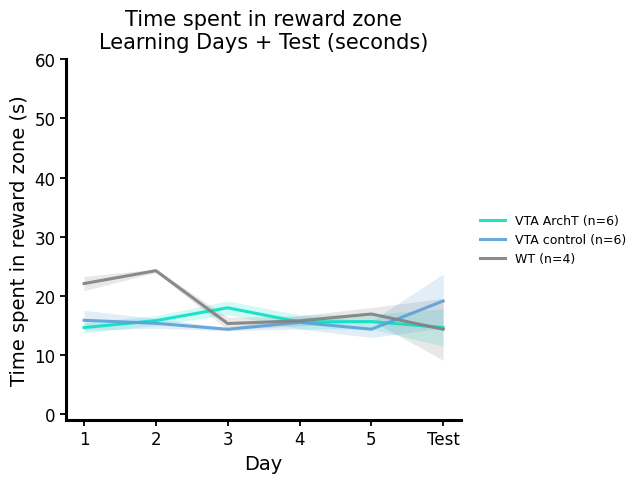


Boxplot: learning days 1-5 average
Metric: time_in_trigger_s
Animals included:
  VTA ArchT (ArchT): n = 6, ids = ['H', 'HA', 'HB', 'I', 'J', 'L']
  VTA control (eYFP_ArchT): n = 6, ids = ['M', 'MA', 'MB', 'N', 'O', 'P']
  WT (WT): n = 4, ids = ['Q', 'R', 'S', 'T']

Per-animal values:
         group  sub  id      value
0        ArchT   28   H  16.943225
1        ArchT   29  HA  14.244800
2        ArchT   30  HB  14.101600
3        ArchT   31   I  16.584375
4        ArchT   32   J  17.422150
5        ArchT   33   L  16.299750
6   eYFP_ArchT   34   M  16.447025
7   eYFP_ArchT   35  MA  12.875375
8   eYFP_ArchT   36  MB  14.983950
9   eYFP_ArchT   37   N  13.434475
10  eYFP_ArchT   38   O  16.397263
11  eYFP_ArchT   39   P  16.391200
12          WT   24   Q  18.364525
13          WT   25   R  18.631500
14          WT   26   S  18.943075
15          WT   27   T  19.544725

Mann–Whitney U tests:
  VTA ArchT vs VTA control: n=6 vs 6, mean=15.933 vs 15.088, median=16.442 vs 15.688, U=25.0, ra

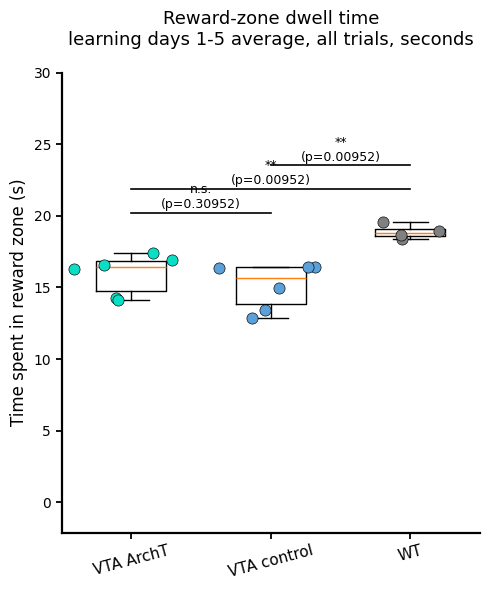


Boxplot: test day
Metric: time_in_trigger_s
Animals included:
  VTA ArchT (ArchT): n = 6, ids = ['H', 'HA', 'HB', 'I', 'J', 'L']
  VTA control (eYFP_ArchT): n = 6, ids = ['M', 'MA', 'MB', 'N', 'O', 'P']
  WT (WT): n = 4, ids = ['Q', 'R', 'S', 'T']

Per-animal values:
         group  sub  id   value
0        ArchT   28   H  25.798
1        ArchT   29  HA   8.643
2        ArchT   30  HB  22.377
3        ArchT   31   I   7.170
4        ArchT   32   J  13.878
5        ArchT   33   L   9.992
6   eYFP_ArchT   34   M  19.836
7   eYFP_ArchT   35  MA  37.578
8   eYFP_ArchT   36  MB   8.331
9   eYFP_ArchT   37   N   8.382
10  eYFP_ArchT   38   O  15.172
11  eYFP_ArchT   39   P  25.466
12          WT   24   Q   8.745
13          WT   25   R   2.396
14          WT   26   S  22.848
15          WT   27   T  23.395

Mann–Whitney U tests:
  VTA ArchT vs VTA control: n=6 vs 6, mean=14.643 vs 19.128, median=11.935 vs 17.504, U=15.0, rank-biserial=-0.167, p=0.69913
  VTA ArchT vs WT: n=6 vs 4, mean=14.6

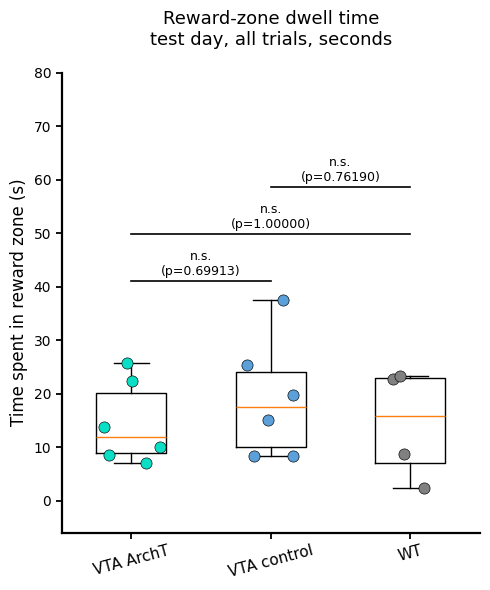


Within-day progress plots
Using column: time_in_trigger_s
Reward dwell mode: time
Trial column used: inferred from sub/ses order

Animals included for within-day plots:
  VTA ArchT (ArchT): n = 6, ids = ['H', 'HA', 'HB', 'I', 'J', 'L']
  VTA control (eYFP_ArchT): n = 6, ids = ['M', 'MA', 'MB', 'N', 'O', 'P']
  WT (WT): n = 4, ids = ['Q', 'R', 'S', 'T']


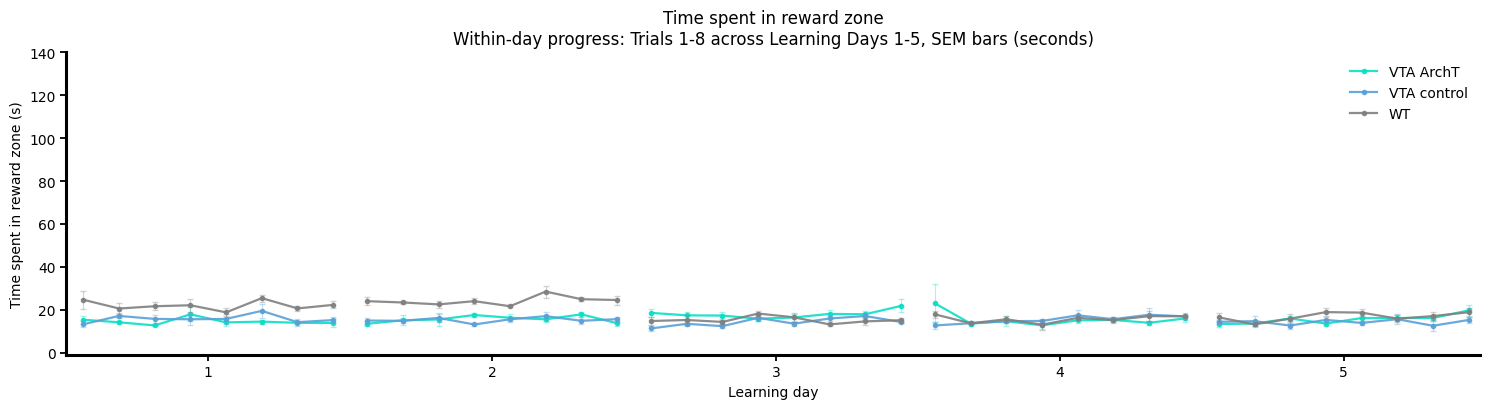

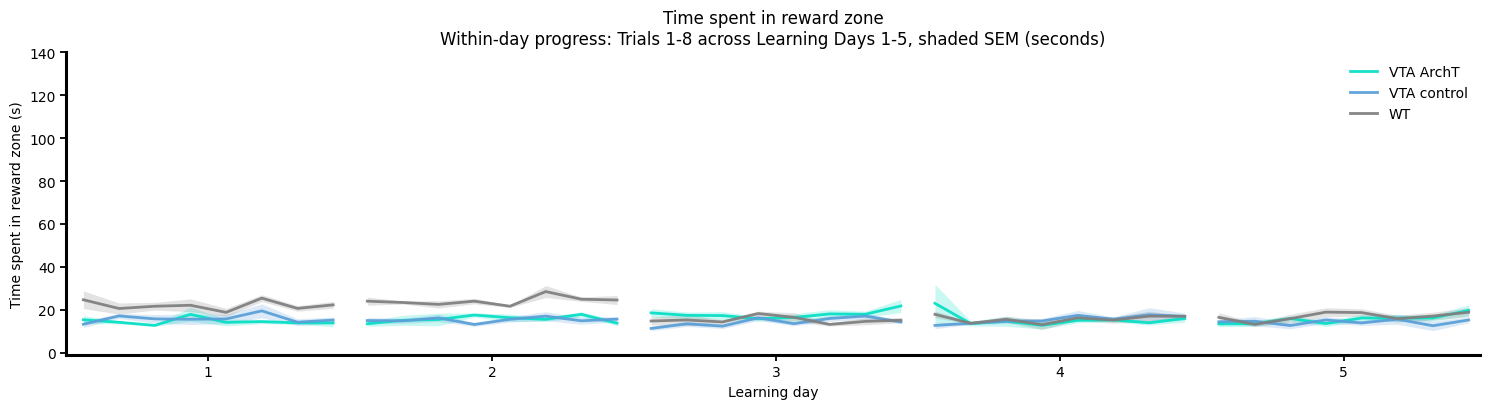

In [199]:
# ============================================================
# Reward-zone dwell across L1-L5 + Test
#
# Adds pooled control group:
#   'Control' = eYFP_ChR2 + CA1_control + NAc_control
#
# Adds custom ID-based groups:
#   'short_1' = AI, AJ, AL
#   'short_2' = V1, V2, V3, V4, V5
#
# Important behaviour:
#   - GROUPS = ['ChR2_short']
#       keeps ALL ChR2_short animals together as ChR2_short.
#
#   - GROUPS = ['short_1', 'short_2']
#       splits only AI/AJ/AL and V1-V5 into custom groups.
#
#   - GROUPS = ['ChR2_short', 'short_1', 'short_2']
#       keeps non-custom ChR2_short animals as ChR2_short,
#       while AI/AJ/AL become short_1 and V1-V5 become short_2.
#
# Produces:
#   1) Line plot across L1-L5 + Test
#   2) Boxplot: learning days 1-5 average
#   3) Boxplot: test day
#   4) Within-day progress plot across L1-L5, trials 1-8
#      with SEM bars
#   5) Within-day progress plot across L1-L5, trials 1-8
#      with shaded SEM
#
# Metric mode:
#   REWARD_DWELL_MODE = 'pct'
#       uses pct_time_in_trigger
#       y-axis = % of trial
#
#   REWARD_DWELL_MODE = 'time'
#       uses time_in_trigger_s
#       y-axis = seconds
#
# Stats: Mann–Whitney U / rank-sum test
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ============================================================
# OPTIONS
# ============================================================

# Example options:
# GROUPS = ['ChR2', 'ChR2_short', 'eYFP_ChR2']
# GROUPS = ['ChR2_short']
# GROUPS = ['ChR2_short', 'short_1', 'short_2']
# GROUPS = ['ChR2', 'NAc', 'Control']
# GROUPS = ['ChR2_short', 'CA1', 'CA3', 'Control']
# GROUPS = ['short_1', 'short_2']
# GROUPS = ['short_1', 'short_2', 'ChR2']
# GROUPS = ['short_1', 'short_2', 'eYFP_ChR2']
GROUPS = ['ArchT', 'eYFP_ArchT', 'WT']

# ------------------------------------------------------------
# Custom ID-based groups
# ------------------------------------------------------------
CUSTOM_GROUP_ID_MAP = {
    'short_1': ['AI', 'AJ', 'AL'],
    'short_2': ['V1', 'V2', 'V3', 'V4', 'V5'],
}

# Optional: restrict custom groups to a known original genotype.
# Usually these animals are stored as ChR2_short.
# If you do not want genotype restriction, set values to None.
CUSTOM_GROUP_GENOTYPE_SOURCE = {
    'short_1': 'ChR2_short',
    'short_2': 'ChR2_short',
}

# Choose reward-zone dwell metric:
#   'pct'  -> pct_time_in_trigger
#   'time' -> time_in_trigger_s
REWARD_DWELL_MODE = 'time'
# REWARD_DWELL_MODE = 'time' or 'pct'

# These original genotypes will be pooled into genotype == 'Control'
POOLED_CONTROL_ORIGINAL_GROUPS = ['CA1_control', 'NAc_control']

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'short_1': 'Short 1',
    'short_2': 'Short 2',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
    'WT': 'WT',
    'ArchT': 'VTA ArchT',
    'eYFP_ArchT': 'VTA control',
}

EXCLUDE_ID = ['AN']
EXCLUDE_SUBS = []

REQUIRE_COMPLETE = False
PLOT_INDIVIDUAL = False
PLOT_SEM_BARS = False

# True  -> exclude trials with zero reward-zone dwell
# False -> keep zero values
IGNORE_ZERO_VISITS = False

# Boxplot options
SHOW_ANIMAL_IDS = False
COMPARISONS = 'all'
# COMPARISONS = [('short_1', 'short_2')]
# COMPARISONS = [('ChR2_short', 'eYFP_ChR2')]
# COMPARISONS = [('short_1', 'ChR2_short'), ('short_2', 'ChR2_short')]

P_DECIMALS = 5
JITTER = 0.18

# p-value line spacing options
P_LINE_START_FRAC = 0.10
P_LINE_STEP_FRAC = 0.25
P_TEXT_OFFSET_FRAC = 0.015
P_TOP_PAD_FRAC = 0.18

# y-axis options for line plot
LINE_YMIN = -1.0
LINE_YMAX = 70 if REWARD_DWELL_MODE == 'pct' else 60
LINE_Y_TICK_STEP = 20 if REWARD_DWELL_MODE == 'pct' else None

# y-axis options for boxplots
BOX_YMAX = None
BOX_Y_BOTTOM_PAD_FRAC = 0.08
BOX_Y_TICK_STEP = None

# y-axis options for within-day trial plots
WITHIN_DAY_YMIN = -1.0
WITHIN_DAY_YMAX = 70 if REWARD_DWELL_MODE == 'pct' else 140
WITHIN_DAY_Y_TICK_STEP = 20 if REWARD_DWELL_MODE == 'pct' else None

DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.45

np.random.seed(1)

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

learning_days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# Choose column/labels based on mode
# ------------------------------------------------------------
if REWARD_DWELL_MODE == 'pct':
    VALUE_COL = 'pct_time_in_trigger'
    VALUE_LABEL = 'Time spent in reward zone (% of trial)'
    LINE_TITLE = 'Percent time in reward zone'
    BOXPLOT_TITLE = 'Reward-zone dwell time'
    MODE_TAG = '% trial'
elif REWARD_DWELL_MODE == 'time':
    VALUE_COL = 'time_in_trigger_s'
    VALUE_LABEL = 'Time spent in reward zone (s)'
    LINE_TITLE = 'Time spent in reward zone'
    BOXPLOT_TITLE = 'Reward-zone dwell time'
    MODE_TAG = 'seconds'
else:
    raise ValueError("REWARD_DWELL_MODE must be 'pct' or 'time'")


# ============================================================
# Helper functions
# ============================================================

def is_custom_group(g):
    return g in CUSTOM_GROUP_ID_MAP


def get_plot_color(g):
    """
    Treat every group like a genotype key for colour.

    If get_genotype_color('short_1') or get_genotype_color('short_2')
    is not defined, this falls back to ChR2_short colour.
    """
    try:
        return get_genotype_color(g)
    except Exception:
        if g in ['short_1', 'short_2']:
            return get_genotype_color('ChR2_short')
        return get_genotype_color(g)


def add_analysis_group(meta_df):
    """
    Adds analysis_group.

    Default:
      analysis_group = genotype

    Custom ID groups:
      animals with id in CUSTOM_GROUP_ID_MAP are assigned to
      short_1, short_2, etc. ONLY if that custom group is in GROUPS.

    This is the important fix:
      GROUPS = ['ChR2_short'] keeps AI/AJ/AL/V1-V5 inside ChR2_short.
      GROUPS = ['short_1', 'short_2'] splits them.
    """
    meta_df = meta_df.copy()
    meta_df['analysis_group'] = meta_df['genotype']

    if 'id' not in meta_df.columns:
        return meta_df

    id_as_str = meta_df['id'].astype(str)

    for group_name, ids in CUSTOM_GROUP_ID_MAP.items():

        # Key fix: only create custom groups when requested.
        if group_name not in GROUPS:
            continue

        ids_str = [str(x) for x in ids]
        meta_df.loc[id_as_str.isin(ids_str), 'analysis_group'] = group_name

    return meta_df


def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def get_comparisons(groups, comparisons):
    if comparisons == 'all':
        pairs = []
        for i in range(len(groups)):
            for j in range(i + 1, len(groups)):
                pairs.append((groups[i], groups[j]))
        return pairs
    return comparisons


def style_nature(ax, linewidth=2.0):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.3)
    ax.grid(False)


def get_animal_label(ms, sub):
    """
    Keeps custom group / pooled Control visible.
    """
    if 'id' in ms.columns and ms['id'].notna().any():
        animal_id = str(ms['id'].dropna().iloc[0])
    else:
        animal_id = str(sub)

    if 'analysis_group' in ms.columns and ms['analysis_group'].notna().any():
        analysis_group = str(ms['analysis_group'].dropna().iloc[0])
        if analysis_group in CUSTOM_GROUP_ID_MAP:
            return f'{animal_id} ({DISPLAY_NAME.get(analysis_group, analysis_group)})'

    if 'genotype_original' in ms.columns and ms['genotype'].iloc[0] == 'Control':
        original = str(ms['genotype_original'].dropna().iloc[0])
        return f'{animal_id} ({original})'

    return animal_id


def apply_box_y_axis_with_zero_padding(ax, y_top):
    """
    Tick labels start at 0, but the true y-lower-limit is slightly below 0.
    This makes very small positive values easier to see above the x-axis.
    """
    if BOX_YMAX is not None:
        y_top = BOX_YMAX
    else:
        if not np.isfinite(y_top) or y_top <= 0:
            y_top = 1.0

    y_bottom = -BOX_Y_BOTTOM_PAD_FRAC * y_top
    ax.set_ylim(y_bottom, y_top)

    if BOX_Y_TICK_STEP is not None:
        yticks = np.arange(0, y_top + BOX_Y_TICK_STEP, BOX_Y_TICK_STEP)
        ax.set_yticks(yticks)
    else:
        ticks = ax.get_yticks()
        ticks = ticks[ticks >= 0]
        if len(ticks) == 0 or ticks[0] != 0:
            ticks = np.insert(ticks, 0, 0)
        ax.set_yticks(ticks)


def apply_line_y_axis(ax, y_min, y_max, y_tick_step, all_mats):
    if y_max is not None:
        ax.set_ylim(y_min, y_max)

        if y_tick_step is not None:
            ax.set_yticks(np.arange(0, y_max + y_tick_step, y_tick_step))

    else:
        usable_mats = [
            m for m in all_mats
            if m is not None and np.any(np.isfinite(m))
        ]

        if len(usable_mats) > 0:
            all_vals = np.concatenate([
                m[np.isfinite(m)].ravel()
                for m in usable_mats
            ])

            if len(all_vals) > 0:
                ymax = np.nanmax(all_vals)

                if not np.isfinite(ymax) or ymax <= 0:
                    ymax = 1.0

                ax.set_ylim(y_min, ymax * 1.25)


def assign_learning_and_test_days(meta_df):
    """
    Assign:
      L trial_type_day 1-5 -> plot_day 1-5
      first T session after last L session -> plot_day 6
    """
    meta_df = meta_df.copy()
    meta_df['plot_day'] = np.nan

    mask_L = meta_df['trial_type'] == 'L'
    meta_df.loc[mask_L, 'plot_day'] = meta_df.loc[mask_L, 'trial_type_day']

    # keep only learning days 1-5
    meta_df = meta_df[
        (~mask_L) | (meta_df['trial_type_day'].isin([1, 2, 3, 4, 5]))
    ].copy()

    for sub in meta_df['sub'].unique():
        ms = meta_df[meta_df['sub'] == sub]

        L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
        if len(L_ses) == 0:
            continue

        last_L_ses = L_ses.max()

        T_after = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] > last_L_ses)
        ]

        if len(T_after) == 0:
            continue

        first_T_ses = T_after['ses'].min()

        idx = meta_df.index[
            (meta_df['sub'] == sub) &
            (meta_df['trial_type'] == 'T') &
            (meta_df['ses'] == first_T_ses)
        ]

        meta_df.loc[idx, 'plot_day'] = 6

    meta_df = meta_df[meta_df['plot_day'].isin([1, 2, 3, 4, 5, 6])].copy()

    return meta_df


def add_trial_in_day(meta_df):
    """
    Create trial_in_day = 1..8.
    Prefer existing trial column. Otherwise infer from sub/ses order.
    """
    meta_df = meta_df.copy()

    candidate_cols = [
        'trial_in_day',
        'trial_num',
        'trial_number',
        'trial',
        'trial_idx',
        'trial_index',
        'trial_in_session',
        'trial_id_in_session'
    ]

    trial_col = next((c for c in candidate_cols if c in meta_df.columns), None)

    if trial_col is not None:
        meta_df['trial_in_day'] = meta_df[trial_col].astype(int)
    else:
        meta_df = meta_df.sort_values(['sub', 'ses']).copy()
        meta_df['trial_in_day'] = meta_df.groupby(['sub', 'ses']).cumcount() + 1

    meta_df = meta_df[meta_df['trial_in_day'].between(1, 8)].copy()

    return meta_df, trial_col


def build_genotype_matrix(meta_group, value_col):
    """
    Build animal x day matrix.
    One row = one animal.
    Columns = L1, L2, L3, L4, L5, Test.
    """
    perf_mat = []
    subjects = []
    animal_ids = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub].copy()

        mean_by_day = ms.groupby('plot_day')[value_col].mean()

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)
        animal_ids.append(get_animal_label(ms, sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids


def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem


def values_from_matrix(g, mode):
    """
    Uses the exact same matrix as the line plot.

    mode:
      'learning_mean' -> mean of days 1-5 = mat[:, 0:5]
      'test'          -> test day = mat[:, 5]
    """
    mat = group_data[g]['mat']
    subs = group_data[g]['subs']
    ids = group_data[g]['ids']

    if mat is None or len(subs) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'value'])

    rows = []

    for i, sub in enumerate(subs):
        row = mat[i, :]

        if mode == 'learning_mean':
            value = np.nanmean(row[0:5])
        elif mode == 'test':
            value = row[5]
        else:
            raise ValueError("mode must be 'learning_mean' or 'test'")

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'id': ids[i],
            'value': float(value)
        })

    return pd.DataFrame(rows)


def plot_group_shaded(
    ax,
    mat,
    subs,
    genotype_key,
    label,
    alpha_fill=0.18,
    alpha_line=0.9,
    alpha_individual=0.12
):
    if mat is None or len(subs) == 0:
        return

    col = get_plot_color(genotype_key)

    if PLOT_INDIVIDUAL:
        for row in mat:
            ax.plot(
                x_vals,
                row,
                '-',
                color=col,
                alpha=alpha_individual,
                linewidth=1.0,
                label='_nolegend_',
                zorder=1
            )

    mean_ = np.nanmean(mat, axis=0)
    sem_ = sem_by_day(mat)

    ax.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0,
        zorder=2
    )

    ax.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})',
        zorder=3
    )

    if PLOT_SEM_BARS:
        ax.errorbar(
            x_vals,
            mean_,
            yerr=sem_,
            fmt='none',
            ecolor=col,
            elinewidth=1.2,
            capsize=3,
            alpha=0.9,
            zorder=4
        )


# ============================================================
# 1. Filter metadata and create pooled/custom groups
# ============================================================

needed_cols = [
    'usable',
    'genotype',
    'trial_type',
    'trial_type_day',
    'ses',
    'sub',
    VALUE_COL,
]

missing_cols = [c for c in needed_cols if c not in metadata.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Missing columns in metadata: {missing_cols}")

# ------------------------------------------------------------
# Work out which genotypes/IDs to load
# ------------------------------------------------------------
groups_to_load = []
custom_ids_to_load = []

for g in GROUPS:
    if g == 'Control':
        groups_to_load.extend(POOLED_CONTROL_ORIGINAL_GROUPS)

    elif g in CUSTOM_GROUP_ID_MAP:
        custom_ids_to_load.extend(CUSTOM_GROUP_ID_MAP[g])

        genotype_source = CUSTOM_GROUP_GENOTYPE_SOURCE.get(g, None)
        if genotype_source is not None:
            groups_to_load.append(genotype_source)

    else:
        groups_to_load.append(g)

groups_to_load = sorted(set(groups_to_load))
custom_ids_to_load = sorted(set([str(x) for x in custom_ids_to_load]))

# Load rows either by genotype or by custom IDs
base_mask = (
    (metadata['usable'] == 1) &
    (metadata['trial_type'].isin(['L', 'T']))
)

if len(groups_to_load) > 0:
    genotype_mask = metadata['genotype'].isin(groups_to_load)
else:
    genotype_mask = False

if len(custom_ids_to_load) > 0 and 'id' in metadata.columns:
    custom_id_mask = metadata['id'].astype(str).isin(custom_ids_to_load)
else:
    custom_id_mask = False

meta_LT = metadata[
    base_mask &
    (genotype_mask | custom_id_mask)
].copy()

# Store original genotype before pooling/custom grouping
meta_LT['genotype_original'] = meta_LT['genotype']

# Pool controls into genotype == Control
if 'Control' in GROUPS:
    meta_LT.loc[
        meta_LT['genotype_original'].isin(POOLED_CONTROL_ORIGINAL_GROUPS),
        'genotype'
    ] = 'Control'

# Add analysis_group.
# This only creates short_1 / short_2 if they are in GROUPS.
meta_LT = add_analysis_group(meta_LT)

# Keep only selected GROUPS at the analysis-group level
meta_LT = meta_LT[meta_LT['analysis_group'].isin(GROUPS)].copy()

# For plotting/stat functions, use genotype column as the analysis group
meta_LT['genotype'] = meta_LT['analysis_group']

if IGNORE_ZERO_VISITS:
    meta_LT = meta_LT[
        meta_LT[VALUE_COL].notna() &
        np.isfinite(meta_LT[VALUE_COL]) &
        (meta_LT[VALUE_COL] > 0)
    ].copy()
else:
    meta_LT = meta_LT[
        meta_LT[VALUE_COL].notna() &
        np.isfinite(meta_LT[VALUE_COL])
    ].copy()

# Do not accidentally exclude custom animals if they appear in EXCLUDE_ID
exclude_ids_effective = [
    x for x in EXCLUDE_ID
    if str(x) not in custom_ids_to_load
]

if len(exclude_ids_effective) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in exclude_ids_effective])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

meta_LT = assign_learning_and_test_days(meta_LT)

print("\nGroups used for plotting/stats:", GROUPS)
print("Original genotypes loaded:", groups_to_load)
print("Custom IDs loaded:", custom_ids_to_load)
print("Reward dwell mode:", REWARD_DWELL_MODE)
print("Using column:", VALUE_COL)

if 'Control' in GROUPS:
    print("Control pooled from:", POOLED_CONTROL_ORIGINAL_GROUPS)

print("\nCustom groups requested:")
for g, ids in CUSTOM_GROUP_ID_MAP.items():
    if g in GROUPS:
        print(f"  {g}: {ids}, colour = get_genotype_color('{g}')")

print("\nRows after filtering:")
cols_to_print = ['sub']
if 'id' in meta_LT.columns:
    cols_to_print.append('id')
if 'genotype_original' in meta_LT.columns:
    cols_to_print.append('genotype_original')
cols_to_print += ['genotype', 'trial_type', 'trial_type_day', 'ses', 'plot_day']

if len(meta_LT) > 0:
    print(
        meta_LT[cols_to_print]
        .drop_duplicates()
        .sort_values(cols_to_print)
        .reset_index(drop=True)
    )
else:
    print("No rows left after filtering.")


# ============================================================
# 2. Build matrices
# ============================================================

group_data = {}

print("\nAnimals included:")
for g in GROUPS:
    meta_g = meta_LT[meta_LT['genotype'] == g].copy()
    mat_g, subs_g, ids_g = build_genotype_matrix(meta_g, VALUE_COL)

    group_data[g] = {
        'meta': meta_g,
        'mat': mat_g,
        'subs': subs_g,
        'ids': ids_g,
    }

    print(f"  {DISPLAY_NAME.get(g, g)} ({g}):")
    print(f"    animals in dataset: {meta_g['sub'].nunique()}")
    print(f"    animals plotted:    {len(subs_g)}")
    print(f"    ids plotted:        {ids_g}")


# ============================================================
# 3. Line plot across L1-L5 + Test
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5.2))

for g in GROUPS:
    plot_group_shaded(
        ax,
        group_data[g]['mat'],
        group_data[g]['subs'],
        genotype_key=g,
        label=DISPLAY_NAME.get(g, g)
    )

ax.set_xlabel('Day', fontsize=14)
ax.set_ylabel(VALUE_LABEL, fontsize=14)

ax.set_xticks(np.arange(6))
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
ax.tick_params(axis='y', labelsize=12)

style_nature(ax, linewidth=2.2)

ax.set_title(
    f'{LINE_TITLE}\nLearning Days + Test ({MODE_TAG})',
    fontsize=15,
    pad=8
)

handles, labels = ax.get_legend_handles_labels()
if len(handles) > 0:
    ax.legend(
        frameon=False,
        fontsize=9,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5)
    )

apply_line_y_axis(
    ax=ax,
    y_min=LINE_YMIN,
    y_max=LINE_YMAX,
    y_tick_step=LINE_Y_TICK_STEP,
    all_mats=[
        group_data[g]['mat']
        for g in GROUPS
        if group_data[g]['mat'] is not None
    ]
)

plt.tight_layout(rect=[0, 0, 0.82, 0.95])
plt.show()


# ============================================================
# 4. Boxplot helper
# ============================================================

def plot_boxplot_from_matrix(mode, title_suffix):
    group_dfs = {}
    vals_groups = []

    for g in GROUPS:
        df_g = values_from_matrix(g, mode)
        group_dfs[g] = df_g
        vals_groups.append(df_g['value'].values.astype(float))

    print("\n============================================================")
    print(f"Boxplot: {title_suffix}")
    print(f"Metric: {VALUE_COL}")
    print("Animals included:")

    for g in GROUPS:
        print(
            f"  {DISPLAY_NAME.get(g, g)} ({g}): "
            f"n = {len(group_dfs[g])}, ids = {list(group_dfs[g]['id'])}"
        )

    print("\nPer-animal values:")
    meta_animal = pd.concat(
        [
            group_dfs[g].assign(group=g)
            for g in GROUPS
            if len(group_dfs[g]) > 0
        ],
        ignore_index=True
    ) if any(len(group_dfs[g]) > 0 for g in GROUPS) else pd.DataFrame()

    if len(meta_animal) > 0:
        print(meta_animal[['group', 'sub', 'id', 'value']])
    else:
        print("No data.")

    fig, ax = plt.subplots(figsize=(max(5, 1.5 * len(GROUPS)), 6))

    ax.boxplot(
        vals_groups,
        positions=np.arange(len(GROUPS)),
        widths=0.5,
        patch_artist=False,
        showfliers=False
    )

    for i, g in enumerate(GROUPS):
        df_g = group_dfs[g]
        vals = df_g['value'].values.astype(float)

        if len(vals) == 0:
            continue

        x = np.random.normal(i, JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=65,
            color=get_plot_color(g),
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, df_g['id'].values):
                ax.text(
                    xi + 0.04,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=get_plot_color(g),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    # --------------------------------------------------------
    # Mann–Whitney U tests + significance lines
    # --------------------------------------------------------
    pairs = get_comparisons(GROUPS, COMPARISONS)
    nonempty_data = [d for d in vals_groups if len(d) > 0]

    y_top_for_axis = 1.0

    if len(nonempty_data) > 0:
        all_vals = np.concatenate(nonempty_data)
        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)

        yrng = ymax - ymin
        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        current_y = ymax + P_LINE_START_FRAC * yrng
        y_step = P_LINE_STEP_FRAC * yrng

        print("\nMann–Whitney U tests:")
        for g1, g2 in pairs:
            if g1 not in GROUPS or g2 not in GROUPS:
                print(f"Skipping {g1} vs {g2}: group not in GROUPS")
                continue

            i = GROUPS.index(g1)
            j = GROUPS.index(g2)

            vals_i = vals_groups[i]
            vals_j = vals_groups[j]

            if len(vals_i) == 0 or len(vals_j) == 0:
                print(f"Skipping {g1} vs {g2}: one group has no data")
                continue

            stat, p = mannwhitneyu(vals_i, vals_j, alternative='two-sided')

            n1 = len(vals_i)
            n2 = len(vals_j)
            rank_biserial = (2 * stat) / (n1 * n2) - 1

            print(
                f"  {DISPLAY_NAME.get(g1, g1)} vs {DISPLAY_NAME.get(g2, g2)}: "
                f"n={n1} vs {n2}, "
                f"mean={np.nanmean(vals_i):.3f} vs {np.nanmean(vals_j):.3f}, "
                f"median={np.nanmedian(vals_i):.3f} vs {np.nanmedian(vals_j):.3f}, "
                f"U={stat:.1f}, "
                f"rank-biserial={rank_biserial:.3f}, "
                f"p={format_p(p, P_DECIMALS)}"
            )

            x1, x2 = i, j
            x_mid = (x1 + x2) / 2.0

            ax.plot(
                [x1, x2],
                [current_y, current_y],
                color='black',
                linewidth=1.2
            )

            ax.text(
                x_mid,
                current_y + P_TEXT_OFFSET_FRAC * yrng,
                f"{p_to_stars(p)}\n(p={format_p(p, P_DECIMALS)})",
                ha='center',
                va='bottom',
                fontsize=9
            )

            current_y += y_step

        y_top_for_axis = current_y + P_TOP_PAD_FRAC * yrng

    ax.set_xticks(np.arange(len(GROUPS)))
    ax.set_xticklabels(
        [DISPLAY_NAME.get(g, g) for g in GROUPS],
        fontsize=11,
        rotation=15
    )

    ax.set_ylabel(VALUE_LABEL, fontsize=12)
    ax.set_xlabel('')

    trial_tag = 'visit trials only' if IGNORE_ZERO_VISITS else 'all trials'

    ax.set_title(
        f'{BOXPLOT_TITLE}\n{title_suffix}, {trial_tag}, {MODE_TAG}',
        fontsize=13,
        pad=20
    )

    apply_box_y_axis_with_zero_padding(ax, y_top_for_axis)
    style_nature(ax, linewidth=1.6)

    plt.tight_layout()
    plt.show()


# ============================================================
# 5. Produce boxplots
# ============================================================

plot_boxplot_from_matrix(
    mode='learning_mean',
    title_suffix='learning days 1-5 average'
)

plot_boxplot_from_matrix(
    mode='test',
    title_suffix='test day'
)


# ============================================================
# 6. Within-day progress plots across Learning Days 1-5
#    Trials 1-8
#
#    These use the same GROUPS, VALUE_COL, VALUE_LABEL, and
#    REWARD_DWELL_MODE selected above.
# ============================================================

# ------------------------------------------------------------
# 6a. Prepare learning-only metadata
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['trial_type'] == 'L') &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata[VALUE_COL].notna()) &
    (np.isfinite(metadata[VALUE_COL]))
].copy()

# keep only relevant genotypes / custom IDs
if len(groups_to_load) > 0:
    genotype_mask_L = meta_L['genotype'].isin(groups_to_load)
else:
    genotype_mask_L = False

if len(custom_ids_to_load) > 0 and 'id' in meta_L.columns:
    custom_id_mask_L = meta_L['id'].astype(str).isin(custom_ids_to_load)
else:
    custom_id_mask_L = False

meta_L = meta_L[genotype_mask_L | custom_id_mask_L].copy()

# Store original genotype before pooling
meta_L['genotype_original'] = meta_L['genotype']

# Pool controls into one displayed/statistical group: Control
if 'Control' in GROUPS:
    meta_L.loc[
        meta_L['genotype_original'].isin(POOLED_CONTROL_ORIGINAL_GROUPS),
        'genotype'
    ] = 'Control'

# Add custom analysis groups.
# This only creates short_1 / short_2 if they are in GROUPS.
meta_L = add_analysis_group(meta_L)
meta_L = meta_L[meta_L['analysis_group'].isin(GROUPS)].copy()
meta_L['genotype'] = meta_L['analysis_group']

if IGNORE_ZERO_VISITS:
    meta_L = meta_L[meta_L[VALUE_COL] > 0].copy()

if len(exclude_ids_effective) > 0 and 'id' in meta_L.columns:
    meta_L = meta_L[
        ~meta_L['id'].astype(str).isin([str(x) for x in exclude_ids_effective])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_L = meta_L[
        ~meta_L['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

meta_L, within_trial_col = add_trial_in_day(meta_L)

print("\n============================================================")
print("Within-day progress plots")
print("Using column:", VALUE_COL)
print("Reward dwell mode:", REWARD_DWELL_MODE)
print("Trial column used:", within_trial_col if within_trial_col is not None else "inferred from sub/ses order")

print("\nAnimals included for within-day plots:")
for g in GROUPS:
    meta_g = meta_L[meta_L['genotype'] == g].copy()
    ids_g = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub]
        ids_g.append(get_animal_label(ms, sub))

    print(
        f"  {DISPLAY_NAME.get(g, g)} ({g}): "
        f"n = {meta_g['sub'].nunique()}, ids = {ids_g}"
    )


# ------------------------------------------------------------
# 6b. Helper: subject × trial matrix for a given day
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day, value_col):
    md = meta_g[meta_g['trial_type_day'] == day].copy()

    if len(md) == 0:
        return None

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        mean_by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        vals = np.array(
            [mean_by_trial.get(t, np.nan) for t in trials],
            dtype=float
        )

        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)


def sem_by_trial(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem


# ------------------------------------------------------------
# 6c. Plot helper: SEM bars
# ------------------------------------------------------------
def plot_within_day_curves_sem_bars(
    ax,
    meta_g,
    genotype_key,
    value_col,
    label=None,
    alpha=0.9
):
    offsets = np.linspace(0.06, 0.94, len(trials))
    col = get_plot_color(genotype_key)

    first_day = True

    for day in learning_days:
        mat = subject_trial_matrix_for_day(meta_g, day, value_col)

        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0)
        sem_ = sem_by_trial(mat)

        ax.plot(
            x,
            mean_,
            'o-',
            color=col,
            alpha=alpha,
            linewidth=1.6,
            markersize=3,
            label=label if first_day and (label is not None) else None
        )

        ax.errorbar(
            x,
            mean_,
            yerr=sem_,
            fmt='none',
            ecolor=col,
            alpha=min(alpha, 0.35),
            elinewidth=0.8,
            capsize=2
        )

        first_day = False


# ------------------------------------------------------------
# 6d. Plot helper: shaded SEM
# ------------------------------------------------------------
def plot_within_day_curves_shaded_sem(
    ax,
    meta_g,
    genotype_key,
    value_col,
    label=None,
    alpha_fill=0.22,
    alpha_line=0.95
):
    offsets = np.linspace(0.06, 0.94, len(trials))
    col = get_plot_color(genotype_key)

    first_day = True

    for day in learning_days:
        mat = subject_trial_matrix_for_day(meta_g, day, value_col)

        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0)
        sem_ = sem_by_trial(mat)

        ax.fill_between(
            x,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=alpha_fill,
            linewidth=0
        )

        ax.plot(
            x,
            mean_,
            '-',
            color=col,
            alpha=alpha_line,
            linewidth=2.0,
            label=label if first_day and (label is not None) else None
        )

        first_day = False


# ------------------------------------------------------------
# 6e. Within-day plot 1: SEM bars
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

within_mats_for_ylim = []

for g in GROUPS:
    meta_g = meta_L[meta_L['genotype'] == g].copy()

    for day in learning_days:
        mat_tmp = subject_trial_matrix_for_day(meta_g, day, VALUE_COL)
        if mat_tmp is not None:
            within_mats_for_ylim.append(mat_tmp)

    plot_within_day_curves_sem_bars(
        ax,
        meta_g,
        genotype_key=g,
        value_col=VALUE_COL,
        label=DISPLAY_NAME.get(g, g),
        alpha=0.9
    )

ax.set_xlabel('Learning day')
ax.set_ylabel(VALUE_LABEL)

ax.set_xticks(learning_days + 0.5)
ax.set_xticklabels([str(d) for d in learning_days])

ax.set_xlim(1.0, 5.98)

ax.set_title(
    f'{LINE_TITLE}\n'
    f'Within-day progress: Trials 1-8 across Learning Days 1-5, SEM bars ({MODE_TAG})',
    fontsize=12
)

style_nature(ax, linewidth=2.2)

handles, labels = ax.get_legend_handles_labels()
if len(handles) > 0:
    ax.legend(frameon=False)

apply_line_y_axis(
    ax=ax,
    y_min=WITHIN_DAY_YMIN,
    y_max=WITHIN_DAY_YMAX,
    y_tick_step=WITHIN_DAY_Y_TICK_STEP,
    all_mats=within_mats_for_ylim
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6f. Within-day plot 2: shaded SEM
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

within_mats_for_ylim = []

for g in GROUPS:
    meta_g = meta_L[meta_L['genotype'] == g].copy()

    for day in learning_days:
        mat_tmp = subject_trial_matrix_for_day(meta_g, day, VALUE_COL)
        if mat_tmp is not None:
            within_mats_for_ylim.append(mat_tmp)

    plot_within_day_curves_shaded_sem(
        ax,
        meta_g,
        genotype_key=g,
        value_col=VALUE_COL,
        label=DISPLAY_NAME.get(g, g),
        alpha_fill=0.22,
        alpha_line=0.95
    )

ax.set_xlabel('Learning day')
ax.set_ylabel(VALUE_LABEL)

ax.set_xticks(learning_days + 0.5)
ax.set_xticklabels([str(d) for d in learning_days])

ax.set_xlim(1.0, 5.98)

ax.set_title(
    f'{LINE_TITLE}\n'
    f'Within-day progress: Trials 1-8 across Learning Days 1-5, shaded SEM ({MODE_TAG})',
    fontsize=12
)

style_nature(ax, linewidth=2.2)

handles, labels = ax.get_legend_handles_labels()
if len(handles) > 0:
    ax.legend(frameon=False)

apply_line_y_axis(
    ax=ax,
    y_min=WITHIN_DAY_YMIN,
    y_max=WITHIN_DAY_YMAX,
    y_tick_step=WITHIN_DAY_Y_TICK_STEP,
    all_mats=within_mats_for_ylim
)

plt.tight_layout()
plt.show()


Groups used for plotting/stats: ['ArchT', 'eYFP_ArchT', 'WT']
Bar chart groups: ['ArchT', 'eYFP_ArchT', 'WT']
Original genotypes loaded: ['ArchT', 'WT', 'eYFP_ArchT']
Active custom groups: []
Custom IDs loaded: []

Custom groups:

Main ratio metric: near_reward_to_reward_ratio
Near-reward plot mode: time
Near-reward line/boxplot metric: time_in_near_reward_s
Edge line/boxplot metric: time_in_edge_s
Reward bar metric: time_in_trigger_s
Near-reward bar metric: time_in_near_reward_s

Animals included for ratio plots:
  VTA ArchT (ArchT):
    animals in dataset: 6
    animals plotted:    6
    ids plotted:        ['H', 'HA', 'HB', 'I', 'J', 'L']
  VTA control (eYFP_ArchT):
    animals in dataset: 6
    animals plotted:    6
    ids plotted:        ['M', 'MA', 'MB', 'N', 'O', 'P']
  WT (WT):
    animals in dataset: 4
    animals plotted:    4
    ids plotted:        ['Q', 'R', 'S', 'T']

Animals included for near-reward-only plots:
  VTA ArchT (ArchT):
    animals in dataset: 6
    animals

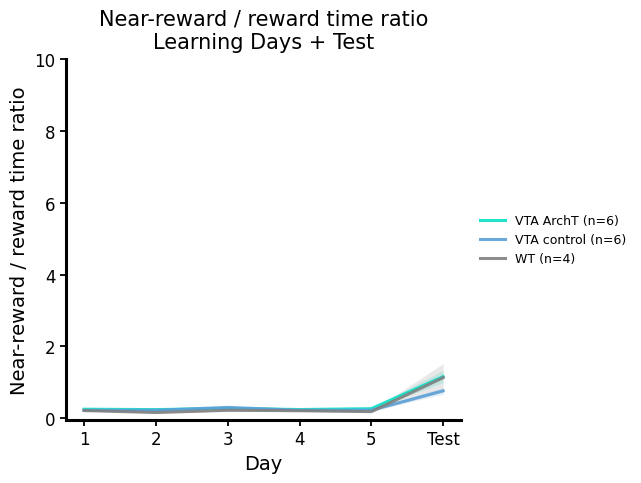

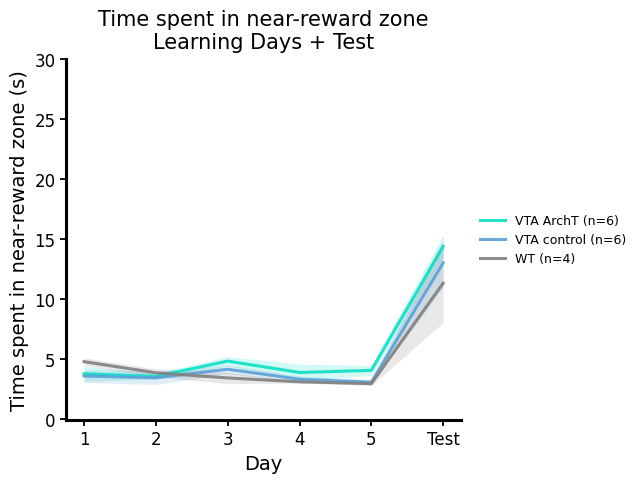

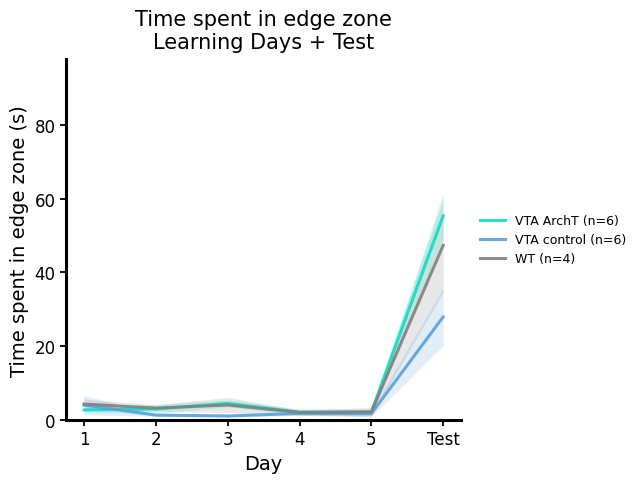


Boxplot: learning days 1-5 average
Metric: near_reward_to_reward_ratio
Animals included:
  VTA ArchT (ArchT): n = 6, ids = ['H', 'HA', 'HB', 'I', 'J', 'L']
  VTA control (eYFP_ArchT): n = 6, ids = ['M', 'MA', 'MB', 'N', 'O', 'P']
  WT (WT): n = 4, ids = ['Q', 'R', 'S', 'T']

Per-animal values:
         group  sub  id     value
0        ArchT   28   H  0.268410
1        ArchT   29  HA  0.267352
2        ArchT   30  HB  0.212835
3        ArchT   31   I  0.223381
4        ArchT   32   J  0.303114
5        ArchT   33   L  0.255963
6   eYFP_ArchT   34   M  0.248132
7   eYFP_ArchT   35  MA  0.318988
8   eYFP_ArchT   36  MB  0.252745
9   eYFP_ArchT   37   N  0.207191
10  eYFP_ArchT   38   O  0.213951
11  eYFP_ArchT   39   P  0.188577
12          WT   24   Q  0.205318
13          WT   25   R  0.191949
14          WT   26   S  0.182300
15          WT   27   T  0.210637

Mann–Whitney U tests:
  VTA ArchT vs VTA control: n=6 vs 6, mean=0.255 vs 0.238, median=0.262 vs 0.231, U=25.0, rank-biserial

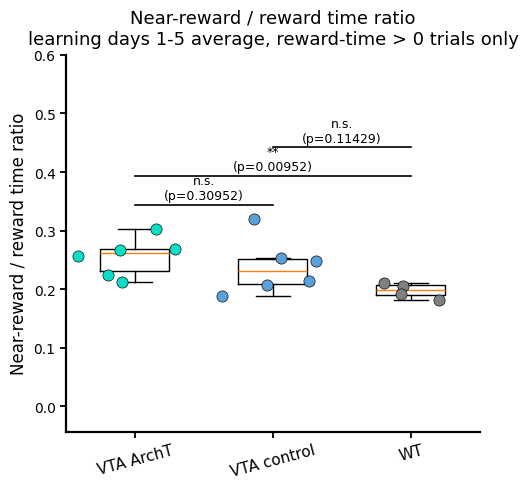


Boxplot: test day
Metric: near_reward_to_reward_ratio
Animals included:
  VTA ArchT (ArchT): n = 6, ids = ['H', 'HA', 'HB', 'I', 'J', 'L']
  VTA control (eYFP_ArchT): n = 6, ids = ['M', 'MA', 'MB', 'N', 'O', 'P']
  WT (WT): n = 4, ids = ['Q', 'R', 'S', 'T']

Per-animal values:
         group  sub  id     value
0        ArchT   28   H  0.707148
1        ArchT   29  HA  1.477843
2        ArchT   30  HB  0.694374
3        ArchT   31   I  1.729707
4        ArchT   32   J  1.051016
5        ArchT   33   L  1.303643
6   eYFP_ArchT   34   M  0.789474
7   eYFP_ArchT   35  MA  0.529512
8   eYFP_ArchT   36  MB  1.178130
9   eYFP_ArchT   37   N  0.749344
10  eYFP_ArchT   38   O  0.714276
11  eYFP_ArchT   39   P  0.619061
12          WT   24   Q  0.809377
13          WT   25   R  2.293823
14          WT   26   S  0.874912
15          WT   27   T  0.548664

Mann–Whitney U tests:
  VTA ArchT vs VTA control: n=6 vs 6, mean=1.161 vs 0.763, median=1.177 vs 0.732, U=27.0, rank-biserial=0.500, p=0.17965

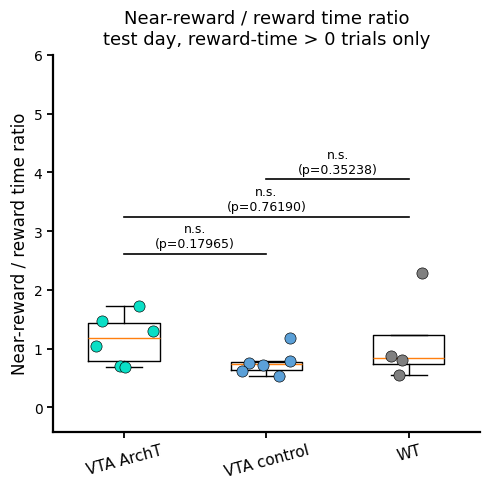


Boxplot: learning days 1-5 average
Metric: time_in_near_reward_s
Animals included:
  VTA ArchT (ArchT): n = 6, ids = ['H', 'HA', 'HB', 'I', 'J', 'L']
  VTA control (eYFP_ArchT): n = 6, ids = ['M', 'MA', 'MB', 'N', 'O', 'P']
  WT (WT): n = 4, ids = ['Q', 'R', 'S', 'T']

Per-animal values:
         group  sub  id     value
0        ArchT   28   H  4.302575
1        ArchT   29  HA  4.048937
2        ArchT   30  HB  2.946675
3        ArchT   31   I  3.710938
4        ArchT   32   J  5.157875
5        ArchT   33   L  4.124575
6   eYFP_ArchT   34   M  3.997675
7   eYFP_ArchT   35  MA  4.312550
8   eYFP_ArchT   36  MB  3.610312
9   eYFP_ArchT   37   N  2.831850
10  eYFP_ArchT   38   O  3.566450
11  eYFP_ArchT   39   P  2.937325
12          WT   24   Q  3.780900
13          WT   25   R  3.558975
14          WT   26   S  3.425275
15          WT   27   T  3.849412

Mann–Whitney U tests:
  VTA ArchT vs VTA control: n=6 vs 6, mean=4.049 vs 3.543, median=4.087 vs 3.588, U=27.0, rank-biserial=0.500

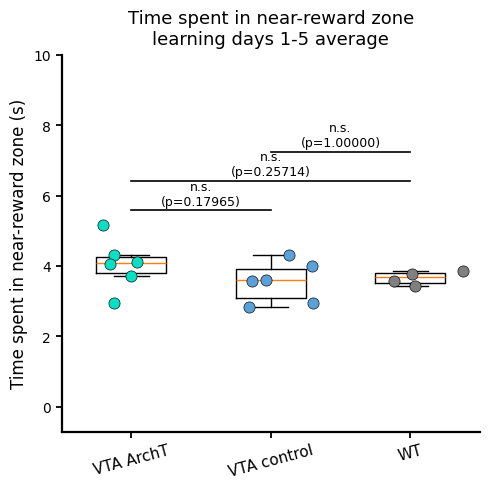


Boxplot: test day
Metric: time_in_near_reward_s
Animals included:
  VTA ArchT (ArchT): n = 6, ids = ['H', 'HA', 'HB', 'I', 'J', 'L']
  VTA control (eYFP_ArchT): n = 6, ids = ['M', 'MA', 'MB', 'N', 'O', 'P']
  WT (WT): n = 4, ids = ['Q', 'R', 'S', 'T']

Per-animal values:
         group  sub  id   value
0        ArchT   28   H  18.243
1        ArchT   29  HA  12.773
2        ArchT   30  HB  15.538
3        ArchT   31   I  12.402
4        ArchT   32   J  14.586
5        ArchT   33   L  13.026
6   eYFP_ArchT   34   M  15.660
7   eYFP_ArchT   35  MA  19.898
8   eYFP_ArchT   36  MB   9.815
9   eYFP_ArchT   37   N   6.281
10  eYFP_ArchT   38   O  10.837
11  eYFP_ArchT   39   P  15.765
12          WT   24   Q   7.078
13          WT   25   R   5.496
14          WT   26   S  19.990
15          WT   27   T  12.836

Mann–Whitney U tests:
  VTA ArchT vs VTA control: n=6 vs 6, mean=14.428 vs 13.043, median=13.806 vs 13.248, U=20.0, rank-biserial=0.111, p=0.81818
  VTA ArchT vs WT: n=6 vs 4, mean=1

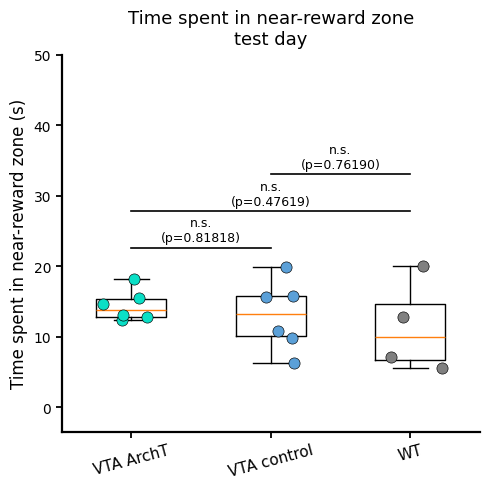


Boxplot: learning days 1-5 average
Metric: time_in_edge_s
Animals included:
  VTA ArchT (ArchT): n = 6, ids = ['H', 'HA', 'HB', 'I', 'J', 'L']
  VTA control (eYFP_ArchT): n = 6, ids = ['M', 'MA', 'MB', 'N', 'O', 'P']
  WT (WT): n = 4, ids = ['Q', 'R', 'S', 'T']

Per-animal values:
         group  sub  id     value
0        ArchT   28   H  2.548650
1        ArchT   29  HA  4.378375
2        ArchT   30  HB  2.570788
3        ArchT   31   I  0.969814
4        ArchT   32   J  2.785150
5        ArchT   33   L  3.843750
6   eYFP_ArchT   34   M  4.841775
7   eYFP_ArchT   35  MA  0.774000
8   eYFP_ArchT   36  MB  0.629625
9   eYFP_ArchT   37   N  1.897975
10  eYFP_ArchT   38   O  1.089675
11  eYFP_ArchT   39   P  2.476825
12          WT   24   Q  4.077763
13          WT   25   R  5.483550
14          WT   26   S  1.224175
15          WT   27   T  1.761675

Mann–Whitney U tests:
  VTA ArchT vs VTA control: n=6 vs 6, mean=2.849 vs 1.952, median=2.678 vs 1.494, U=27.0, rank-biserial=0.500, p=0.1

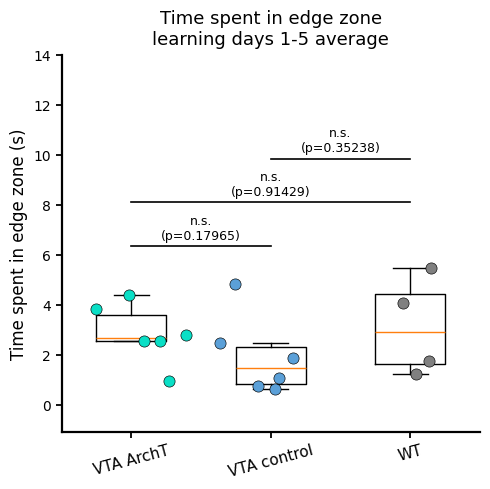


Boxplot: test day
Metric: time_in_edge_s
Animals included:
  VTA ArchT (ArchT): n = 6, ids = ['H', 'HA', 'HB', 'I', 'J', 'L']
  VTA control (eYFP_ArchT): n = 6, ids = ['M', 'MA', 'MB', 'N', 'O', 'P']
  WT (WT): n = 4, ids = ['Q', 'R', 'S', 'T']

Per-animal values:
         group  sub  id    value
0        ArchT   28   H  32.6570
1        ArchT   29  HA  78.2610
2        ArchT   30  HB  59.1220
3        ArchT   31   I  54.7880
4        ArchT   32   J  47.6800
5        ArchT   33   L  59.5295
6   eYFP_ArchT   34   M  41.3710
7   eYFP_ArchT   35  MA   1.4830
8   eYFP_ArchT   36  MB  12.4610
9   eYFP_ArchT   37   N  29.5010
10  eYFP_ArchT   38   O  54.8350
11  eYFP_ArchT   39   P  28.0130
12          WT   24   Q  69.2510
13          WT   25   R  68.7530
14          WT   26   S  20.8210
15          WT   27   T  30.5150

Mann–Whitney U tests:
  VTA ArchT vs VTA control: n=6 vs 6, mean=55.340 vs 27.944, median=56.955 vs 28.757, U=32.0, rank-biserial=0.778, p=0.02597
  VTA ArchT vs WT: n=6 vs

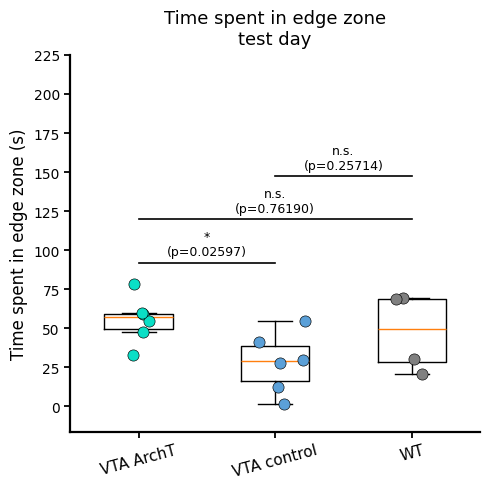


Reward vs near-reward bar chart
Mode: time
Group: VTA ArchT (ArchT)
Animals plotted: n = 6, ids = ['H', 'HA', 'HB', 'I', 'J', 'L']


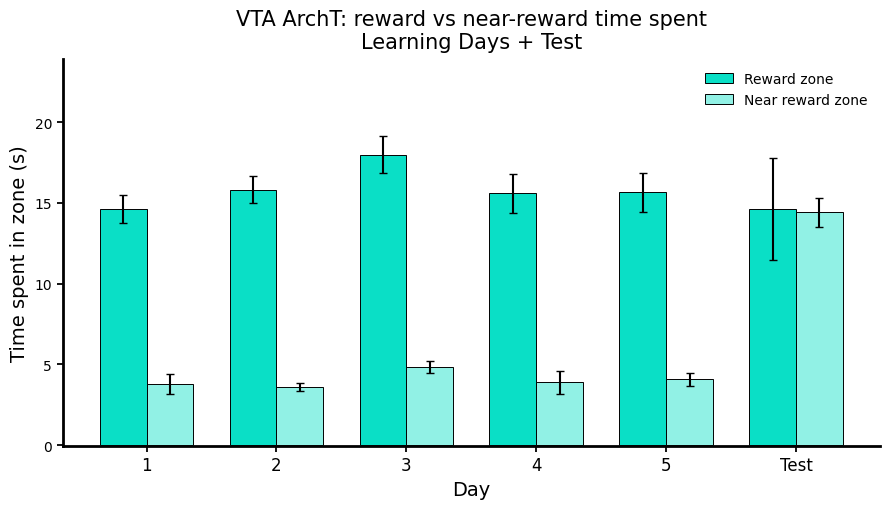


Reward vs near-reward bar chart
Mode: time
Group: VTA control (eYFP_ArchT)
Animals plotted: n = 6, ids = ['M', 'MA', 'MB', 'N', 'O', 'P']


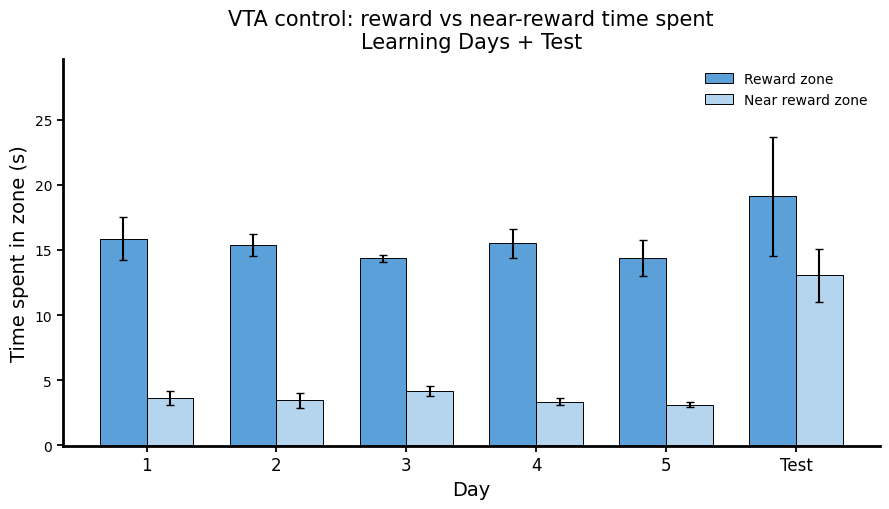


Reward vs near-reward bar chart
Mode: time
Group: WT (WT)
Animals plotted: n = 4, ids = ['Q', 'R', 'S', 'T']


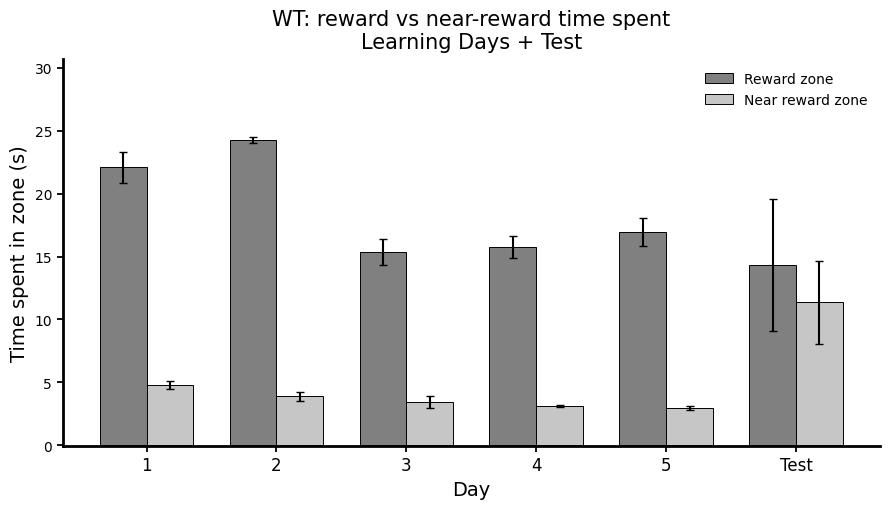

In [ ]:
# ============================================================
# Near-reward / reward / edge analysis across L1-L5 + Test
#
# Requires columns already computed:
#   time_in_trigger_s
#   pct_time_in_trigger
#   time_in_near_reward_s
#   pct_time_in_near_reward
#   near_reward_to_reward_ratio
#   time_in_edge_s
#   pct_time_in_edge
#
# Adds custom ID-based groups:
#   short_1 = AI, AJ, AL
#   short_2 = V1, V2, V3, V4, V5
#
# Produces:
#   1) Line plot across L1-L5 + Test
#        Metric: near_reward_to_reward_ratio
#
#   1b) Line plot across L1-L5 + Test
#        Metric: near-reward only
#        Switch using:
#            NEAR_REWARD_PLOT_MODE = 'time' or 'pct'
#
#   1c) Line plot across L1-L5 + Test
#        Metric: edge only
#        Switch using:
#            NEAR_REWARD_PLOT_MODE = 'time' or 'pct'
#
#   2) Boxplot: learning days 1-5 average
#        Metric: near_reward_to_reward_ratio
#
#   3) Boxplot: test day
#        Metric: near_reward_to_reward_ratio
#
#   4) Boxplot: learning days 1-5 average
#        Metric: near-reward only
#
#   5) Boxplot: test day
#        Metric: near-reward only
#
#   6) Boxplot: learning days 1-5 average
#        Metric: edge only
#
#   7) Boxplot: test day
#        Metric: edge only
#
#   8) Bar charts for multiple genotype/groups:
#        For each genotype in BAR_GENOTYPES:
#            reward bar + near-reward bar for each day
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ============================================================
# OPTIONS
# ============================================================

# Example options:
# GROUPS = ['Control']
# GROUPS = ['ChR2', 'Control']
# GROUPS = ['ChR2_short']
# GROUPS = ['ChR2', 'eYFP_ChR2']
# GROUPS = ['ChR2', 'NAc', 'Control']
# GROUPS = ['ChR2_short', 'CA1', 'CA3', 'Control']
# GROUPS = ['short_1', 'short_2']
# GROUPS = ['short_1', 'short_2', 'ChR2']
# GROUPS = ['short_1', 'short_2', 'ChR2_short']
# GROUPS = ['ChR2_short', 'short_1', 'short_2']
# GROUPS = ['short_1', 'short_2', 'eYFP_ChR2']
GROUPS = ['ArchT', 'eYFP_ArchT', 'WT']


# ------------------------------------------------------------
# Custom ID-based groups
# ------------------------------------------------------------
CUSTOM_GROUP_ID_MAP = {
    'short_1': ['AI', 'AJ', 'AL'],
    'short_2': ['V1', 'V2', 'V3', 'V4', 'V5'],
}

# Optional: restrict custom groups to a known original genotype.
# If you do not want genotype restriction, set values to None.
CUSTOM_GROUP_GENOTYPE_SOURCE = {
    'short_1': 'ChR2_short',
    'short_2': 'ChR2_short',
}

# Genotype/groups to use for separate reward-vs-near-reward bar charts
BAR_GENOTYPES = GROUPS
# BAR_GENOTYPES = ['short_1', 'short_2']
# BAR_GENOTYPES = ['short_1', 'short_2', 'ChR2']
# BAR_GENOTYPES = ['ChR2_short']

# Switch near-reward-only line plot, edge-only line plot,
# near-reward boxplots, edge boxplots, and reward-vs-near bar charts:
#   'time' -> seconds
#   'pct'  -> percent of trial
NEAR_REWARD_PLOT_MODE = 'time'
# NEAR_REWARD_PLOT_MODE = 'pct'

# These original genotypes will be pooled into genotype == 'Control'
POOLED_CONTROL_ORIGINAL_GROUPS = ['CA1_control', 'NAc_control']

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'short_1': 'Short 1',
    'short_2': 'Short 2',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
    'WT': 'WT',
    'ArchT': 'VTA ArchT',
    'eYFP_ArchT': 'VTA control',
}

EXCLUDE_ID = ['AN']
EXCLUDE_SUBS = []

REQUIRE_COMPLETE = False
PLOT_INDIVIDUAL = False
PLOT_SEM_BARS = False

# Main ratio metric
VALUE_COL = 'near_reward_to_reward_ratio'

# Columns for seconds
REWARD_TIME_COL = 'time_in_trigger_s'
NEAR_REWARD_TIME_COL = 'time_in_near_reward_s'
EDGE_TIME_COL = 'time_in_edge_s'

# Columns for percent of trial
REWARD_PCT_COL = 'pct_time_in_trigger'
NEAR_REWARD_PCT_COL = 'pct_time_in_near_reward'
EDGE_PCT_COL = 'pct_time_in_edge'

if NEAR_REWARD_PLOT_MODE == 'time':
    REWARD_BAR_COL = REWARD_TIME_COL
    NEAR_REWARD_BAR_COL = NEAR_REWARD_TIME_COL
    NEAR_REWARD_LINE_COL = NEAR_REWARD_TIME_COL
    EDGE_LINE_COL = EDGE_TIME_COL

    NEAR_REWARD_LINE_LABEL = 'Time spent in near-reward zone (s)'
    NEAR_REWARD_LINE_TITLE = 'Time spent in near-reward zone'
    NEAR_REWARD_BOXPLOT_LABEL = 'Time spent in near-reward zone (s)'

    EDGE_LINE_LABEL = 'Time spent in edge zone (s)'
    EDGE_LINE_TITLE = 'Time spent in edge zone'
    EDGE_BOXPLOT_LABEL = 'Time spent in edge zone (s)'

    BAR_YLABEL = 'Time spent in zone (s)'
    BAR_TITLE_SUFFIX = 'time spent'

elif NEAR_REWARD_PLOT_MODE == 'pct':
    REWARD_BAR_COL = REWARD_PCT_COL
    NEAR_REWARD_BAR_COL = NEAR_REWARD_PCT_COL
    NEAR_REWARD_LINE_COL = NEAR_REWARD_PCT_COL
    EDGE_LINE_COL = EDGE_PCT_COL

    NEAR_REWARD_LINE_LABEL = 'Time spent in near-reward zone (% trial)'
    NEAR_REWARD_LINE_TITLE = 'Percent time spent in near-reward zone'
    NEAR_REWARD_BOXPLOT_LABEL = 'Time spent in near-reward zone (% trial)'

    EDGE_LINE_LABEL = 'Time spent in edge zone (% trial)'
    EDGE_LINE_TITLE = 'Percent time spent in edge zone'
    EDGE_BOXPLOT_LABEL = 'Time spent in edge zone (% trial)'

    BAR_YLABEL = 'Time spent in zone (% trial)'
    BAR_TITLE_SUFFIX = 'percent time spent'

else:
    raise ValueError("NEAR_REWARD_PLOT_MODE must be 'time' or 'pct'")

# True  -> exclude trials where ratio is NaN/inf or reward time is zero
# False -> keep all finite ratio values
IGNORE_ZERO_REWARD_TIME_FOR_RATIO = True

# Boxplot options
SHOW_ANIMAL_IDS = False
COMPARISONS = 'all'
# COMPARISONS = [('short_1', 'short_2')]
# COMPARISONS = [('short_1', 'ChR2'), ('short_2', 'ChR2')]
# COMPARISONS = [('ChR2_short', 'short_1'), ('ChR2_short', 'short_2')]

P_DECIMALS = 5
JITTER = 0.18

# p-value line spacing options
# Increase P_TEXT_OFFSET_FRAC if you want more gap between p text and horizontal bar.
P_LINE_START_FRAC = 0.18
P_LINE_STEP_FRAC = 0.36
P_TEXT_OFFSET_FRAC = 0.035
P_TOP_PAD_FRAC = 0.35

# y-axis options for near-reward-only line plot
NEAR_LINE_YMIN = -0.05
NEAR_LINE_YMAX = 5 if NEAR_REWARD_PLOT_MODE == 'pct' else 30
NEAR_LINE_Y_TICK_STEP = None

# y-axis options for ratio line plot
LINE_YMIN = -0.05
LINE_YMAX = 10
LINE_Y_TICK_STEP = None



# y-axis options for edge-only line plot
EDGE_LINE_YMIN = -0.05
EDGE_LINE_YMAX = 50 if NEAR_REWARD_PLOT_MODE == 'pct' else None
EDGE_LINE_Y_TICK_STEP = None

# y-axis options for boxplots
BOX_Y_BOTTOM_PAD_FRAC = 0.08
BOX_Y_TICK_STEP = None

# y-axis options for bar charts
BAR_YMIN = -0.05
BAR_YMAX = None
BAR_Y_TICK_STEP = None

DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.45

np.random.seed(1)

plot_days = np.arange(1, 7)
x_vals = plot_days - 1
day_labels = ['1', '2', '3', '4', '5', 'Test']


# ============================================================
# Helper functions
# ============================================================

def is_custom_group(g):
    return g in CUSTOM_GROUP_ID_MAP


def get_all_requested_groups():
    return sorted(set(list(GROUPS) + list(BAR_GENOTYPES)))


ALL_REQUESTED_GROUPS = get_all_requested_groups()


def get_active_custom_group_map():
    """
    Only activate custom groups that are requested in GROUPS or BAR_GENOTYPES.

    This is the key fix:
      - If ChR2_short is requested alone, no custom reassignment happens.
      - If short_1 / short_2 are requested, only those IDs are reassigned.
    """
    return {
        g: ids
        for g, ids in CUSTOM_GROUP_ID_MAP.items()
        if g in ALL_REQUESTED_GROUPS
    }


ACTIVE_CUSTOM_GROUP_ID_MAP = get_active_custom_group_map()


def get_plot_color(g):
    """
    Treat every group exactly like a genotype key for colour.
    Therefore get_genotype_color('ChR2_short'), get_genotype_color('short_1'),
    and get_genotype_color('short_2') should exist in your colour function.
    """
    return get_genotype_color(g)


def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def get_comparisons(groups, comparisons):
    if comparisons == 'all':
        pairs = []
        for i in range(len(groups)):
            for j in range(i + 1, len(groups)):
                pairs.append((groups[i], groups[j]))
        return pairs
    return comparisons


def style_nature(ax, linewidth=2.0):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.3)
    ax.grid(False)


def get_animal_label(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        animal_id = str(ms['id'].dropna().iloc[0])
    else:
        animal_id = str(sub)

    if 'analysis_group' in ms.columns and ms['analysis_group'].notna().any():
        analysis_group = str(ms['analysis_group'].dropna().iloc[0])
        if analysis_group in ACTIVE_CUSTOM_GROUP_ID_MAP:
            return f'{animal_id} ({DISPLAY_NAME.get(analysis_group, analysis_group)})'

    if 'genotype_original' in ms.columns and ms['genotype'].iloc[0] == 'Control':
        original = str(ms['genotype_original'].dropna().iloc[0])
        return f'{animal_id} ({original})'

    return animal_id


def apply_box_y_axis_with_zero_padding(ax, y_top):
    if not np.isfinite(y_top) or y_top <= 0:
        y_top = 1.0

    y_bottom = -BOX_Y_BOTTOM_PAD_FRAC * y_top
    ax.set_ylim(y_bottom, y_top)

    if BOX_Y_TICK_STEP is not None:
        yticks = np.arange(0, y_top + BOX_Y_TICK_STEP, BOX_Y_TICK_STEP)
        ax.set_yticks(yticks)
    else:
        ticks = ax.get_yticks()
        ticks = ticks[ticks >= 0]
        if len(ticks) == 0 or ticks[0] != 0:
            ticks = np.insert(ticks, 0, 0)
        ax.set_yticks(ticks)


def assign_learning_and_test_days(meta_df):
    meta_df = meta_df.copy()
    meta_df['plot_day'] = np.nan

    mask_L = meta_df['trial_type'] == 'L'
    meta_df.loc[mask_L, 'plot_day'] = meta_df.loc[mask_L, 'trial_type_day']

    meta_df = meta_df[
        (~mask_L) | (meta_df['trial_type_day'].isin([1, 2, 3, 4, 5]))
    ].copy()

    for sub in meta_df['sub'].unique():
        ms = meta_df[meta_df['sub'] == sub]

        L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
        if len(L_ses) == 0:
            continue

        last_L_ses = L_ses.max()

        T_after = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] > last_L_ses)
        ]

        if len(T_after) == 0:
            continue

        first_T_ses = T_after['ses'].min()

        idx = meta_df.index[
            (meta_df['sub'] == sub) &
            (meta_df['trial_type'] == 'T') &
            (meta_df['ses'] == first_T_ses)
        ]

        meta_df.loc[idx, 'plot_day'] = 6

    meta_df = meta_df[meta_df['plot_day'].isin([1, 2, 3, 4, 5, 6])].copy()

    return meta_df


def add_analysis_group(meta_df):
    """
    Adds analysis_group.
    Normal animals keep genotype as analysis_group.
    Only active custom ID-based animals are assigned to short_1 / short_2.
    """
    meta_df = meta_df.copy()
    meta_df['analysis_group'] = meta_df['genotype']

    if 'id' not in meta_df.columns:
        return meta_df

    id_as_str = meta_df['id'].astype(str)

    for group_name, ids in ACTIVE_CUSTOM_GROUP_ID_MAP.items():
        ids_str = [str(x) for x in ids]
        meta_df.loc[id_as_str.isin(ids_str), 'analysis_group'] = group_name

    return meta_df


def build_genotype_matrix(meta_group, value_col):
    """
    Build animal x day matrix.
    One row = one animal.
    Columns = L1, L2, L3, L4, L5, Test.
    Values = mean per trial within each day.
    """
    perf_mat = []
    subjects = []
    animal_ids = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub].copy()

        mean_by_day = ms.groupby('plot_day')[value_col].mean()

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)
        animal_ids.append(get_animal_label(ms, sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids


def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem


def values_from_group_data(group_data_dict, g, mode):
    """
    Uses the exact same matrix as the relevant line plot.

    mode:
      'learning_mean' -> mean of days 1-5 = mat[:, 0:5]
      'test'          -> test day = mat[:, 5]
    """
    mat = group_data_dict[g]['mat']
    subs = group_data_dict[g]['subs']
    ids = group_data_dict[g]['ids']

    if mat is None or len(subs) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'value'])

    rows = []

    for i, sub in enumerate(subs):
        row = mat[i, :]

        if mode == 'learning_mean':
            value = np.nanmean(row[0:5])
        elif mode == 'test':
            value = row[5]
        else:
            raise ValueError("mode must be 'learning_mean' or 'test'")

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'id': ids[i],
            'value': float(value)
        })

    return pd.DataFrame(rows)


def build_zone_matrices_for_group(meta_group):
    """
    For one genotype/group, build animal x day matrices for:
      - reward zone
      - near reward zone

    Uses either seconds or percent depending on NEAR_REWARD_PLOT_MODE.
    """
    reward_mat = []
    near_mat = []
    subjects = []
    animal_ids = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub].copy()

        reward_by_day = ms.groupby('plot_day')[REWARD_BAR_COL].mean()
        near_by_day = ms.groupby('plot_day')[NEAR_REWARD_BAR_COL].mean()

        reward_vals = np.array(
            [reward_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )
        near_vals = np.array(
            [near_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        combined_vals = np.r_[reward_vals, near_vals]

        if REQUIRE_COMPLETE and np.any(np.isnan(combined_vals)):
            continue

        if np.all(np.isnan(combined_vals)):
            continue

        reward_mat.append(reward_vals)
        near_mat.append(near_vals)
        subjects.append(sub)
        animal_ids.append(get_animal_label(ms, sub))

    if len(reward_mat) == 0:
        return None, None, [], []

    return np.vstack(reward_mat), np.vstack(near_mat), subjects, animal_ids


def plot_group_shaded(
    ax,
    mat,
    subs,
    genotype_key,
    label,
    alpha_fill=0.18,
    alpha_line=0.9,
    alpha_individual=0.12
):
    if mat is None or len(subs) == 0:
        return

    col = get_plot_color(genotype_key)

    if PLOT_INDIVIDUAL:
        for row in mat:
            ax.plot(
                x_vals,
                row,
                '-',
                color=col,
                alpha=alpha_individual,
                linewidth=1.0,
                label='_nolegend_',
                zorder=1
            )

    mean_ = np.nanmean(mat, axis=0)
    sem_ = sem_by_day(mat)

    ax.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0,
        zorder=2
    )

    ax.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})',
        zorder=3
    )

    if PLOT_SEM_BARS:
        ax.errorbar(
            x_vals,
            mean_,
            yerr=sem_,
            fmt='none',
            ecolor=col,
            elinewidth=1.2,
            capsize=3,
            alpha=0.9,
            zorder=4
        )


def plot_boxplot_from_group_data(
    group_data_dict,
    metric_name,
    ylabel,
    title_main,
    mode,
    title_suffix,
    trial_tag=None
):
    group_dfs = {}
    vals_groups = []

    for g in GROUPS:
        df_g = values_from_group_data(group_data_dict, g, mode)
        group_dfs[g] = df_g
        vals_groups.append(df_g['value'].values.astype(float))

    print("\n============================================================")
    print(f"Boxplot: {title_suffix}")
    print(f"Metric: {metric_name}")
    print("Animals included:")

    for g in GROUPS:
        print(
            f"  {DISPLAY_NAME.get(g, g)} ({g}): "
            f"n = {len(group_dfs[g])}, ids = {list(group_dfs[g]['id'])}"
        )

    print("\nPer-animal values:")
    meta_animal = pd.concat(
        [
            group_dfs[g].assign(group=g)
            for g in GROUPS
            if len(group_dfs[g]) > 0
        ],
        ignore_index=True
    ) if any(len(group_dfs[g]) > 0 for g in GROUPS) else pd.DataFrame()

    if len(meta_animal) > 0:
        print(meta_animal[['group', 'sub', 'id', 'value']])
    else:
        print("No data.")

    fig, ax = plt.subplots(figsize=(max(5, 1.35 * len(GROUPS)), 5))

    ax.boxplot(
        vals_groups,
        positions=np.arange(len(GROUPS)),
        widths=0.5,
        patch_artist=False,
        showfliers=False
    )

    for i, g in enumerate(GROUPS):
        df_g = group_dfs[g]
        vals = df_g['value'].values.astype(float)

        if len(vals) == 0:
            continue

        x = np.random.normal(i, JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=65,
            color=get_plot_color(g),
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, df_g['id'].values):
                ax.text(
                    xi + 0.04,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=get_plot_color(g),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    pairs = get_comparisons(GROUPS, COMPARISONS)
    nonempty_data = [d for d in vals_groups if len(d) > 0]

    y_top_for_axis = 1.0

    if len(nonempty_data) > 0:
        all_vals = np.concatenate(nonempty_data)
        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)

        yrng = ymax - ymin
        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        current_y = ymax + P_LINE_START_FRAC * yrng
        y_step = P_LINE_STEP_FRAC * yrng

        print("\nMann–Whitney U tests:")
        for g1, g2 in pairs:
            if g1 not in GROUPS or g2 not in GROUPS:
                print(f"Skipping {g1} vs {g2}: group not in GROUPS")
                continue

            i = GROUPS.index(g1)
            j = GROUPS.index(g2)

            vals_i = vals_groups[i]
            vals_j = vals_groups[j]

            if len(vals_i) == 0 or len(vals_j) == 0:
                print(f"Skipping {g1} vs {g2}: one group has no data")
                continue

            stat, p = mannwhitneyu(vals_i, vals_j, alternative='two-sided')

            n1 = len(vals_i)
            n2 = len(vals_j)
            rank_biserial = (2 * stat) / (n1 * n2) - 1

            print(
                f"  {DISPLAY_NAME.get(g1, g1)} vs {DISPLAY_NAME.get(g2, g2)}: "
                f"n={n1} vs {n2}, "
                f"mean={np.nanmean(vals_i):.3f} vs {np.nanmean(vals_j):.3f}, "
                f"median={np.nanmedian(vals_i):.3f} vs {np.nanmedian(vals_j):.3f}, "
                f"U={stat:.1f}, "
                f"rank-biserial={rank_biserial:.3f}, "
                f"p={format_p(p, P_DECIMALS)}"
            )

            x1, x2 = i, j
            x_mid = (x1 + x2) / 2.0

            ax.plot(
                [x1, x2],
                [current_y, current_y],
                color='black',
                linewidth=1.2
            )

            ax.text(
                x_mid,
                current_y + P_TEXT_OFFSET_FRAC * yrng,
                f"{p_to_stars(p)}\n(p={format_p(p, P_DECIMALS)})",
                ha='center',
                va='bottom',
                fontsize=9
            )

            current_y += y_step

        y_top_for_axis = current_y + P_TOP_PAD_FRAC * yrng

    ax.set_xticks(np.arange(len(GROUPS)))
    ax.set_xticklabels(
        [DISPLAY_NAME.get(g, g) for g in GROUPS],
        fontsize=11,
        rotation=15
    )

    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel('')

    if trial_tag is None:
        ax.set_title(
            f'{title_main}\n{title_suffix}',
            fontsize=13,
            pad=8
        )
    else:
        ax.set_title(
            f'{title_main}\n{title_suffix}, {trial_tag}',
            fontsize=13,
            pad=8
        )

    apply_box_y_axis_with_zero_padding(ax, y_top_for_axis)
    style_nature(ax, linewidth=1.6)

    plt.tight_layout()
    plt.show()


# ============================================================
# 1. Filter metadata and create pooled/custom groups
# ============================================================

needed_cols = [
    'usable',
    'genotype',
    'trial_type',
    'trial_type_day',
    'ses',
    'sub',
    VALUE_COL,
    REWARD_TIME_COL,
    NEAR_REWARD_TIME_COL,
    EDGE_TIME_COL,
    REWARD_PCT_COL,
    NEAR_REWARD_PCT_COL,
    EDGE_PCT_COL,
]

missing_cols = [c for c in needed_cols if c not in metadata.columns]
if len(missing_cols) > 0:
    raise KeyError(
        f"Missing columns in metadata: {missing_cols}\n"
        "Run the near-reward / edge computation code first."
    )

# ------------------------------------------------------------
# Work out which genotypes / custom IDs to load
# ------------------------------------------------------------
groups_to_load = []
custom_ids_to_load = []

for g in ALL_REQUESTED_GROUPS:
    if g == 'Control':
        groups_to_load.extend(POOLED_CONTROL_ORIGINAL_GROUPS)

    elif g in ACTIVE_CUSTOM_GROUP_ID_MAP:
        custom_ids_to_load.extend(ACTIVE_CUSTOM_GROUP_ID_MAP[g])

        genotype_source = CUSTOM_GROUP_GENOTYPE_SOURCE.get(g, None)
        if genotype_source is not None:
            groups_to_load.append(genotype_source)

    else:
        groups_to_load.append(g)

groups_to_load = sorted(set(groups_to_load))
custom_ids_to_load = sorted(set([str(x) for x in custom_ids_to_load]))

base_mask = (
    (metadata['usable'] == 1) &
    (metadata['trial_type'].isin(['L', 'T']))
)

if len(groups_to_load) > 0:
    genotype_mask = metadata['genotype'].isin(groups_to_load)
else:
    genotype_mask = False

if len(custom_ids_to_load) > 0 and 'id' in metadata.columns:
    custom_id_mask = metadata['id'].astype(str).isin(custom_ids_to_load)
else:
    custom_id_mask = False

meta_LT = metadata[
    base_mask &
    (genotype_mask | custom_id_mask)
].copy()

meta_LT['genotype_original'] = meta_LT['genotype']

if ('Control' in GROUPS) or ('Control' in BAR_GENOTYPES):
    meta_LT.loc[
        meta_LT['genotype_original'].isin(POOLED_CONTROL_ORIGINAL_GROUPS),
        'genotype'
    ] = 'Control'

# Add active custom analysis groups only
meta_LT = add_analysis_group(meta_LT)

# Keep only requested analysis groups
meta_LT = meta_LT[meta_LT['analysis_group'].isin(ALL_REQUESTED_GROUPS)].copy()

# For plotting/stat functions, use genotype column as analysis group
meta_LT['genotype'] = meta_LT['analysis_group']

# Ratio dataframe
if IGNORE_ZERO_REWARD_TIME_FOR_RATIO:
    meta_LT_ratio = meta_LT[
        meta_LT[VALUE_COL].notna() &
        np.isfinite(meta_LT[VALUE_COL]) &
        (meta_LT[REWARD_TIME_COL].notna()) &
        (meta_LT[REWARD_TIME_COL] > 0)
    ].copy()
else:
    meta_LT_ratio = meta_LT[
        meta_LT[VALUE_COL].notna() &
        np.isfinite(meta_LT[VALUE_COL])
    ].copy()

# Zone dataframe: used for near-reward line plot, near-reward boxplots, and bar charts
meta_LT_zone = meta_LT[
    meta_LT[REWARD_BAR_COL].notna() &
    meta_LT[NEAR_REWARD_BAR_COL].notna() &
    np.isfinite(meta_LT[REWARD_BAR_COL]) &
    np.isfinite(meta_LT[NEAR_REWARD_BAR_COL])
].copy()

# Edge dataframe: used for edge line plot and edge boxplots
meta_LT_edge = meta_LT[
    meta_LT[EDGE_LINE_COL].notna() &
    np.isfinite(meta_LT[EDGE_LINE_COL])
].copy()

# Do not accidentally exclude active custom animals if they appear in EXCLUDE_ID
exclude_ids_effective = [
    x for x in EXCLUDE_ID
    if str(x) not in custom_ids_to_load
]

if len(exclude_ids_effective) > 0:
    if 'id' in meta_LT_ratio.columns:
        meta_LT_ratio = meta_LT_ratio[
            ~meta_LT_ratio['id'].astype(str).isin([str(x) for x in exclude_ids_effective])
        ].copy()

    if 'id' in meta_LT_zone.columns:
        meta_LT_zone = meta_LT_zone[
            ~meta_LT_zone['id'].astype(str).isin([str(x) for x in exclude_ids_effective])
        ].copy()

    if 'id' in meta_LT_edge.columns:
        meta_LT_edge = meta_LT_edge[
            ~meta_LT_edge['id'].astype(str).isin([str(x) for x in exclude_ids_effective])
        ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT_ratio = meta_LT_ratio[
        ~meta_LT_ratio['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

    meta_LT_zone = meta_LT_zone[
        ~meta_LT_zone['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

    meta_LT_edge = meta_LT_edge[
        ~meta_LT_edge['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

meta_LT_ratio = assign_learning_and_test_days(meta_LT_ratio)
meta_LT_zone = assign_learning_and_test_days(meta_LT_zone)
meta_LT_edge = assign_learning_and_test_days(meta_LT_edge)

print("\nGroups used for plotting/stats:", GROUPS)
print("Bar chart groups:", BAR_GENOTYPES)
print("Original genotypes loaded:", groups_to_load)
print("Active custom groups:", list(ACTIVE_CUSTOM_GROUP_ID_MAP.keys()))
print("Custom IDs loaded:", custom_ids_to_load)

if ('Control' in GROUPS) or ('Control' in BAR_GENOTYPES):
    print("Control pooled from:", POOLED_CONTROL_ORIGINAL_GROUPS)

print("\nCustom groups:")
for g, ids in ACTIVE_CUSTOM_GROUP_ID_MAP.items():
    print(f"  {g}: {ids}, colour = get_genotype_color('{g}')")

print("\nMain ratio metric:", VALUE_COL)
print("Near-reward plot mode:", NEAR_REWARD_PLOT_MODE)
print("Near-reward line/boxplot metric:", NEAR_REWARD_LINE_COL)
print("Edge line/boxplot metric:", EDGE_LINE_COL)
print("Reward bar metric:", REWARD_BAR_COL)
print("Near-reward bar metric:", NEAR_REWARD_BAR_COL)


# ============================================================
# 2. Build matrices for ratio line plot and ratio boxplots
# ============================================================

group_data = {}

print("\nAnimals included for ratio plots:")
for g in GROUPS:
    meta_g = meta_LT_ratio[meta_LT_ratio['genotype'] == g].copy()
    mat_g, subs_g, ids_g = build_genotype_matrix(meta_g, VALUE_COL)

    group_data[g] = {
        'meta': meta_g,
        'mat': mat_g,
        'subs': subs_g,
        'ids': ids_g,
    }

    print(f"  {DISPLAY_NAME.get(g, g)} ({g}):")
    print(f"    animals in dataset: {meta_g['sub'].nunique()}")
    print(f"    animals plotted:    {len(subs_g)}")
    print(f"    ids plotted:        {ids_g}")


# ============================================================
# 2b. Build matrices for near-reward-only line plot and boxplots
# ============================================================

near_group_data = {}

print("\nAnimals included for near-reward-only plots:")
for g in GROUPS:
    meta_g = meta_LT_zone[meta_LT_zone['genotype'] == g].copy()
    mat_g, subs_g, ids_g = build_genotype_matrix(meta_g, NEAR_REWARD_LINE_COL)

    near_group_data[g] = {
        'meta': meta_g,
        'mat': mat_g,
        'subs': subs_g,
        'ids': ids_g,
    }

    print(f"  {DISPLAY_NAME.get(g, g)} ({g}):")
    print(f"    animals in dataset: {meta_g['sub'].nunique()}")
    print(f"    animals plotted:    {len(subs_g)}")
    print(f"    ids plotted:        {ids_g}")


# ============================================================
# 2c. Build matrices for edge-only line plot and boxplots
# ============================================================

edge_group_data = {}

print("\nAnimals included for edge-only plots:")
for g in GROUPS:
    meta_g = meta_LT_edge[meta_LT_edge['genotype'] == g].copy()
    mat_g, subs_g, ids_g = build_genotype_matrix(meta_g, EDGE_LINE_COL)

    edge_group_data[g] = {
        'meta': meta_g,
        'mat': mat_g,
        'subs': subs_g,
        'ids': ids_g,
    }

    print(f"  {DISPLAY_NAME.get(g, g)} ({g}):")
    print(f"    animals in dataset: {meta_g['sub'].nunique()}")
    print(f"    animals plotted:    {len(subs_g)}")
    print(f"    ids plotted:        {ids_g}")


# ============================================================
# 3. Line plot across L1-L5 + Test
#    Metric: near_reward_to_reward_ratio
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5.2))

for g in GROUPS:
    plot_group_shaded(
        ax,
        group_data[g]['mat'],
        group_data[g]['subs'],
        genotype_key=g,
        label=DISPLAY_NAME.get(g, g)
    )

ax.set_xlabel('Day', fontsize=14)
ax.set_ylabel('Near-reward / reward time ratio', fontsize=14)

ax.set_xticks(np.arange(6))
ax.set_xticklabels(day_labels, fontsize=12)
ax.tick_params(axis='y', labelsize=12)

style_nature(ax, linewidth=2.2)

ax.set_title(
    'Near-reward / reward time ratio\nLearning Days + Test',
    fontsize=15,
    pad=8
)

handles, labels = ax.get_legend_handles_labels()
if len(handles) > 0:
    ax.legend(
        frameon=False,
        fontsize=9,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5)
    )

if LINE_YMAX is not None:
    ax.set_ylim(LINE_YMIN, LINE_YMAX)
    if LINE_Y_TICK_STEP is not None:
        ax.set_yticks(np.arange(0, LINE_YMAX + LINE_Y_TICK_STEP, LINE_Y_TICK_STEP))
else:
    all_mats = [
        group_data[g]['mat']
        for g in GROUPS
        if group_data[g]['mat'] is not None
    ]

    if len(all_mats) > 0:
        all_vals = np.concatenate([
            m[np.isfinite(m)].ravel()
            for m in all_mats
            if np.any(np.isfinite(m))
        ])

        if len(all_vals) > 0:
            ymax = np.nanmax(all_vals)
            if not np.isfinite(ymax) or ymax <= 0:
                ymax = 1.0
            ax.set_ylim(LINE_YMIN, ymax * 1.25)

plt.tight_layout(rect=[0, 0, 0.82, 0.95])
plt.show()


# ============================================================
# 3b. Line plot across L1-L5 + Test
#     Metric: near-reward only, either seconds or % trial
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5.2))

for g in GROUPS:
    plot_group_shaded(
        ax,
        near_group_data[g]['mat'],
        near_group_data[g]['subs'],
        genotype_key=g,
        label=DISPLAY_NAME.get(g, g)
    )

ax.set_xlabel('Day', fontsize=14)
ax.set_ylabel(NEAR_REWARD_LINE_LABEL, fontsize=14)

ax.set_xticks(np.arange(6))
ax.set_xticklabels(day_labels, fontsize=12)
ax.tick_params(axis='y', labelsize=12)

style_nature(ax, linewidth=2.2)

ax.set_title(
    f'{NEAR_REWARD_LINE_TITLE}\nLearning Days + Test',
    fontsize=15,
    pad=8
)

handles, labels = ax.get_legend_handles_labels()
if len(handles) > 0:
    ax.legend(
        frameon=False,
        fontsize=9,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5)
    )

if NEAR_LINE_YMAX is not None:
    ax.set_ylim(NEAR_LINE_YMIN, NEAR_LINE_YMAX)
    if NEAR_LINE_Y_TICK_STEP is not None:
        ax.set_yticks(
            np.arange(0, NEAR_LINE_YMAX + NEAR_LINE_Y_TICK_STEP, NEAR_LINE_Y_TICK_STEP)
        )
else:
    all_mats = [
        near_group_data[g]['mat']
        for g in GROUPS
        if near_group_data[g]['mat'] is not None
    ]

    if len(all_mats) > 0:
        all_vals = np.concatenate([
            m[np.isfinite(m)].ravel()
            for m in all_mats
            if np.any(np.isfinite(m))
        ])

        if len(all_vals) > 0:
            ymax = np.nanmax(all_vals)
            if not np.isfinite(ymax) or ymax <= 0:
                ymax = 1.0
            ax.set_ylim(NEAR_LINE_YMIN, ymax * 1.25)

plt.tight_layout(rect=[0, 0, 0.82, 0.95])
plt.show()


# ============================================================
# 3c. Line plot across L1-L5 + Test
#     Metric: edge only, either seconds or % trial
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5.2))

for g in GROUPS:
    plot_group_shaded(
        ax,
        edge_group_data[g]['mat'],
        edge_group_data[g]['subs'],
        genotype_key=g,
        label=DISPLAY_NAME.get(g, g)
    )

ax.set_xlabel('Day', fontsize=14)
ax.set_ylabel(EDGE_LINE_LABEL, fontsize=14)

ax.set_xticks(np.arange(6))
ax.set_xticklabels(day_labels, fontsize=12)
ax.tick_params(axis='y', labelsize=12)

style_nature(ax, linewidth=2.2)

ax.set_title(
    f'{EDGE_LINE_TITLE}\nLearning Days + Test',
    fontsize=15,
    pad=8
)

handles, labels = ax.get_legend_handles_labels()
if len(handles) > 0:
    ax.legend(
        frameon=False,
        fontsize=9,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5)
    )

if EDGE_LINE_YMAX is not None:
    ax.set_ylim(EDGE_LINE_YMIN, EDGE_LINE_YMAX)
    if EDGE_LINE_Y_TICK_STEP is not None:
        ax.set_yticks(
            np.arange(0, EDGE_LINE_YMAX + EDGE_LINE_Y_TICK_STEP, EDGE_LINE_Y_TICK_STEP)
        )
else:
    all_mats = [
        edge_group_data[g]['mat']
        for g in GROUPS
        if edge_group_data[g]['mat'] is not None
    ]

    if len(all_mats) > 0:
        all_vals = np.concatenate([
            m[np.isfinite(m)].ravel()
            for m in all_mats
            if np.any(np.isfinite(m))
        ])

        if len(all_vals) > 0:
            ymax = np.nanmax(all_vals)
            if not np.isfinite(ymax) or ymax <= 0:
                ymax = 1.0
            ax.set_ylim(EDGE_LINE_YMIN, ymax * 1.25)

plt.tight_layout(rect=[0, 0, 0.82, 0.95])
plt.show()


# ============================================================
# 4. Produce ratio boxplots
# ============================================================

ratio_trial_tag = (
    'reward-time > 0 trials only'
    if IGNORE_ZERO_REWARD_TIME_FOR_RATIO
    else 'all finite ratio trials'
)

plot_boxplot_from_group_data(
    group_data_dict=group_data,
    metric_name=VALUE_COL,
    ylabel='Near-reward / reward time ratio',
    title_main='Near-reward / reward time ratio',
    mode='learning_mean',
    title_suffix='learning days 1-5 average',
    trial_tag=ratio_trial_tag
)

plot_boxplot_from_group_data(
    group_data_dict=group_data,
    metric_name=VALUE_COL,
    ylabel='Near-reward / reward time ratio',
    title_main='Near-reward / reward time ratio',
    mode='test',
    title_suffix='test day',
    trial_tag=ratio_trial_tag
)


# ============================================================
# 5. Produce near-reward-only boxplots
# ============================================================

plot_boxplot_from_group_data(
    group_data_dict=near_group_data,
    metric_name=NEAR_REWARD_LINE_COL,
    ylabel=NEAR_REWARD_BOXPLOT_LABEL,
    title_main=NEAR_REWARD_LINE_TITLE,
    mode='learning_mean',
    title_suffix='learning days 1-5 average',
    trial_tag=None
)

plot_boxplot_from_group_data(
    group_data_dict=near_group_data,
    metric_name=NEAR_REWARD_LINE_COL,
    ylabel=NEAR_REWARD_BOXPLOT_LABEL,
    title_main=NEAR_REWARD_LINE_TITLE,
    mode='test',
    title_suffix='test day',
    trial_tag=None
)


# ============================================================
# 5b. Produce edge-only boxplots
# ============================================================

plot_boxplot_from_group_data(
    group_data_dict=edge_group_data,
    metric_name=EDGE_LINE_COL,
    ylabel=EDGE_BOXPLOT_LABEL,
    title_main=EDGE_LINE_TITLE,
    mode='learning_mean',
    title_suffix='learning days 1-5 average',
    trial_tag=None
)

plot_boxplot_from_group_data(
    group_data_dict=edge_group_data,
    metric_name=EDGE_LINE_COL,
    ylabel=EDGE_BOXPLOT_LABEL,
    title_main=EDGE_LINE_TITLE,
    mode='test',
    title_suffix='test day',
    trial_tag=None
)


# ============================================================
# 6. Bar charts:
#    Reward vs near-reward for multiple genotype/groups
# ============================================================

for bar_genotype in BAR_GENOTYPES:

    meta_bar = meta_LT_zone[meta_LT_zone['genotype'] == bar_genotype].copy()

    reward_mat, near_mat, bar_subs, bar_ids = build_zone_matrices_for_group(meta_bar)

    print("\n============================================================")
    print("Reward vs near-reward bar chart")
    print(f"Mode: {NEAR_REWARD_PLOT_MODE}")
    print(f"Group: {DISPLAY_NAME.get(bar_genotype, bar_genotype)} ({bar_genotype})")
    print(f"Animals plotted: n = {len(bar_subs)}, ids = {bar_ids}")

    if reward_mat is None or near_mat is None or len(bar_subs) == 0:
        print("No data available for reward vs near-reward bar chart.")
        continue

    reward_mean = np.nanmean(reward_mat, axis=0)
    near_mean = np.nanmean(near_mat, axis=0)

    reward_sem = sem_by_day(reward_mat)
    near_sem = sem_by_day(near_mat)

    fig, ax = plt.subplots(figsize=(9, 5.2))

    x = np.arange(len(plot_days))
    width = 0.36

    col = get_plot_color(bar_genotype)

    def lighten_color_rgb(color, amount=0.45):
        import matplotlib.colors as mcolors
        c = np.array(mcolors.to_rgb(color))
        return tuple(1 - amount * (1 - c))

    reward_col = col
    near_col = lighten_color_rgb(col, amount=0.45)

    ax.bar(
        x - width / 2,
        reward_mean,
        width,
        yerr=reward_sem,
        capsize=3,
        color=reward_col,
        edgecolor='black',
        linewidth=0.7,
        label='Reward zone',
        zorder=3
    )

    ax.bar(
        x + width / 2,
        near_mean,
        width,
        yerr=near_sem,
        capsize=3,
        color=near_col,
        edgecolor='black',
        linewidth=0.7,
        label='Near reward zone',
        zorder=3
    )

    ax.set_xticks(x)
    ax.set_xticklabels(day_labels, fontsize=12)

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel(BAR_YLABEL, fontsize=14)

    ax.set_title(
        f'{DISPLAY_NAME.get(bar_genotype, bar_genotype)}: reward vs near-reward {BAR_TITLE_SUFFIX}\n'
        'Learning Days + Test',
        fontsize=15,
        pad=8
    )

    ax.legend(frameon=False, fontsize=10)

    style_nature(ax, linewidth=2.0)

    all_bar_vals = np.r_[reward_mean + reward_sem, near_mean + near_sem]
    all_bar_vals = all_bar_vals[np.isfinite(all_bar_vals)]

    if BAR_YMAX is not None:
        ymax = BAR_YMAX
    elif len(all_bar_vals) > 0:
        ymax = np.nanmax(all_bar_vals)
        if not np.isfinite(ymax) or ymax <= 0:
            ymax = 1.0
        ymax = ymax * 1.25
    else:
        ymax = 1.0

    ymin = BAR_YMIN if BAR_YMIN is not None else -0.05 * ymax
    ax.set_ylim(ymin, ymax)

    if BAR_Y_TICK_STEP is not None:
        ax.set_yticks(np.arange(0, ymax + BAR_Y_TICK_STEP, BAR_Y_TICK_STEP))

    plt.tight_layout()
    plt.show()

WT animals plotted: 4
Animal IDs: ['Q', 'R', 'S', 'T']

WT: time in trigger per learning day
-------------------------------------------------
Day 1: mean = 22.09 s, SEM = 1.19 s, n = 4
Day 2: mean = 24.25 s, SEM = 0.27 s, n = 4
Day 3: mean = 15.31 s, SEM = 1.04 s, n = 4
Day 4: mean = 15.77 s, SEM = 0.85 s, n = 4
Day 5: mean = 16.95 s, SEM = 1.11 s, n = 4

WT: mean across learning days 1–5
-------------------------------------------------
Mean = 18.87 s, SEM = 0.25 s, n = 4


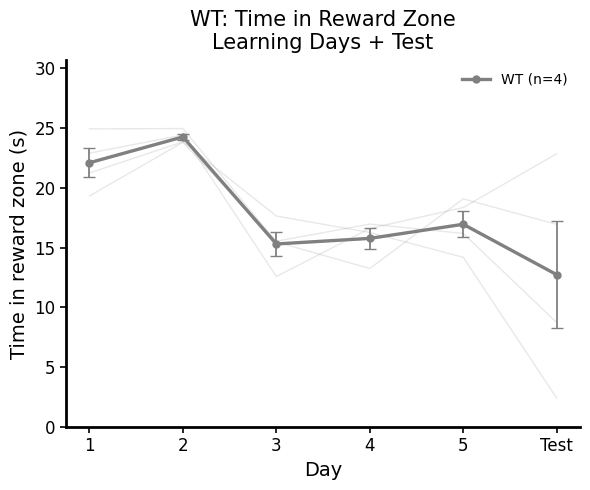

In [102]:
# ============================================================
# WT: Print time in trigger + plot time in trigger across L1-L5 + Test
# Assumes you already have:
#   metadata['pct_time_in_trigger']   # percent
#   metadata['time_in_trigger_s']     # seconds
# ============================================================

# ============================================================
# OPTIONS
# ============================================================
GENOTYPE_TO_PLOT = 'WT'

REQUIRE_COMPLETE = False   # True -> only animals with all L1-L5 + Test
PLOT_INDIVIDUAL = True
PLOT_SEM_ERRORBAR = True

VALUE_COL = 'time_in_trigger_s'
VALUE_LABEL = 'Time in reward zone (s)'

EXCLUDE_ID = []       # e.g. ['AS']
EXCLUDE_SUBS = []     # e.g. [43]

YMIN = 0
YMAX = None           # e.g. 30, or None for auto

# ============================================================
# 1) Filter: genotype, usable, L/T, metric present
# ============================================================
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_PLOT) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[VALUE_COL].notna())
].copy()

if len(EXCLUDE_ID) > 0:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ============================================================
# 2) Assign plot_day: L1-L5 + first post-learning Test = day 6
# ============================================================
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only learning days 1–5
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ============================================================
# 3) Build subject × day matrix
# ============================================================
def build_subject_matrix(meta_group, value_col):
    perf_mat = []
    subjects = []
    animal_ids = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub].copy()

        mean_by_day = ms.groupby('plot_day')[value_col].mean()

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_ids.append(str(ms['id'].dropna().iloc[0]))
        else:
            animal_ids.append(str(sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids

mat_s, subs, ids = build_subject_matrix(meta_LT, VALUE_COL)

print(f"{GENOTYPE_TO_PLOT} animals plotted:", len(subs))
print("Animal IDs:", ids)

# ============================================================
# 4) Print average time in trigger per learning day
#    and mean across learning days 1–5
# ============================================================
if mat_s is not None and len(subs) > 0:
    print(f"\n{GENOTYPE_TO_PLOT}: time in trigger per learning day")
    print("-------------------------------------------------")

    for d in [1, 2, 3, 4, 5]:
        j = d - 1
        mean_time = np.nanmean(mat_s[:, j])
        sem_time = np.nanstd(mat_s[:, j], ddof=1) / np.sqrt(np.sum(np.isfinite(mat_s[:, j]))) \
            if np.sum(np.isfinite(mat_s[:, j])) > 1 else 0.0

        n_day = np.sum(np.isfinite(mat_s[:, j]))

        print(
            f"Day {d}: mean = {mean_time:.2f} s, "
            f"SEM = {sem_time:.2f} s, "
            f"n = {n_day}"
        )

    # per-animal mean across L1-L5, then group mean
    per_animal_time_5 = np.nanmean(mat_s[:, 0:5], axis=1)

    overall_mean_time = np.nanmean(per_animal_time_5)
    overall_sem_time = (
        np.nanstd(per_animal_time_5, ddof=1) / np.sqrt(np.sum(np.isfinite(per_animal_time_5)))
        if np.sum(np.isfinite(per_animal_time_5)) > 1
        else 0.0
    )

    print(f"\n{GENOTYPE_TO_PLOT}: mean across learning days 1–5")
    print("-------------------------------------------------")
    print(
        f"Mean = {overall_mean_time:.2f} s, "
        f"SEM = {overall_sem_time:.2f} s, "
        f"n = {np.sum(np.isfinite(per_animal_time_5))}"
    )

else:
    print(f"\nNo {GENOTYPE_TO_PLOT} animals with valid {VALUE_COL} values.")

# ============================================================
# 5) Plot: time in trigger across L1-L5 + Test
# ============================================================
fig, ax = plt.subplots(figsize=(6, 5))

if mat_s is not None and len(subs) > 0:
    try:
        col = get_genotype_color(GENOTYPE_TO_PLOT)
    except Exception:
        col = 'k'

    if PLOT_INDIVIDUAL:
        for row in mat_s:
            ax.plot(
                x_vals,
                row,
                '-',
                color=col,
                alpha=0.18,
                linewidth=1.0,
                zorder=1
            )

    mean_ = np.nanmean(mat_s, axis=0)

    sem_ = np.zeros(mat_s.shape[1])
    for i in range(mat_s.shape[1]):
        vals = mat_s[:, i]
        vals = vals[np.isfinite(vals)]
        if len(vals) > 1:
            sem_[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))
        else:
            sem_[i] = 0.0

    ax.plot(
        x_vals,
        mean_,
        '-o',
        color=col,
        linewidth=2.4,
        markersize=5,
        label=f'{GENOTYPE_TO_PLOT} (n={len(subs)})',
        zorder=3
    )

    if PLOT_SEM_ERRORBAR:
        ax.errorbar(
            x_vals,
            mean_,
            yerr=sem_,
            fmt='none',
            ecolor=col,
            capsize=4,
            elinewidth=1.3,
            zorder=4
        )

ax.set_xlabel('Day', fontsize=14)
ax.set_ylabel(VALUE_LABEL, fontsize=14)

ax.set_xticks(np.arange(6))
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.set_title(
    f'{GENOTYPE_TO_PLOT}: Time in Reward Zone\nLearning Days + Test',
    fontsize=15,
    pad=8
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.2)

if YMAX is not None:
    ax.set_ylim(YMIN, YMAX)
else:
    if mat_s is not None and np.any(np.isfinite(mat_s)):
        ymax = np.nanmax(mean_ + sem_)
        ax.set_ylim(YMIN, ymax * 1.25 if ymax > 0 else 1)

ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Animals included (n):
  ChR2: 12
  eYFP_ChR2: 5


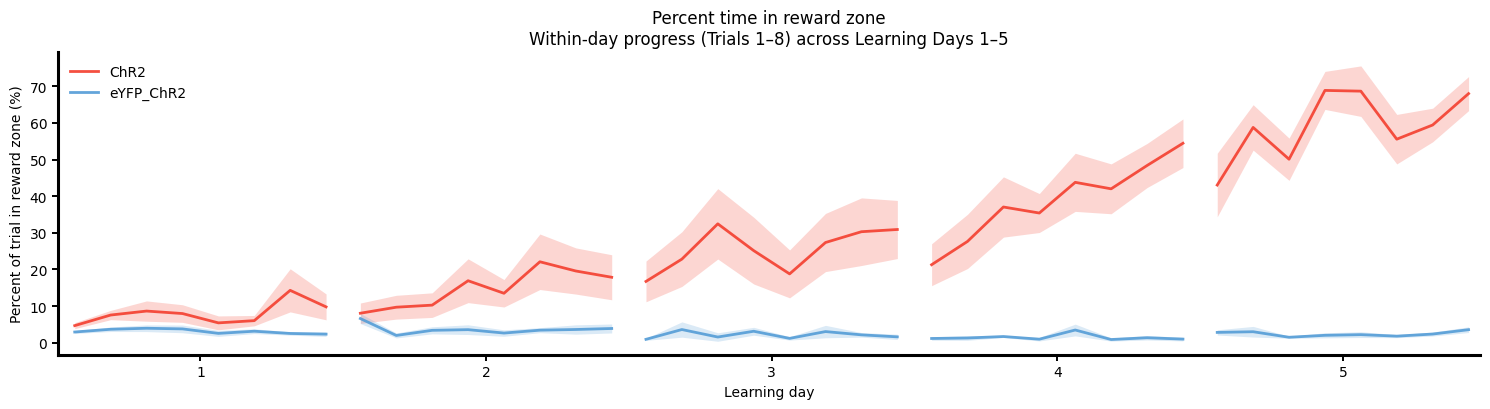

In [15]:
# ------------------------------------------------------------
# 4) Plot helper: within-day curves with shaded SEM
#    (mean ± SEM only; no individual background lines)
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, genotype_key,
                           label=None,
                           alpha_fill=0.22,
                           alpha_line=0.9):
    """
    meta_g:   subset of metadata for a given group
    genotype_key: key for get_genotype_color, e.g. 'ChR2', 'eYFP_ChR2', 'ChR2_short', 'Hp'
    label:    legend label (shown once per group)
    """
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin
    col = get_genotype_color(genotype_key)

    first_day = True  # to only add legend entry once

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # shaded SEM band
        ax.fill_between(
            x,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=alpha_fill,
            linewidth=0
        )

        # mean line (no markers)
        ax.plot(
            x, mean_,
            '-',
            color=col,
            alpha=alpha_line,
            linewidth=2.0,
            label=label if first_day and (label is not None) else None
        )

        first_day = False


# ------------------------------------------------------------
# 5) Nature-style axes (thicker frame)
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)

    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)


# ------------------------------------------------------------
# 6) Split by genotype
# ------------------------------------------------------------
meta_ChR2 = meta_L[meta_L['genotype'] == 'ChR2'].copy()
meta_eYFP = meta_L[meta_L['genotype'] == 'eYFP_ChR2'].copy()
#meta_Hp   = meta_L[meta_L['genotype'] == 'Hp'].copy()
#meta_ChR2 = meta_L[meta_L['genotype'] == 'F231A'].copy()
#meta_eYFP = meta_L[meta_L['genotype'] == 'F231A_wt'].copy()

# If plotting long vs short separately later:
# meta_ChR2_long = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'L') &
#     (meta_L['short_duration'] == 0)
# ].copy()
#
# meta_ChR2_short = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'SL') &
#     (meta_L['short_duration'] == 1)
# ].copy()

print("Animals included (n):")
print("  ChR2:", meta_ChR2['sub'].nunique())
print("  eYFP_ChR2:", meta_eYFP['sub'].nunique())
# print("  Hp:", meta_Hp['sub'].nunique())


# ------------------------------------------------------------
# 7) Plot (mean curves + shaded SEM)
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

# main two groups
plot_within_day_curves(
    ax,
    meta_ChR2,
    genotype_key='ChR2',
    label='ChR2',
    alpha_fill=0.22,
    alpha_line=0.95
)

plot_within_day_curves(
    ax,
    meta_eYFP,
    genotype_key='eYFP_ChR2',
    label='eYFP_ChR2',
    alpha_fill=0.22,
    alpha_line=0.95
)

# If you later want Hp:
# plot_within_day_curves(
#     ax,
#     meta_Hp,
#     genotype_key='Hp',
#     label='Hp',
#     alpha_fill=0.22,
#     alpha_line=0.95
# )

# If you later want ChR2 long vs ChR2_short:
# plot_within_day_curves(
#     ax,
#     meta_ChR2_long,
#     genotype_key='ChR2',
#     label='ChR2 long',
#     alpha_fill=0.18,
#     alpha_line=0.9
# )
#
# plot_within_day_curves(
#     ax,
#     meta_ChR2_short,
#     genotype_key='ChR2_short',
#     label='ChR2 short',
#     alpha_fill=0.22,
#     alpha_line=0.95
# )

ax.set_xlabel('Learning day')
ax.set_ylabel('Percent of trial in reward zone (%)')

# Put day labels in the middle of each day's cluster
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Reduce left whitespace and ensure day 5 curves are visible
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Percent time in reward zone\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Using genotype: NAc (NAc)
Using trial column: inferred from sub/ses order

Animals included per transition:
  Day 1 best -> Day 2 trial 1: n = 7, animals = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Day 2 best -> Day 3 trial 1: n = 7, animals = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Day 3 best -> Day 4 trial 1: n = 7, animals = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Day 4 best -> Day 5 trial 1: n = 7, animals = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Day 5 best -> Test trial 1: n = 7, animals = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']


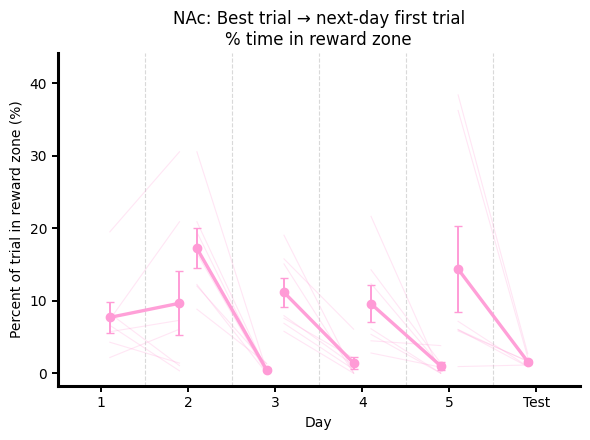

In [61]:
# ============================================================
# Flexible genotype:
# Plot "best trial from previous day" -> "first trial next day"
# Metric: pct_time_in_trigger (% trial in reward zone)
#
# Transitions plotted:
#   Day 1 best  -> Day 2 trial 1
#   Day 2 best  -> Day 3 trial 1
#   Day 3 best  -> Day 4 trial 1
#   Day 4 best  -> Day 5 trial 1
#   Day 5 best  -> Test day trial 1
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
GENOTYPE_TO_USE = 'NAc'
# GENOTYPE_TO_USE = 'ChR2'
# GENOTYPE_TO_USE = 'CA1'
# GENOTYPE_TO_USE = 'CA3'
# GENOTYPE_TO_USE = 'eYFP_ChR2'
# GENOTYPE_TO_USE = 'NAc_control'
# GENOTYPE_TO_USE = 'CA1_control'

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'Hp': 'Hp',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'Control': 'Control',
}

VALUE_COL = 'pct_time_in_trigger'

PLOT_INDIVIDUAL = True   # False → only mean ± SEM

EXCLUDE_SHORT_DURATION = False
EXCLUDE_ID = ['AS', 'AN']
EXCLUDE_SUBS = []

# y-axis options
YMIN = None              # None -> small negative padding
YMAX = None              # None -> auto
Y_BOTTOM_PAD_FRAC = 0.04

# x positions
x_best_offset  = 0.6
x_first_offset = 0.4

plot_days = np.array([1, 2, 3, 4, 5, 6])

# ------------------------------------------------------------
# 1) Filter: usable, selected genotype, L/T, metric available
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_USE) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[VALUE_COL].notna())
].copy()

if EXCLUDE_SHORT_DURATION and 'short_duration' in meta_LT.columns:
    meta_LT = meta_LT[meta_LT['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
#    L -> 1..5
#    first T session after last L -> 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only learning days 1..5 for L
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8
#    Prefer existing column if present; otherwise infer from order
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

print("Using genotype:", GENOTYPE_TO_USE, f"({DISPLAY_NAME.get(GENOTYPE_TO_USE, GENOTYPE_TO_USE)})")
print("Using trial column:", trial_col if trial_col is not None else "inferred from sub/ses order")

# ------------------------------------------------------------
# 4) For each animal and day:
#    - best trial = max pct_time_in_trigger within that day
#    - first trial = trial_in_day == 1
# ------------------------------------------------------------
def per_subject_day_values(meta_g, day):
    """
    Returns one row per animal:
      sub, id, best_val, first_val
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'best_val', 'first_val'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        # mean per trial if duplicate rows exist
        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[VALUE_COL]
              .mean()
              .sort_index()
        )

        if len(by_trial) == 0:
            continue

        best_val = np.nanmax(by_trial.values.astype(float))
        first_val = by_trial.get(1, np.nan)

        if not np.isfinite(best_val) or not np.isfinite(first_val):
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'best_val': float(best_val),
            'first_val': float(first_val)
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5) Build transition values:
#    day d best -> day d+1 first
#    for d = 1..4, and day 5 -> day 6/Test
# ------------------------------------------------------------
transitions = []

for d_prev, d_next in [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6)]:
    prev_df = (
        per_subject_day_values(meta_LT, d_prev)[['sub', 'id', 'best_val']]
        .rename(columns={'best_val': 'y_prev'})
    )

    next_df = (
        per_subject_day_values(meta_LT, d_next)[['sub', 'first_val']]
        .rename(columns={'first_val': 'y_next'})
    )

    merged = prev_df.merge(next_df, on='sub', how='inner').dropna()

    transitions.append({
        'd_prev': d_prev,
        'd_next': d_next,
        'df': merged
    })

# print animal counts used per transition
print("\nAnimals included per transition:")

for tr in transitions:
    n = len(tr['df'])
    d_prev = tr['d_prev']
    d_next = tr['d_next']
    nxt_label = 'Test' if d_next == 6 else f'Day {d_next}'

    ids = list(tr['df']['id']) if n > 0 and 'id' in tr['df'].columns else []

    print(
        f"  Day {d_prev} best -> {nxt_label} trial 1: "
        f"n = {n}, animals = {ids}"
    )

# ------------------------------------------------------------
# 6) Plot helper
# ------------------------------------------------------------
def mean_sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan, np.nan

    if len(x) == 1:
        return x[0], 0.0

    return np.nanmean(x), np.nanstd(x, ddof=1) / np.sqrt(len(x))


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)

# ------------------------------------------------------------
# 7) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))

col = get_genotype_color(GENOTYPE_TO_USE)

all_y = []

for tr in transitions:
    d_prev = tr['d_prev']
    d_next = tr['d_next']
    df_tr  = tr['df']

    if len(df_tr) == 0:
        continue

    x_prev = d_prev + x_best_offset
    x_next = d_next + x_first_offset

    y_prev = df_tr['y_prev'].values.astype(float)
    y_next = df_tr['y_next'].values.astype(float)

    all_y.extend(y_prev[np.isfinite(y_prev)])
    all_y.extend(y_next[np.isfinite(y_next)])

    # --------------------------------------------------------
    # 1) Individual animal lines
    # --------------------------------------------------------
    if PLOT_INDIVIDUAL:
        for _, row in df_tr.iterrows():
            ax.plot(
                [x_prev, x_next],
                [row['y_prev'], row['y_next']],
                color=col,
                linewidth=0.8,
                alpha=0.25,
                zorder=1
            )

    # --------------------------------------------------------
    # 2) Group mean ± SEM
    # --------------------------------------------------------
    m_prev, s_prev = mean_sem(y_prev)
    m_next, s_next = mean_sem(y_next)

    # mean connecting line
    ax.plot(
        [x_prev, x_next],
        [m_prev, m_next],
        '-',
        color=col,
        linewidth=2.4,
        alpha=0.95,
        zorder=3
    )

    # mean points + SEM
    ax.errorbar(
        x_prev,
        m_prev,
        yerr=s_prev,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

    ax.errorbar(
        x_next,
        m_next,
        yerr=s_next,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------
for d in [2, 3, 4, 5, 6]:
    ax.axvline(
        d,
        color='0.85',
        linestyle='--',
        linewidth=0.8,
        zorder=0
    )

ax.set_xticks([1.5, 2.5, 3.5, 4.5, 5.5, 6.5])
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'])

ax.set_xlim(1.0, 7.0)

ax.set_xlabel('Day')
ax.set_ylabel('Percent of trial in reward zone (%)')

genotype_label = DISPLAY_NAME.get(GENOTYPE_TO_USE, GENOTYPE_TO_USE)

ax.set_title(
    f'{genotype_label}: Best trial → next-day first trial\n'
    '% time in reward zone',
    fontsize=12
)

# y-axis
if YMAX is not None:
    ymax = YMAX
else:
    if len(all_y) > 0:
        ymax = np.nanmax(all_y)
        if not np.isfinite(ymax) or ymax <= 0:
            ymax = 1.0
        ymax = ymax * 1.15
    else:
        ymax = 1.0

if YMIN is not None:
    ymin = YMIN
else:
    ymin = -Y_BOTTOM_PAD_FRAC * ymax

ax.set_ylim(ymin, ymax)

style_nature(ax)

plt.tight_layout()
plt.show()

Using trial column: inferred from sub/ses order
Wilcoxon alternative used: greater

Animals included per within-day comparison:
  Day 1: n = 7, animals = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Day 2: n = 7, animals = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Day 3: n = 7, animals = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Day 4: n = 7, animals = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Day 5: n = 7, animals = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Test: n = 7, one test dot only, animals = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']

Wilcoxon signed-rank tests: first trial vs best trial of same day
Alternative used: greater
Test day skipped because there is only one test trial.
  Day 1: n = 7, first mean = 2.702, best mean = 7.704, median diff = 3.103, W = 28.000, p = 0.00781
  Day 2: n = 7, first mean = 9.656, best mean = 17.219, median diff = 10.625, W = 15.000, p = 0.02156
  Day 3: n = 7, first mean = 0.487, best mean = 11.155, median diff = 7.583, W = 28.000, p

/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


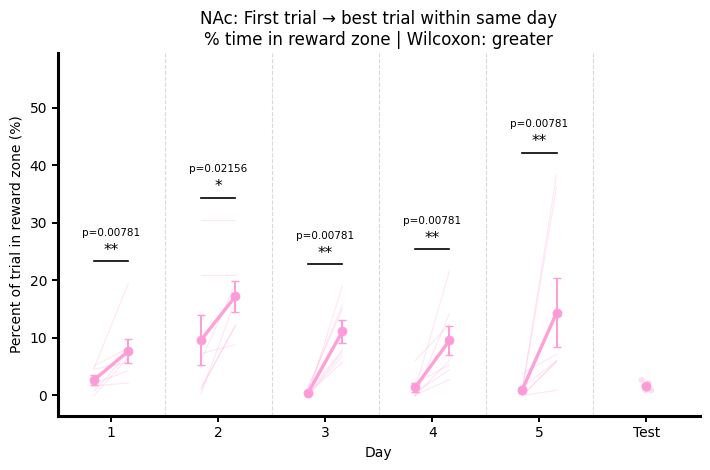

In [69]:
# ============================================================
# ChR2 only:
# Plot "first trial of each day" -> "best trial of same day"
# Metric: pct_time_in_trigger (% trial in reward zone)
#
# Within-day progress:
#   Day 1 trial 1 -> Day 1 best trial
#   Day 2 trial 1 -> Day 2 best trial
#   Day 3 trial 1 -> Day 3 best trial
#   Day 4 trial 1 -> Day 4 best trial
#   Day 5 trial 1 -> Day 5 best trial
#   Test day: only one dot, no paired line/statistics
#
# Stats:
#   Wilcoxon signed-rank test, paired within animal, for days 1-5 only
#   alternative='greater' tests whether best > first
#   alternative='two-sided' tests whether first and best are different
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
PLOT_INDIVIDUAL = True       # False → only mean ± SEM
GENOTYPE_TO_USE = 'NAc'

VALUE_COL = 'pct_time_in_trigger'
# VALUE_COL = 'time_in_trigger_s'   # if you want to plot time instead of percent

EXCLUDE_SHORT_DURATION = True

# Wilcoxon:
# 'greater' = tests whether best trial > first trial
# 'less' = tests whether best trial < first trial
# 'two-sided' = tests whether first and best are different
WILCOXON_ALTERNATIVE = 'greater'

SHOW_P_VALUES = True
SHOW_STARS = True

P_DECIMALS = 5

# x-axis positioning
X_FIRST_OFFSET = -0.16
X_BEST_OFFSET  =  0.16

# p-value/star spacing
P_LINE_FRAC_ABOVE = 0.10
STAR_FRAC_ABOVE_LINE = 0.015
P_FRAC_ABOVE_STAR = 0.09

# y-axis
YMIN = None
YMAX = None
Y_BOTTOM_PAD_FRAC = 0.06

plot_days = np.array([1, 2, 3, 4, 5, 6])

# ------------------------------------------------------------
# 1) Filter: usable, not short, selected genotype, L/T, metric available
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_USE) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[VALUE_COL].notna())
].copy()

if EXCLUDE_SHORT_DURATION and 'short_duration' in meta_LT.columns:
    meta_LT = meta_LT[meta_LT['short_duration'] != 1].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
#    L -> 1..5
#    first T session after last L -> 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

print("Using trial column:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Wilcoxon alternative used:", WILCOXON_ALTERNATIVE)

# ------------------------------------------------------------
# 4) For each animal and day:
#    - first trial = trial_in_day == 1
#    - best trial = max pct_time_in_trigger within same day
# ------------------------------------------------------------
def per_subject_day_first_best(meta_g, day):
    """
    Returns one row per animal:
      sub, id, first_val, best_val
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'first_val', 'best_val'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[VALUE_COL]
              .mean()
              .sort_index()
        )

        if len(by_trial) == 0:
            continue

        first_val = by_trial.get(1, np.nan)
        best_val = np.nanmax(by_trial.values.astype(float))

        if not np.isfinite(first_val) or not np.isfinite(best_val):
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'first_val': float(first_val),
            'best_val': float(best_val)
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5) Build within-day comparison values
# ------------------------------------------------------------
within_day = []

for d in plot_days:
    df_d = per_subject_day_first_best(meta_LT, d)

    within_day.append({
        'day': d,
        'df': df_d
    })

print("\nAnimals included per within-day comparison:")
for wd in within_day:
    d = wd['day']
    df_d = wd['df']
    day_label = 'Test' if d == 6 else f'Day {d}'

    if d == 6:
        print(
            f"  {day_label}: n = {len(df_d)}, "
            f"one test dot only, animals = {list(df_d['id']) if len(df_d) > 0 else []}"
        )
    else:
        print(
            f"  {day_label}: n = {len(df_d)}, "
            f"animals = {list(df_d['id']) if len(df_d) > 0 else []}"
        )

# ------------------------------------------------------------
# 6) Stats + plotting helpers
# ------------------------------------------------------------
def mean_sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan, np.nan

    if len(x) == 1:
        return x[0], 0.0

    return np.nanmean(x), np.nanstd(x, ddof=1) / np.sqrt(len(x))


def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def run_wilcoxon_paired(first_vals, best_vals, alternative='greater'):
    first_vals = np.asarray(first_vals, float)
    best_vals = np.asarray(best_vals, float)

    ok = np.isfinite(first_vals) & np.isfinite(best_vals)
    first_vals = first_vals[ok]
    best_vals = best_vals[ok]

    if len(first_vals) == 0:
        return np.nan, np.nan

    diffs = best_vals - first_vals

    if np.allclose(diffs, 0):
        return 0.0, 1.0

    try:
        stat, p = wilcoxon(
            best_vals,
            first_vals,
            alternative=alternative,
            zero_method='wilcox'
        )
    except ValueError:
        stat, p = np.nan, np.nan

    return stat, p


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)

# ------------------------------------------------------------
# 7) Run stats first: days 1-5 only
# ------------------------------------------------------------
print("\nWilcoxon signed-rank tests: first trial vs best trial of same day")
print(f"Alternative used: {WILCOXON_ALTERNATIVE}")
print("Test day skipped because there is only one test trial.")

stats_results = {}

for wd in within_day:
    d = wd['day']
    df_d = wd['df']

    day_label = 'Test' if d == 6 else f'Day {d}'

    if d == 6:
        stats_results[d] = {
            'stat': np.nan,
            'p': np.nan,
            'n': len(df_d)
        }
        print(f"  {day_label}: n = {len(df_d)}, no stats")
        continue

    if len(df_d) == 0:
        stats_results[d] = {
            'stat': np.nan,
            'p': np.nan,
            'n': 0
        }
        print(f"  {day_label}: n = 0, p = NaN")
        continue

    first_vals = df_d['first_val'].values.astype(float)
    best_vals = df_d['best_val'].values.astype(float)

    stat, p = run_wilcoxon_paired(
        first_vals,
        best_vals,
        alternative=WILCOXON_ALTERNATIVE
    )

    stats_results[d] = {
        'stat': stat,
        'p': p,
        'n': len(df_d)
    }

    print(
        f"  {day_label}: "
        f"n = {len(df_d)}, "
        f"first mean = {np.nanmean(first_vals):.3f}, "
        f"best mean = {np.nanmean(best_vals):.3f}, "
        f"median diff = {np.nanmedian(best_vals - first_vals):.3f}, "
        f"W = {stat:.3f}, "
        f"p = {format_p(p, P_DECIMALS)}"
        if np.isfinite(p)
        else
        f"  {day_label}: n = {len(df_d)}, p = NaN"
    )

# ------------------------------------------------------------
# 8) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(7.2, 4.8))

col = get_genotype_color(GENOTYPE_TO_USE)

all_y_for_ylim = []

for wd in within_day:
    d = wd['day']
    df_d = wd['df']

    if len(df_d) == 0:
        continue

    # --------------------------------------------------------
    # Test day: individual dots remain
    # --------------------------------------------------------
    if d == 6:
        x_test = d

        test_vals = df_d['first_val'].values.astype(float)
        test_vals = test_vals[np.isfinite(test_vals)]

        all_y_for_ylim.extend(test_vals)

        if PLOT_INDIVIDUAL:
            x_jitter = np.random.normal(x_test, 0.035, size=len(test_vals))
            ax.scatter(
                x_jitter,
                test_vals,
                color=col,
                s=18,
                alpha=0.35,
                edgecolor='none',
                zorder=2
            )

        m_test, s_test = mean_sem(test_vals)

        ax.errorbar(
            x_test,
            m_test,
            yerr=s_test,
            fmt='o',
            color=col,
            markersize=6,
            capsize=3,
            linewidth=1.4,
            zorder=5
        )

        continue

    # --------------------------------------------------------
    # Learning days 1-5: individual lines only, no individual dots
    # --------------------------------------------------------
    x_first = d + X_FIRST_OFFSET
    x_best  = d + X_BEST_OFFSET

    first_vals = df_d['first_val'].values.astype(float)
    best_vals = df_d['best_val'].values.astype(float)

    all_y_for_ylim.extend(first_vals[np.isfinite(first_vals)])
    all_y_for_ylim.extend(best_vals[np.isfinite(best_vals)])

    if PLOT_INDIVIDUAL:
        for _, row in df_d.iterrows():
            ax.plot(
                [x_first, x_best],
                [row['first_val'], row['best_val']],
                color=col,
                linewidth=0.8,
                alpha=0.25,
                zorder=1
            )

    # group mean ± SEM dots remain
    m_first, s_first = mean_sem(first_vals)
    m_best, s_best = mean_sem(best_vals)

    ax.plot(
        [x_first, x_best],
        [m_first, m_best],
        '-',
        color=col,
        linewidth=2.4,
        alpha=0.95,
        zorder=4
    )

    ax.errorbar(
        x_first,
        m_first,
        yerr=s_first,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=5
    )

    ax.errorbar(
        x_best,
        m_best,
        yerr=s_best,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=5
    )

# ------------------------------------------------------------
# 9) Add p-value bars after determining y scale: days 1-5 only
# ------------------------------------------------------------
if len(all_y_for_ylim) > 0:
    y_data_max = np.nanmax(all_y_for_ylim)
    y_data_min = np.nanmin(all_y_for_ylim)

    yrng = y_data_max - y_data_min
    if not np.isfinite(yrng) or yrng <= 0:
        yrng = max(abs(y_data_max), 1.0)

    for wd in within_day:
        d = wd['day']
        df_d = wd['df']

        if d == 6:
            continue

        if len(df_d) == 0:
            continue

        x_first = d + X_FIRST_OFFSET
        x_best  = d + X_BEST_OFFSET
        x_mid = (x_first + x_best) / 2

        local_max = np.nanmax(
            np.r_[
                df_d['first_val'].values.astype(float),
                df_d['best_val'].values.astype(float)
            ]
        )

        y_line = local_max + P_LINE_FRAC_ABOVE * yrng
        y_star = y_line + STAR_FRAC_ABOVE_LINE * yrng
        y_pval = y_star + P_FRAC_ABOVE_STAR * yrng

        p = stats_results[d]['p']

        ax.plot(
            [x_first, x_best],
            [y_line, y_line],
            color='black',
            linewidth=1.2,
            zorder=6
        )

        if SHOW_STARS:
            ax.text(
                x_mid,
                y_star,
                p_to_stars(p),
                ha='center',
                va='bottom',
                fontsize=11,
                zorder=7
            )

        if SHOW_P_VALUES:
            ax.text(
                x_mid,
                y_pval,
                f"p={format_p(p, P_DECIMALS)}",
                ha='center',
                va='bottom',
                fontsize=7.5,
                zorder=7
            )

# ------------------------------------------------------------
# 10) Styling
# ------------------------------------------------------------
for d in [1.5, 2.5, 3.5, 4.5, 5.5]:
    ax.axvline(d, color='0.85', linestyle='--', linewidth=0.8, zorder=0)

ax.set_xticks(plot_days)
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'])

ax.set_xlim(0.5, 6.5)

ax.set_xlabel('Day')
ax.set_ylabel('Percent of trial in reward zone (%)')

ax.set_title(
    f'{GENOTYPE_TO_USE}: First trial → best trial within same day\n'
    f'% time in reward zone | Wilcoxon: {WILCOXON_ALTERNATIVE}',
    fontsize=12
)

if YMAX is not None:
    ymax = YMAX
else:
    if len(all_y_for_ylim) > 0:
        ymax = np.nanmax(all_y_for_ylim)
        if not np.isfinite(ymax) or ymax <= 0:
            ymax = 1.0
        ymax = ymax * 1.55
    else:
        ymax = 1.0

if YMIN is not None:
    ymin = YMIN
else:
    ymin = -Y_BOTTOM_PAD_FRAC * ymax

ax.set_ylim(ymin, ymax)

style_nature(ax)

plt.tight_layout()
plt.show()

Using genotype: NAc (NAc)
Using value column: pct_time_in_trigger
Using trial column: inferred from sub/ses order
Wilcoxon alternative used: two-sided

Animals included: n = 7
   sub  id  Day 1 trial 1 trials  Test trials
0   64  N1                     1            1
1   65  N2                     1            1
2   66  N3                     1            1
3   67  N4                     1            1
4   68  N5                     1            1
5   69  N6                     1            1
6   70  N7                     1            1

Paired values used for Wilcoxon:
   sub  id        y1        y2  diff_y2_minus_y1  n1  n2
0   64  N1  5.143477  0.929403         -4.214074   1   1
1   65  N2  2.120647  2.693690          0.573043   1   1
2   66  N3  4.579270  1.135612         -3.443658   1   1
3   67  N4  0.000000  2.178375          2.178375   1   1
4   68  N5  1.657581  0.898322         -0.759259   1   1
5   69  N6  4.727081  1.685017         -3.042064   1   1
6   70  N7  0.686143  1

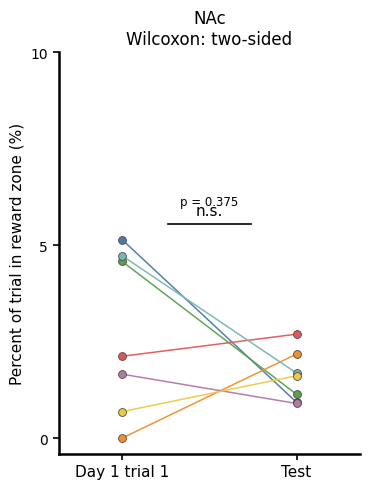

In [76]:
from scipy.stats import wilcoxon
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Flexible genotype:
# Paired comparison for % time in reward zone
#
# COMPARE_MODE:
#   'day1_vs_test':
#       Day 1 = trial 1 only
#       Test  = first post-learning test trial only
#
#   'day1_vs_day5':
#       Day 1 = mean across available Day 1 trials
#       Day 5 = mean across available Day 5 trials
#
# Stats:
#   Wilcoxon signed-rank test, paired within animal
# ============================================================

# ============================================================
# OPTIONS
# ============================================================
COMPARE_MODE = 'day1_vs_test'   # 'day1_vs_test' or 'day1_vs_day5'

GENOTYPE_TO_USE = 'NAc'         # e.g. 'ChR2', 'CA1', 'CA3', 'NAc', 'eYFP_ChR2', 'CA1_control'

PLOT_INDIVIDUAL = True
PLOT_GROUP_MEAN = False         # False -> hide thick mean/SEM overlay
SHOW_ANIMAL_IDS = False

VALUE_COL = 'pct_time_in_trigger'

# Wilcoxon:
# 'two-sided' = tests whether paired values are different
# 'greater'   = tests whether first value > second value
# 'less'      = tests whether first value < second value
WILCOXON_ALTERNATIVE = 'two-sided'

# individual animal colour style:
#   'pastel' -> each animal gets a different pastel colour
#   'shades' -> animals are different shades of genotype colour
INDIVIDUAL_COLOR_MODE = 'pastel'

# whether to draw a thin edge around each dot
DOT_EDGE = True

EXCLUDE_ID = ['AS', 'AN']
EXCLUDE_SUBS = []

# y-axis padding
YMIN = None
YMAX = 10
Y_TICK_STEP = 5.0
Y_BOTTOM_PAD_FRAC = 0.04

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'Control': 'Control',
}

GENOTYPE_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_USE, GENOTYPE_TO_USE)

# ------------------------------------------------------------
# 1) Filter: usable, selected genotype, L/T, metric available
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_USE) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[VALUE_COL].notna())
].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.array([1, 2, 3, 4, 5, 6])
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

print("Using genotype:", GENOTYPE_LABEL, f"({GENOTYPE_TO_USE})")
print("Using value column:", VALUE_COL)
print("Using trial column:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Wilcoxon alternative used:", WILCOXON_ALTERNATIVE)

# ------------------------------------------------------------
# 4) Per-subject helpers
# ------------------------------------------------------------
def per_subject_day_mean(meta_g, day):
    """
    One value per animal = mean across available trials in that day.
    Used for day1_vs_day5.
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'mean_val', 'n_trials'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[VALUE_COL]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if len(by_trial) == 0:
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'mean_val': np.nanmean(by_trial.values),
            'n_trials': len(by_trial)
        })

    return pd.DataFrame(rows)


def per_subject_day_first_trial(meta_g, day):
    """
    One value per animal = trial 1 only from that day.
    Used for day1_vs_test:
      Day 1 = trial 1 only
      Test  = test trial 1 only
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'mean_val', 'n_trials'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[VALUE_COL]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if 1 not in by_trial.index:
            continue

        val = by_trial.loc[1]

        if not np.isfinite(val):
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'mean_val': float(val),
            'n_trials': 1
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5) Build paired dataframe
# ------------------------------------------------------------
if COMPARE_MODE == 'day1_vs_test':
    day1_df = per_subject_day_first_trial(meta_LT, 1)
    comp_df = per_subject_day_first_trial(meta_LT, 6)

    left_label = 'Day 1 trial 1'
    right_label = 'Test'
    title_txt = GENOTYPE_LABEL

elif COMPARE_MODE == 'day1_vs_day5':
    day1_df = per_subject_day_mean(meta_LT, 1)
    comp_df = per_subject_day_mean(meta_LT, 5)

    left_label = 'Day 1'
    right_label = 'Day 5'
    title_txt = GENOTYPE_LABEL

else:
    raise ValueError("COMPARE_MODE must be 'day1_vs_test' or 'day1_vs_day5'")

paired = (
    day1_df[['sub', 'id', 'mean_val', 'n_trials']]
    .rename(columns={'mean_val': 'y1', 'n_trials': 'n1'})
    .merge(
        comp_df[['sub', 'mean_val', 'n_trials']]
        .rename(columns={'mean_val': 'y2', 'n_trials': 'n2'}),
        on='sub',
        how='inner'
    )
    .dropna()
    .sort_values('sub')
    .reset_index(drop=True)
)

paired['diff_y2_minus_y1'] = paired['y2'] - paired['y1']

print(f'\nAnimals included: n = {len(paired)}')
print(
    paired[['sub', 'id', 'n1', 'n2']]
    .rename(columns={'n1': f'{left_label} trials', 'n2': f'{right_label} trials'})
)

print("\nPaired values used for Wilcoxon:")
print(paired[['sub', 'id', 'y1', 'y2', 'diff_y2_minus_y1', 'n1', 'n2']])

# ------------------------------------------------------------
# 6) Wilcoxon signed-rank test
# ------------------------------------------------------------
y1 = paired['y1'].values.astype(float)
y2 = paired['y2'].values.astype(float)

if len(y1) > 0:
    diffs = y2 - y1

    if np.allclose(diffs, 0):
        stat_w, p_w = 0.0, 1.0
    else:
        try:
            stat_w, p_w = wilcoxon(
                y1,
                y2,
                alternative=WILCOXON_ALTERNATIVE,
                zero_method='wilcox'
            )
        except ValueError:
            stat_w, p_w = np.nan, np.nan
else:
    stat_w, p_w = np.nan, np.nan

print(
    f"\nWilcoxon signed-rank p = {p_w:.5f}"
    if np.isfinite(p_w)
    else "\nWilcoxon signed-rank p = NaN"
)

print(f"The Wilcoxon test is run on {len(y1)} paired animal values.")

if COMPARE_MODE == 'day1_vs_test':
    print("Day 1 value = first trial of Day 1 only.")
    print("Test value = first trial of first post-learning test session only.")
else:
    print("Day 1 value = mean across available Day 1 trials.")
    print("Day 5 value = mean across available Day 5 trials.")

# ------------------------------------------------------------
# 7) Helpers
# ------------------------------------------------------------
def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', length=4, width=1.2)
    ax.grid(False)


def lighten_color(color, amount=0.5):
    c = np.array(mcolors.to_rgb(color))
    return tuple(1 - amount * (1 - c))


def get_nature_palette(n):
    palette = [
        '#4E79A7',
        '#E15759',
        '#59A14F',
        '#F28E2B',
        '#B07AA1',
        '#76B7B2',
        '#EDC948',
        '#FF9DA7',
        '#9C755F',
        '#BAB0AC',
        '#86BCB6',
        '#D37295',
        '#8CD17D',
        '#F1CE63',
        '#499894',
        '#E17C05',
    ]

    return [palette[i % len(palette)] for i in range(n)]

# ------------------------------------------------------------
# 8) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(3.8, 5.0))

base_col = get_genotype_color(GENOTYPE_TO_USE)

x1, x2 = 0.00, 0.55

n_animals = len(paired)

if INDIVIDUAL_COLOR_MODE == 'pastel':
    indiv_cols = get_nature_palette(n_animals)
elif INDIVIDUAL_COLOR_MODE == 'shades':
    shade_vals = np.linspace(0.35, 0.95, max(n_animals, 2))
    indiv_cols = [lighten_color(base_col, amount=s) for s in shade_vals[:n_animals]]
else:
    raise ValueError("INDIVIDUAL_COLOR_MODE must be 'pastel' or 'shades'")

dot_edgecolor = '#4a4a4a' if DOT_EDGE else 'none'
dot_linewidth = 0.6 if DOT_EDGE else 0.0

# individual paired lines
if PLOT_INDIVIDUAL:
    for i, (_, row) in enumerate(paired.iterrows()):
        this_col = indiv_cols[i]

        ax.plot(
            [x1, x2],
            [row['y1'], row['y2']],
            color=this_col,
            linewidth=1.1,
            alpha=0.95,
            zorder=1
        )

        ax.scatter(
            [x1, x2],
            [row['y1'], row['y2']],
            s=32,
            color=this_col,
            edgecolor=dot_edgecolor,
            linewidth=dot_linewidth,
            zorder=2
        )

        if SHOW_ANIMAL_IDS:
            ax.text(
                x2 + 0.03,
                row['y2'],
                str(row['id']),
                fontsize=6.5,
                alpha=0.8,
                va='center'
            )

# optional group mean ± SEM
if PLOT_GROUP_MEAN and len(y1) > 0:
    m1 = np.nanmean(y1)
    m2 = np.nanmean(y2)

    s1 = 0.0 if len(y1) <= 1 else np.nanstd(y1, ddof=1) / np.sqrt(len(y1))
    s2 = 0.0 if len(y2) <= 1 else np.nanstd(y2, ddof=1) / np.sqrt(len(y2))

    ax.plot(
        [x1, x2],
        [m1, m2],
        '-',
        color=base_col,
        linewidth=2.4,
        zorder=3
    )

    ax.errorbar(
        x1,
        m1,
        yerr=s1,
        fmt='o',
        color=base_col,
        markersize=7,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

    ax.errorbar(
        x2,
        m2,
        yerr=s2,
        fmt='o',
        color=base_col,
        markersize=7,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

# significance line + stars + p value
if len(y1) > 0:
    ymax_data = np.nanmax(np.r_[y1, y2])
else:
    ymax_data = 1.0

yrng = ymax_data if ymax_data > 0 else 1.0

y_line = ymax_data + 0.08 * yrng
y_star = ymax_data + 0.11 * yrng
y_pval = ymax_data + 0.16 * yrng

xmid = (x1 + x2) / 2
half_len = 0.13

ax.plot(
    [xmid - half_len, xmid + half_len],
    [y_line, y_line],
    color='k',
    lw=1.2,
    zorder=5
)

ax.text(
    xmid,
    y_star,
    p_to_stars(p_w),
    ha='center',
    va='bottom',
    fontsize=11,
    zorder=6
)

ax.text(
    xmid,
    y_pval,
    f'p = {p_w:.3g}' if np.isfinite(p_w) else 'p = NaN',
    ha='center',
    va='bottom',
    fontsize=8.5,
    zorder=6
)

# styling
ax.set_xticks([x1, x2])
ax.set_xticklabels([left_label, right_label], fontsize=11)
ax.set_ylabel('Percent of trial in reward zone (%)', fontsize=11)

ax.set_title(
    f'{title_txt}\nWilcoxon: {WILCOXON_ALTERNATIVE}',
    fontsize=12,
    pad=6
)

ax.set_xlim(-0.20, 0.75)

if YMAX is None:
    # Auto-fit to the highest data point + p-value annotation
    ymax = y_pval + 0.08 * yrng
else:
    ymax = YMAX

if YMIN is None:
    # keeps 0 slightly above x-axis, so low values are visible
    ymin = -Y_BOTTOM_PAD_FRAC * ymax
else:
    ymin = YMIN

ax.set_ylim(ymin, ymax)

# y ticks
if Y_TICK_STEP is not None:
    ax.set_yticks(np.arange(0, ymax + Y_TICK_STEP, Y_TICK_STEP))
else:
    ticks = ax.get_yticks()
    ticks = ticks[ticks >= 0]
    if len(ticks) == 0 or ticks[0] != 0:
        ticks = np.insert(ticks, 0, 0)
    ax.set_yticks(ticks)

style_nature(ax)

plt.tight_layout()
plt.show()

Using metric: pct_time_in_trigger
Trial column used: inferred from sub/ses/trial_id order
ChR2_short IDs requested: ['AI', 'AJ', 'AL']

Comparison 1 LEFT: ChR2_short AI/AJ/AL learning day 10
Trial-level rows included: n rows = 24
Animals included: n = 3
    sub  id    genotype  ses trial_type  trial_type_day  trial_in_day  \
0    13  AI  ChR2_short   13          L              10             1   
1    13  AI  ChR2_short   13          L              10             2   
2    13  AI  ChR2_short   13          L              10             3   
3    13  AI  ChR2_short   13          L              10             4   
4    13  AI  ChR2_short   13          L              10             5   
5    13  AI  ChR2_short   13          L              10             6   
6    13  AI  ChR2_short   13          L              10             7   
7    13  AI  ChR2_short   13          L              10             8   
8    14  AJ  ChR2_short   13          L              10             1   
9    14  AJ  ChR

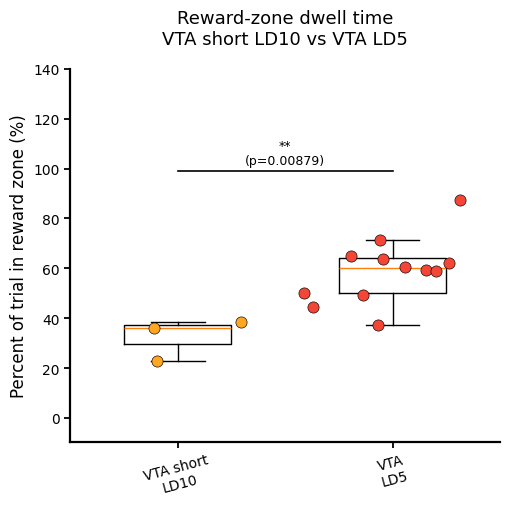


Reward-zone dwell time
VTA short next test vs VTA test
Per-animal values used for statistics:
Left group:
   sub  id      value  n_trials ses_list trial_type_day_list trial_type_list
0   13  AI  62.711707         1     [14]                 [1]             [T]
1   14  AJ  81.331346         1     [14]                 [1]             [T]
2   15  AL  14.514810         1     [14]                 [1]             [T]
Right group:
    sub  id      value  n_trials ses_list trial_type_day_list trial_type_list
0     1   A  39.127131         1      [9]                 [1]             [T]
1     3   C  35.813173         1      [9]                 [1]             [T]
2     4   D  34.689500         1      [9]                 [1]             [T]
3     6  AB  34.628001         1      [9]                 [1]             [T]
4     7  AC  24.925242         1      [9]                 [1]             [T]
5     8  AD  14.517668         1      [9]                 [1]             [T]
6     9  AE  20.549898    

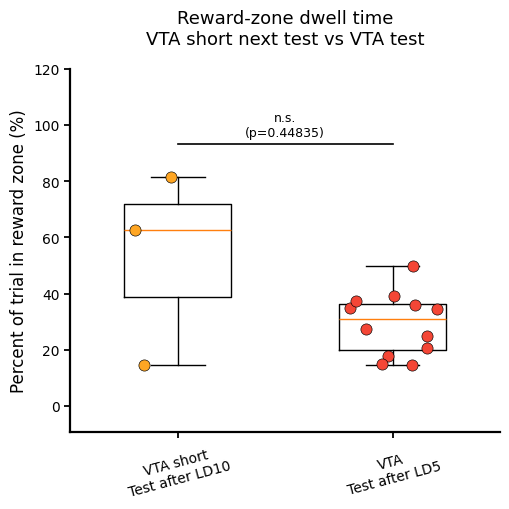

In [153]:
# ============================================================
# Compare ChR2_short extended learning animals vs ChR2 animals
#
# Comparison 1:
#   ChR2_short animals AI/AJ/AL:
#       learning day 10, trial_type_day == 10, trial_type == 'L'
#   vs
#   ChR2 animals:
#       learning day 5, trial_type_day == 5, trial_type == 'L'
#
# Comparison 2:
#   ChR2_short animals AI/AJ/AL:
#       next test day = ses + 1 from the last learning-day-10 session
#   vs
#   ChR2 animals:
#       first test session after learning day 5
#
# Plot style:
#   boxplot + individual dots + Mann–Whitney U test
#
# Metric:
#   VALUE_COL = 'pct_time_in_trigger' or 'time_in_trigger_s'
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ============================================================
# OPTIONS
# ============================================================

VALUE_COL = 'pct_time_in_trigger'
VALUE_LABEL = 'Percent of trial in reward zone (%)'
TITLE_METRIC = 'Reward-zone dwell time'

# VALUE_COL = 'time_in_trigger_s'
# VALUE_LABEL = 'Time spent in reward zone (s)'
# TITLE_METRIC = 'Reward-zone dwell time'

CHR2_SHORT_IDS = ['AI', 'AJ', 'AL']

CH_R2_GENOTYPE = 'ChR2'
CH_R2_SHORT_GENOTYPE = 'ChR2_short'

EXCLUDE_ID = ['AN']      # optional
EXCLUDE_SUBS = []        # optional

REQUIRE_USABLE = True

# Plot options
SHOW_ANIMAL_IDS = False
JITTER = 0.18
DOT_SIZE = 65
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.45

P_DECIMALS = 5

# p-value line spacing
P_LINE_START_FRAC = 0.18
P_TEXT_OFFSET_FRAC = 0.025
P_TOP_PAD_FRAC = 0.35

# y-axis
YMIN = None
YMAX = None              # e.g. 10 for pct_time_in_trigger, or 120 for time_in_trigger_s
Y_BOTTOM_PAD_FRAC = 0.08
Y_TICK_STEP = None       # e.g. 5, 10, 20, or None

np.random.seed(1)

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

# ============================================================
# Helper functions
# ============================================================

def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def style_nature(ax, linewidth=1.6):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.3)
    ax.grid(False)


def get_animal_label(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


def add_trial_in_day(meta_df):
    """
    Create trial_in_day = 1..8.
    Prefer an existing trial column if present.
    Otherwise infer from sorted sub/ses order.
    """
    meta_df = meta_df.copy()

    candidate_cols = [
        'trial_in_day',
        'trial_num',
        'trial_number',
        'trial',
        'trial_idx',
        'trial_index',
        'trial_in_session',
        'trial_id_in_session',
    ]

    trial_col = next((c for c in candidate_cols if c in meta_df.columns), None)

    if trial_col is not None:
        meta_df['trial_in_day'] = meta_df[trial_col].astype(int)
    else:
        sort_cols = ['sub', 'ses']
        if 'trial_id' in meta_df.columns:
            sort_cols.append('trial_id')

        meta_df = meta_df.sort_values(sort_cols).copy()
        meta_df['trial_in_day'] = meta_df.groupby(['sub', 'ses']).cumcount() + 1

    return meta_df, trial_col


def per_animal_mean_from_trials(meta_df, value_col):
    """
    Converts trial-level rows into one value per animal.
    If multiple trials are included for one animal, averages across trials.
    """
    rows = []

    for sub in meta_df['sub'].unique():
        ms = meta_df[meta_df['sub'] == sub].copy()

        vals = ms[value_col].values.astype(float)
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            continue

        rows.append({
            'sub': sub,
            'id': get_animal_label(ms, sub),
            'value': float(np.nanmean(vals)),
            'n_trials': len(vals),
            'ses_list': sorted(ms['ses'].dropna().unique().tolist()) if 'ses' in ms.columns else [],
            'trial_type_day_list': sorted(ms['trial_type_day'].dropna().unique().tolist()) if 'trial_type_day' in ms.columns else [],
            'trial_type_list': sorted(ms['trial_type'].dropna().unique().tolist()) if 'trial_type' in ms.columns else [],
        })

    return pd.DataFrame(rows)


def print_trial_rows(label, meta_df, value_col):
    """
    Print exact trial-level rows used before per-animal averaging.
    """
    print("\n============================================================")
    print(label)
    print(f"Trial-level rows included: n rows = {len(meta_df)}")
    print(f"Animals included: n = {meta_df['sub'].nunique() if len(meta_df) > 0 else 0}")

    cols = [
        'sub',
        'id',
        'genotype',
        'ses',
        'trial_type',
        'trial_type_day',
        'trial_in_day',
    ]

    optional_cols = [
        'trial_id',
        'date',
        'usable',
        'short_duration',
        value_col,
    ]

    cols_to_print = [c for c in cols + optional_cols if c in meta_df.columns]

    if len(meta_df) == 0:
        print("No rows.")
        return

    print(
        meta_df[cols_to_print]
        .sort_values([c for c in ['id', 'sub', 'ses', 'trial_in_day'] if c in cols_to_print])
        .reset_index(drop=True)
    )


def apply_box_y_axis_with_zero_padding(ax, y_top):
    if YMAX is not None:
        y_top = YMAX
    else:
        if not np.isfinite(y_top) or y_top <= 0:
            y_top = 1.0

    if YMIN is not None:
        y_bottom = YMIN
    else:
        y_bottom = -Y_BOTTOM_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if Y_TICK_STEP is not None:
        yticks = np.arange(0, y_top + Y_TICK_STEP, Y_TICK_STEP)
        ax.set_yticks(yticks)
    else:
        ticks = ax.get_yticks()
        ticks = ticks[ticks >= 0]
        if len(ticks) == 0 or ticks[0] != 0:
            ticks = np.insert(ticks, 0, 0)
        ax.set_yticks(ticks)


def plot_two_group_boxplot(
    df_left,
    df_right,
    left_label,
    right_label,
    title,
    ylabel,
):
    """
    Boxplot + individual dots + Mann–Whitney U test.
    df_left / df_right should contain columns:
      sub, id, value, n_trials
    """
    vals_left = df_left['value'].values.astype(float) if len(df_left) > 0 else np.array([])
    vals_right = df_right['value'].values.astype(float) if len(df_right) > 0 else np.array([])

    vals_groups = [vals_left, vals_right]
    positions = np.array([0, 1])

    print("\n============================================================")
    print(title)
    print("Per-animal values used for statistics:")
    print("Left group:")
    print(df_left)
    print("Right group:")
    print(df_right)

    if len(vals_left) > 0 and len(vals_right) > 0:
        stat, p = mannwhitneyu(vals_left, vals_right, alternative='two-sided')
        rank_biserial = (2 * stat) / (len(vals_left) * len(vals_right)) - 1

        print("\nMann–Whitney U test:")
        print(
            f"  {left_label} vs {right_label}: "
            f"n={len(vals_left)} vs {len(vals_right)}, "
            f"mean={np.nanmean(vals_left):.3f} vs {np.nanmean(vals_right):.3f}, "
            f"median={np.nanmedian(vals_left):.3f} vs {np.nanmedian(vals_right):.3f}, "
            f"U={stat:.1f}, "
            f"rank-biserial={rank_biserial:.3f}, "
            f"p={format_p(p, P_DECIMALS)}"
        )
    else:
        stat, p = np.nan, np.nan
        print("\nMann–Whitney U test: skipped because one group has no data.")

    fig, ax = plt.subplots(figsize=(5.2, 5.2))

    # --------------------------------------------------------
    # Boxplot
    # --------------------------------------------------------
    ax.boxplot(
        vals_groups,
        positions=positions,
        widths=0.5,
        patch_artist=False,
        showfliers=False
    )

    # --------------------------------------------------------
    # Individual dots
    # --------------------------------------------------------
    group_keys = [CH_R2_SHORT_GENOTYPE, CH_R2_GENOTYPE]

    for i, (df_g, vals, gkey) in enumerate(zip([df_left, df_right], vals_groups, group_keys)):
        if len(vals) == 0:
            continue

        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=get_genotype_color(gkey),
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, df_g['id'].values):
                ax.text(
                    xi + 0.04,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=get_genotype_color(gkey),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    # --------------------------------------------------------
    # Significance line
    # --------------------------------------------------------
    nonempty = [v for v in vals_groups if len(v) > 0]

    if len(nonempty) > 0:
        all_vals = np.concatenate(nonempty)
        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)

        yrng = ymax - ymin
        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        y_line = ymax + P_LINE_START_FRAC * yrng
        y_text = y_line + P_TEXT_OFFSET_FRAC * yrng

        if np.isfinite(p):
            ax.plot(
                [positions[0], positions[1]],
                [y_line, y_line],
                color='black',
                linewidth=1.2,
                zorder=5,
                clip_on=False
            )

            ax.text(
                np.mean(positions),
                y_text,
                f"{p_to_stars(p)}\n(p={format_p(p, P_DECIMALS)})",
                ha='center',
                va='bottom',
                fontsize=9,
                zorder=6,
                clip_on=False
            )

        y_top_for_axis = y_line + P_TOP_PAD_FRAC * yrng
    else:
        y_top_for_axis = 1.0

    # --------------------------------------------------------
    # Axes / labels / style
    # --------------------------------------------------------
    ax.set_xticks(positions)
    ax.set_xticklabels(
        [left_label, right_label],
        fontsize=10,
        rotation=15
    )

    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, pad=18)

    apply_box_y_axis_with_zero_padding(ax, y_top_for_axis)
    style_nature(ax, linewidth=1.6)

    plt.tight_layout()
    plt.show()


# ============================================================
# 1) Prepare base metadata
# ============================================================

needed_cols = [
    'usable',
    'genotype',
    'trial_type',
    'trial_type_day',
    'ses',
    'sub',
    VALUE_COL,
]

missing_cols = [c for c in needed_cols if c not in metadata.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Missing columns in metadata: {missing_cols}")

meta = metadata.copy()

if REQUIRE_USABLE:
    meta = meta[meta['usable'] == 1].copy()

meta = meta[
    meta['genotype'].isin([CH_R2_GENOTYPE, CH_R2_SHORT_GENOTYPE]) &
    meta['trial_type'].isin(['L', 'T']) &
    meta[VALUE_COL].notna() &
    np.isfinite(meta[VALUE_COL])
].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta.columns:
    meta = meta[
        ~meta['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta = meta[
        ~meta['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

meta, trial_col = add_trial_in_day(meta)

print("Using metric:", VALUE_COL)
print("Trial column used:", trial_col if trial_col is not None else "inferred from sub/ses/trial_id order")
print("ChR2_short IDs requested:", CHR2_SHORT_IDS)

# ============================================================
# 2) Build trial sets for comparison 1
#    ChR2_short LD10 vs ChR2 LD5
# ============================================================

short_ld10_trials = meta[
    (meta['genotype'] == CH_R2_SHORT_GENOTYPE) &
    (meta['id'].astype(str).isin(CHR2_SHORT_IDS)) &
    (meta['trial_type'] == 'L') &
    (meta['trial_type_day'] == 10)
].copy()

chr2_ld5_trials = meta[
    (meta['genotype'] == CH_R2_GENOTYPE) &
    (meta['trial_type'] == 'L') &
    (meta['trial_type_day'] == 5)
].copy()

print_trial_rows(
    label="Comparison 1 LEFT: ChR2_short AI/AJ/AL learning day 10",
    meta_df=short_ld10_trials,
    value_col=VALUE_COL
)

print_trial_rows(
    label="Comparison 1 RIGHT: ChR2 learning day 5",
    meta_df=chr2_ld5_trials,
    value_col=VALUE_COL
)

short_ld10_animal = per_animal_mean_from_trials(short_ld10_trials, VALUE_COL)
chr2_ld5_animal = per_animal_mean_from_trials(chr2_ld5_trials, VALUE_COL)

# ============================================================
# 3) Build trial sets for comparison 2
#    ChR2_short next test after LD10 vs ChR2 test day
# ============================================================

# ------------------------------------------------------------
# 3a) ChR2_short next test day:
#     for each animal, find last ses among LD10 rows,
#     then test session = last_ld10_ses + 1
# ------------------------------------------------------------
short_next_test_list = []

for animal_id in CHR2_SHORT_IDS:
    m_animal_ld10 = short_ld10_trials[
        short_ld10_trials['id'].astype(str) == str(animal_id)
    ].copy()

    if len(m_animal_ld10) == 0:
        print(f"WARNING: no LD10 rows found for {animal_id}; cannot find next test.")
        continue

    last_ld10_ses = m_animal_ld10['ses'].max()
    next_test_ses = last_ld10_ses + 1

    m_next_test = meta[
        (meta['genotype'] == CH_R2_SHORT_GENOTYPE) &
        (meta['id'].astype(str) == str(animal_id)) &
        (meta['trial_type'] == 'T') &
        (meta['ses'] == next_test_ses)
    ].copy()

    if len(m_next_test) == 0:
        print(
            f"WARNING: no next test rows found for {animal_id}: "
            f"expected ses = {next_test_ses}"
        )
        continue

    short_next_test_list.append(m_next_test)

if len(short_next_test_list) > 0:
    short_next_test_trials = pd.concat(short_next_test_list, ignore_index=False)
else:
    short_next_test_trials = meta.iloc[0:0].copy()

# ------------------------------------------------------------
# 3b) ChR2 test day:
#     first T session after last ChR2 learning day 5 session
#     computed separately for each ChR2 animal.
# ------------------------------------------------------------
chr2_test_list = []

meta_chr2 = meta[meta['genotype'] == CH_R2_GENOTYPE].copy()

for sub in meta_chr2['sub'].unique():
    ms = meta_chr2[meta_chr2['sub'] == sub].copy()

    m_ld5 = ms[
        (ms['trial_type'] == 'L') &
        (ms['trial_type_day'] == 5)
    ].copy()

    if len(m_ld5) == 0:
        continue

    last_ld5_ses = m_ld5['ses'].max()

    m_test_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_ld5_ses)
    ].copy()

    if len(m_test_after) == 0:
        continue

    first_test_ses = m_test_after['ses'].min()

    m_first_test = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] == first_test_ses)
    ].copy()

    if len(m_first_test) > 0:
        chr2_test_list.append(m_first_test)

if len(chr2_test_list) > 0:
    chr2_test_trials = pd.concat(chr2_test_list, ignore_index=False)
else:
    chr2_test_trials = meta.iloc[0:0].copy()

print_trial_rows(
    label="Comparison 2 LEFT: ChR2_short AI/AJ/AL next test after learning day 10",
    meta_df=short_next_test_trials,
    value_col=VALUE_COL
)

print_trial_rows(
    label="Comparison 2 RIGHT: ChR2 first test after learning day 5",
    meta_df=chr2_test_trials,
    value_col=VALUE_COL
)

short_next_test_animal = per_animal_mean_from_trials(short_next_test_trials, VALUE_COL)
chr2_test_animal = per_animal_mean_from_trials(chr2_test_trials, VALUE_COL)

# ============================================================
# 4) Plot boxplots
# ============================================================

plot_two_group_boxplot(
    df_left=short_ld10_animal,
    df_right=chr2_ld5_animal,
    left_label='VTA short\nLD10',
    right_label='VTA\nLD5',
    title=f'{TITLE_METRIC}\nVTA short LD10 vs VTA LD5',
    ylabel=VALUE_LABEL,
)

plot_two_group_boxplot(
    df_left=short_next_test_animal,
    df_right=chr2_test_animal,
    left_label='VTA short\nTest after LD10',
    right_label='VTA\nTest after LD5',
    title=f'{TITLE_METRIC}\nVTA short next test vs VTA test',
    ylabel=VALUE_LABEL,
)

# FORGETTING VS EXTINCTION



############################################################
RUNNING METRIC: time_in_trigger_s
Metric label: Time spent in reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Line plot genotypes: ['ChR2']
Endpoint ordinary boxplot controls: eYFP_ChR2
SEM style: bar
############################################################

All valid TEST rows before aggregate-cohort restriction:
    sub  id   genotype   test_type  trial_type_day  time_in_trigger_s
0     1   A       ChR2  extinction               1             74.653
1     1   A       ChR2  extinction               2             62.008
2     1   A       ChR2  extinction               3             36.032
3     6  AB       ChR2  extinction               1             63.657
4     6  AB       ChR2  extinction               2             19.484
..  ...  ..        ...         ...             ...                ...
93   22   F  eY

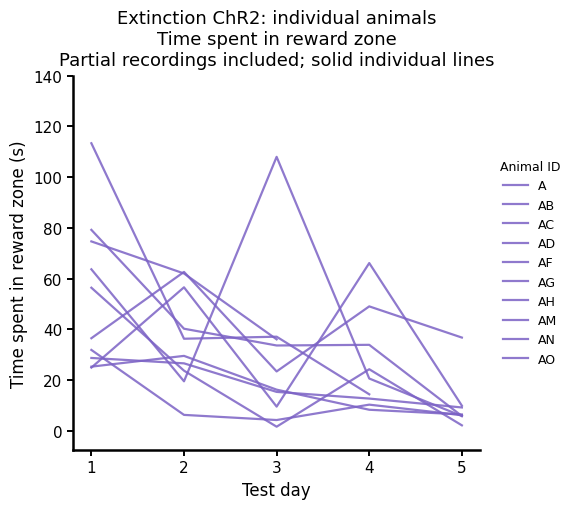


Individual ChR2 lines: Forgetting
Metric: time_in_trigger_s
Y-axis label: Time spent in reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort restriction applied: NO
Animals with any available test day are included.
   sub  id available_days  n_days
0    6  AB         [1, 5]       2
1    7  AC         [1, 5]       2
2    9  AE         [1, 5]       2
3   10  AF         [1, 5]       2
4   11  AG         [1, 5]       2
5   12  AH         [1, 5]       2
6   16  AM         [1, 5]       2
7   17  AN         [1, 5]       2
8   18  AO         [1, 5]       2


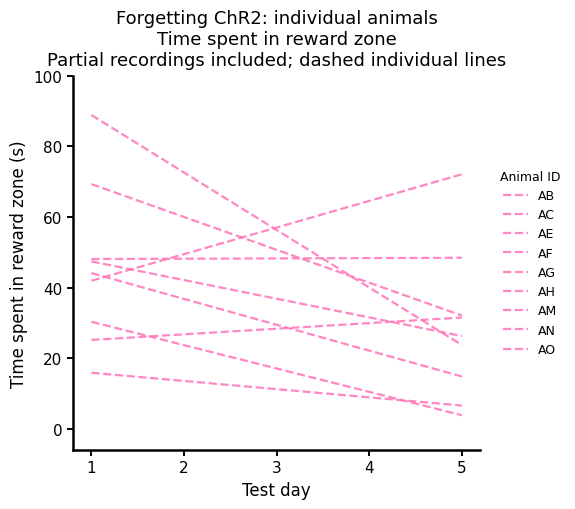


Animals included in ChR2-only aggregate line plot:
  Forgetting – ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], subs = [np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(17), np.int64(18)]
  Extinction – ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], subs = [np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(16), np.int64(17), np.int64(18)]


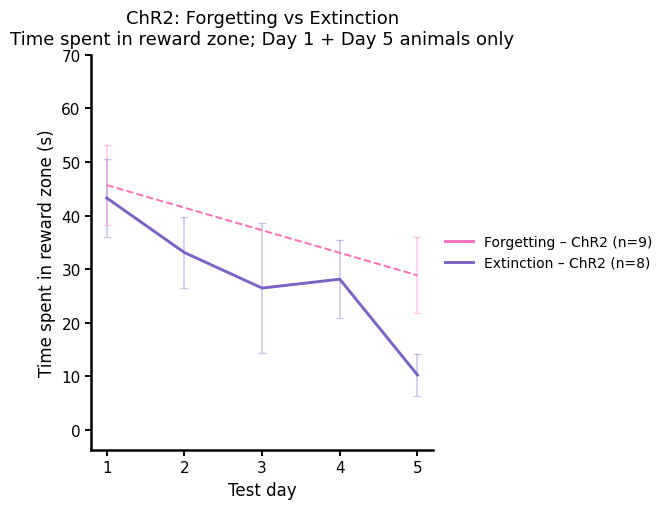


Ordinary boxplot: Test day 1
Metric: time_in_trigger_s
Y-axis label: Time spent in reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
eYFP control included for endpoint comparisons only.
Comparisons: Ext ChR2 vs Ext eYFP; Forg ChR2 vs Forg eYFP.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [63.657  28.69   36.4745 56.391  31.858  25.262  24.888  79.21  ]
  Ext eYFP: n = 2, ids = ['EE', 'EF'], values_s = [3.817 2.095]
  Forg ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values_s = [25.201 47.428 41.954 48.096 44.121 69.31  15.905 30.338 88.876]
  Forg eYFP: n = 2, ids = ['EE', 'EF'], values_s = [0.    2.467]

Mann–Whitney U tests, test day 1:
  Ext ChR2 vs Ext eYFP: n=8 vs 2, mean=43.304 vs 2.956 s, median=34.166 vs 2.956 s, U=16.0, rank-biserial=1.000, p=0.04444
  Forg ChR2 vs Forg eYFP: n=9 vs 2, mean=45.692

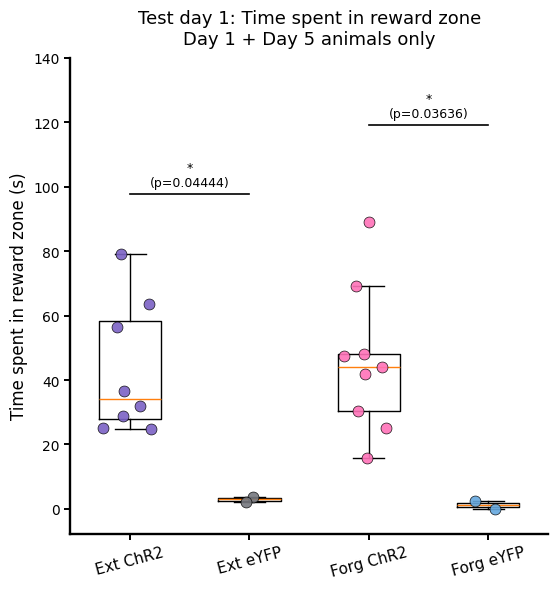


Ordinary boxplot: Test day 2
Metric: time_in_trigger_s
Y-axis label: Time spent in reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [19.484  26.567  62.6245 23.676   6.24   29.51   56.553  40.22  ]

Mann–Whitney U tests, test day 2:
  No between-group comparison specified for this plot.


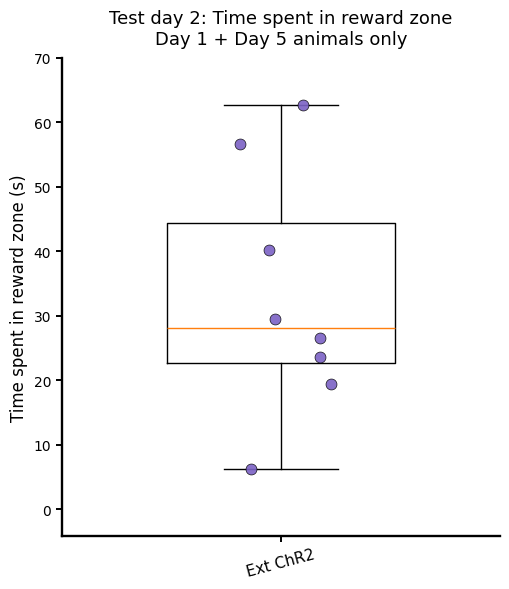


Ordinary boxplot: Test day 3
Metric: time_in_trigger_s
Y-axis label: Time spent in reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [108.002  15.307  23.377   1.584   4.211  16.19    9.506  33.613]

Mann–Whitney U tests, test day 3:
  No between-group comparison specified for this plot.


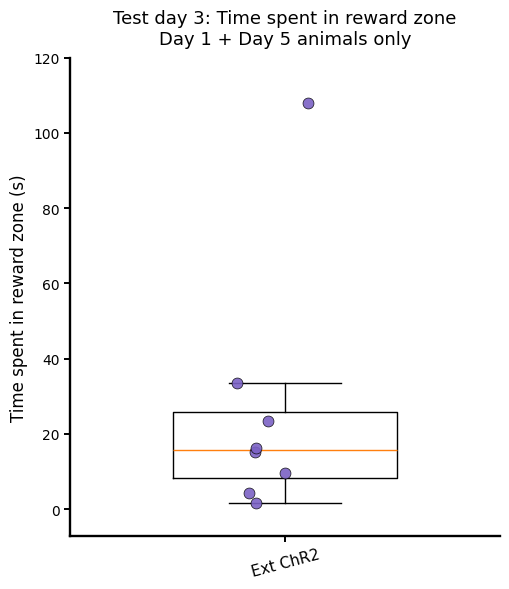


Ordinary boxplot: Test day 4
Metric: time_in_trigger_s
Y-axis label: Time spent in reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [20.581 12.678 49.032 24.244 10.276  8.266 66.113 33.869]

Mann–Whitney U tests, test day 4:
  No between-group comparison specified for this plot.


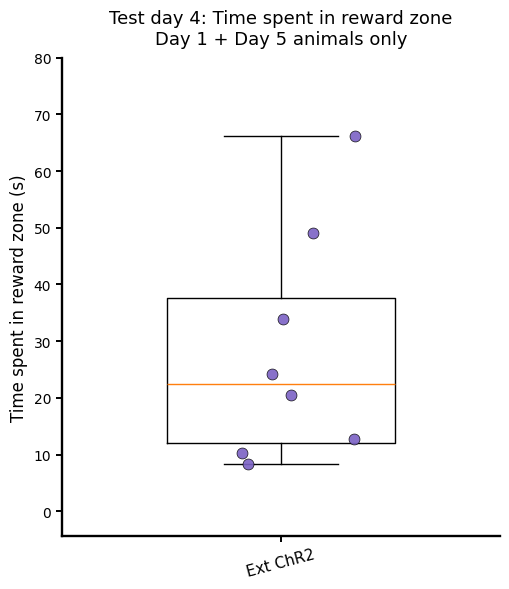


Ordinary boxplot: Test day 5
Metric: time_in_trigger_s
Y-axis label: Time spent in reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
eYFP control included for endpoint comparisons only.
Comparisons: Ext ChR2 vs Ext eYFP; Forg ChR2 vs Forg eYFP.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [ 5.778   9.167  36.7355  2.119   6.133   6.41    9.871   5.8   ]
  Ext eYFP: n = 2, ids = ['EE', 'EF'], values_s = [1.121 0.384]
  Forg ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values_s = [31.542 26.293 72.091 48.458 14.846 32.099  6.617  3.88  23.758]
  Forg eYFP: n = 2, ids = ['EE', 'EF'], values_s = [5.591 0.829]

Mann–Whitney U tests, test day 5:
  Ext ChR2 vs Ext eYFP: n=8 vs 2, mean=10.252 vs 0.752 s, median=6.271 vs 0.752 s, U=16.0, rank-biserial=1.000, p=0.04444
  Forg ChR2 vs Forg eYFP: n=9 vs 2, mean=28.843 

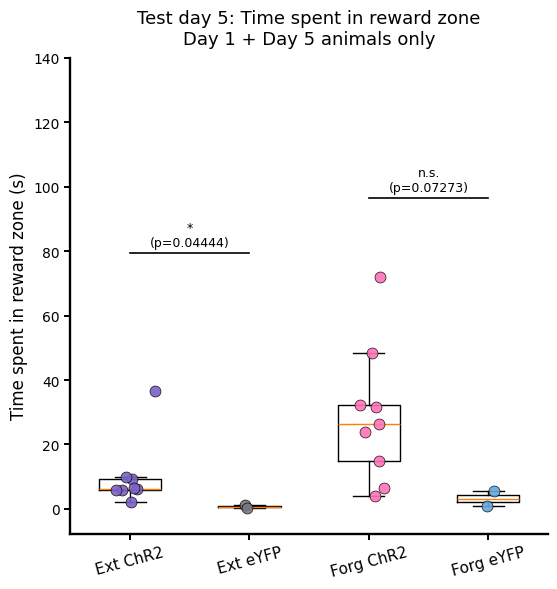


Paired ChR2 Extinction vs Forgetting, test day 1
Metric: time_in_trigger_s
Y-axis label: Time spent in reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  ext_value  forg_value
0    6  AB     63.657      25.201
1    7  AC     28.690      47.428
2   10  AF     56.391      48.096
3   11  AG     31.858      44.121
4   16  AM     25.262      15.905
5   17  AN     24.888      30.338
6   18  AO     79.210      88.876
Wilcoxon paired test: n=7, Ext mean=44.279 s, Forg mean=42.852 s, Ext median=31.858 s, Forg median=44.121 s, stat=12.000, p=0.81250


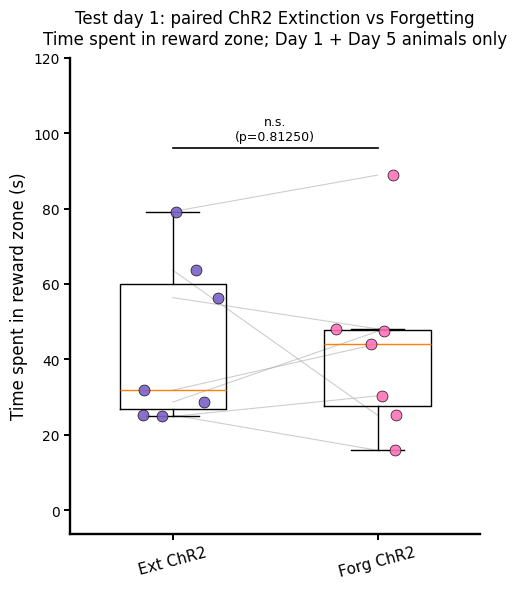


Paired ChR2 Extinction vs Forgetting, test day 5
Metric: time_in_trigger_s
Y-axis label: Time spent in reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  ext_value  forg_value
0    6  AB      5.778      31.542
1    7  AC      9.167      26.293
2   10  AF      2.119      48.458
3   11  AG      6.133      14.846
4   16  AM      6.410       6.617
5   17  AN      9.871       3.880
6   18  AO      5.800      23.758
Wilcoxon paired test: n=7, Ext mean=6.468 s, Forg mean=22.199 s, Ext median=6.133 s, Forg median=23.758 s, stat=2.000, p=0.04688


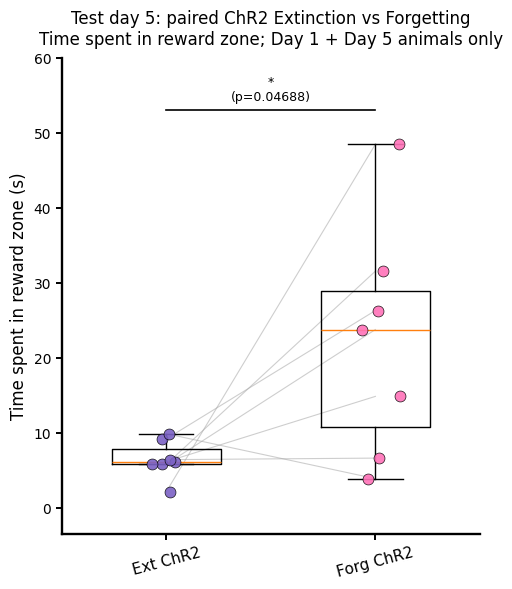


Paired ChR2 extinction: Day 1 vs Day 5
Metric: time_in_trigger_s
Y-axis label: Time spent in reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  day1_value  day5_value
0    6  AB     63.6570      5.7780
1    7  AC     28.6900      9.1670
2    8  AD     36.4745     36.7355
3   10  AF     56.3910      2.1190
4   11  AG     31.8580      6.1330
5   16  AM     25.2620      6.4100
6   17  AN     24.8880      9.8710
7   18  AO     79.2100      5.8000
Wilcoxon paired test: n=8, Day1 mean=43.304 s, Day5 mean=10.252 s, Day1 median=34.166 s, Day5 median=6.271 s, stat=1.000, p=0.01562


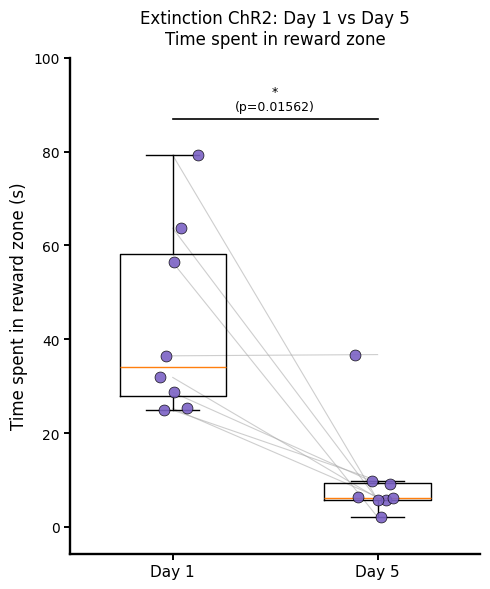


Paired ChR2 forgetting: Day 1 vs Day 5
Metric: time_in_trigger_s
Y-axis label: Time spent in reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  day1_value  day5_value
0    6  AB      25.201      31.542
1    7  AC      47.428      26.293
2    9  AE      41.954      72.091
3   10  AF      48.096      48.458
4   11  AG      44.121      14.846
5   12  AH      69.310      32.099
6   16  AM      15.905       6.617
7   17  AN      30.338       3.880
8   18  AO      88.876      23.758
Wilcoxon paired test: n=9, Day1 mean=45.692 s, Day5 mean=28.843 s, Day1 median=44.121 s, Day5 median=26.293 s, stat=10.000, p=0.16406


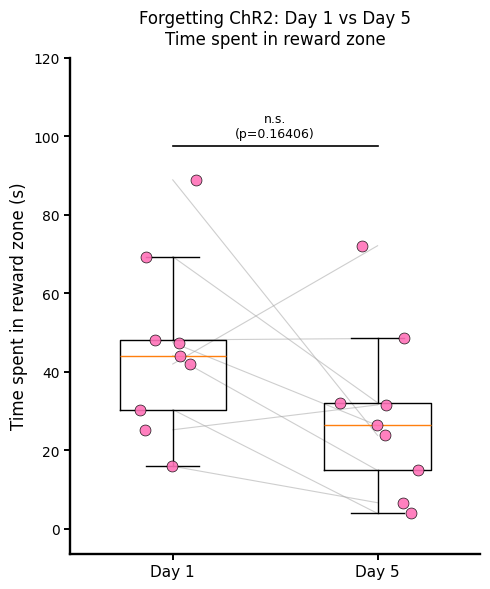



############################################################
RUNNING METRIC: time_in_near_reward_s
Metric label: Time spent in near-reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Line plot genotypes: ['ChR2']
Endpoint ordinary boxplot controls: eYFP_ChR2
SEM style: bar
############################################################

All valid TEST rows before aggregate-cohort restriction:
    sub  id   genotype   test_type  trial_type_day  time_in_near_reward_s
0     1   A       ChR2  extinction               1                 28.558
1     1   A       ChR2  extinction               2                 13.115
2     1   A       ChR2  extinction               3                 32.561
3     6  AB       ChR2  extinction               1                 19.074
4     6  AB       ChR2  extinction               2                 15.463
..  ...  ..        ...         ...             ...  

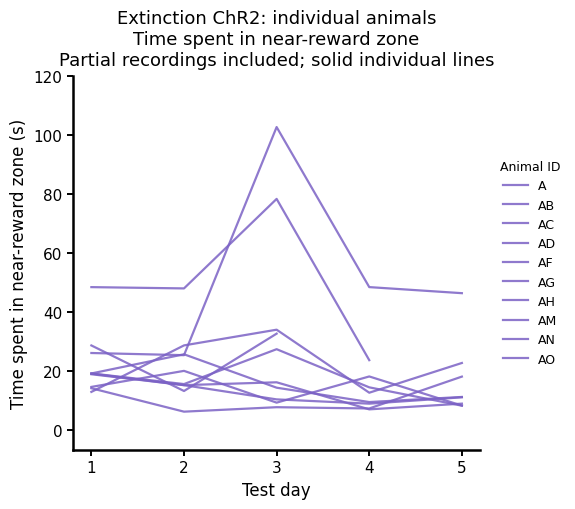


Individual ChR2 lines: Forgetting
Metric: time_in_near_reward_s
Y-axis label: Time spent in near-reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort restriction applied: NO
Animals with any available test day are included.
   sub  id available_days  n_days
0    6  AB         [1, 5]       2
1    7  AC         [1, 5]       2
2    9  AE         [1, 5]       2
3   10  AF         [1, 5]       2
4   11  AG         [1, 5]       2
5   12  AH         [1, 5]       2
6   16  AM         [1, 5]       2
7   17  AN         [1, 5]       2
8   18  AO         [1, 5]       2


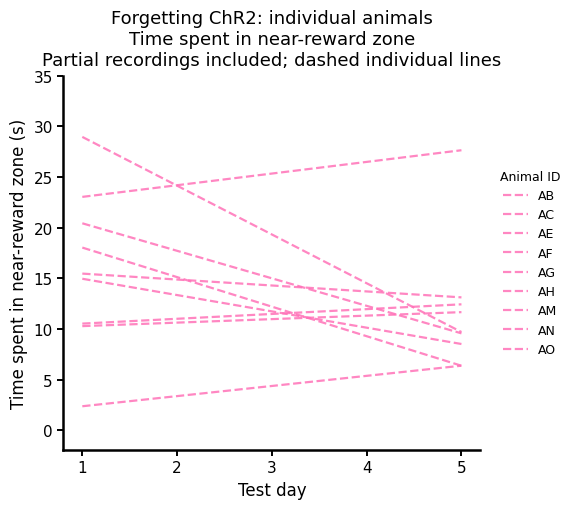


Animals included in ChR2-only aggregate line plot:
  Forgetting – ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], subs = [np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(17), np.int64(18)]
  Extinction – ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], subs = [np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(16), np.int64(17), np.int64(18)]


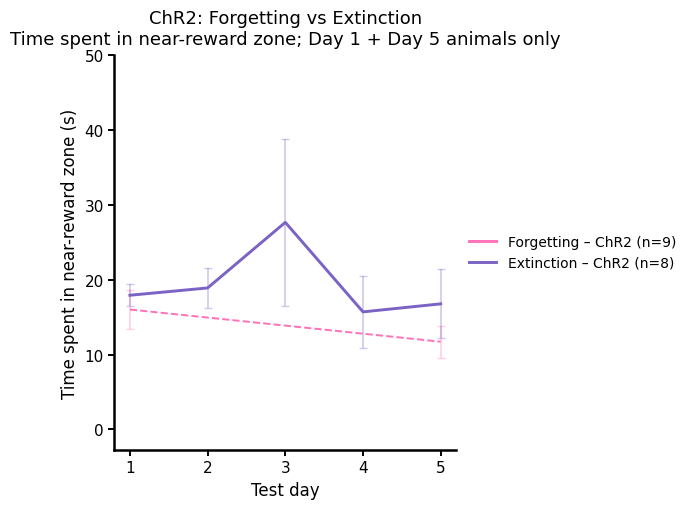


Ordinary boxplot: Test day 1
Metric: time_in_near_reward_s
Y-axis label: Time spent in near-reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
eYFP control included for endpoint comparisons only.
Comparisons: Ext ChR2 vs Ext eYFP; Forg ChR2 vs Forg eYFP.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [19.074 19.016 12.809 25.997 14.048 18.798 19.058 14.503]
  Ext eYFP: n = 2, ids = ['EE', 'EF'], values_s = [2.845 4.386]
  Forg ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values_s = [23.04  15.467 14.959 28.96  10.284 10.533 20.433 18.036  2.375]
  Forg eYFP: n = 2, ids = ['EE', 'EF'], values_s = [3.03  6.818]

Mann–Whitney U tests, test day 1:
  Ext ChR2 vs Ext eYFP: n=8 vs 2, mean=17.913 vs 3.615 s, median=18.907 vs 3.615 s, U=16.0, rank-biserial=1.000, p=0.04444
  Forg ChR2 vs Forg eYFP: n=9 vs 2, mean=16.01

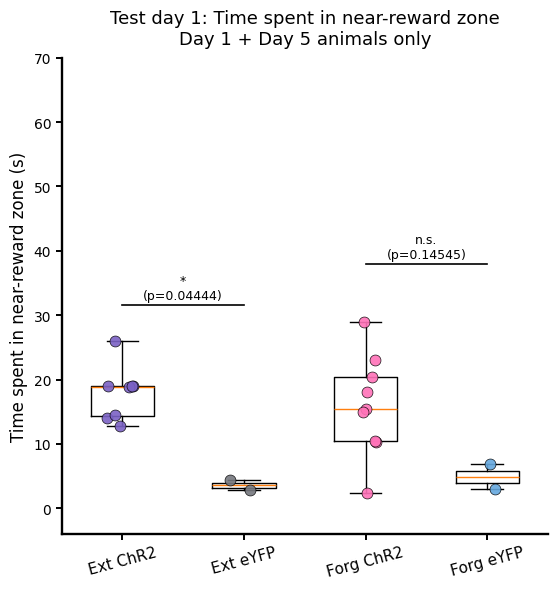


Ordinary boxplot: Test day 2
Metric: time_in_near_reward_s
Y-axis label: Time spent in near-reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [15.463 15.096 28.573 25.263  6.111 15.103 25.566 19.941]

Mann–Whitney U tests, test day 2:
  No between-group comparison specified for this plot.


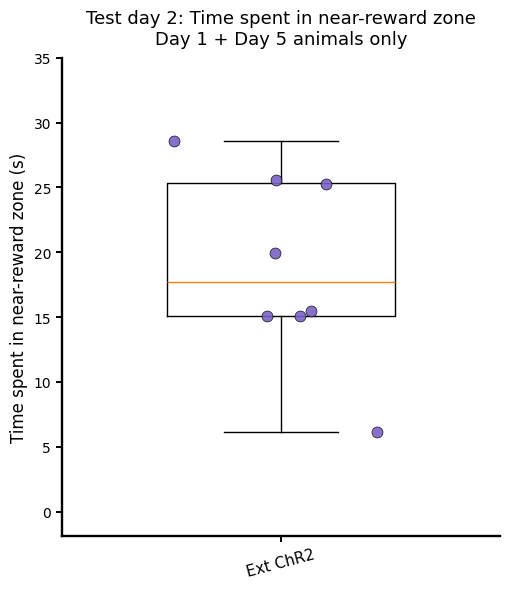


Ordinary boxplot: Test day 3
Metric: time_in_near_reward_s
Y-axis label: Time spent in near-reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [ 27.288  10.272  33.899 102.594   7.625  16.067  14.237   9.172]

Mann–Whitney U tests, test day 3:
  No between-group comparison specified for this plot.


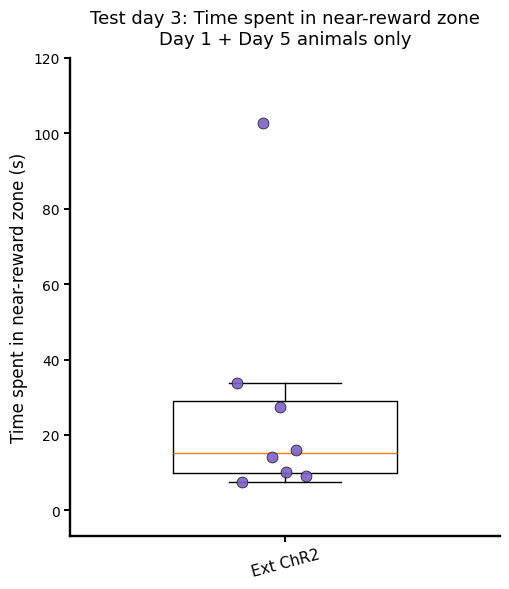


Ordinary boxplot: Test day 4
Metric: time_in_near_reward_s
Y-axis label: Time spent in near-reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [14.357   8.825  12.5365 48.337   7.192   6.892   9.369  18.046 ]

Mann–Whitney U tests, test day 4:
  No between-group comparison specified for this plot.


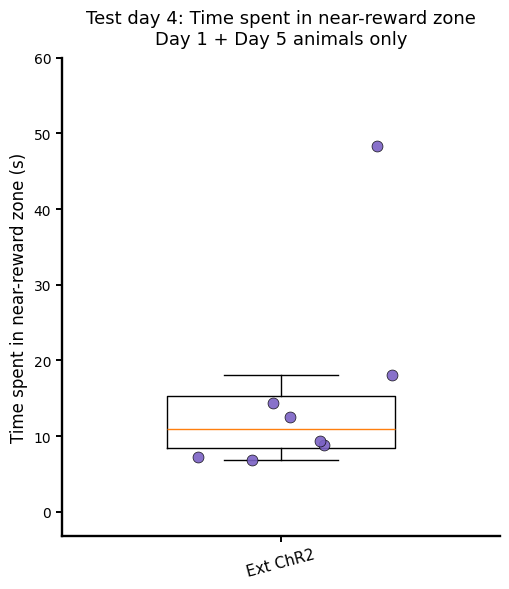


Ordinary boxplot: Test day 5
Metric: time_in_near_reward_s
Y-axis label: Time spent in near-reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
eYFP control included for endpoint comparisons only.
Comparisons: Ext ChR2 vs Ext eYFP; Forg ChR2 vs Forg eYFP.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [ 8.139 10.974 22.615 46.28  17.997  8.833 11.102  8.181]
  Ext eYFP: n = 2, ids = ['EE', 'EF'], values_s = [3.769 2.295]
  Forg ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values_s = [27.644  13.122   8.5195  9.7    11.664  12.435   9.57    6.373   6.377 ]
  Forg eYFP: n = 2, ids = ['EE', 'EF'], values_s = [ 7.148 32.104]

Mann–Whitney U tests, test day 5:
  Ext ChR2 vs Ext eYFP: n=8 vs 2, mean=16.765 vs 3.032 s, median=11.038 vs 3.032 s, U=16.0, rank-biserial=1.000, p=0.04444
  Forg ChR2 vs Forg eYFP: n=9 vs 2,

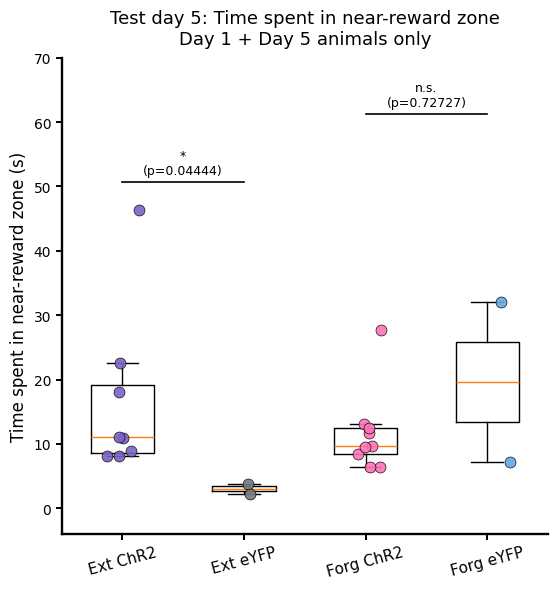


Paired ChR2 Extinction vs Forgetting, test day 1
Metric: time_in_near_reward_s
Y-axis label: Time spent in near-reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  ext_value  forg_value
0    6  AB     19.074      23.040
1    7  AC     19.016      15.467
2   10  AF     25.997      28.960
3   11  AG     14.048      10.284
4   16  AM     18.798      20.433
5   17  AN     19.058      18.036
6   18  AO     14.503       2.375
Wilcoxon paired test: n=7, Ext mean=18.642 s, Forg mean=16.942 s, Ext median=19.016 s, Forg median=18.036 s, stat=11.000, p=0.68750


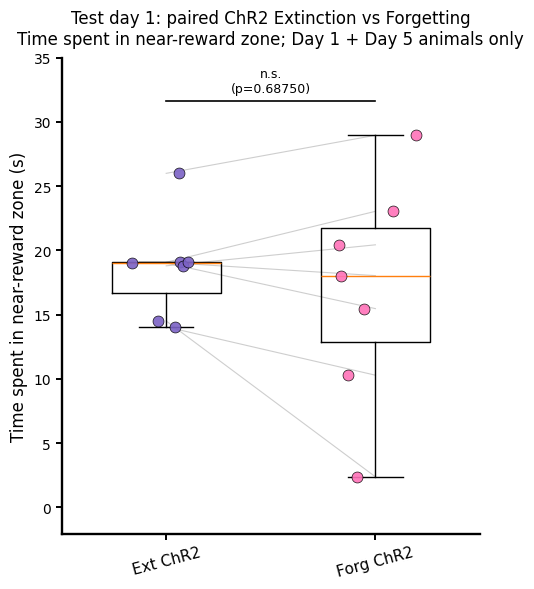


Paired ChR2 Extinction vs Forgetting, test day 5
Metric: time_in_near_reward_s
Y-axis label: Time spent in near-reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  ext_value  forg_value
0    6  AB      8.139      27.644
1    7  AC     10.974      13.122
2   10  AF     46.280       9.700
3   11  AG     17.997      11.664
4   16  AM      8.833       9.570
5   17  AN     11.102       6.373
6   18  AO      8.181       6.377
Wilcoxon paired test: n=7, Ext mean=15.929 s, Forg mean=12.064 s, Ext median=10.974 s, Forg median=9.700 s, stat=10.000, p=0.57812


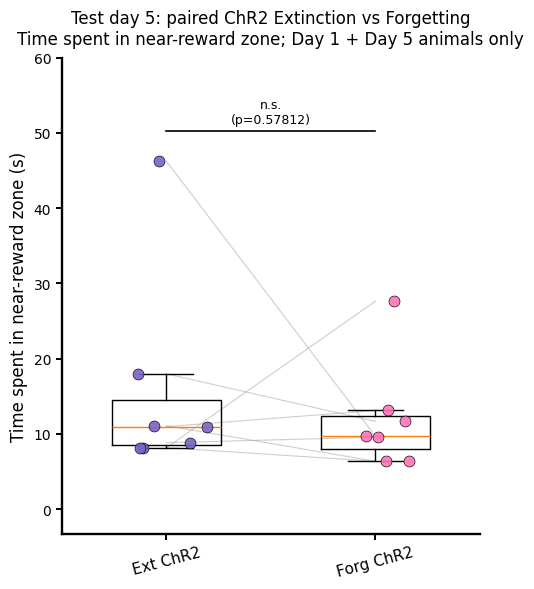


Paired ChR2 extinction: Day 1 vs Day 5
Metric: time_in_near_reward_s
Y-axis label: Time spent in near-reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  day1_value  day5_value
0    6  AB      19.074       8.139
1    7  AC      19.016      10.974
2    8  AD      12.809      22.615
3   10  AF      25.997      46.280
4   11  AG      14.048      17.997
5   16  AM      18.798       8.833
6   17  AN      19.058      11.102
7   18  AO      14.503       8.181
Wilcoxon paired test: n=8, Day1 mean=17.913 s, Day5 mean=16.765 s, Day1 median=18.907 s, Day5 median=11.038 s, stat=14.000, p=0.64062


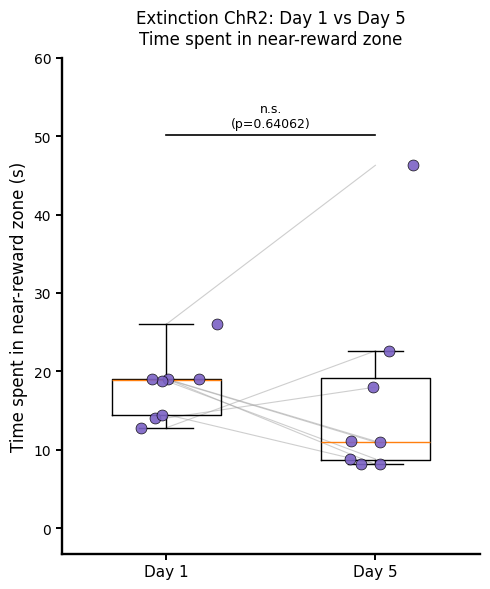


Paired ChR2 forgetting: Day 1 vs Day 5
Metric: time_in_near_reward_s
Y-axis label: Time spent in near-reward zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  day1_value  day5_value
0    6  AB      23.040     27.6440
1    7  AC      15.467     13.1220
2    9  AE      14.959      8.5195
3   10  AF      28.960      9.7000
4   11  AG      10.284     11.6640
5   12  AH      10.533     12.4350
6   16  AM      20.433      9.5700
7   17  AN      18.036      6.3730
8   18  AO       2.375      6.3770
Wilcoxon paired test: n=9, Day1 mean=16.010 s, Day5 mean=11.712 s, Day1 median=15.467 s, Day5 median=9.700 s, stat=12.000, p=0.25000


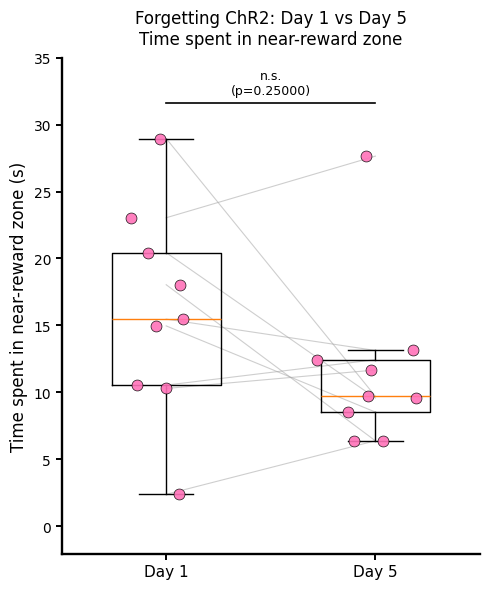



############################################################
RUNNING METRIC: time_in_edge_s
Metric label: Time spent in edge zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Line plot genotypes: ['ChR2']
Endpoint ordinary boxplot controls: eYFP_ChR2
SEM style: bar
############################################################

All valid TEST rows before aggregate-cohort restriction:
    sub  id   genotype   test_type  trial_type_day  time_in_edge_s
0     1   A       ChR2  extinction               1          29.824
1     1   A       ChR2  extinction               2          59.091
2     1   A       ChR2  extinction               3          46.521
3     6  AB       ChR2  extinction               1          25.986
4     6  AB       ChR2  extinction               2          74.385
..  ...  ..        ...         ...             ...             ...
93   22   F  eYFP_ChR2  extinction       

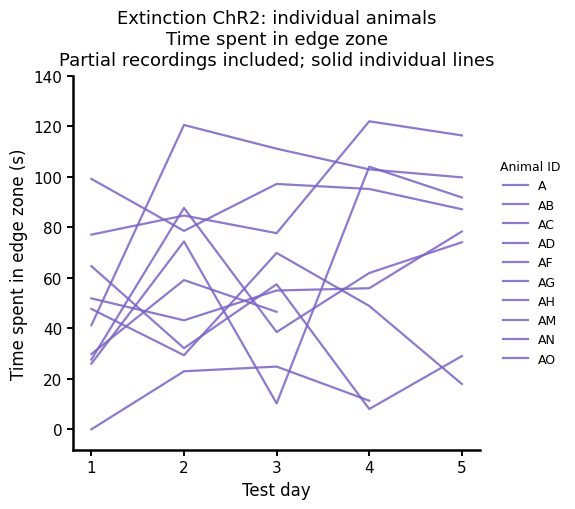


Individual ChR2 lines: Forgetting
Metric: time_in_edge_s
Y-axis label: Time spent in edge zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort restriction applied: NO
Animals with any available test day are included.
   sub  id available_days  n_days
0    6  AB         [1, 5]       2
1    7  AC         [1, 5]       2
2    9  AE         [1, 5]       2
3   10  AF         [1, 5]       2
4   11  AG         [1, 5]       2
5   12  AH         [1, 5]       2
6   16  AM         [1, 5]       2
7   17  AN         [1, 5]       2
8   18  AO         [1, 5]       2


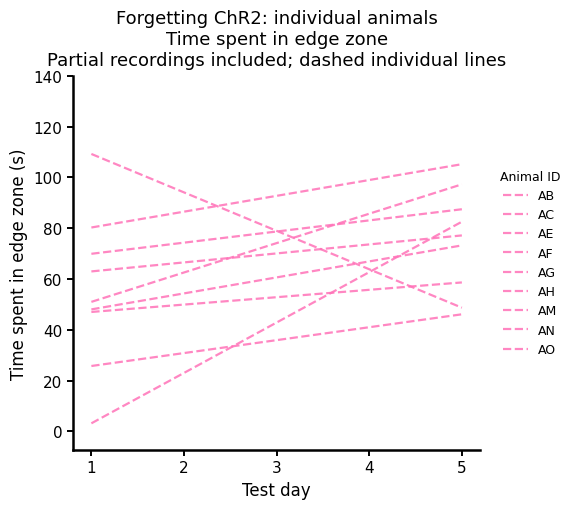


Animals included in ChR2-only aggregate line plot:
  Forgetting – ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], subs = [np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(17), np.int64(18)]
  Extinction – ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], subs = [np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(16), np.int64(17), np.int64(18)]


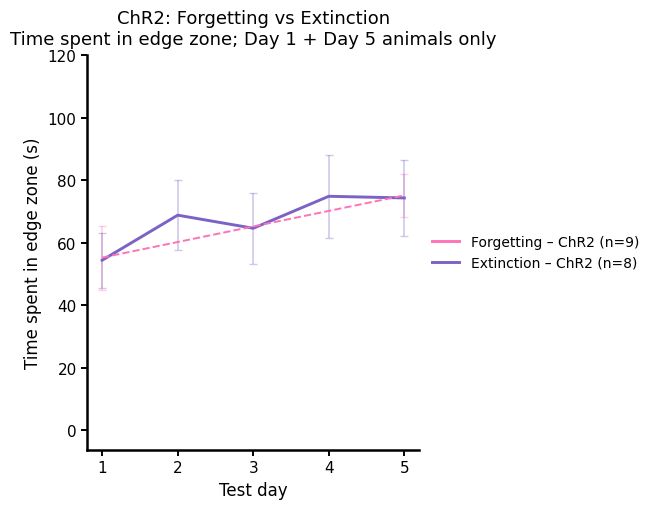


Ordinary boxplot: Test day 1
Metric: time_in_edge_s
Y-axis label: Time spent in edge zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
eYFP control included for endpoint comparisons only.
Comparisons: Ext ChR2 vs Ext eYFP; Forg ChR2 vs Forg eYFP.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [25.986 99.151 64.613 47.662 41.224 77.083 51.848 27.645]
  Ext eYFP: n = 2, ids = ['EE', 'EF'], values_s = [112.756 107.341]
  Forg ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values_s = [109.199  25.74   48.018   3.172  50.979  62.968  80.254  69.905  47.008]
  Forg eYFP: n = 2, ids = ['EE', 'EF'], values_s = [ 32.005 109.606]

Mann–Whitney U tests, test day 1:
  Ext ChR2 vs Ext eYFP: n=8 vs 2, mean=54.401 vs 110.048 s, median=49.755 vs 110.048 s, U=0.0, rank-biserial=-1.000, p=0.04444
  Forg ChR2 vs Forg eYFP: n=9 vs 2, mea

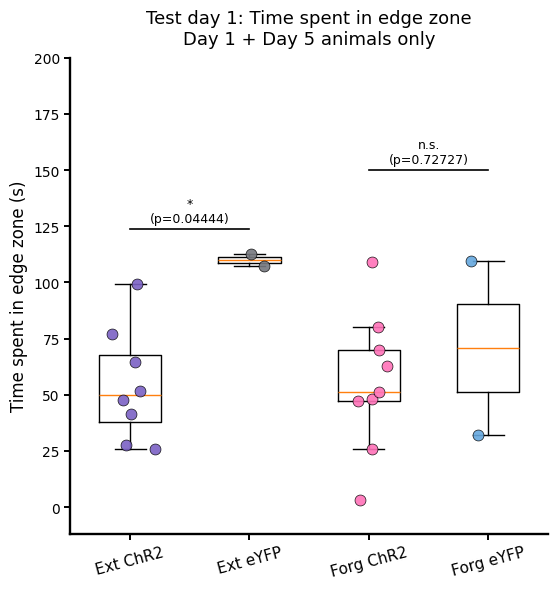


Ordinary boxplot: Test day 2
Metric: time_in_edge_s
Y-axis label: Time spent in edge zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [ 74.385   78.572   32.1375  29.335  120.494   84.634   43.154   87.659 ]

Mann–Whitney U tests, test day 2:
  No between-group comparison specified for this plot.


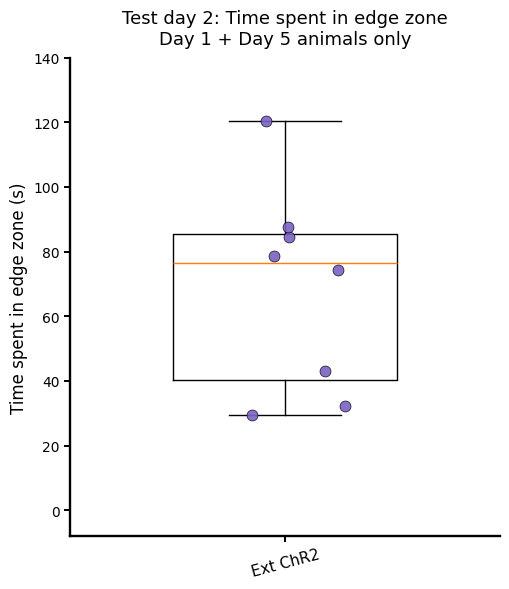


Ordinary boxplot: Test day 3
Metric: time_in_edge_s
Y-axis label: Time spent in edge zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [ 10.263   97.152   57.4435  69.836  111.099   77.668   54.959   38.507 ]

Mann–Whitney U tests, test day 3:
  No between-group comparison specified for this plot.


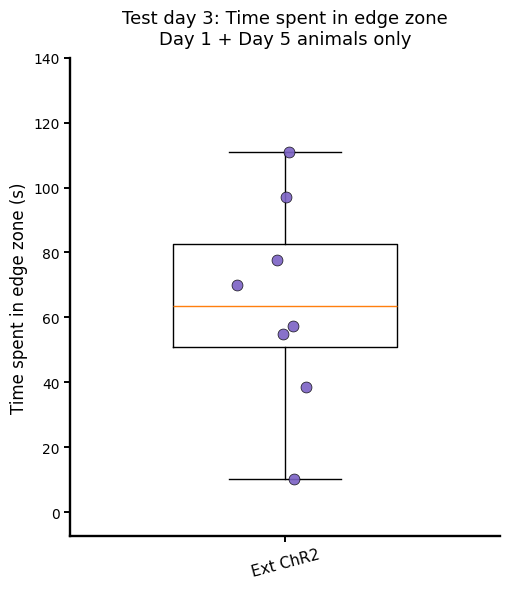


Ordinary boxplot: Test day 4
Metric: time_in_edge_s
Y-axis label: Time spent in edge zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [103.983  95.162   8.034  48.851 102.91  121.949  55.86   61.895]

Mann–Whitney U tests, test day 4:
  No between-group comparison specified for this plot.


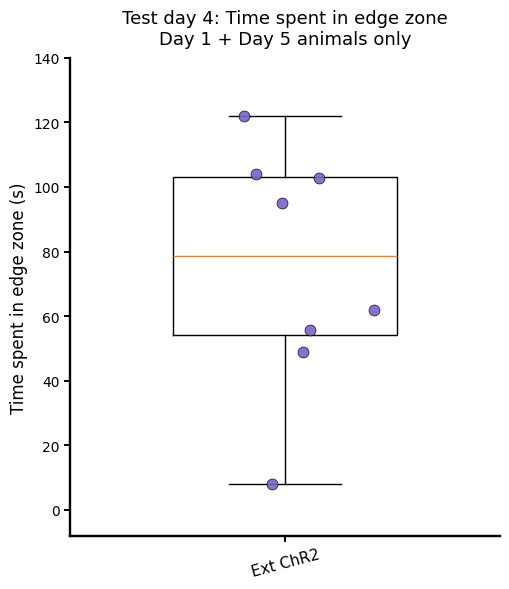


Ordinary boxplot: Test day 5
Metric: time_in_edge_s
Y-axis label: Time spent in edge zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
eYFP control included for endpoint comparisons only.
Comparisons: Ext ChR2 vs Ext eYFP; Forg ChR2 vs Forg eYFP.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [ 91.805  87.137  29.006  17.941  99.75  116.371  78.323  74.058]
  Ext eYFP: n = 2, ids = ['EE', 'EF'], values_s = [142.944 141.641]
  Forg ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values_s = [ 48.686   46.088   73.2065  82.531   97.247   77.134  105.173   87.438
  58.63  ]
  Forg eYFP: n = 2, ids = ['EE', 'EF'], values_s = [84.044 29.229]

Mann–Whitney U tests, test day 5:
  Ext ChR2 vs Ext eYFP: n=8 vs 2, mean=74.299 vs 142.292 s, median=82.730 vs 142.292 s, U=0.0, rank-biserial=-1.000, p=0.04444
  Forg ChR2 vs Forg eYFP

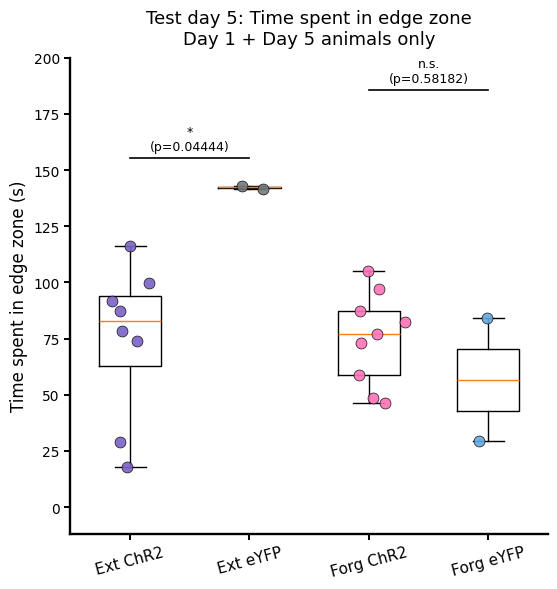


Paired ChR2 Extinction vs Forgetting, test day 1
Metric: time_in_edge_s
Y-axis label: Time spent in edge zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  ext_value  forg_value
0    6  AB     25.986     109.199
1    7  AC     99.151      25.740
2   10  AF     47.662       3.172
3   11  AG     41.224      50.979
4   16  AM     77.083      80.254
5   17  AN     51.848      69.905
6   18  AO     27.645      47.008
Wilcoxon paired test: n=7, Ext mean=52.943 s, Forg mean=55.180 s, Ext median=47.662 s, Forg median=50.979 s, stat=11.000, p=0.68750


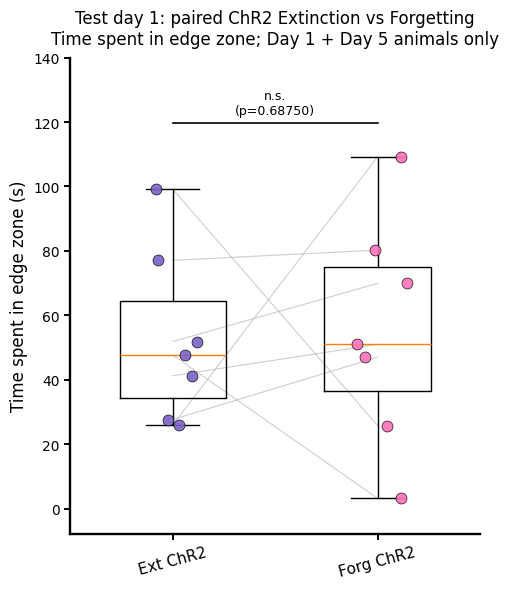


Paired ChR2 Extinction vs Forgetting, test day 5
Metric: time_in_edge_s
Y-axis label: Time spent in edge zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  ext_value  forg_value
0    6  AB     91.805      48.686
1    7  AC     87.137      46.088
2   10  AF     17.941      82.531
3   11  AG     99.750      97.247
4   16  AM    116.371     105.173
5   17  AN     78.323      87.438
6   18  AO     74.058      58.630
Wilcoxon paired test: n=7, Ext mean=80.769 s, Forg mean=75.113 s, Ext median=87.137 s, Forg median=82.531 s, stat=9.000, p=0.46875


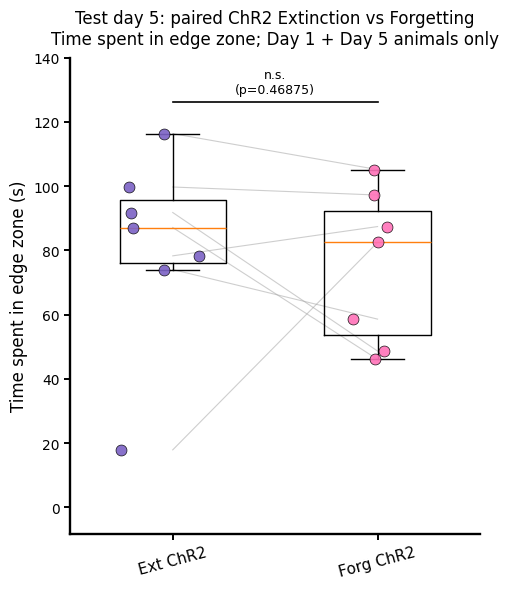


Paired ChR2 extinction: Day 1 vs Day 5
Metric: time_in_edge_s
Y-axis label: Time spent in edge zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  day1_value  day5_value
0    6  AB      25.986      91.805
1    7  AC      99.151      87.137
2    8  AD      64.613      29.006
3   10  AF      47.662      17.941
4   11  AG      41.224      99.750
5   16  AM      77.083     116.371
6   17  AN      51.848      78.323
7   18  AO      27.645      74.058
Wilcoxon paired test: n=8, Day1 mean=54.401 s, Day5 mean=74.299 s, Day1 median=49.755 s, Day5 median=82.730 s, stat=8.000, p=0.19531


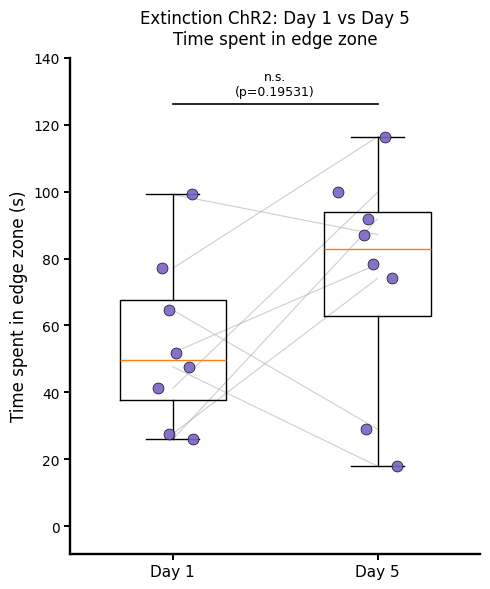


Paired ChR2 forgetting: Day 1 vs Day 5
Metric: time_in_edge_s
Y-axis label: Time spent in edge zone (s)
Values are already in seconds; no conversion applied.
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  day1_value  day5_value
0    6  AB     109.199     48.6860
1    7  AC      25.740     46.0880
2    9  AE      48.018     73.2065
3   10  AF       3.172     82.5310
4   11  AG      50.979     97.2470
5   12  AH      62.968     77.1340
6   16  AM      80.254    105.1730
7   17  AN      69.905     87.4380
8   18  AO      47.008     58.6300
Wilcoxon paired test: n=9, Day1 mean=55.249 s, Day5 mean=75.126 s, Day1 median=50.979 s, Day5 median=77.134 s, stat=8.000, p=0.09766


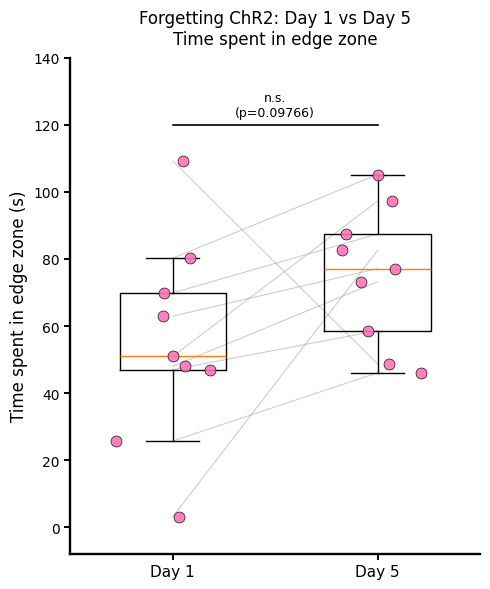

In [252]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, wilcoxon

# ============================================================
# Forgetting / Extinction TEST trials across test days 1-5
#
# Metrics:
#   1) time_in_trigger_s
#        = time spent in reward zone, already stored in seconds
#
#   2) time_in_near_reward_s
#        = time spent in near-reward zone, already stored in seconds
#
#   3) time_in_edge_s
#        = time spent in edge zone, already stored in seconds
#
# Produces, for each metric:
#
#   1) Aggregate mean ± SEM line plot:
#        - ChR2 ONLY
#        - Forgetting ChR2 vs Extinction ChR2
#
#   2) Individual ChR2 extinction lines:
#        - ChR2 ONLY
#        - solid individual lines
#        - partial recordings included
#
#   3) Individual ChR2 forgetting lines:
#        - ChR2 ONLY
#        - dashed individual lines
#        - partial recordings included
#
#   4) Ordinary day boxplots:
#        - Test Day 1 and Test Day 5:
#             Ext ChR2, Ext eYFP, Forg ChR2, Forg eYFP
#             Comparisons:
#                 Ext ChR2 vs Ext eYFP
#                 Forg ChR2 vs Forg eYFP
#
#        - Test Day 2, 3 and 4:
#             Ext ChR2 ONLY
#             No eYFP plotted
#             No between-group comparison
#
#   5) Paired ChR2 Extinction vs Forgetting boxplots:
#        - Day 1 and Day 5
#        - ChR2 ONLY
#
#   6) Paired Day 1 vs Day 5 boxplots:
#        - ChR2 Extinction
#        - ChR2 Forgetting
#
# IMPORTANT:
#   - These time-spent variables must already exist in metadata.
#   - They are already stored in seconds.
#   - No conversion is applied in this plotting code.
#   - short_duration is NOT filtered anywhere in this code.
#   - There is no ≥2 s stay / all-visits switch here because these
#     columns directly represent time spent in the specified zones.
# ============================================================


# ============================================================
# OPTIONS
# ============================================================

# ------------------------------------------------------------
# Genotypes used for each plot type
# ------------------------------------------------------------

# Aggregate line plots and individual-animal plots use ChR2 only.
LINE_GENOTYPES = ['ChR2']

# Endpoint ordinary boxplots additionally use eYFP control.
ENDPOINT_CONTROL_GENOTYPE = 'eYFP_ChR2'
INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS = True

# All genotypes required to be loaded from metadata.
GENOTYPES_TO_LOAD = ['ChR2']

if INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS:
    GENOTYPES_TO_LOAD.append(ENDPOINT_CONTROL_GENOTYPE)

GENOTYPES_TO_LOAD = sorted(set(GENOTYPES_TO_LOAD))

EXCLUDE_ID = []
EXCLUDE_SUBS = []

max_day = 5
day_values = np.arange(1, max_day + 1)

# ------------------------------------------------------------
# Aggregate/statistical cohort rule
# ------------------------------------------------------------
# Options:
#
#   'all'
#       Use all animals with at least one finite value.
#
#   'day1_day5'
#       Use only animals with finite values on both Day 1 and Day 5
#       within each genotype × test_type group.
#
#   'all_five'
#       Use only animals with finite values on Days 1-5.
#
# This rule applies independently to:
#   ChR2 extinction
#   ChR2 forgetting
#   eYFP extinction
#   eYFP forgetting
#
# Individual ChR2 trajectory plots ignore this restriction and show
# all animals with any available data.
# ------------------------------------------------------------

GROUP_PLOT_COHORT_MODE = 'day1_day5'
# GROUP_PLOT_COHORT_MODE = 'all'
# GROUP_PLOT_COHORT_MODE = 'all_five'

VALID_COHORT_MODES = ['all', 'day1_day5', 'all_five']

if GROUP_PLOT_COHORT_MODE not in VALID_COHORT_MODES:
    raise ValueError(
        f"GROUP_PLOT_COHORT_MODE must be one of {VALID_COHORT_MODES}."
    )

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

METRICS_TO_PLOT = [
    'time_in_trigger_s',
    'time_in_near_reward_s',
    'time_in_edge_s',
]

METRIC_LABEL = {
    'time_in_trigger_s': 'Time spent in reward zone (s)',
    'time_in_near_reward_s': 'Time spent in near-reward zone (s)',
    'time_in_edge_s': 'Time spent in edge zone (s)',
}

METRIC_TITLE = {
    'time_in_trigger_s': 'Time spent in reward zone',
    'time_in_near_reward_s': 'Time spent in near-reward zone',
    'time_in_edge_s': 'Time spent in edge zone',
}

# The time variables are already in seconds.
# Keep all plotting scales at 1.0.
METRIC_SCALE = {
    'time_in_trigger_s': 1.0,
    'time_in_near_reward_s': 1.0,
    'time_in_edge_s': 1.0,
}

# ------------------------------------------------------------
# Colours
# ------------------------------------------------------------

COL_FORG_CHR2 = "#FF72B8"      # pink
COL_EXT_CHR2 = "#7b62c5ff"     # purple
COL_FORG_YFP = "#65a8deff"     # blue
COL_EXT_YFP = "#76787EC1"      # grey

GROUP_STYLE = {
    ('ChR2', 'forgetting'): {
        'key': 'f_ChR2',
        'label': 'Forg ChR2',
        'long_label': 'Forgetting – ChR2',
        'color': COL_FORG_CHR2,
    },
    ('ChR2', 'extinction'): {
        'key': 'e_ChR2',
        'label': 'Ext ChR2',
        'long_label': 'Extinction – ChR2',
        'color': COL_EXT_CHR2,
    },
    ('eYFP_ChR2', 'forgetting'): {
        'key': 'f_YFP',
        'label': 'Forg eYFP',
        'long_label': 'Forgetting – eYFP',
        'color': COL_FORG_YFP,
    },
    ('eYFP_ChR2', 'extinction'): {
        'key': 'e_YFP',
        'label': 'Ext eYFP',
        'long_label': 'Extinction – eYFP',
        'color': COL_EXT_YFP,
    },
}

DISPLAY_NAME = {
    'ChR2': 'ChR2',
    'eYFP_ChR2': 'eYFP',
}

# ------------------------------------------------------------
# Aggregate ChR2-only line plot options
# ------------------------------------------------------------

# 'bar' or 'shaded'
SEM_STYLE = 'bar'
# SEM_STYLE = 'shaded'

LINE_FIGSIZE = (8.0, 5.2)

LINE_ZERO_PAD_FRAC = 0.06
LINE_TOP_PAD_FRAC = 0.18

YMIN_BY_METRIC = {
    'time_in_trigger_s': None,
    'time_in_near_reward_s': None,
    'time_in_edge_s': None,
}

YMAX_BY_METRIC = {
    'time_in_trigger_s': None,
    'time_in_near_reward_s': None,
    'time_in_edge_s': None,
}

LINE_Y_TICK_STEP_BY_METRIC = {
    'time_in_trigger_s': None,
    'time_in_near_reward_s': None,
    'time_in_edge_s': None,
}

# ------------------------------------------------------------
# Individual ChR2 line plot options
# ------------------------------------------------------------

RUN_INDIVIDUAL_CHR2_LINE_PLOTS = True
INDIVIDUAL_CHR2_TEST_TYPES = ['extinction', 'forgetting']

INDIVIDUAL_FIGSIZE = (7.0, 5.2)
INDIVIDUAL_LINEWIDTH = 1.6
INDIVIDUAL_ALPHA = 0.85
INDIVIDUAL_SHOW_LEGEND = True

INDIVIDUAL_YMIN_BY_METRIC = {
    'time_in_trigger_s': None,
    'time_in_near_reward_s': None,
    'time_in_edge_s': None,
}

INDIVIDUAL_YMAX_BY_METRIC = {
    'time_in_trigger_s': None,
    'time_in_near_reward_s': None,
    'time_in_edge_s': None,
}

INDIVIDUAL_Y_TICK_STEP_BY_METRIC = {
    'time_in_trigger_s': None,
    'time_in_near_reward_s': None,
    'time_in_edge_s': None,
}

INDIVIDUAL_ZERO_PAD_FRAC = 0.06
INDIVIDUAL_TOP_PAD_FRAC = 0.12

# ------------------------------------------------------------
# Ordinary boxplot options
# ------------------------------------------------------------

RUN_DAY_BOXPLOTS = True
BOXPLOT_DAYS = [1, 2, 3, 4, 5]

# Match ordinary Day 1 and Day 5 y-axis limits.
MATCH_DAY1_DAY5_BOXPLOT_YAXIS = True

# ------------------------------------------------------------
# Paired ChR2-only boxplot options
# ------------------------------------------------------------

# Paired ChR2 Extinction vs Forgetting on the same day
RUN_PAIRED_CHR2_EXT_VS_FORG_BOXPLOTS = True
PAIRED_CHR2_DAYS = [1, 5]

# Paired Day 1 vs Day 5 within ChR2 extinction/forgetting
RUN_DAY1_VS_DAY5_WITHIN_TEST_TYPE_BOXPLOTS = True
DAY1_VS_DAY5_GENOTYPE = 'ChR2'
DAY1_VS_DAY5_TEST_TYPES = ['extinction', 'forgetting']

SHOW_PAIRED_LINES = True
SHOW_ANIMAL_IDS = False

# ------------------------------------------------------------
# Dot / annotation / axis options
# ------------------------------------------------------------

JITTER = 0.10
DOT_SIZE = 62
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.5

BOX_FIG_HEIGHT = 6.0

P_DECIMALS = 5

# Compact p-value spacing
P_LINE_START_FRAC = 0.10
P_LINE_STEP_FRAC = 0.24
P_TEXT_OFFSET_FRAC = 0.018
BOX_ANNOTATION_TOP_FRAC = 0.08

BOX_Y_ZERO_PAD_FRAC = 0.06
BOX_Y_TOP_PAD_FRAC = 0.10

BOX_MINIMUM_TOP_BY_METRIC = {
    'time_in_trigger_s': None,
    'time_in_near_reward_s': None,
    'time_in_edge_s': None,
}

BOX_YMIN_BY_METRIC = {
    'time_in_trigger_s': None,
    'time_in_near_reward_s': None,
    'time_in_edge_s': None,
}

BOX_Y_TICK_STEP_BY_METRIC = {
    'time_in_trigger_s': None,
    'time_in_near_reward_s': None,
    'time_in_edge_s': None,
}

np.random.seed(1)


# ============================================================
# General helper functions
# ============================================================

def format_p(p, decimals=P_DECIMALS):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def style_nature(ax, linewidth=1.8):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)


def get_animal_id(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


def test_type_display_name(test_type):
    if test_type == 'extinction':
        return 'Extinction'
    if test_type == 'forgetting':
        return 'Forgetting'
    return str(test_type)


def cohort_description():
    if GROUP_PLOT_COHORT_MODE == 'all':
        return 'All available animals'
    if GROUP_PLOT_COHORT_MODE == 'day1_day5':
        return 'Day 1 + Day 5 animals only'
    if GROUP_PLOT_COHORT_MODE == 'all_five':
        return 'Animals with all Days 1–5 only'
    return GROUP_PLOT_COHORT_MODE


def empty_day_value_dataframe():
    """
    Empty dataframe with expected downstream columns.
    """
    return pd.DataFrame(
        columns=[
            'sub',
            'id',
            'genotype',
            'test_type',
            'day',
            'value',
        ]
    )


def mean_and_sem(mat):
    """
    Robust mean and SEM across animals for each test day.
    """
    if mat is None or mat.size == 0:
        return None, None

    n_days = mat.shape[1]

    mean = np.full(n_days, np.nan)
    sem = np.full(n_days, np.nan)

    for j in range(n_days):
        col = mat[:, j]
        valid = np.isfinite(col)
        n = valid.sum()

        if n == 0:
            continue

        mean[j] = col[valid].mean()

        if n > 1:
            sem[j] = col[valid].std(ddof=1) / np.sqrt(n)
        else:
            sem[j] = 0.0

    return mean, sem


def run_wilcoxon(a, b):
    """
    Safe paired Wilcoxon signed-rank test.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    ok = np.isfinite(a) & np.isfinite(b)
    a = a[ok]
    b = b[ok]

    if len(a) == 0:
        return np.nan, np.nan

    if np.allclose(a, b, equal_nan=False):
        return np.nan, 1.0

    try:
        stat, p = wilcoxon(a, b, alternative='two-sided')
    except ValueError:
        stat, p = np.nan, 1.0

    return stat, p


def draw_sig_bar(ax, x1, x2, y, p, yrng):
    """
    Draw compact horizontal significance bar and p-value annotation.
    """
    ax.plot(
        [x1, x2],
        [y, y],
        color='black',
        linewidth=1.2
    )

    ax.text(
        (x1 + x2) / 2,
        y + P_TEXT_OFFSET_FRAC * yrng,
        f"{p_to_stars(p)}\n(p={format_p(p)})",
        ha='center',
        va='bottom',
        fontsize=9
    )


# ============================================================
# Cohort selection helpers
# ============================================================

def get_group_subject_summary(meta_df, genotype, test_type, value_col):
    """
    Build one inclusion-summary row per animal within one
    genotype × test_type group.
    """
    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df['test_type'] == test_type) &
        (meta_df['trial_type_day'].isin(day_values)) &
        (meta_df[value_col].notna()) &
        (np.isfinite(meta_df[value_col]))
    ].copy()

    summary_rows = []

    for sub in sorted(m['sub'].unique()):
        ms = m[m['sub'] == sub].copy()

        per_day = (
            ms.groupby('trial_type_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        finite_by_day = {
            d: bool(d in per_day.index and np.isfinite(per_day.loc[d]))
            for d in day_values
        }

        has_any_day = any(finite_by_day.values())
        has_day1_day5 = finite_by_day[1] and finite_by_day[5]
        has_all_five = all(finite_by_day[d] for d in day_values)

        if GROUP_PLOT_COHORT_MODE == 'all':
            included = has_any_day

        elif GROUP_PLOT_COHORT_MODE == 'day1_day5':
            included = has_day1_day5

        elif GROUP_PLOT_COHORT_MODE == 'all_five':
            included = has_all_five

        else:
            raise ValueError(
                f"Unknown GROUP_PLOT_COHORT_MODE: {GROUP_PLOT_COHORT_MODE}"
            )

        summary_rows.append({
            'sub': sub,
            'id': get_animal_id(ms, sub),
            'genotype': genotype,
            'test_type': test_type,
            'has_day1': finite_by_day[1],
            'has_day2': finite_by_day[2],
            'has_day3': finite_by_day[3],
            'has_day4': finite_by_day[4],
            'has_day5': finite_by_day[5],
            'has_day1_day5': has_day1_day5,
            'has_all_five': has_all_five,
            'included_group_plots': included,
        })

    return pd.DataFrame(summary_rows)


def select_group_plot_data(meta_df, value_col):
    """
    Apply GROUP_PLOT_COHORT_MODE independently within all loaded
    genotype × test_type groups.

    Although eYFP data are selected here, they are subsequently used
    only for ordinary endpoint boxplots on Day 1 and Day 5.
    """
    kept_parts = []
    summary_parts = []

    for genotype in GENOTYPES_TO_LOAD:
        for test_type in ['forgetting', 'extinction']:

            summary = get_group_subject_summary(
                meta_df=meta_df,
                genotype=genotype,
                test_type=test_type,
                value_col=value_col
            )

            if len(summary) == 0:
                continue

            summary_parts.append(summary)

            included_subs = summary.loc[
                summary['included_group_plots'],
                'sub'
            ].tolist()

            part = meta_df[
                (meta_df['genotype'] == genotype) &
                (meta_df['test_type'] == test_type) &
                (meta_df['sub'].isin(included_subs))
            ].copy()

            if len(part) > 0:
                kept_parts.append(part)

    if len(kept_parts) > 0:
        selected_df = pd.concat(kept_parts, ignore_index=False).copy()
    else:
        selected_df = meta_df.iloc[0:0].copy()

    if len(summary_parts) > 0:
        inclusion_summary = pd.concat(summary_parts, ignore_index=True)
    else:
        inclusion_summary = pd.DataFrame()

    return selected_df, inclusion_summary


def print_day_sample_sizes(meta_df, value_col, heading):
    """
    Print contributing animal n on each test day for each loaded group.
    """
    print(f"\n{heading}")

    for genotype in GENOTYPES_TO_LOAD:
        for test_type in ['forgetting', 'extinction']:

            m = meta_df[
                (meta_df['genotype'] == genotype) &
                (meta_df['test_type'] == test_type)
            ].copy()

            n_by_day = {}

            for d in day_values:
                md = m[
                    (m['trial_type_day'] == d) &
                    (m[value_col].notna()) &
                    (np.isfinite(m[value_col]))
                ].copy()

                n_by_day[d] = int(md['sub'].nunique())

            print(
                f"  {test_type_display_name(test_type)} "
                f"{DISPLAY_NAME.get(genotype, genotype)}: {n_by_day}"
            )


# ============================================================
# Data extraction and matrix helpers
# ============================================================

def build_subject_matrix(meta_group, value_col):
    """
    Build subject × test-day matrix.

    One value per animal per day is the mean of all available
    T trials on that day.

    These time-spent variables are already stored in seconds.
    """
    performance_mat = []
    subjects = []
    animal_ids = []

    scale = METRIC_SCALE.get(value_col, 1.0)

    for sub in sorted(meta_group['sub'].unique()):
        ms = meta_group[meta_group['sub'] == sub].copy()

        mean_d = (
            ms.groupby('trial_type_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        vec = np.full(max_day, np.nan)

        for i, d in enumerate(day_values):
            if d in mean_d.index and np.isfinite(mean_d.loc[d]):
                vec[i] = mean_d.loc[d] * scale

        if np.isnan(vec).all():
            continue

        performance_mat.append(vec)
        subjects.append(sub)
        animal_ids.append(get_animal_id(ms, sub))

    if len(performance_mat) == 0:
        return None, [], []

    return np.vstack(performance_mat), subjects, animal_ids


def day_values_from_metadata(meta_df, genotype, test_type, day, value_col):
    """
    Extract one value per animal on one selected test day.

    One value per animal = mean of all available T trials on that day.
    Values remain in seconds.

    Always returns the expected columns, even when no rows are present.
    """
    output_cols = [
        'sub',
        'id',
        'genotype',
        'test_type',
        'day',
        'value',
    ]

    scale = METRIC_SCALE.get(value_col, 1.0)

    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df['test_type'] == test_type) &
        (meta_df['trial_type_day'] == day) &
        (meta_df[value_col].notna()) &
        (np.isfinite(meta_df[value_col]))
    ].copy()

    rows = []

    for sub in sorted(m['sub'].unique()):
        ms = m[m['sub'] == sub].copy()

        value = ms[value_col].mean() * scale

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'id': get_animal_id(ms, sub),
            'genotype': genotype,
            'test_type': test_type,
            'day': day,
            'value': float(value),
        })

    return pd.DataFrame(rows, columns=output_cols)


def paired_ext_vs_forg_chr2_df(meta_df, test_day, value_col):
    """
    Build paired dataframe for ChR2 animals that have both:
      - extinction value
      - forgetting value
    on the same selected test day.
    """
    df_ext = day_values_from_metadata(
        meta_df=meta_df,
        genotype='ChR2',
        test_type='extinction',
        day=test_day,
        value_col=value_col
    ).rename(columns={
        'value': 'ext_value',
        'id': 'ext_id',
    })

    df_forg = day_values_from_metadata(
        meta_df=meta_df,
        genotype='ChR2',
        test_type='forgetting',
        day=test_day,
        value_col=value_col
    ).rename(columns={
        'value': 'forg_value',
        'id': 'forg_id',
    })

    if len(df_ext) == 0 or len(df_forg) == 0:
        return pd.DataFrame(
            columns=['sub', 'id', 'ext_value', 'forg_value']
        )

    paired = df_ext[['sub', 'ext_id', 'ext_value']].merge(
        df_forg[['sub', 'forg_id', 'forg_value']],
        on='sub',
        how='inner'
    )

    paired['id'] = paired['ext_id'].fillna(paired['forg_id'])

    paired = paired[
        paired['ext_value'].notna() &
        paired['forg_value'].notna() &
        np.isfinite(paired['ext_value']) &
        np.isfinite(paired['forg_value'])
    ].copy()

    return paired[['sub', 'id', 'ext_value', 'forg_value']]


def paired_day1_vs_day5_df(meta_df, genotype, test_type, value_col):
    """
    Build paired dataframe for Day 1 vs Day 5 within one
    genotype × test_type group.
    """
    df_day1 = day_values_from_metadata(
        meta_df=meta_df,
        genotype=genotype,
        test_type=test_type,
        day=1,
        value_col=value_col
    ).rename(columns={
        'value': 'day1_value',
        'id': 'day1_id',
    })

    df_day5 = day_values_from_metadata(
        meta_df=meta_df,
        genotype=genotype,
        test_type=test_type,
        day=5,
        value_col=value_col
    ).rename(columns={
        'value': 'day5_value',
        'id': 'day5_id',
    })

    if len(df_day1) == 0 or len(df_day5) == 0:
        return pd.DataFrame(
            columns=['sub', 'id', 'day1_value', 'day5_value']
        )

    paired = df_day1[['sub', 'day1_id', 'day1_value']].merge(
        df_day5[['sub', 'day5_id', 'day5_value']],
        on='sub',
        how='inner'
    )

    paired['id'] = paired['day1_id'].fillna(paired['day5_id'])

    paired = paired[
        paired['day1_value'].notna() &
        paired['day5_value'].notna() &
        np.isfinite(paired['day1_value']) &
        np.isfinite(paired['day5_value'])
    ].copy()

    return paired[['sub', 'id', 'day1_value', 'day5_value']]


# ============================================================
# Y-axis helpers
# ============================================================

def apply_line_y_axis(ax, all_vals, value_col):
    """
    Apply y-axis limits to aggregate ChR2-only mean ± SEM line plots.
    """
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        y_top_data = 1.0
    else:
        y_top_data = np.nanmax(all_vals)

        if not np.isfinite(y_top_data) or y_top_data <= 0:
            y_top_data = 1.0

    manual_ymax = YMAX_BY_METRIC.get(value_col, None)
    manual_ymin = YMIN_BY_METRIC.get(value_col, None)

    if manual_ymax is not None:
        y_top = float(manual_ymax)
    else:
        y_top = y_top_data * (1 + LINE_TOP_PAD_FRAC)

    if manual_ymin is not None:
        if manual_ymin >= 0:
            y_bottom = -LINE_ZERO_PAD_FRAC * y_top
        else:
            y_bottom = float(manual_ymin)
    else:
        y_bottom = -LINE_ZERO_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    tick_step = LINE_Y_TICK_STEP_BY_METRIC.get(value_col, None)

    if tick_step is not None:
        ticks = np.arange(0, y_top + 1e-9, tick_step)
        ax.set_yticks(ticks)
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]

        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)

        ax.set_yticks(yticks)


def apply_individual_y_axis(ax, all_vals, value_col):
    """
    Apply y-axis limits to individual ChR2 plots.
    """
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        y_top_data = 1.0
    else:
        y_top_data = np.nanmax(all_vals)

        if not np.isfinite(y_top_data) or y_top_data <= 0:
            y_top_data = 1.0

    manual_ymax = INDIVIDUAL_YMAX_BY_METRIC.get(value_col, None)
    manual_ymin = INDIVIDUAL_YMIN_BY_METRIC.get(value_col, None)

    if manual_ymax is not None:
        y_top = float(manual_ymax)
    else:
        y_top = y_top_data * (1 + INDIVIDUAL_TOP_PAD_FRAC)

    if manual_ymin is not None:
        if manual_ymin >= 0:
            y_bottom = -INDIVIDUAL_ZERO_PAD_FRAC * y_top
        else:
            y_bottom = float(manual_ymin)
    else:
        y_bottom = -INDIVIDUAL_ZERO_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    tick_step = INDIVIDUAL_Y_TICK_STEP_BY_METRIC.get(value_col, None)

    if tick_step is not None:
        ticks = np.arange(0, y_top + 1e-9, tick_step)
        ax.set_yticks(ticks)
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]

        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)

        ax.set_yticks(yticks)


def calculate_box_y_top(
    all_vals,
    value_col,
    highest_annotation_y=None,
    yrng=None
):
    """
    Calculate compact automatic boxplot y-axis top.
    """
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        data_top = 1.0
    else:
        data_top = np.nanmax(all_vals)

        if not np.isfinite(data_top) or data_top <= 0:
            data_top = 1.0

    y_top = data_top * (1 + BOX_Y_TOP_PAD_FRAC)

    metric_minimum_top = BOX_MINIMUM_TOP_BY_METRIC.get(value_col, None)

    if metric_minimum_top is not None:
        y_top = max(y_top, float(metric_minimum_top))

    if highest_annotation_y is not None and np.isfinite(highest_annotation_y):

        if yrng is None or not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(data_top), 1.0)

        annotation_required_top = (
            highest_annotation_y +
            BOX_ANNOTATION_TOP_FRAC * yrng
        )

        y_top = max(y_top, annotation_required_top)

    return float(y_top)


def apply_box_y_axis(ax, value_col, y_top):
    """
    Apply an already-calculated y-axis top to a boxplot.
    """
    if not np.isfinite(y_top) or y_top <= 0:
        y_top = 1.0

    manual_ymin = BOX_YMIN_BY_METRIC.get(value_col, None)

    if manual_ymin is not None:
        if manual_ymin >= 0:
            y_bottom = -BOX_Y_ZERO_PAD_FRAC * y_top
        else:
            y_bottom = float(manual_ymin)
    else:
        y_bottom = -BOX_Y_ZERO_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    tick_step = BOX_Y_TICK_STEP_BY_METRIC.get(value_col, None)

    if tick_step is not None:
        ticks = np.arange(0, y_top + 1e-9, tick_step)
        ax.set_yticks(ticks)
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]

        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)

        ax.set_yticks(yticks)


# ============================================================
# Aggregate ChR2-only line plot helpers
# ============================================================

def plot_group(ax, mat, color, label):
    """
    Plot aggregate mean ± SEM for one ChR2 group.

    Values are already in seconds.

    Returns mean ± SEM values for automatic y-axis selection.
    """
    if mat is None or mat.size == 0:
        return []

    mean_, sem_ = mean_and_sem(mat)

    if mean_ is None:
        return []

    ax.plot(
        day_values,
        mean_,
        '-',
        color=color,
        linewidth=2.1,
        label=label,
        zorder=3
    )

    if SEM_STYLE == 'bar':
        ax.errorbar(
            day_values,
            mean_,
            yerr=sem_,
            fmt='none',
            ecolor=color,
            alpha=0.35,
            elinewidth=1.2,
            capsize=3,
            zorder=2
        )

    elif SEM_STYLE == 'shaded':
        ax.fill_between(
            day_values,
            mean_ - sem_,
            mean_ + sem_,
            color=color,
            alpha=0.18,
            linewidth=0,
            zorder=1
        )

    else:
        raise ValueError("SEM_STYLE must be 'bar' or 'shaded'.")

    valid = np.isfinite(mean_) & np.isfinite(sem_)

    plotted_vals = []

    if np.any(valid):
        plotted_vals.extend((mean_ - sem_)[valid])
        plotted_vals.extend((mean_ + sem_)[valid])

    return plotted_vals


def plot_forgetting_trend(ax, mat, color):
    """
    Draw dashed endpoint trend from Day 1 to Day 5 for ChR2 forgetting.
    """
    if mat is None or mat.size == 0:
        return

    mean_, _ = mean_and_sem(mat)

    if mean_ is None:
        return

    if not np.isfinite(mean_[0]) or not np.isfinite(mean_[-1]):
        return

    ax.plot(
        [1, 5],
        [mean_[0], mean_[-1]],
        '--',
        color=color,
        alpha=1,
        linewidth=1.4,
        zorder=4
    )


# ============================================================
# Individual ChR2 plots
# ============================================================

def plot_individual_chr2_lines(
    meta_T_raw,
    test_type,
    value_col,
    value_label,
    value_title,
    color
):
    """
    Plot individual ChR2 trajectories only.

    Uses raw valid TEST data before aggregate cohort restriction.

    Styling:
      - extinction: solid line
      - forgetting: dashed line
      - no markers
      - no mean or SEM line
      - partial recordings included
    """
    m = meta_T_raw[
        (meta_T_raw['genotype'] == 'ChR2') &
        (meta_T_raw['test_type'] == test_type)
    ].copy()

    mat, subs, ids = build_subject_matrix(
        meta_group=m,
        value_col=value_col
    )

    print("\n============================================================")
    print(f"Individual ChR2 lines: {test_type_display_name(test_type)}")
    print("Metric:", value_col)
    print("Y-axis label:", value_label)
    print("Values are already in seconds; no conversion applied.")
    print("Aggregate cohort restriction applied: NO")
    print("Animals with any available test day are included.")

    if mat is None or len(subs) == 0:
        print("No ChR2 animal data available.")
        return

    summary_rows = []

    for i, sub in enumerate(subs):
        finite_days = list(day_values[np.isfinite(mat[i, :])])

        summary_rows.append({
            'sub': sub,
            'id': ids[i],
            'available_days': finite_days,
            'n_days': len(finite_days),
        })

    print(pd.DataFrame(summary_rows))

    fig, ax = plt.subplots(figsize=INDIVIDUAL_FIGSIZE)

    linestyle = '--' if test_type == 'forgetting' else '-'
    all_vals = []

    for i, animal_id in enumerate(ids):

        vals = mat[i, :]
        finite = np.isfinite(vals)

        if not np.any(finite):
            continue

        x_this_animal = day_values[finite]
        y_this_animal = vals[finite]

        all_vals.extend(y_this_animal)

        ax.plot(
            x_this_animal,
            y_this_animal,
            linestyle=linestyle,
            color=color,
            linewidth=INDIVIDUAL_LINEWIDTH,
            alpha=INDIVIDUAL_ALPHA,
            label=str(animal_id),
            zorder=2
        )

    ax.set_xlabel('Test day', fontsize=12)
    ax.set_ylabel(value_label, fontsize=12)

    ax.set_xticks(day_values)
    ax.set_xticklabels([str(d) for d in day_values], fontsize=11)
    ax.tick_params(axis='y', labelsize=11)

    line_description = (
        'Partial recordings included; dashed individual lines'
        if test_type == 'forgetting'
        else 'Partial recordings included; solid individual lines'
    )

    ax.set_title(
        f'{test_type_display_name(test_type)} ChR2: individual animals\n'
        f'{value_title}\n'
        f'{line_description}',
        fontsize=13,
        pad=8
    )

    style_nature(ax, linewidth=1.8)
    apply_individual_y_axis(ax, all_vals, value_col)

    if INDIVIDUAL_SHOW_LEGEND:
        ax.legend(
            frameon=False,
            fontsize=9,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            title='Animal ID',
            title_fontsize=9
        )

        plt.tight_layout(rect=[0, 0, 0.84, 1])
    else:
        plt.tight_layout()

    plt.show()


# ============================================================
# Main plotting function for one metric
# ============================================================

def run_plots_for_metric(VALUE_COL):

    VALUE_LABEL = METRIC_LABEL.get(VALUE_COL, VALUE_COL)
    VALUE_TITLE = METRIC_TITLE.get(VALUE_COL, VALUE_COL)

    # --------------------------------------------------------
    # 1. Restrict to valid TEST rows.
    #
    # eYFP is loaded here only because endpoint ordinary boxplots
    # require it. It is not automatically plotted elsewhere.
    # --------------------------------------------------------

    needed_cols = [
        'trial_type',
        'genotype',
        'trial_type_day',
        'sub',
        VALUE_COL,
        'test_type',
    ]

    missing_cols = [
        c for c in needed_cols
        if c not in metadata.columns
    ]

    if len(missing_cols) > 0:
        raise KeyError(
            f"Missing columns in metadata for {VALUE_COL}: {missing_cols}"
        )

    meta_T_raw = metadata[
        (metadata['trial_type'] == 'T') &
        (metadata['genotype'].isin(GENOTYPES_TO_LOAD)) &
        (metadata['test_type'].isin(['forgetting', 'extinction'])) &
        (metadata['trial_type_day'].isin(day_values)) &
        (metadata[VALUE_COL].notna()) &
        (np.isfinite(metadata[VALUE_COL]))
    ].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in meta_T_raw.columns:
        meta_T_raw = meta_T_raw[
            ~meta_T_raw['id'].astype(str).isin(
                [str(x) for x in EXCLUDE_ID]
            )
        ].copy()

    if len(EXCLUDE_SUBS) > 0:
        meta_T_raw = meta_T_raw[
            ~meta_T_raw['sub'].astype(str).isin(
                [str(x) for x in EXCLUDE_SUBS]
            )
        ].copy()

    print("\n\n############################################################")
    print(f"RUNNING METRIC: {VALUE_COL}")
    print("Metric label:", VALUE_LABEL)
    print("Values are already in seconds; no conversion applied.")
    print("Aggregate cohort mode:", GROUP_PLOT_COHORT_MODE)
    print("Aggregate cohort description:", cohort_description())
    print("Line plot genotypes:", LINE_GENOTYPES)
    print(
        "Endpoint ordinary boxplot controls:",
        ENDPOINT_CONTROL_GENOTYPE
        if INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS
        else "None"
    )
    print("SEM style:", SEM_STYLE)
    print("############################################################")

    if len(meta_T_raw) == 0:
        print("No rows left after filtering.")
        return

    cols_to_print = ['sub']

    if 'id' in meta_T_raw.columns:
        cols_to_print.append('id')

    cols_to_print += [
        'genotype',
        'test_type',
        'trial_type_day',
        VALUE_COL,
    ]

    print("\nAll valid TEST rows before aggregate-cohort restriction:")
    print(
        meta_T_raw[cols_to_print]
        .drop_duplicates()
        .sort_values(cols_to_print)
        .reset_index(drop=True)
    )

    print_day_sample_sizes(
        meta_df=meta_T_raw,
        value_col=VALUE_COL,
        heading=(
            "Animals with available data by day "
            "BEFORE aggregate-cohort restriction:"
        )
    )

    # --------------------------------------------------------
    # 2. Apply aggregate/statistical cohort selection.
    # --------------------------------------------------------

    meta_T_group, inclusion_summary = select_group_plot_data(
        meta_df=meta_T_raw,
        value_col=VALUE_COL
    )

    print("\n============================================================")
    print("Aggregate/statistical cohort inclusion")
    print("Metric:", VALUE_COL)
    print("Cohort mode:", GROUP_PLOT_COHORT_MODE)
    print("Description:", cohort_description())

    if len(inclusion_summary) > 0:
        print("\nPer-animal inclusion summary:")
        print(
            inclusion_summary
            .sort_values(['genotype', 'test_type', 'sub'])
            .reset_index(drop=True)
        )

        excluded = inclusion_summary[
            ~inclusion_summary['included_group_plots']
        ].copy()

        print("\nExcluded from aggregate/statistical plots:")

        if len(excluded) > 0:
            print(
                excluded[
                    [
                        'sub',
                        'id',
                        'genotype',
                        'test_type',
                        'has_day1',
                        'has_day2',
                        'has_day3',
                        'has_day4',
                        'has_day5',
                        'has_day1_day5',
                        'has_all_five',
                    ]
                ].reset_index(drop=True)
            )
        else:
            print("None.")

    if len(meta_T_group) == 0:
        print("No rows remain for aggregate/statistical plots.")
    else:
        print_day_sample_sizes(
            meta_df=meta_T_group,
            value_col=VALUE_COL,
            heading=(
                "Animals contributing by day "
                "AFTER aggregate-cohort restriction:"
            )
        )

    # --------------------------------------------------------
    # 3. Individual ChR2 plots:
    #    raw ChR2 data only; no eYFP; partial recordings included.
    # --------------------------------------------------------

    if RUN_INDIVIDUAL_CHR2_LINE_PLOTS:

        for test_type in INDIVIDUAL_CHR2_TEST_TYPES:

            color = (
                COL_EXT_CHR2
                if test_type == 'extinction'
                else COL_FORG_CHR2
            )

            plot_individual_chr2_lines(
                meta_T_raw=meta_T_raw,
                test_type=test_type,
                value_col=VALUE_COL,
                value_label=VALUE_LABEL,
                value_title=VALUE_TITLE,
                color=color
            )

    if len(meta_T_group) == 0:
        return

    # --------------------------------------------------------
    # 4. Build ChR2-only matrices for aggregate line plot.
    #    eYFP is intentionally excluded here.
    # --------------------------------------------------------

    aggregate_group_data = {}

    for test_type in ['forgetting', 'extinction']:

        m = meta_T_group[
            (meta_T_group['genotype'] == 'ChR2') &
            (meta_T_group['test_type'] == test_type)
        ].copy()

        mat, subs, ids = build_subject_matrix(
            meta_group=m,
            value_col=VALUE_COL
        )

        aggregate_group_data[test_type] = {
            'mat': mat,
            'subs': subs,
            'ids': ids,
        }

    print("\nAnimals included in ChR2-only aggregate line plot:")

    for test_type in ['forgetting', 'extinction']:

        dat = aggregate_group_data[test_type]
        style = GROUP_STYLE[('ChR2', test_type)]

        print(
            f"  {style['long_label']}: "
            f"n = {len(dat['subs'])}, "
            f"ids = {dat['ids']}, "
            f"subs = {dat['subs']}"
        )

    # --------------------------------------------------------
    # 5. Aggregate line plot: ChR2 only.
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=LINE_FIGSIZE)

    all_y = []

    dat_f = aggregate_group_data['forgetting']
    dat_e = aggregate_group_data['extinction']

    all_y += plot_group(
        ax=ax,
        mat=dat_f['mat'],
        color=COL_FORG_CHR2,
        label=f"Forgetting – ChR2 (n={len(dat_f['subs'])})"
    )

    all_y += plot_group(
        ax=ax,
        mat=dat_e['mat'],
        color=COL_EXT_CHR2,
        label=f"Extinction – ChR2 (n={len(dat_e['subs'])})"
    )

    # Forgetting normally has Day 1 and Day 5 endpoints only.
    plot_forgetting_trend(
        ax=ax,
        mat=dat_f['mat'],
        color=COL_FORG_CHR2
    )

    style_nature(ax, linewidth=1.8)

    ax.set_xlabel('Test day', fontsize=12)
    ax.set_ylabel(VALUE_LABEL, fontsize=12)

    ax.set_xticks(day_values)
    ax.set_xticklabels([str(d) for d in day_values], fontsize=11)
    ax.tick_params(axis='y', labelsize=11)

    ax.set_title(
        f'ChR2: Forgetting vs Extinction\n'
        f'{VALUE_TITLE}; {cohort_description()}',
        fontsize=13,
        pad=8
    )

    handles, labels = ax.get_legend_handles_labels()

    if len(handles) > 0:
        ax.legend(
            frameon=False,
            fontsize=10,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.
        )

    apply_line_y_axis(ax, all_y, VALUE_COL)

    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()

    # ========================================================
    # 6. Ordinary day boxplots
    # ========================================================

    def build_day_boxplot_spec(test_day):
        """
        Prepare one ordinary day boxplot.

        Day 1 and Day 5:
          Groups:
            Ext ChR2, Ext eYFP, Forg ChR2, Forg eYFP

          Comparisons:
            Ext ChR2 vs Ext eYFP
            Forg ChR2 vs Forg eYFP

        Day 2, Day 3 and Day 4:
          Groups:
            Ext ChR2 only

          eYFP is intentionally excluded.
          No between-group comparison is run.
        """

        df_e_ChR2 = day_values_from_metadata(
            meta_df=meta_T_group,
            genotype='ChR2',
            test_type='extinction',
            day=test_day,
            value_col=VALUE_COL
        )

        df_f_ChR2 = day_values_from_metadata(
            meta_df=meta_T_group,
            genotype='ChR2',
            test_type='forgetting',
            day=test_day,
            value_col=VALUE_COL
        )

        box_groups = []
        comparisons = []

        if test_day in [1, 5]:

            box_groups.extend([
                {
                    'key': 'e_ChR2',
                    'label': 'Ext ChR2',
                    'df': df_e_ChR2,
                    'color': COL_EXT_CHR2,
                },
                {
                    'key': 'e_YFP',
                    'label': 'Ext eYFP',
                    'df': (
                        day_values_from_metadata(
                            meta_df=meta_T_group,
                            genotype=ENDPOINT_CONTROL_GENOTYPE,
                            test_type='extinction',
                            day=test_day,
                            value_col=VALUE_COL
                        )
                        if INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS
                        else empty_day_value_dataframe()
                    ),
                    'color': COL_EXT_YFP,
                },
                {
                    'key': 'f_ChR2',
                    'label': 'Forg ChR2',
                    'df': df_f_ChR2,
                    'color': COL_FORG_CHR2,
                },
                {
                    'key': 'f_YFP',
                    'label': 'Forg eYFP',
                    'df': (
                        day_values_from_metadata(
                            meta_df=meta_T_group,
                            genotype=ENDPOINT_CONTROL_GENOTYPE,
                            test_type='forgetting',
                            day=test_day,
                            value_col=VALUE_COL
                        )
                        if INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS
                        else empty_day_value_dataframe()
                    ),
                    'color': COL_FORG_YFP,
                },
            ])

            if INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS:
                comparisons.extend([
                    ('e_ChR2', 'e_YFP'),
                    ('f_ChR2', 'f_YFP'),
                ])

        else:

            # Day 2-4: ChR2 extinction only.
            # No eYFP appears in these boxplots.
            box_groups.append({
                'key': 'e_ChR2',
                'label': 'Ext ChR2',
                'df': df_e_ChR2,
                'color': COL_EXT_CHR2,
            })

        group_index = {
            g['key']: i for i, g in enumerate(box_groups)
        }

        group_lookup = {
            g['key']: g for g in box_groups
        }

        vals_groups = [
            g['df']['value'].values.astype(float)
            for g in box_groups
        ]

        stats_print_rows = []
        stats_to_draw = []

        for g1, g2 in comparisons:

            vals1 = group_lookup[g1]['df']['value'].values.astype(float)
            vals2 = group_lookup[g2]['df']['value'].values.astype(float)

            vals1 = vals1[np.isfinite(vals1)]
            vals2 = vals2[np.isfinite(vals2)]

            if len(vals1) > 0 and len(vals2) > 0:

                stat, p = mannwhitneyu(
                    vals1,
                    vals2,
                    alternative='two-sided'
                )

                rank_biserial = (
                    (2 * stat) / (len(vals1) * len(vals2)) - 1
                )

            else:
                stat = np.nan
                p = np.nan
                rank_biserial = np.nan

            stats_print_rows.append({
                'label1': group_lookup[g1]['label'],
                'label2': group_lookup[g2]['label'],
                'vals1': vals1,
                'vals2': vals2,
                'stat': stat,
                'p': p,
                'rank_biserial': rank_biserial,
            })

            if np.isfinite(p):
                stats_to_draw.append((
                    group_index[g1],
                    group_index[g2],
                    p
                ))

        nonempty_vals = [
            vals[np.isfinite(vals)]
            for vals in vals_groups
            if len(vals) > 0 and np.any(np.isfinite(vals))
        ]

        if len(nonempty_vals) > 0:

            all_vals = np.concatenate(nonempty_vals)

            ymax = np.nanmax(all_vals)
            ymin = np.nanmin(all_vals)
            yrng = ymax - ymin

            if not np.isfinite(yrng) or yrng <= 0:
                yrng = max(abs(ymax), 1.0)

            stat_bar_positions = []

            current_y = ymax + P_LINE_START_FRAC * yrng
            y_step = P_LINE_STEP_FRAC * yrng

            for x1, x2, p in stats_to_draw:
                stat_bar_positions.append((x1, x2, current_y, p))
                current_y += y_step

            if len(stat_bar_positions) > 0:
                highest_annotation_y = (
                    stat_bar_positions[-1][2] +
                    P_TEXT_OFFSET_FRAC * yrng
                )
            else:
                highest_annotation_y = None

            automatic_y_top = calculate_box_y_top(
                all_vals=all_vals,
                value_col=VALUE_COL,
                highest_annotation_y=highest_annotation_y,
                yrng=yrng
            )

        else:

            all_vals = np.array([])
            yrng = 1.0
            stat_bar_positions = []

            automatic_y_top = calculate_box_y_top(
                all_vals=all_vals,
                value_col=VALUE_COL
            )

        return {
            'test_day': test_day,
            'box_groups': box_groups,
            'vals_groups': vals_groups,
            'stats_print_rows': stats_print_rows,
            'stat_bar_positions': stat_bar_positions,
            'all_vals': all_vals,
            'yrng': yrng,
            'automatic_y_top': automatic_y_top,
            'final_y_top': automatic_y_top,
        }


    def render_day_boxplot(spec):
        """
        Render one ordinary day boxplot from a prepared specification.
        """
        test_day = spec['test_day']
        box_groups = spec['box_groups']
        vals_groups = spec['vals_groups']
        stats_print_rows = spec['stats_print_rows']
        stat_bar_positions = spec['stat_bar_positions']
        yrng = spec['yrng']
        final_y_top = spec['final_y_top']

        print("\n============================================================")
        print(f"Ordinary boxplot: Test day {test_day}")
        print("Metric:", VALUE_COL)
        print("Y-axis label:", VALUE_LABEL)
        print("Values are already in seconds; no conversion applied.")
        print("Aggregate cohort mode:", GROUP_PLOT_COHORT_MODE)
        print("Aggregate cohort description:", cohort_description())

        if test_day in [1, 5]:
            print(
                "eYFP control included for endpoint comparisons only."
            )
            print(
                "Comparisons: Ext ChR2 vs Ext eYFP; "
                "Forg ChR2 vs Forg eYFP."
            )
        else:
            print(
                "Day 2-4 plot: Extinction ChR2 only; "
                "eYFP not included."
            )

        for g in box_groups:
            print(
                f"  {g['label']}: "
                f"n = {len(g['df'])}, "
                f"ids = {list(g['df']['id'])}, "
                f"values_s = "
                f"{np.round(g['df']['value'].values.astype(float), 4)}"
            )

        print(f"\nMann–Whitney U tests, test day {test_day}:")

        if len(stats_print_rows) == 0:
            print("  No between-group comparison specified for this plot.")

        for result in stats_print_rows:

            vals1 = result['vals1']
            vals2 = result['vals2']
            stat = result['stat']
            p = result['p']
            rank_biserial = result['rank_biserial']

            if np.isfinite(p):
                print(
                    f"  {result['label1']} vs {result['label2']}: "
                    f"n={len(vals1)} vs {len(vals2)}, "
                    f"mean={np.nanmean(vals1):.3f} vs "
                    f"{np.nanmean(vals2):.3f} s, "
                    f"median={np.nanmedian(vals1):.3f} vs "
                    f"{np.nanmedian(vals2):.3f} s, "
                    f"U={stat:.1f}, "
                    f"rank-biserial={rank_biserial:.3f}, "
                    f"p={format_p(p)}"
                )
            else:
                print(
                    f"  {result['label1']} vs {result['label2']}: "
                    f"p = NaN"
                )

        fig_width = max(5.2, 1.42 * len(box_groups))

        fig, ax = plt.subplots(
            figsize=(fig_width, BOX_FIG_HEIGHT)
        )

        positions = np.arange(len(box_groups))

        ax.boxplot(
            vals_groups,
            positions=positions,
            widths=0.52,
            patch_artist=False,
            showfliers=False
        )

        for i, g in enumerate(box_groups):

            df_g = g['df'].copy()
            finite_mask = np.isfinite(df_g['value'].values.astype(float))

            vals = df_g.loc[finite_mask, 'value'].values.astype(float)
            animal_ids = df_g.loc[finite_mask, 'id'].values

            if len(vals) == 0:
                continue

            x = np.random.normal(positions[i], JITTER, size=len(vals))

            ax.scatter(
                x,
                vals,
                s=DOT_SIZE,
                color=g['color'],
                edgecolor=DOT_EDGE_COLOR,
                linewidth=DOT_EDGE_WIDTH,
                alpha=0.9,
                zorder=3
            )

            if SHOW_ANIMAL_IDS:
                for xi, yi, animal_id in zip(x, vals, animal_ids):
                    ax.text(
                        xi + 0.035,
                        yi,
                        str(animal_id),
                        fontsize=7,
                        color=g['color'],
                        ha='left',
                        va='center',
                        alpha=0.9,
                        zorder=4
                    )

        for x1, x2, y, p in stat_bar_positions:
            draw_sig_bar(
                ax=ax,
                x1=x1,
                x2=x2,
                y=y,
                p=p,
                yrng=yrng
            )

        ax.set_xticks(positions)
        ax.set_xticklabels(
            [g['label'] for g in box_groups],
            fontsize=11,
            rotation=15
        )

        ax.set_ylabel(VALUE_LABEL, fontsize=12)

        ax.set_title(
            f'Test day {test_day}: {VALUE_TITLE}\n'
            f'{cohort_description()}',
            fontsize=13,
            pad=10
        )

        style_nature(ax, linewidth=1.7)

        apply_box_y_axis(
            ax=ax,
            value_col=VALUE_COL,
            y_top=final_y_top
        )

        plt.tight_layout()
        plt.show()


    # --------------------------------------------------------
    # Prepare and render ordinary day boxplots
    # --------------------------------------------------------

    day_box_specs = {
        d: build_day_boxplot_spec(d)
        for d in BOXPLOT_DAYS
    }

    # Match Day 1 and Day 5 y-axis limits.
    if (
        MATCH_DAY1_DAY5_BOXPLOT_YAXIS and
        1 in day_box_specs and
        5 in day_box_specs
    ):

        matched_y_top = max(
            day_box_specs[1]['automatic_y_top'],
            day_box_specs[5]['automatic_y_top']
        )

        day_box_specs[1]['final_y_top'] = matched_y_top
        day_box_specs[5]['final_y_top'] = matched_y_top

    if RUN_DAY_BOXPLOTS:
        for d in BOXPLOT_DAYS:
            render_day_boxplot(day_box_specs[d])

    # ========================================================
    # 7. Paired ChR2 Extinction vs Forgetting on same day
    # ========================================================

    def plot_paired_chr2_ext_vs_forg_boxplot(test_day):

        paired_df = paired_ext_vs_forg_chr2_df(
            meta_df=meta_T_group,
            test_day=test_day,
            value_col=VALUE_COL
        )

        print("\n============================================================")
        print(f"Paired ChR2 Extinction vs Forgetting, test day {test_day}")
        print("Metric:", VALUE_COL)
        print("Y-axis label:", VALUE_LABEL)
        print("Values are already in seconds; no conversion applied.")
        print("Aggregate cohort description:", cohort_description())

        if len(paired_df) == 0:
            print(
                "No paired ChR2 animals with both extinction "
                "and forgetting values."
            )
            return

        ext_vals = paired_df['ext_value'].values.astype(float)
        forg_vals = paired_df['forg_value'].values.astype(float)

        stat, p = run_wilcoxon(ext_vals, forg_vals)

        print("\nPaired animals:")
        print(
            paired_df[
                ['sub', 'id', 'ext_value', 'forg_value']
            ].reset_index(drop=True)
        )

        print(
            f"Wilcoxon paired test: "
            f"n={len(paired_df)}, "
            f"Ext mean={np.nanmean(ext_vals):.3f} s, "
            f"Forg mean={np.nanmean(forg_vals):.3f} s, "
            f"Ext median={np.nanmedian(ext_vals):.3f} s, "
            f"Forg median={np.nanmedian(forg_vals):.3f} s, "
            f"stat={stat:.3f}, "
            f"p={format_p(p)}"
        )

        fig, ax = plt.subplots(figsize=(5.0, BOX_FIG_HEIGHT))

        vals_groups = [ext_vals, forg_vals]
        positions = np.arange(2)

        ax.boxplot(
            vals_groups,
            positions=positions,
            widths=0.52,
            patch_artist=False,
            showfliers=False
        )

        if SHOW_PAIRED_LINES:
            for ext_value, forg_value in zip(ext_vals, forg_vals):
                ax.plot(
                    positions,
                    [ext_value, forg_value],
                    '-',
                    color='0.65',
                    linewidth=0.8,
                    alpha=0.55,
                    zorder=1
                )

        for i, (vals, col) in enumerate([
            (ext_vals, COL_EXT_CHR2),
            (forg_vals, COL_FORG_CHR2),
        ]):

            x = np.random.normal(positions[i], JITTER, size=len(vals))

            ax.scatter(
                x,
                vals,
                s=DOT_SIZE,
                color=col,
                edgecolor=DOT_EDGE_COLOR,
                linewidth=DOT_EDGE_WIDTH,
                alpha=0.9,
                zorder=3
            )

            if SHOW_ANIMAL_IDS:
                for xi, yi, animal_id in zip(
                    x,
                    vals,
                    paired_df['id'].values
                ):
                    ax.text(
                        xi + 0.035,
                        yi,
                        str(animal_id),
                        fontsize=7,
                        color=col,
                        ha='left',
                        va='center',
                        alpha=0.9,
                        zorder=4
                    )

        all_vals = np.r_[ext_vals, forg_vals]
        all_vals = all_vals[np.isfinite(all_vals)]

        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)
        yrng = ymax - ymin

        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        y = ymax + P_LINE_START_FRAC * yrng

        draw_sig_bar(
            ax=ax,
            x1=positions[0],
            x2=positions[1],
            y=y,
            p=p,
            yrng=yrng
        )

        y_top = calculate_box_y_top(
            all_vals=all_vals,
            value_col=VALUE_COL,
            highest_annotation_y=y + P_TEXT_OFFSET_FRAC * yrng,
            yrng=yrng
        )

        ax.set_xticks(positions)
        ax.set_xticklabels(
            ['Ext ChR2', 'Forg ChR2'],
            fontsize=11,
            rotation=15
        )

        ax.set_ylabel(VALUE_LABEL, fontsize=12)

        ax.set_title(
            f'Test day {test_day}: paired ChR2 Extinction vs Forgetting\n'
            f'{VALUE_TITLE}; {cohort_description()}',
            fontsize=12,
            pad=10
        )

        style_nature(ax, linewidth=1.7)

        apply_box_y_axis(
            ax=ax,
            value_col=VALUE_COL,
            y_top=y_top
        )

        plt.tight_layout()
        plt.show()


    # ========================================================
    # 8. Paired Day 1 vs Day 5 within each ChR2 test type
    # ========================================================

    def plot_day1_vs_day5_within_test_type_boxplot(test_type):

        paired_df = paired_day1_vs_day5_df(
            meta_df=meta_T_group,
            genotype=DAY1_VS_DAY5_GENOTYPE,
            test_type=test_type,
            value_col=VALUE_COL
        )

        print("\n============================================================")
        print(f"Paired {DAY1_VS_DAY5_GENOTYPE} {test_type}: Day 1 vs Day 5")
        print("Metric:", VALUE_COL)
        print("Y-axis label:", VALUE_LABEL)
        print("Values are already in seconds; no conversion applied.")
        print("Aggregate cohort description:", cohort_description())

        if len(paired_df) == 0:
            print(
                f"No paired animals with both Day 1 and Day 5 "
                f"values for {test_type}."
            )
            return

        day1_vals = paired_df['day1_value'].values.astype(float)
        day5_vals = paired_df['day5_value'].values.astype(float)

        stat, p = run_wilcoxon(day1_vals, day5_vals)

        print("\nPaired animals:")
        print(
            paired_df[
                ['sub', 'id', 'day1_value', 'day5_value']
            ].reset_index(drop=True)
        )

        print(
            f"Wilcoxon paired test: "
            f"n={len(paired_df)}, "
            f"Day1 mean={np.nanmean(day1_vals):.3f} s, "
            f"Day5 mean={np.nanmean(day5_vals):.3f} s, "
            f"Day1 median={np.nanmedian(day1_vals):.3f} s, "
            f"Day5 median={np.nanmedian(day5_vals):.3f} s, "
            f"stat={stat:.3f}, "
            f"p={format_p(p)}"
        )

        if test_type == 'extinction':
            col = COL_EXT_CHR2
            title_test_type = 'Extinction'
        elif test_type == 'forgetting':
            col = COL_FORG_CHR2
            title_test_type = 'Forgetting'
        else:
            col = '0.35'
            title_test_type = str(test_type)

        fig, ax = plt.subplots(figsize=(5.0, BOX_FIG_HEIGHT))

        vals_groups = [day1_vals, day5_vals]
        positions = np.arange(2)

        ax.boxplot(
            vals_groups,
            positions=positions,
            widths=0.52,
            patch_artist=False,
            showfliers=False
        )

        if SHOW_PAIRED_LINES:
            for day1_value, day5_value in zip(day1_vals, day5_vals):
                ax.plot(
                    positions,
                    [day1_value, day5_value],
                    '-',
                    color='0.65',
                    linewidth=0.8,
                    alpha=0.55,
                    zorder=1
                )

        for i, vals in enumerate(vals_groups):

            x = np.random.normal(positions[i], JITTER, size=len(vals))

            ax.scatter(
                x,
                vals,
                s=DOT_SIZE,
                color=col,
                edgecolor=DOT_EDGE_COLOR,
                linewidth=DOT_EDGE_WIDTH,
                alpha=0.9,
                zorder=3
            )

            if SHOW_ANIMAL_IDS:
                for xi, yi, animal_id in zip(
                    x,
                    vals,
                    paired_df['id'].values
                ):
                    ax.text(
                        xi + 0.035,
                        yi,
                        str(animal_id),
                        fontsize=7,
                        color=col,
                        ha='left',
                        va='center',
                        alpha=0.9,
                        zorder=4
                    )

        all_vals = np.r_[day1_vals, day5_vals]
        all_vals = all_vals[np.isfinite(all_vals)]

        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)
        yrng = ymax - ymin

        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        y = ymax + P_LINE_START_FRAC * yrng

        draw_sig_bar(
            ax=ax,
            x1=positions[0],
            x2=positions[1],
            y=y,
            p=p,
            yrng=yrng
        )

        y_top = calculate_box_y_top(
            all_vals=all_vals,
            value_col=VALUE_COL,
            highest_annotation_y=y + P_TEXT_OFFSET_FRAC * yrng,
            yrng=yrng
        )

        ax.set_xticks(positions)
        ax.set_xticklabels(
            ['Day 1', 'Day 5'],
            fontsize=11,
            rotation=0
        )

        ax.set_ylabel(VALUE_LABEL, fontsize=12)

        ax.set_title(
            f'{title_test_type} {DAY1_VS_DAY5_GENOTYPE}: Day 1 vs Day 5\n'
            f'{VALUE_TITLE}',
            fontsize=12,
            pad=10
        )

        style_nature(ax, linewidth=1.7)

        apply_box_y_axis(
            ax=ax,
            value_col=VALUE_COL,
            y_top=y_top
        )

        plt.tight_layout()
        plt.show()


    # --------------------------------------------------------
    # 9. Run paired ChR2-only boxplots
    # --------------------------------------------------------

    if RUN_PAIRED_CHR2_EXT_VS_FORG_BOXPLOTS:
        for d in PAIRED_CHR2_DAYS:
            plot_paired_chr2_ext_vs_forg_boxplot(d)

    if RUN_DAY1_VS_DAY5_WITHIN_TEST_TYPE_BOXPLOTS:
        for test_type in DAY1_VS_DAY5_TEST_TYPES:
            plot_day1_vs_day5_within_test_type_boxplot(test_type)


# ============================================================
# Run all selected metrics
# ============================================================

for metric in METRICS_TO_PLOT:
    run_plots_for_metric(metric)


TEST ROW FILTERING BEFORE ROUND ASSIGNMENT
Rows kept for validated two-round extinction/forgetting analysis: 69
Rows removed because they are not validated two-round extinction/forgetting rows: 21

Removed TEST rows:
    sub  id genotype  ses  trial_type_day   test_type test_order  \
0     1   A     ChR2    9               1  extinction          e   
1     1   A     ChR2   10               2  extinction          e   
2     1   A     ChR2   11               3  extinction          e   
3     3   C     ChR2    9               1         NaN        NaN   
4     4   D     ChR2    9               1         NaN        NaN   
5     8  AD     ChR2   26               1         NaN         ee   
6     8  AD     ChR2   28               1         NaN         ee   
7     9  AE     ChR2   20               1         NaN         ff   
8     9  AE     ChR2   22               1         NaN         ff   
9    10  AF     ChR2   23               1         NaN         fe   
10   11  AG     ChR2   23         

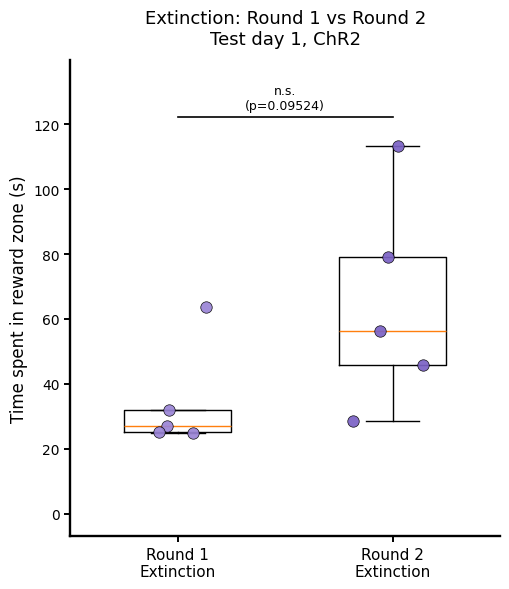


Forgetting: Round 1 vs Round 2, test day 1
Metric: time_in_trigger_s
Y-axis label: Time spent in reward zone (s)
Genotypes included: ['ChR2']
Value mode: mean

Round 1 Forgetting: n = 5, ids = ['AC', 'AE', 'AF', 'AH', 'AO'], test_order = ['fe', 'ff', 'fe', 'fe', 'fe'], values_s = [47.428 36.182 48.096 69.31  88.876]
Round 2 Forgetting: n = 5, ids = ['AB', 'AE', 'AG', 'AM', 'AN'], test_order = ['ef', 'ff', 'ef', 'ef', 'ef'], values_s = [25.201 47.726 44.121 15.905 30.338]
Animals appearing in both round groups: n = 1, ids = ['AE']

Mann–Whitney U test: n=5 vs 5, Round 1 mean=57.978 s, Round 2 mean=32.658 s, Round 1 median=48.096 s, Round 2 median=30.338 s, U=22.0, rank-biserial=0.760, p=0.05556


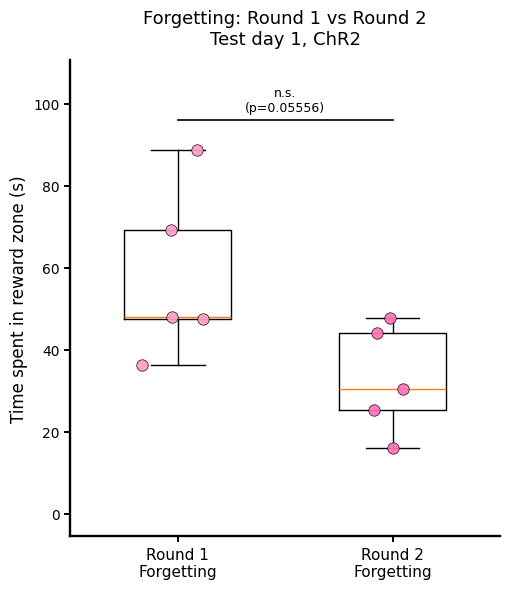


Extinction: Round 1 vs Round 2, test day 5
Metric: time_in_trigger_s
Y-axis label: Time spent in reward zone (s)
Genotypes included: ['ChR2']
Value mode: mean

Round 1 Extinction: n = 5, ids = ['AB', 'AD', 'AG', 'AM', 'AN'], test_order = ['ef', 'ee', 'ef', 'ef', 'ef'], values_s = [ 5.778 66.623  6.133  6.41   9.871]
Round 2 Extinction: n = 4, ids = ['AC', 'AD', 'AF', 'AO'], test_order = ['fe', 'ee', 'fe', 'fe'], values_s = [9.167 6.848 2.119 5.8  ]
Animals appearing in both round groups: n = 1, ids = ['AD']

Mann–Whitney U test: n=5 vs 4, Round 1 mean=18.963 s, Round 2 mean=5.984 s, Round 1 median=6.410 s, Round 2 median=6.324 s, U=13.0, rank-biserial=0.300, p=0.55556


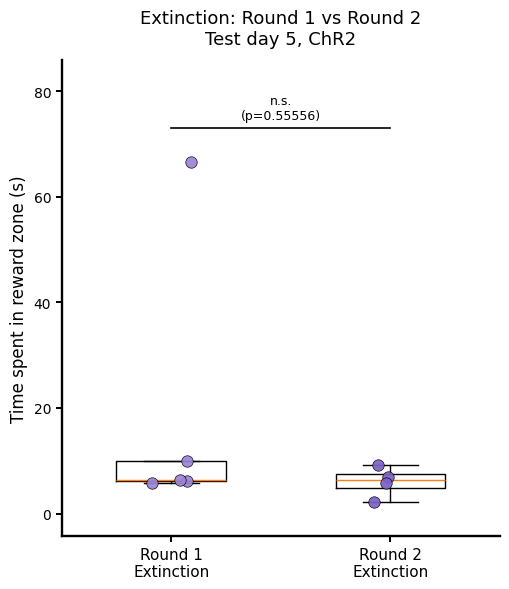


Forgetting: Round 1 vs Round 2, test day 5
Metric: time_in_trigger_s
Y-axis label: Time spent in reward zone (s)
Genotypes included: ['ChR2']
Value mode: mean

Round 1 Forgetting: n = 5, ids = ['AC', 'AE', 'AF', 'AH', 'AO'], test_order = ['fe', 'ff', 'fe', 'fe', 'fe'], values_s = [26.293 66.459 48.458 32.099 23.758]
Round 2 Forgetting: n = 5, ids = ['AB', 'AE', 'AG', 'AM', 'AN'], test_order = ['ef', 'ff', 'ef', 'ef', 'ef'], values_s = [31.542 77.723 14.846  6.617  3.88 ]
Animals appearing in both round groups: n = 1, ids = ['AE']

Mann–Whitney U test: n=5 vs 5, Round 1 mean=39.413 s, Round 2 mean=26.922 s, Round 1 median=32.099 s, Round 2 median=14.846 s, U=18.0, rank-biserial=0.440, p=0.30952


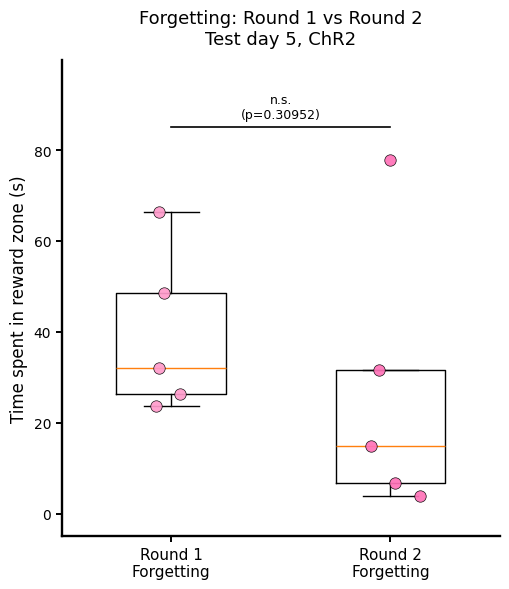

In [272]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ============================================================
# Round 1 vs Round 2 memory-test comparison
#
# Metric:
#   time_in_trigger_s
#       = time spent in reward zone, already stored in seconds
#
# Comparisons produced:
#   1) Day 1: Round 1 Extinction vs Round 2 Extinction
#   2) Day 1: Round 1 Forgetting vs Round 2 Forgetting
#   3) Day 5: Round 1 Extinction vs Round 2 Extinction
#   4) Day 5: Round 1 Forgetting vs Round 2 Forgetting
#
# Round definition:
#   test_order == 'ef'
#       Round 1 = extinction, Round 2 = forgetting
#
#   test_order == 'fe'
#       Round 1 = forgetting, Round 2 = extinction
#
#   test_order == 'ff'
#       Round 1 = forgetting, Round 2 = forgetting
#
#   test_order == 'ee'
#       Round 1 = extinction, Round 2 = extinction
#
# Round assignment:
#   - For ef / fe, test_type identifies the round.
#   - For ee / ff, the reset of trial_type_day identifies
#     the start of Round 2.
#   - Assignment is checked against test_order afterwards.
#
# Statistics:
#   Mann–Whitney U test: Round 1 vs Round 2 within the same
#   test type and selected test day.
#
# IMPORTANT:
#   - time_in_trigger_s must already exist in metadata.
#   - Values are already in seconds; no conversion is applied.
#   - Animals with test_order == 'ee' or 'ff' may contribute
#     to both Round 1 and Round 2 for the same comparison.
#     The code reports these overlapping animals.
#   - Colours match the two-round line plots:
#         Round 1 = lighter shade
#         Round 2 = darker shade
# ============================================================


# ============================================================
# OPTIONS
# ============================================================

VALUE_COL = 'time_in_trigger_s'
VALUE_LABEL = 'Time spent in reward zone (s)'
VALUE_TITLE = 'Time spent in reward zone'


# ------------------------------------------------------------
# Genotypes to analyse
# ------------------------------------------------------------
# Default below follows your ChR2-focused analysis.
# To analyse eYFP separately, change to ['eYFP_ChR2'].
# ------------------------------------------------------------

GENOTYPES_TO_INCLUDE = ['ChR2']

DISPLAY_NAME = {
    'ChR2': 'ChR2',
    'eYFP_ChR2': 'eYFP',
    'ChR2_short': 'VTA short',
    'ArchT': 'ArchT',
    'eYFP_ArchT': 'eYFP ArchT',
    'WT': 'WT',
}

EXCLUDE_ID = []
EXCLUDE_SUBS = []


# ------------------------------------------------------------
# Selected comparisons
# ------------------------------------------------------------

TEST_TYPES_TO_COMPARE = [
    'extinction',
    'forgetting',
]

TEST_DAYS_TO_COMPARE = [
    1,
    5,
]

VALID_TEST_ORDERS = [
    'ef',
    'fe',
    'ee',
    'ff',
]

VALID_TEST_TYPES = [
    'extinction',
    'forgetting',
]


# ------------------------------------------------------------
# Value per animal × round × test type × test day
# ------------------------------------------------------------
# 'mean':
#     Mean across all available T rows for that animal in the
#     specified round/test type/day.
#
# 'first':
#     First available T row only.
# ------------------------------------------------------------

DAY_VALUE_MODE = 'mean'
# DAY_VALUE_MODE = 'first'

if DAY_VALUE_MODE not in ['mean', 'first']:
    raise ValueError("DAY_VALUE_MODE must be 'mean' or 'first'.")


# ------------------------------------------------------------
# Round-assignment checking
# ------------------------------------------------------------

# If True, rows whose inferred round/test_type disagrees with
# test_order are excluded from plots and statistics.
DROP_TEST_ORDER_MISMATCH_ROWS = True

# Print per-animal inferred round assignment table.
PRINT_ROUND_ASSIGNMENT_TABLE = True

# Print rows removed before round assignment because they are not
# validated two-round extinction/forgetting memory-test rows.
PRINT_REMOVED_NON_MEMORY_TEST_ROWS = True


# ------------------------------------------------------------
# Plot options
# ------------------------------------------------------------

SHOW_ANIMAL_IDS = False

JITTER = 0.08
DOT_SIZE = 68
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.5

BOX_FIGSIZE = (5.2, 6.0)

P_DECIMALS = 5

P_LINE_START_FRAC = 0.10
P_TEXT_OFFSET_FRAC = 0.018
P_TOP_PAD_FRAC = 0.18

BOX_Y_ZERO_PAD_FRAC = 0.05

# Optional manual y-axis limits, in seconds.
BOX_YMIN = None
BOX_YMAX = None

# Optional: use the same y-axis maximum across all four plots.
MATCH_ALL_BOXPLOT_YAXIS = False


# ------------------------------------------------------------
# Colours
# ------------------------------------------------------------
# These colours match the updated two-round line plots.
#
# Round 1 is lighter than Round 2, but is no longer extremely pale.
# Round 2 colours remain essentially unchanged.
# ------------------------------------------------------------

COL_EXT_R1 = "#9A84D6"       # Round 1 extinction: medium-light purple
COL_EXT_R2 = "#7b62c5ff"     # Round 2 extinction: dark purple

COL_FORG_R1 = "#FF9BCB"      # Round 1 forgetting: medium-light pink
COL_FORG_R2 = "#FF72B8"      # Round 2 forgetting: dark pink

ROUND_COLORS = {
    'extinction': {
        1: COL_EXT_R1,
        2: COL_EXT_R2,
    },
    'forgetting': {
        1: COL_FORG_R1,
        2: COL_FORG_R2,
    },
}

TEST_TYPE_LABEL = {
    'extinction': 'Extinction',
    'forgetting': 'Forgetting',
}

ORDER_CODE_TO_TEST_TYPE = {
    'e': 'extinction',
    'f': 'forgetting',
}

np.random.seed(1)


# ============================================================
# General helper functions
# ============================================================

def format_p(p, decimals=P_DECIMALS):
    """
    Format p-value for display.
    """
    if not np.isfinite(p):
        return "NaN"

    return f"{p:.{decimals}f}"


def p_to_stars(p):
    """
    Convert p-value to significance-star annotation.
    """
    if not np.isfinite(p):
        return "n.s."

    if p < 1e-4:
        return "****"

    if p < 1e-3:
        return "***"

    if p < 1e-2:
        return "**"

    if p < 0.05:
        return "*"

    return "n.s."


def style_nature(ax, linewidth=1.8):
    """
    Apply the same clean plot style used in the other figures.
    """
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)

    ax.tick_params(
        direction='out',
        length=4,
        width=1.4
    )

    ax.grid(False)


def get_animal_id(ms, sub):
    """
    Retrieve animal ID if available; otherwise use subject number.
    """
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])

    return str(sub)


def genotype_description():
    """
    Display label for the currently analysed genotype cohort.
    """
    names = [
        DISPLAY_NAME.get(g, g)
        for g in GENOTYPES_TO_INCLUDE
    ]

    return ' + '.join(names)


def expected_test_type_from_order(test_order, test_round):
    """
    Return expected test_type for a given test_order and round.

    Examples:
      ef, round 1 -> extinction
      ef, round 2 -> forgetting
      ff, round 2 -> forgetting
    """
    if not isinstance(test_order, str):
        return pd.NA

    order = test_order.lower().strip()

    if order not in VALID_TEST_ORDERS:
        return pd.NA

    if test_round not in [1, 2]:
        return pd.NA

    code = order[test_round - 1]

    return ORDER_CODE_TO_TEST_TYPE.get(code, pd.NA)


def run_mannwhitney(vals_round1, vals_round2):
    """
    Safe Mann–Whitney U test.

    Returns:
      U statistic, p-value, rank-biserial effect size.
    """
    vals_round1 = np.asarray(vals_round1, dtype=float)
    vals_round2 = np.asarray(vals_round2, dtype=float)

    vals_round1 = vals_round1[np.isfinite(vals_round1)]
    vals_round2 = vals_round2[np.isfinite(vals_round2)]

    if len(vals_round1) == 0 or len(vals_round2) == 0:
        return np.nan, np.nan, np.nan

    stat, p = mannwhitneyu(
        vals_round1,
        vals_round2,
        alternative='two-sided'
    )

    rank_biserial = (
        (2 * stat) / (len(vals_round1) * len(vals_round2)) - 1
    )

    return stat, p, rank_biserial


# ============================================================
# Infer test round from validated memory TEST rows
# ============================================================

def add_inferred_test_round(meta_test_df):
    """
    Add test_round = 1 or 2 to TEST rows.

    Logic:
      - Only validated extinction/forgetting rows with a valid
        two-round test_order should be passed into this function.

      - For test_order == 'ef' or 'fe':
            test_type identifies the round directly.

      - For test_order == 'ee' or 'ff':
            both rounds have the same test type, so Round 2 is
            identified by a reset of trial_type_day, e.g. day 5 -> day 1.

      - The inferred assignment is checked against test_order.
    """
    meta_test_df = meta_test_df.copy()

    meta_test_df['test_type_norm'] = (
        meta_test_df['test_type']
        .astype(str)
        .str.lower()
        .str.strip()
    )

    meta_test_df['test_order_norm'] = (
        meta_test_df['test_order']
        .astype(str)
        .str.lower()
        .str.strip()
    )

    meta_test_df['test_round'] = pd.Series(
        pd.NA,
        index=meta_test_df.index,
        dtype='Int64'
    )

    meta_test_df['expected_test_type_from_order'] = pd.Series(
        pd.NA,
        index=meta_test_df.index,
        dtype='object'
    )

    meta_test_df['test_order_match'] = False

    required_cols = [
        'sub',
        'ses',
        'trial_type_day',
        'test_type_norm',
        'test_order_norm',
    ]

    missing = [
        c for c in required_cols
        if c not in meta_test_df.columns
    ]

    if len(missing) > 0:
        raise KeyError(
            f"Columns required for round assignment are missing: {missing}"
        )

    for sub in sorted(meta_test_df['sub'].unique()):

        ms = meta_test_df[
            meta_test_df['sub'] == sub
        ].copy()

        if len(ms) == 0:
            continue

        order_values = (
            ms['test_order_norm']
            .dropna()
            .unique()
        )

        if len(order_values) == 0:
            print(
                f"WARNING: subject {sub} has no valid test_order; "
                "rows will not match."
            )
            continue

        if len(order_values) > 1:
            print(
                f"WARNING: subject {sub} has multiple test_order values: "
                f"{list(order_values)}. Using {order_values[0]}."
            )

        test_order = str(order_values[0])

        if test_order not in VALID_TEST_ORDERS:
            print(
                f"WARNING: subject {sub} has invalid test_order = "
                f"{test_order}. Expected one of {VALID_TEST_ORDERS}."
            )
            continue

        # ----------------------------------------------------
        # Case 1: two different test types, ef or fe.
        # test_type directly defines the round.
        # ----------------------------------------------------

        if test_order[0] != test_order[1]:

            round1_type = expected_test_type_from_order(
                test_order,
                1
            )

            round2_type = expected_test_type_from_order(
                test_order,
                2
            )

            idx_round1 = ms.index[
                ms['test_type_norm'] == round1_type
            ]

            idx_round2 = ms.index[
                ms['test_type_norm'] == round2_type
            ]

            meta_test_df.loc[idx_round1, 'test_round'] = 1
            meta_test_df.loc[idx_round2, 'test_round'] = 2

        # ----------------------------------------------------
        # Case 2: same test type in both rounds, ee or ff.
        # Infer Round 2 from the day reset.
        # ----------------------------------------------------

        else:

            session_table = (
                ms[
                    ['ses', 'trial_type_day', 'test_type_norm']
                ]
                .drop_duplicates()
                .sort_values(['ses', 'trial_type_day'])
                .reset_index(drop=True)
            )

            current_round = 1
            previous_day = None
            round_by_session = {}

            for _, row in session_table.iterrows():

                this_ses = row['ses']
                this_day = int(row['trial_type_day'])

                if (
                    previous_day is not None and
                    current_round == 1 and
                    this_day < previous_day
                ):
                    current_round = 2

                round_by_session[this_ses] = current_round
                previous_day = this_day

            for idx in ms.index:

                this_ses = meta_test_df.at[idx, 'ses']

                if this_ses in round_by_session:
                    meta_test_df.at[idx, 'test_round'] = (
                        round_by_session[this_ses]
                    )

            assigned_rounds = (
                meta_test_df.loc[ms.index, 'test_round']
                .dropna()
                .astype(int)
                .unique()
            )

            if 2 not in assigned_rounds:
                print(
                    f"WARNING: subject {sub}, test_order='{test_order}': "
                    "no second-round day reset was detected."
                )

        # ----------------------------------------------------
        # Validate inferred assignment against test_order.
        # ----------------------------------------------------

        for idx in ms.index:

            inferred_round = meta_test_df.at[idx, 'test_round']

            if pd.isna(inferred_round):
                continue

            inferred_round = int(inferred_round)

            expected_type = expected_test_type_from_order(
                test_order,
                inferred_round
            )

            meta_test_df.at[
                idx,
                'expected_test_type_from_order'
            ] = expected_type

            meta_test_df.at[
                idx,
                'test_order_match'
            ] = bool(
                meta_test_df.at[idx, 'test_type_norm'] == expected_type
            )

    return meta_test_df


# ============================================================
# Build one value per animal, round, type and day
# ============================================================

def get_round_day_values(
    meta_df,
    test_type,
    test_round,
    test_day,
    value_col
):
    """
    Extract one value per animal for one:
      test_type × test_round × test_day combination.

    DAY_VALUE_MODE:
      'mean'  -> mean across all available TEST rows for that animal
      'first' -> first available TEST row only
    """
    output_cols = [
        'sub',
        'id',
        'genotype',
        'test_order',
        'test_round',
        'test_type',
        'trial_type_day',
        'value',
    ]

    m = meta_df[
        (meta_df['test_type_norm'] == test_type) &
        (meta_df['test_round'] == test_round) &
        (meta_df['trial_type_day'] == test_day) &
        (meta_df[value_col].notna()) &
        (np.isfinite(meta_df[value_col]))
    ].copy()

    rows = []

    for sub in sorted(m['sub'].unique()):

        ms = m[
            m['sub'] == sub
        ].copy()

        if len(ms) == 0:
            continue

        sort_cols = [
            c for c in ['ses', 'trial_id']
            if c in ms.columns
        ]

        if len(sort_cols) > 0:
            ms = ms.sort_values(sort_cols)

        if DAY_VALUE_MODE == 'mean':
            value = float(ms[value_col].mean())

        elif DAY_VALUE_MODE == 'first':
            value = float(ms[value_col].iloc[0])

        else:
            raise ValueError(
                "DAY_VALUE_MODE must be 'mean' or 'first'."
            )

        if not np.isfinite(value):
            continue

        if 'test_order' in ms.columns and ms['test_order'].notna().any():
            test_order = str(ms['test_order'].dropna().iloc[0])
        else:
            test_order = np.nan

        if 'genotype' in ms.columns and ms['genotype'].notna().any():
            genotype = str(ms['genotype'].dropna().iloc[0])
        else:
            genotype = np.nan

        rows.append({
            'sub': sub,
            'id': get_animal_id(ms, sub),
            'genotype': genotype,
            'test_order': test_order,
            'test_round': test_round,
            'test_type': test_type,
            'trial_type_day': test_day,
            'value': value,
        })

    return pd.DataFrame(rows, columns=output_cols)


# ============================================================
# Boxplot y-axis and annotation helpers
# ============================================================

def calculate_plot_y_properties(all_vals):
    """
    Calculate:
      - significance-bar y position
      - significance-text y position
      - automatic plot y-axis maximum
    """
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        return 0.8, 0.85, 1.0

    ymax = float(np.nanmax(all_vals))
    ymin = float(np.nanmin(all_vals))

    yrng = ymax - ymin

    if not np.isfinite(yrng) or yrng <= 0:
        yrng = max(abs(ymax), 1.0)

    sig_y = ymax + P_LINE_START_FRAC * yrng
    text_y = sig_y + P_TEXT_OFFSET_FRAC * yrng

    if BOX_YMAX is not None:
        y_top = float(BOX_YMAX)
    else:
        y_top = text_y + P_TOP_PAD_FRAC * yrng

    if not np.isfinite(y_top) or y_top <= 0:
        y_top = 1.0

    return sig_y, text_y, y_top


def apply_box_y_axis(ax, y_top):
    """
    Apply boxplot y-axis limits.
    """
    if BOX_YMIN is not None:
        y_bottom = float(BOX_YMIN)
    else:
        y_bottom = -BOX_Y_ZERO_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    yticks = ax.get_yticks()
    yticks = yticks[
        (yticks >= 0) &
        (yticks <= y_top)
    ]

    if len(yticks) == 0 or yticks[0] != 0:
        yticks = np.insert(yticks, 0, 0)

    ax.set_yticks(yticks)


def draw_sig_bar(ax, x1, x2, sig_y, text_y, p):
    """
    Draw horizontal statistical comparison bar with stars and p-value.
    """
    ax.plot(
        [x1, x2],
        [sig_y, sig_y],
        color='black',
        linewidth=1.2
    )

    ax.text(
        (x1 + x2) / 2,
        text_y,
        f"{p_to_stars(p)}\n(p={format_p(p)})",
        ha='center',
        va='bottom',
        fontsize=9
    )


# ============================================================
# Prepare TEST metadata and assign round
# ============================================================

needed_cols = [
    'trial_type',
    'genotype',
    'sub',
    'ses',
    'trial_type_day',
    'test_type',
    'test_order',
    VALUE_COL,
]

missing_cols = [
    c for c in needed_cols
    if c not in metadata.columns
]

if len(missing_cols) > 0:
    raise KeyError(
        f"Missing required columns in metadata: {missing_cols}"
    )


# ------------------------------------------------------------
# Start with all relevant TEST rows in the chosen genotype cohort.
# ------------------------------------------------------------

meta_T_all = metadata[
    (metadata['trial_type'] == 'T') &
    (metadata['genotype'].isin(GENOTYPES_TO_INCLUDE)) &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata[VALUE_COL].notna()) &
    (np.isfinite(metadata[VALUE_COL]))
].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_T_all.columns:
    meta_T_all = meta_T_all[
        ~meta_T_all['id'].astype(str).isin(
            [str(x) for x in EXCLUDE_ID]
        )
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_T_all = meta_T_all[
        ~meta_T_all['sub'].astype(str).isin(
            [str(x) for x in EXCLUDE_SUBS]
        )
    ].copy()

if len(meta_T_all) == 0:
    raise ValueError("No TEST rows remain after filtering.")


# ------------------------------------------------------------
# Retain only validated two-round extinction/forgetting rows.
# This prevents unrelated T rows or animals with missing/unsupported
# test_order values entering the round-comparison plots.
# ------------------------------------------------------------

meta_T_all['test_type_norm_initial'] = (
    meta_T_all['test_type']
    .astype(str)
    .str.lower()
    .str.strip()
)

meta_T_all['test_order_norm_initial'] = (
    meta_T_all['test_order']
    .astype(str)
    .str.lower()
    .str.strip()
)

valid_memory_mask = (
    meta_T_all['test_type_norm_initial'].isin(VALID_TEST_TYPES) &
    meta_T_all['test_order_norm_initial'].isin(VALID_TEST_ORDERS)
)

meta_T = meta_T_all[
    valid_memory_mask
].copy()

removed_non_memory_test_rows = meta_T_all[
    ~valid_memory_mask
].copy()


if PRINT_REMOVED_NON_MEMORY_TEST_ROWS:

    print("\n============================================================")
    print("TEST ROW FILTERING BEFORE ROUND ASSIGNMENT")
    print("============================================================")

    print(
        "Rows kept for validated two-round extinction/forgetting analysis:",
        len(meta_T)
    )

    print(
        "Rows removed because they are not validated "
        "two-round extinction/forgetting rows:",
        len(removed_non_memory_test_rows)
    )

    if len(removed_non_memory_test_rows) > 0:

        removed_cols = [
            c for c in [
                'sub',
                'id',
                'genotype',
                'ses',
                'trial_type_day',
                'test_type',
                'test_order',
                VALUE_COL,
            ]
            if c in removed_non_memory_test_rows.columns
        ]

        sort_cols = [
            c for c in ['sub', 'ses', 'trial_type_day']
            if c in removed_cols
        ]

        print("\nRemoved TEST rows:")
        print(
            removed_non_memory_test_rows[removed_cols]
            .drop_duplicates()
            .sort_values(sort_cols)
            .reset_index(drop=True)
        )


if len(meta_T) == 0:
    raise ValueError(
        "No validated two-round extinction/forgetting TEST rows "
        "remain after filtering."
    )


# ------------------------------------------------------------
# Infer test round and validate against test_order.
# ------------------------------------------------------------

meta_T = add_inferred_test_round(meta_T)


print("\n============================================================")
print("ROUND 1 VS ROUND 2 ANALYSIS")
print("============================================================")
print("Metric:", VALUE_COL)
print("Y-axis label:", VALUE_LABEL)
print("Genotypes included:", GENOTYPES_TO_INCLUDE)
print("Displayed cohort:", genotype_description())
print("Value per animal/day mode:", DAY_VALUE_MODE)
print("Values are already in seconds; no conversion applied.")
print("Mann–Whitney U is used for Round 1 vs Round 2 comparisons.")
print(
    "Animals with repeated test types ('ee' or 'ff') can occur in "
    "both round groups; overlapping animals are printed below."
)

print("\nColours used:")
print(f"  Round 1 Extinction: {COL_EXT_R1}")
print(f"  Round 2 Extinction: {COL_EXT_R2}")
print(f"  Round 1 Forgetting: {COL_FORG_R1}")
print(f"  Round 2 Forgetting: {COL_FORG_R2}")


if PRINT_ROUND_ASSIGNMENT_TABLE:

    round_assignment_cols = ['sub']

    if 'id' in meta_T.columns:
        round_assignment_cols.append('id')

    round_assignment_cols += [
        'genotype',
        'test_order',
        'ses',
        'trial_type_day',
        'test_type_norm',
        'test_round',
        'expected_test_type_from_order',
        'test_order_match',
    ]

    print("\nInferred round assignment by test session:")
    print(
        meta_T[round_assignment_cols]
        .drop_duplicates()
        .sort_values(['sub', 'ses', 'trial_type_day'])
        .reset_index(drop=True)
    )


mismatch_rows = meta_T[
    ~meta_T['test_order_match']
].copy()

print("\nRound-assignment/test_order mismatches:", len(mismatch_rows))

if len(mismatch_rows) > 0:

    mismatch_cols = ['sub']

    if 'id' in mismatch_rows.columns:
        mismatch_cols.append('id')

    mismatch_cols += [
        'test_order',
        'ses',
        'trial_type_day',
        'test_type_norm',
        'test_round',
        'expected_test_type_from_order',
    ]

    print(
        mismatch_rows[mismatch_cols]
        .drop_duplicates()
        .sort_values(['sub', 'ses', 'trial_type_day'])
        .reset_index(drop=True)
    )

    if DROP_TEST_ORDER_MISMATCH_ROWS:
        print("Mismatching rows are excluded from analysis.")

        meta_T = meta_T[
            meta_T['test_order_match']
        ].copy()

    else:
        print(
            "Mismatching rows are retained because "
            "DROP_TEST_ORDER_MISMATCH_ROWS=False."
        )


if len(meta_T) == 0:
    raise ValueError(
        "No rows remain after round-assignment validation."
    )


# ============================================================
# Prepare specifications for the four requested boxplots
# ============================================================

plot_specs = []

for test_day in TEST_DAYS_TO_COMPARE:

    for test_type in TEST_TYPES_TO_COMPARE:

        df_round1 = get_round_day_values(
            meta_df=meta_T,
            test_type=test_type,
            test_round=1,
            test_day=test_day,
            value_col=VALUE_COL
        )

        df_round2 = get_round_day_values(
            meta_df=meta_T,
            test_type=test_type,
            test_round=2,
            test_day=test_day,
            value_col=VALUE_COL
        )

        vals_round1 = df_round1['value'].values.astype(float)
        vals_round2 = df_round2['value'].values.astype(float)

        vals_round1 = vals_round1[
            np.isfinite(vals_round1)
        ]

        vals_round2 = vals_round2[
            np.isfinite(vals_round2)
        ]

        stat, p, rank_biserial = run_mannwhitney(
            vals_round1,
            vals_round2
        )

        all_vals = np.r_[
            vals_round1,
            vals_round2
        ]

        all_vals = all_vals[
            np.isfinite(all_vals)
        ]

        sig_y, text_y, automatic_y_top = calculate_plot_y_properties(
            all_vals
        )

        overlapping_subs = sorted(
            set(df_round1['sub']).intersection(
                set(df_round2['sub'])
            )
        )

        overlap_ids = []

        for sub in overlapping_subs:

            source_df = pd.concat(
                [
                    df_round1[
                        df_round1['sub'] == sub
                    ],
                    df_round2[
                        df_round2['sub'] == sub
                    ],
                ],
                ignore_index=True
            )

            overlap_ids.append(
                get_animal_id(source_df, sub)
            )

        plot_specs.append({
            'test_day': test_day,
            'test_type': test_type,
            'df_round1': df_round1,
            'df_round2': df_round2,
            'vals_round1': vals_round1,
            'vals_round2': vals_round2,
            'stat': stat,
            'p': p,
            'rank_biserial': rank_biserial,
            'all_vals': all_vals,
            'sig_y': sig_y,
            'text_y': text_y,
            'automatic_y_top': automatic_y_top,
            'final_y_top': automatic_y_top,
            'overlapping_subs': overlapping_subs,
            'overlap_ids': overlap_ids,
        })


# ------------------------------------------------------------
# Optional shared y-axis across all four plots
# ------------------------------------------------------------

if MATCH_ALL_BOXPLOT_YAXIS and len(plot_specs) > 0:

    matched_y_top = max(
        spec['automatic_y_top']
        for spec in plot_specs
    )

    for spec in plot_specs:
        spec['final_y_top'] = matched_y_top


# ============================================================
# Render the four boxplots
# ============================================================

def render_round_comparison_boxplot(spec):
    """
    Plot Round 1 vs Round 2 for a selected test type and test day.
    """
    test_day = spec['test_day']
    test_type = spec['test_type']

    df_round1 = spec['df_round1']
    df_round2 = spec['df_round2']

    vals_round1 = spec['vals_round1']
    vals_round2 = spec['vals_round2']

    stat = spec['stat']
    p = spec['p']
    rank_biserial = spec['rank_biserial']

    test_label = TEST_TYPE_LABEL.get(test_type, test_type)

    print("\n============================================================")
    print(
        f"{test_label}: Round 1 vs Round 2, test day {test_day}"
    )
    print("Metric:", VALUE_COL)
    print("Y-axis label:", VALUE_LABEL)
    print("Genotypes included:", GENOTYPES_TO_INCLUDE)
    print("Value mode:", DAY_VALUE_MODE)

    print(
        f"\nRound 1 {test_label}: "
        f"n = {len(df_round1)}, "
        f"ids = {list(df_round1['id'])}, "
        f"test_order = {list(df_round1['test_order'])}, "
        f"values_s = {np.round(vals_round1, 4)}"
    )

    print(
        f"Round 2 {test_label}: "
        f"n = {len(df_round2)}, "
        f"ids = {list(df_round2['id'])}, "
        f"test_order = {list(df_round2['test_order'])}, "
        f"values_s = {np.round(vals_round2, 4)}"
    )

    print(
        f"Animals appearing in both round groups: "
        f"n = {len(spec['overlapping_subs'])}, "
        f"ids = {spec['overlap_ids']}"
    )

    if np.isfinite(p):

        print(
            f"\nMann–Whitney U test: "
            f"n={len(vals_round1)} vs {len(vals_round2)}, "
            f"Round 1 mean={np.nanmean(vals_round1):.3f} s, "
            f"Round 2 mean={np.nanmean(vals_round2):.3f} s, "
            f"Round 1 median={np.nanmedian(vals_round1):.3f} s, "
            f"Round 2 median={np.nanmedian(vals_round2):.3f} s, "
            f"U={stat:.1f}, "
            f"rank-biserial={rank_biserial:.3f}, "
            f"p={format_p(p)}"
        )

    else:

        print(
            "\nMann–Whitney U test: p = NaN because "
            "one group has no values."
        )

    fig, ax = plt.subplots(
        figsize=BOX_FIGSIZE
    )

    positions = np.array([0, 1])

    vals_groups = [
        vals_round1,
        vals_round2,
    ]

    ax.boxplot(
        vals_groups,
        positions=positions,
        widths=0.50,
        patch_artist=False,
        showfliers=False
    )

    for i, (df_group, values, round_number) in enumerate([
        (df_round1, vals_round1, 1),
        (df_round2, vals_round2, 2),
    ]):

        if len(values) == 0:
            continue

        x = np.random.normal(
            positions[i],
            JITTER,
            size=len(values)
        )

        ax.scatter(
            x,
            values,
            s=DOT_SIZE,
            color=ROUND_COLORS[test_type][round_number],
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            alpha=0.92,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:

            for xi, yi, animal_id in zip(
                x,
                values,
                df_group['id'].values
            ):

                ax.text(
                    xi + 0.035,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=ROUND_COLORS[test_type][round_number],
                    ha='left',
                    va='center',
                    alpha=0.95,
                    zorder=4
                )

    if np.isfinite(p) and len(spec['all_vals']) > 0:

        draw_sig_bar(
            ax=ax,
            x1=positions[0],
            x2=positions[1],
            sig_y=spec['sig_y'],
            text_y=spec['text_y'],
            p=p
        )

    ax.set_xticks(positions)

    ax.set_xticklabels(
        [
            f'Round 1\n{test_label}',
            f'Round 2\n{test_label}',
        ],
        fontsize=11
    )

    ax.set_ylabel(
        VALUE_LABEL,
        fontsize=12
    )

    ax.set_title(
        f'{test_label}: Round 1 vs Round 2\n'
        f'Test day {test_day}, {genotype_description()}',
        fontsize=13,
        pad=12
    )

    style_nature(
        ax,
        linewidth=1.7
    )

    apply_box_y_axis(
        ax=ax,
        y_top=spec['final_y_top']
    )

    plt.tight_layout()
    plt.show()


for spec in plot_specs:
    render_round_comparison_boxplot(spec)


TEST ROW FILTERING BEFORE ROUND ASSIGNMENT
Rows kept for two-round extinction/forgetting analysis: 69
Rows removed because they are not validated two-round extinction/forgetting rows: 21

Removed TEST rows:
    sub  id genotype  ses  trial_type_day   test_type test_order  \
0     1   A     ChR2    9               1  extinction          e   
1     1   A     ChR2   10               2  extinction          e   
2     1   A     ChR2   11               3  extinction          e   
3     3   C     ChR2    9               1         NaN        NaN   
4     4   D     ChR2    9               1         NaN        NaN   
5     8  AD     ChR2   26               1         NaN         ee   
6     8  AD     ChR2   28               1         NaN         ee   
7     9  AE     ChR2   20               1         NaN         ff   
8     9  AE     ChR2   22               1         NaN         ff   
9    10  AF     ChR2   23               1         NaN         fe   
10   11  AG     ChR2   23               1   

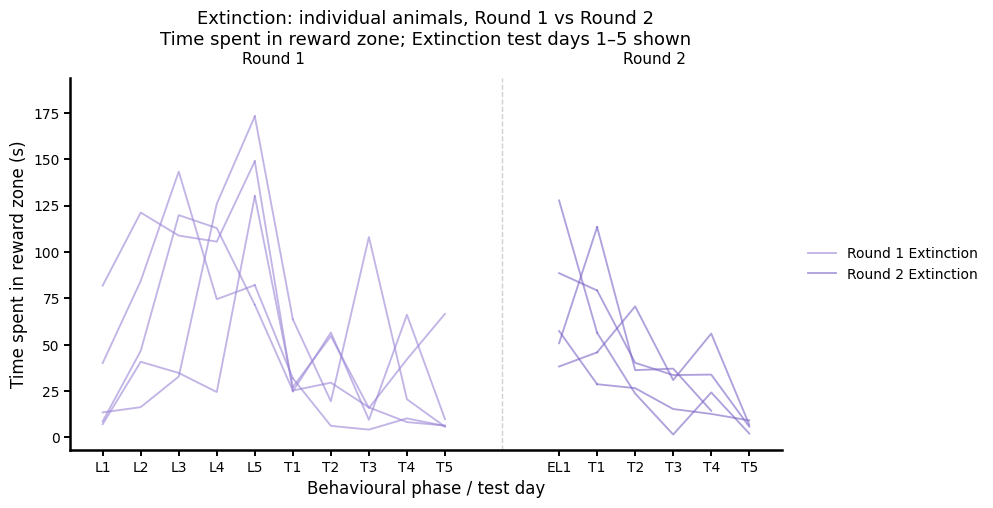


AVERAGE PLOT: Extinction
Inclusion rule: complete test round only; required test days = [1, 2, 3, 4, 5]
Plot style: code1
SEM display: shaded
Round 1 Extinction: n=5, ids=['AB', 'AD', 'AG', 'AM', 'AN'], subs=[np.int64(6), np.int64(8), np.int64(11), np.int64(16), np.int64(17)]
Round 2 Extinction: n=4, ids=['AC', 'AD', 'AF', 'AO'], subs=[np.int64(7), np.int64(8), np.int64(10), np.int64(18)]

Mean/SEM values plotted: Extinction, Round 1
  L1: mean=30.241, SEM=14.216, n=5
  L2: mean=61.850, SEM=18.404, n=5
  L3: mean=87.891, SEM=22.783, n=5
  L4: mean=88.652, SEM=18.136, n=5
  L5: mean=121.116, SEM=19.411, n=5
  T1: mean=34.550, SEM=7.382, n=5
  T2: mean=33.284, SEM=9.832, n=5
  T3: mean=30.750, SEM=19.439, n=5
  T4: mean=29.468, SEM=10.953, n=5
  T5: mean=18.963, SEM=11.938, n=5

Mean/SEM values plotted: Extinction, Round 2
  EL1: mean=77.960, SEM=19.561, n=4
  T1: mean=52.539, SEM=10.565, n=4
  T2: mean=40.270, SEM=10.740, n=4
  T3: mean=20.355, SEM=7.445, n=4
  T4: mean=31.688, SEM=9.1

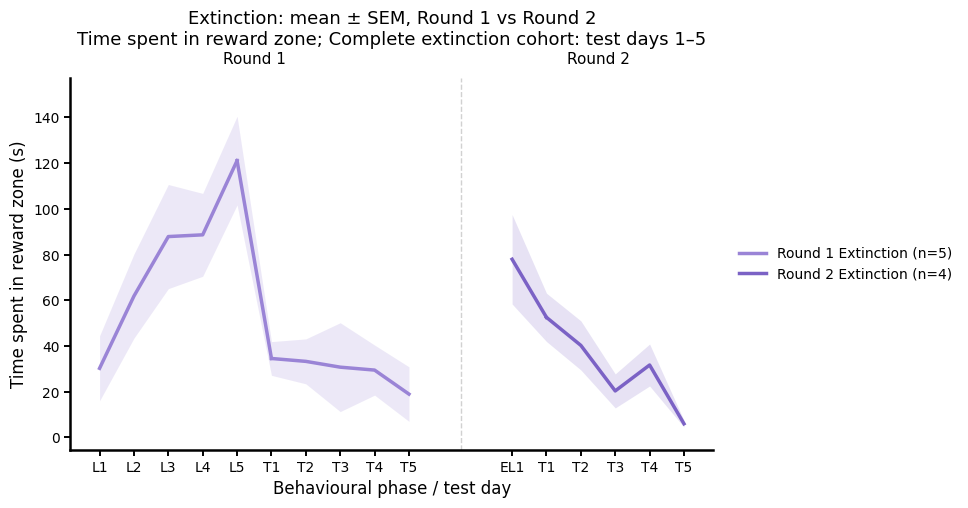


INDIVIDUAL ANIMAL PLOT: Forgetting
Inclusion rule: any animal with any available test value.
Plot style: code1
Round 1 Forgetting: n=5, ids=['AC', 'AE', 'AF', 'AH', 'AO'], subs=[7, 9, 10, 12, 18]
Round 2 Forgetting: n=5, ids=['AB', 'AE', 'AG', 'AM', 'AN'], subs=[6, 9, 11, 16, 17]
Animals contributing this test type in both rounds: n=1, ids=['AE']


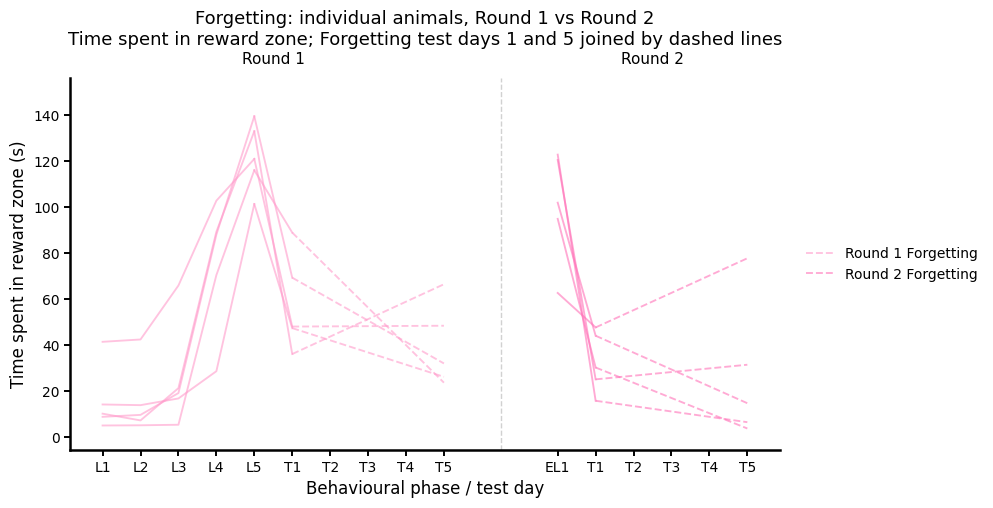


AVERAGE PLOT: Forgetting
Inclusion rule: complete test round only; required test days = [1, 5]
Plot style: code1
SEM display: shaded
Round 1 Forgetting: n=5, ids=['AC', 'AE', 'AF', 'AH', 'AO'], subs=[np.int64(7), np.int64(9), np.int64(10), np.int64(12), np.int64(18)]
Round 2 Forgetting: n=5, ids=['AB', 'AE', 'AG', 'AM', 'AN'], subs=[np.int64(6), np.int64(9), np.int64(11), np.int64(16), np.int64(17)]

Mean/SEM values plotted: Forgetting, Round 1
  L1: mean=16.044, SEM=6.525, n=5
  L2: mean=15.790, SEM=6.833, n=5
  L3: mean=25.796, SEM=10.398, n=5
  L4: mean=75.807, SEM=12.837, n=5
  L5: mean=122.034, SEM=6.659, n=5
  T1: mean=57.978, SEM=9.400, n=5
  T5: mean=39.413, SEM=8.013, n=5

Mean/SEM values plotted: Forgetting, Round 2
  EL1: mean=100.479, SEM=10.841, n=5
  T1: mean=32.658, SEM=5.916, n=5
  T5: mean=26.922, SEM=13.585, n=5


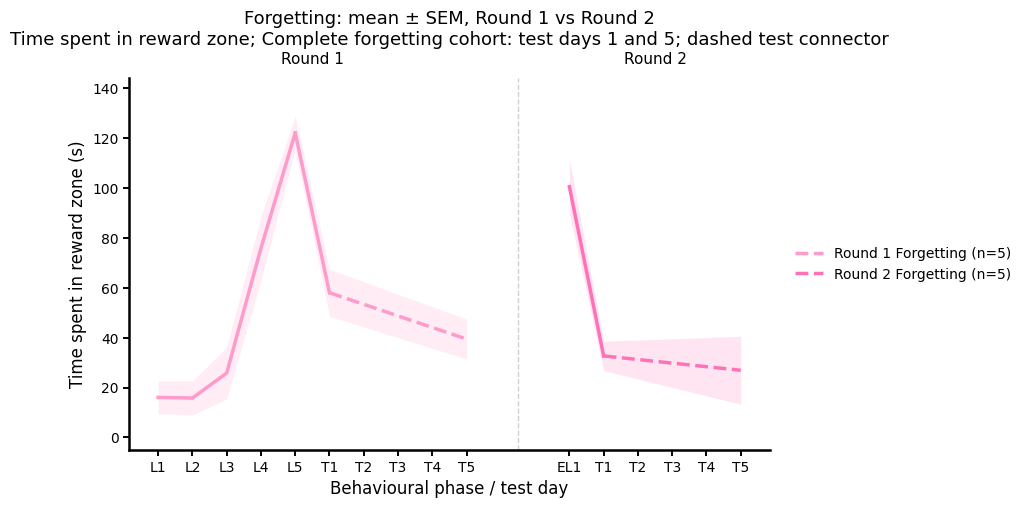


COMBINED AVERAGE PLOT: EXTINCTION + FORGETTING
Inclusion rules:
  Extinction: complete test days 1-5 only.
  Forgetting: complete test days 1 and 5 only.
Plot style: code1
SEM display: shaded
Round 1 Extinction: n=5, ids=['AB', 'AD', 'AG', 'AM', 'AN'], subs=[np.int64(6), np.int64(8), np.int64(11), np.int64(16), np.int64(17)]
Round 2 Extinction: n=4, ids=['AC', 'AD', 'AF', 'AO'], subs=[np.int64(7), np.int64(8), np.int64(10), np.int64(18)]
Round 1 Forgetting: n=5, ids=['AC', 'AE', 'AF', 'AH', 'AO'], subs=[np.int64(7), np.int64(9), np.int64(10), np.int64(12), np.int64(18)]
Round 2 Forgetting: n=5, ids=['AB', 'AE', 'AG', 'AM', 'AN'], subs=[np.int64(6), np.int64(9), np.int64(11), np.int64(16), np.int64(17)]

Mean/SEM values plotted: Extinction, Round 1
  L1: mean=30.241, SEM=14.216, n=5
  L2: mean=61.850, SEM=18.404, n=5
  L3: mean=87.891, SEM=22.783, n=5
  L4: mean=88.652, SEM=18.136, n=5
  L5: mean=121.116, SEM=19.411, n=5
  T1: mean=34.550, SEM=7.382, n=5
  T2: mean=33.284, SEM=9.832, n

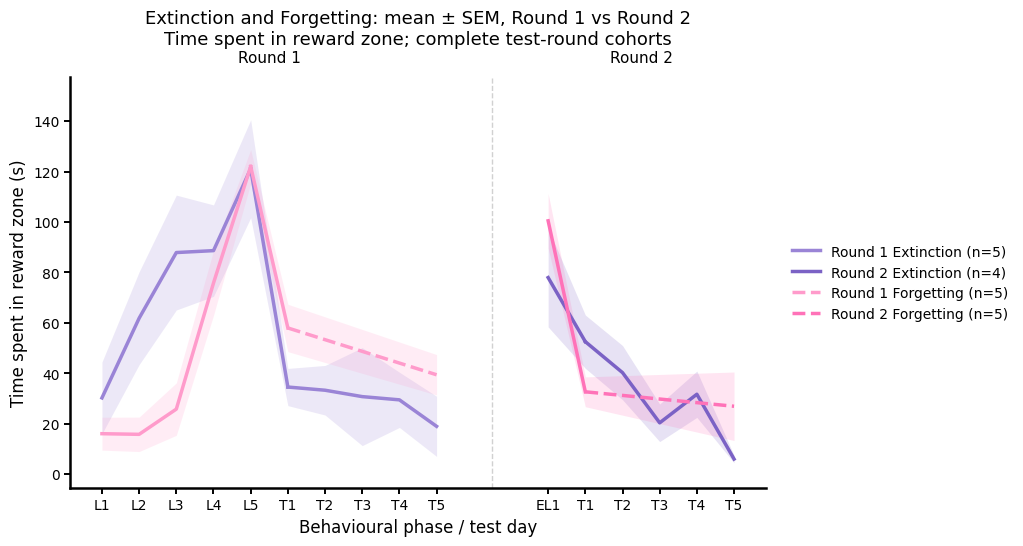

In [271]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Time spent in reward zone across two memory-test rounds
#
# Metric:
#   time_in_trigger_s
#       = time spent in reward zone, already stored in seconds
#
# Timeline:
#
#   Learning days 1-5 -> Round 1 memory test
#                       [visual gap]
#   Extra learning day 1 -> Round 2 memory test
#
# Test-round interpretation:
#   test_order == 'ef':
#       Round 1 = extinction
#       Round 2 = forgetting
#
#   test_order == 'fe':
#       Round 1 = forgetting
#       Round 2 = extinction
#
#   test_order == 'ee':
#       Round 1 = extinction
#       Round 2 = extinction
#
#   test_order == 'ff':
#       Round 1 = forgetting
#       Round 2 = forgetting
#
# Plots produced:
#
#   1) Individual-animal extinction plot
#   2) Average extinction plot
#   3) Individual-animal forgetting plot
#   4) Average forgetting plot
#   5) Combined average extinction + forgetting plot
#
# Individual-animal plots:
#   - Include any animal with at least one available test-day
#     value for that test type in that round.
#
# Average plots:
#   - Extinction:
#         include only animals with complete test days 1-5
#         within that round.
#
#   - Forgetting:
#         include only animals with both test day 1 and test day 5
#         within that round.
#
# Plot style presets:
#
#   PLOT_STYLE = 'code1'   [DEFAULT]
#       - no dots on data points
#       - shaded SEM
#       - continuous SEM shading across:
#             L5  -> Round 1 T1
#             EL1 -> Round 2 T1
#       - no isolated shaded box around EL1
#
#   PLOT_STYLE = 'code2'
#       - dots on data points
#       - SEM error bars
#
# Y-axis behaviour:
#   - Individual plots use the highest plotted individual value.
#   - Average plots use the highest plotted mean + SEM value.
#   - The automatic upper padding is intentionally small so the
#     y-axis fits the plotted data more closely.
#
# Values are already in seconds. No conversion is applied.
# ============================================================


# ============================================================
# OPTIONS
# ============================================================

VALUE_COL = 'time_in_trigger_s'
VALUE_LABEL = 'Time spent in reward zone (s)'
VALUE_TITLE = 'Time spent in reward zone'


# ------------------------------------------------------------
# Genotype filter
# ------------------------------------------------------------

GENOTYPES_TO_INCLUDE = ['ChR2']

DISPLAY_NAME = {
    'ChR2': 'ChR2',
    'eYFP_ChR2': 'eYFP',
    'ChR2_short': 'VTA short',
    'ArchT': 'ArchT',
    'eYFP_ArchT': 'eYFP ArchT',
    'WT': 'WT',
}

EXCLUDE_ID = []
EXCLUDE_SUBS = []

TEST_TYPES_TO_PLOT = [
    'extinction',
    'forgetting',
]

VALID_TEST_ORDERS = [
    'ef',
    'fe',
    'ee',
    'ff',
]

VALID_TEST_TYPES = [
    'extinction',
    'forgetting',
]


# ------------------------------------------------------------
# Daily value rule
# ------------------------------------------------------------
# 'mean':
#     For an animal on a specified day, average all available
#     rows from that day.
#
# 'first':
#     Use only the first available row from that day.
# ------------------------------------------------------------

DAY_VALUE_MODE = 'mean'
# DAY_VALUE_MODE = 'first'

if DAY_VALUE_MODE not in ['mean', 'first']:
    raise ValueError("DAY_VALUE_MODE must be 'mean' or 'first'.")


# ------------------------------------------------------------
# Round assignment validation
# ------------------------------------------------------------

PRINT_ROUND_ASSIGNMENT_TABLE = True
PRINT_REMOVED_NON_MEMORY_TEST_ROWS = True

# If True, rows whose inferred test round conflicts with test_order
# are removed from plotting.
DROP_TEST_ORDER_MISMATCH_ROWS = True


# ------------------------------------------------------------
# Plot switches
# ------------------------------------------------------------

RUN_INDIVIDUAL_PLOTS = True
RUN_AVERAGE_PLOTS = True
RUN_COMBINED_AVERAGE_PLOT = True

SHOW_INDIVIDUAL_LEGEND = True


# ------------------------------------------------------------
# Plot-style preset
# ------------------------------------------------------------
# 'code1' [DEFAULT]:
#     no dots; shaded SEM; continuous shaded ribbons
#
# 'code2':
#     dots; SEM error bars
# ------------------------------------------------------------

PLOT_STYLE = 'code1'
# PLOT_STYLE = 'code2'

VALID_PLOT_STYLES = ['code1', 'code2']

if PLOT_STYLE not in VALID_PLOT_STYLES:
    raise ValueError(
        f"PLOT_STYLE must be one of {VALID_PLOT_STYLES}."
    )

STYLE_OPTIONS = {
    'code1': {
        'show_markers': False,
        'sem_style': 'shaded',
    },
    'code2': {
        'show_markers': True,
        'sem_style': 'bar',
    },
}

SHOW_MARKERS = STYLE_OPTIONS[PLOT_STYLE]['show_markers']
SEM_STYLE = STYLE_OPTIONS[PLOT_STYLE]['sem_style']


# ------------------------------------------------------------
# Plot appearance
# ------------------------------------------------------------

# Individual plot appearance
INDIVIDUAL_FIGSIZE = (12.0, 5.4)
INDIVIDUAL_LINEWIDTH = 1.35
INDIVIDUAL_ALPHA = 0.60
INDIVIDUAL_MARKERSIZE = 3.8

# Average plot appearance
AVERAGE_FIGSIZE = (12.0, 5.4)
AVERAGE_LINEWIDTH = 2.5
AVERAGE_MARKERSIZE = 5.5

# Combined average plot appearance
COMBINED_AVERAGE_FIGSIZE = (13.0, 5.8)
COMBINED_AVERAGE_LINEWIDTH = 2.5
COMBINED_AVERAGE_MARKERSIZE = 5.5

# SEM appearance
SEM_ALPHA = 0.18

SEM_BAR_ALPHA = 0.55
SEM_BAR_LINEWIDTH = 1.3
SEM_BAR_CAPSIZE = 3


# ------------------------------------------------------------
# Axis appearance
# ------------------------------------------------------------
# Upper padding is reduced compared with the previous code.
# Average plots are fitted to the maximum mean + SEM boundary.
# ------------------------------------------------------------

Y_BOTTOM_PAD_FRAC = 0.035
Y_TOP_PAD_FRAC = 0.12

YMIN_BY_PLOT_TYPE = {
    'extinction': 0,
    'forgetting': 0,
    'combined': 0,
}

YMAX_BY_PLOT_TYPE = {
    'extinction': None,
    'forgetting': None,
    'combined': None,
}


# ------------------------------------------------------------
# Colours
# ------------------------------------------------------------
# Round 1 colours are lighter than Round 2, but not extremely pale.
# ------------------------------------------------------------

COL_EXT_R1 = "#9A84D6"       # medium-light purple
COL_EXT_R2 = "#7b62c5ff"     # dark purple

COL_FORG_R1 = "#FF9BCB"      # medium-light pink
COL_FORG_R2 = "#FF72B8"      # dark pink

ROUND_COLORS = {
    'extinction': {
        1: COL_EXT_R1,
        2: COL_EXT_R2,
    },
    'forgetting': {
        1: COL_FORG_R1,
        2: COL_FORG_R2,
    },
}

TEST_TYPE_LABEL = {
    'extinction': 'Extinction',
    'forgetting': 'Forgetting',
}

ORDER_CODE_TO_TEST_TYPE = {
    'e': 'extinction',
    'f': 'forgetting',
}


# ============================================================
# Timeline positions
# ============================================================
#
# Round 1:
#   L1-L5       = x 1-5
#   R1 T1-T5    = x 6-10
#
# Gap:
#   no data plotted at x 11-12
#
# Round 2:
#   EL1         = x 13
#   R2 T1-T5    = x 14-18
#
# For forgetting:
#   only T1 and T5 are plotted:
#       Round 1 = x 6 and x 10
#       Round 2 = x 14 and x 18
# ============================================================

X_LEARNING = np.array([1, 2, 3, 4, 5], dtype=float)
X_R1_TEST_ALL = np.array([6, 7, 8, 9, 10], dtype=float)

X_EXTRA_LEARNING = np.array([13], dtype=float)
X_R2_TEST_ALL = np.array([14, 15, 16, 17, 18], dtype=float)

ROUND_GAP_LINE_X = 11.5

XTICKS = [
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10,
    13,
    14, 15, 16, 17, 18,
]

XTICKLABELS = [
    'L1', 'L2', 'L3', 'L4', 'L5',
    'T1', 'T2', 'T3', 'T4', 'T5',
    'EL1',
    'T1', 'T2', 'T3', 'T4', 'T5',
]

np.random.seed(1)


# ============================================================
# General helper functions
# ============================================================

def style_nature(ax, linewidth=1.8):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)


def get_animal_id(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


def cohort_label():
    labels = [
        DISPLAY_NAME.get(g, g)
        for g in GENOTYPES_TO_INCLUDE
    ]
    return ' + '.join(labels)


def marker_for_style():
    if SHOW_MARKERS:
        return 'o'
    return None


def markersize_for_style(markersize):
    if SHOW_MARKERS:
        return markersize
    return 0


def expected_test_type_from_order(test_order, test_round):
    """
    Return expected test type for a specified round based on test_order.
    """
    if not isinstance(test_order, str):
        return pd.NA

    order = test_order.lower().strip()

    if order not in VALID_TEST_ORDERS:
        return pd.NA

    if test_round not in [1, 2]:
        return pd.NA

    code = order[test_round - 1]

    return ORDER_CODE_TO_TEST_TYPE.get(code, pd.NA)


def test_days_for_type(test_type):
    """
    Return test days required for a complete test round.
    """
    if test_type == 'extinction':
        return [1, 2, 3, 4, 5]

    if test_type == 'forgetting':
        return [1, 5]

    raise ValueError(f"Unknown test_type: {test_type}")


def test_x_values(test_type, test_round):
    """
    Return x coordinates for the test portion of a round.
    """
    if test_type == 'extinction':
        if test_round == 1:
            return X_R1_TEST_ALL.copy()
        return X_R2_TEST_ALL.copy()

    if test_type == 'forgetting':
        if test_round == 1:
            return np.array([6, 10], dtype=float)
        return np.array([14, 18], dtype=float)

    raise ValueError(f"Unknown test_type: {test_type}")


def test_linestyle(test_type):
    """
    Forgetting test endpoints are joined by a dashed line because
    only test days 1 and 5 exist.
    """
    if test_type == 'forgetting':
        return '--'

    return '-'


def get_one_day_value(meta_df, sub, trial_type, day):
    """
    Return one daily value for one animal and one behavioural phase.

    Used for:
      - L days 1-5
      - EL day 1
    """
    m = meta_df[
        (meta_df['sub'] == sub) &
        (meta_df['trial_type'] == trial_type) &
        (meta_df['trial_type_day'] == day) &
        (meta_df[VALUE_COL].notna()) &
        (np.isfinite(meta_df[VALUE_COL]))
    ].copy()

    if len(m) == 0:
        return np.nan

    sort_cols = [
        c for c in ['ses', 'trial_id']
        if c in m.columns
    ]

    if len(sort_cols) > 0:
        m = m.sort_values(sort_cols)

    if DAY_VALUE_MODE == 'mean':
        return float(m[VALUE_COL].mean())

    if DAY_VALUE_MODE == 'first':
        return float(m[VALUE_COL].iloc[0])

    raise ValueError("DAY_VALUE_MODE must be 'mean' or 'first'.")


def get_one_test_day_value(meta_test_df, sub, test_type, test_round, day):
    """
    Return one test-day value for one animal in one round and test type.
    """
    m = meta_test_df[
        (meta_test_df['sub'] == sub) &
        (meta_test_df['test_type_norm'] == test_type) &
        (meta_test_df['test_round'] == test_round) &
        (meta_test_df['trial_type_day'] == day) &
        (meta_test_df[VALUE_COL].notna()) &
        (np.isfinite(meta_test_df[VALUE_COL]))
    ].copy()

    if len(m) == 0:
        return np.nan

    sort_cols = [
        c for c in ['ses', 'trial_id']
        if c in m.columns
    ]

    if len(sort_cols) > 0:
        m = m.sort_values(sort_cols)

    if DAY_VALUE_MODE == 'mean':
        return float(m[VALUE_COL].mean())

    if DAY_VALUE_MODE == 'first':
        return float(m[VALUE_COL].iloc[0])

    raise ValueError("DAY_VALUE_MODE must be 'mean' or 'first'.")


def mean_and_sem(mat):
    """
    Robust mean and SEM calculation across animals for each column.
    """
    if mat is None or mat.size == 0:
        return None, None, None

    n_cols = mat.shape[1]

    mean_vals = np.full(n_cols, np.nan)
    sem_vals = np.full(n_cols, np.nan)
    n_vals = np.zeros(n_cols, dtype=int)

    for i in range(n_cols):

        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        n_vals[i] = len(vals)

        if len(vals) == 0:
            continue

        mean_vals[i] = float(np.mean(vals))

        if len(vals) == 1:
            sem_vals[i] = 0.0
        else:
            sem_vals[i] = float(
                np.std(vals, ddof=1) / np.sqrt(len(vals))
            )

    return mean_vals, sem_vals, n_vals


def finite_values_from_arrays(*arrays):
    """
    Combine finite values from arrays.
    """
    values = []

    for arr in arrays:

        if arr is None:
            continue

        arr = np.asarray(arr, dtype=float)
        arr = arr[np.isfinite(arr)]

        if len(arr) > 0:
            values.extend(arr.tolist())

    return np.asarray(values, dtype=float)


def finite_values_from_matrices(*matrices):
    """
    Combine finite raw values from matrices.
    """
    values = []

    for mat in matrices:

        if mat is None:
            continue

        arr = np.asarray(mat, dtype=float)
        arr = arr[np.isfinite(arr)]

        if len(arr) > 0:
            values.extend(arr.tolist())

    return np.asarray(values, dtype=float)


def mean_upper_boundary(mean_vals, sem_vals):
    """
    Return upper plotted boundary for y-axis fitting.

    With shaded SEM or SEM bars:
        mean + SEM

    With no SEM:
        mean only
    """
    mean_vals = np.asarray(mean_vals, dtype=float)
    sem_vals = np.asarray(sem_vals, dtype=float)

    if SEM_STYLE in ['shaded', 'bar']:
        upper = mean_vals + sem_vals
    else:
        upper = mean_vals.copy()

    return upper[np.isfinite(upper)]


def apply_y_axis(ax, plotted_top_values, plot_type):
    """
    Apply y-axis limits.

    Parameters
    ----------
    plotted_top_values:
        For individual plots:
            all finite individual y-values.

        For average plots:
            all finite mean + SEM upper-bound values.

    The upper limit is fitted closely to the highest visible plotted
    value, with only a small additional padding.
    """
    values = np.asarray(plotted_top_values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        data_top = 1.0
    else:
        data_top = float(np.nanmax(values))

        if not np.isfinite(data_top) or data_top <= 0:
            data_top = 1.0

    manual_ymin = YMIN_BY_PLOT_TYPE.get(plot_type, None)
    manual_ymax = YMAX_BY_PLOT_TYPE.get(plot_type, None)

    if manual_ymax is not None:
        y_top = float(manual_ymax)
    else:
        y_top = data_top * (1 + Y_TOP_PAD_FRAC)

    if manual_ymin is not None:
        if manual_ymin >= 0:
            y_bottom = -Y_BOTTOM_PAD_FRAC * y_top
        else:
            y_bottom = float(manual_ymin)
    else:
        y_bottom = -Y_BOTTOM_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    yticks = ax.get_yticks()
    yticks = yticks[(yticks >= 0) & (yticks <= y_top)]

    if len(yticks) == 0 or yticks[0] != 0:
        yticks = np.insert(yticks, 0, 0)

    ax.set_yticks(yticks)


def decorate_timeline_axis(ax):
    """
    Add common x-axis layout and visual division between rounds.
    """
    ax.set_xticks(XTICKS)
    ax.set_xticklabels(XTICKLABELS, fontsize=10)

    ax.axvline(
        ROUND_GAP_LINE_X,
        color='0.82',
        linestyle='--',
        linewidth=1.0,
        zorder=0
    )

    ax.text(
        np.mean([1, 10]),
        1.03,
        'Round 1',
        transform=ax.get_xaxis_transform(),
        ha='center',
        va='bottom',
        fontsize=11
    )

    ax.text(
        np.mean([13, 18]),
        1.03,
        'Round 2',
        transform=ax.get_xaxis_transform(),
        ha='center',
        va='bottom',
        fontsize=11
    )

    ax.set_xlabel('Behavioural phase / test day', fontsize=12)


# ============================================================
# SEM plotting helpers
# ============================================================

def add_sem_to_segment(
    ax,
    x,
    mean_vals,
    sem_vals,
    color,
    suppress_single_point_shading=False
):
    """
    Add SEM display within one line segment.

    For PLOT_STYLE == 'code1':
        SEM_STYLE == 'shaded'
        - draws a continuous shaded ribbon for segments with
          two or more points.
        - does not draw a separate single-point EL1 box when
          suppress_single_point_shading=True.

    For PLOT_STYLE == 'code2':
        SEM_STYLE == 'bar'
        - draws SEM bars, including at EL1.
    """
    x = np.asarray(x, dtype=float)
    mean_vals = np.asarray(mean_vals, dtype=float)
    sem_vals = np.asarray(sem_vals, dtype=float)

    finite = (
        np.isfinite(x) &
        np.isfinite(mean_vals) &
        np.isfinite(sem_vals)
    )

    x_valid = x[finite]
    mean_valid = mean_vals[finite]
    sem_valid = sem_vals[finite]

    if len(x_valid) == 0:
        return

    if SEM_STYLE == 'bar':

        ax.errorbar(
            x_valid,
            mean_valid,
            yerr=sem_valid,
            fmt='none',
            ecolor=color,
            elinewidth=SEM_BAR_LINEWIDTH,
            capsize=SEM_BAR_CAPSIZE,
            alpha=SEM_BAR_ALPHA,
            zorder=2
        )

    elif SEM_STYLE == 'shaded':

        if len(x_valid) >= 2:

            ax.fill_between(
                x_valid,
                mean_valid - sem_valid,
                mean_valid + sem_valid,
                color=color,
                alpha=SEM_ALPHA,
                linewidth=0,
                zorder=1
            )

        elif not suppress_single_point_shading:
            # In this plotting design isolated shaded one-point boxes
            # are not needed. This branch is deliberately left empty.
            pass

    else:
        raise ValueError(
            "SEM_STYLE must be 'shaded' or 'bar' under the style presets."
        )


def add_sem_bridge(
    ax,
    x_left,
    mean_left,
    sem_left,
    x_right,
    mean_right,
    sem_right,
    color
):
    """
    Add continuous shaded SEM between connected phases.

    Used only in code1 shaded style for:
      - L5  -> Round 1 T1
      - EL1 -> Round 2 T1

    The EL1 -> T1 bridge supplies the shaded SEM around EL1, so
    EL1 does not receive a separate box.
    """
    if SEM_STYLE != 'shaded':
        return

    bridge_values = np.array(
        [
            x_left,
            mean_left,
            sem_left,
            x_right,
            mean_right,
            sem_right,
        ],
        dtype=float
    )

    if not np.all(np.isfinite(bridge_values)):
        return

    bridge_x = np.array([x_left, x_right], dtype=float)

    lower = np.array(
        [
            mean_left - sem_left,
            mean_right - sem_right,
        ],
        dtype=float
    )

    upper = np.array(
        [
            mean_left + sem_left,
            mean_right + sem_right,
        ],
        dtype=float
    )

    ax.fill_between(
        bridge_x,
        lower,
        upper,
        color=color,
        alpha=SEM_ALPHA,
        linewidth=0,
        zorder=1
    )


# ============================================================
# Infer test round for every validated memory TEST row
# ============================================================

def add_test_round(meta_test_df):
    """
    Add test_round = 1 or 2.

    For test_order == 'ef' or 'fe':
        test_type identifies the round directly.

    For test_order == 'ee' or 'ff':
        both rounds have the same test type, so the second round
        is identified by the reset of test day from a later day
        back to an earlier day, for example day 5 -> day 1.

    The inferred assignment is checked against test_order.
    """
    meta_test_df = meta_test_df.copy()

    meta_test_df['test_type_norm'] = (
        meta_test_df['test_type']
        .astype(str)
        .str.lower()
        .str.strip()
    )

    meta_test_df['test_order_norm'] = (
        meta_test_df['test_order']
        .astype(str)
        .str.lower()
        .str.strip()
    )

    meta_test_df['test_round'] = pd.Series(
        pd.NA,
        index=meta_test_df.index,
        dtype='Int64'
    )

    meta_test_df['expected_test_type'] = pd.Series(
        pd.NA,
        index=meta_test_df.index,
        dtype='object'
    )

    meta_test_df['test_order_match'] = False

    for sub in sorted(meta_test_df['sub'].unique()):

        ms = meta_test_df[
            meta_test_df['sub'] == sub
        ].copy()

        orders = (
            ms['test_order_norm']
            .dropna()
            .unique()
        )

        if len(orders) == 0:
            print(f"WARNING: sub {sub} has no valid test_order value.")
            continue

        if len(orders) > 1:
            print(
                f"WARNING: sub {sub} has multiple test_order values: "
                f"{list(orders)}. Using {orders[0]}."
            )

        order = str(orders[0])

        if order not in VALID_TEST_ORDERS:
            print(
                f"WARNING: sub {sub} has unsupported test_order='{order}'. "
                f"Expected one of {VALID_TEST_ORDERS}."
            )
            continue

        # ----------------------------------------------------
        # Case 1: two different test types, ef or fe.
        # ----------------------------------------------------
        if order[0] != order[1]:

            round1_type = expected_test_type_from_order(order, 1)
            round2_type = expected_test_type_from_order(order, 2)

            idx_round1 = ms.index[
                ms['test_type_norm'] == round1_type
            ]

            idx_round2 = ms.index[
                ms['test_type_norm'] == round2_type
            ]

            meta_test_df.loc[idx_round1, 'test_round'] = 1
            meta_test_df.loc[idx_round2, 'test_round'] = 2

        # ----------------------------------------------------
        # Case 2: same test type in both rounds, ee or ff.
        # Infer transition from a reset of test day.
        # ----------------------------------------------------
        else:

            session_table = (
                ms[
                    ['ses', 'trial_type_day', 'test_type_norm']
                ]
                .drop_duplicates()
                .sort_values(['ses', 'trial_type_day'])
                .reset_index(drop=True)
            )

            current_round = 1
            previous_day = None
            round_by_session = {}

            for _, row in session_table.iterrows():

                this_ses = row['ses']
                this_day = int(row['trial_type_day'])

                if (
                    previous_day is not None and
                    current_round == 1 and
                    this_day < previous_day
                ):
                    current_round = 2

                round_by_session[this_ses] = current_round
                previous_day = this_day

            for idx in ms.index:

                this_ses = meta_test_df.at[idx, 'ses']

                if this_ses in round_by_session:
                    meta_test_df.at[idx, 'test_round'] = (
                        round_by_session[this_ses]
                    )

            assigned_rounds = (
                meta_test_df.loc[ms.index, 'test_round']
                .dropna()
                .astype(int)
                .unique()
            )

            if 2 not in assigned_rounds:
                print(
                    f"WARNING: sub {sub}, test_order='{order}': "
                    "no second-round day reset was detected."
                )

        # ----------------------------------------------------
        # Validate assignment against test_order.
        # ----------------------------------------------------
        for idx in ms.index:

            assigned_round = meta_test_df.at[idx, 'test_round']

            if pd.isna(assigned_round):
                continue

            assigned_round = int(assigned_round)

            expected_type = expected_test_type_from_order(
                order,
                assigned_round
            )

            meta_test_df.at[idx, 'expected_test_type'] = expected_type

            meta_test_df.at[idx, 'test_order_match'] = bool(
                meta_test_df.at[idx, 'test_type_norm'] == expected_type
            )

    return meta_test_df


# ============================================================
# Prepare metadata
# ============================================================

required_cols = [
    'usable',
    'genotype',
    'trial_type',
    'trial_type_day',
    'ses',
    'sub',
    'test_type',
    'test_order',
    VALUE_COL,
]

missing_cols = [
    c for c in required_cols
    if c not in metadata.columns
]

if len(missing_cols) > 0:
    raise KeyError(
        f"Missing required columns in metadata: {missing_cols}"
    )


# ------------------------------------------------------------
# Base data for L / EL / T phases
# ------------------------------------------------------------

meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(GENOTYPES_TO_INCLUDE)) &
    (metadata['trial_type'].isin(['L', 'EL', 'T'])) &
    (metadata[VALUE_COL].notna()) &
    (np.isfinite(metadata[VALUE_COL]))
].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_all.columns:
    meta_all = meta_all[
        ~meta_all['id'].astype(str).isin(
            [str(x) for x in EXCLUDE_ID]
        )
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_all = meta_all[
        ~meta_all['sub'].astype(str).isin(
            [str(x) for x in EXCLUDE_SUBS]
        )
    ].copy()

if len(meta_all) == 0:
    raise ValueError("No data remain after filtering.")


# ------------------------------------------------------------
# TEST rows and round assignment
#
# Only validated two-round extinction/forgetting rows are used.
# ------------------------------------------------------------

all_test_rows = meta_all[
    (meta_all['trial_type'] == 'T') &
    (meta_all['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

all_test_rows['test_type_norm_initial'] = (
    all_test_rows['test_type']
    .astype(str)
    .str.lower()
    .str.strip()
)

all_test_rows['test_order_norm_initial'] = (
    all_test_rows['test_order']
    .astype(str)
    .str.lower()
    .str.strip()
)

valid_memory_mask = (
    all_test_rows['test_type_norm_initial'].isin(VALID_TEST_TYPES) &
    all_test_rows['test_order_norm_initial'].isin(VALID_TEST_ORDERS)
)

meta_test = all_test_rows[
    valid_memory_mask
].copy()

removed_non_memory_test_rows = all_test_rows[
    ~valid_memory_mask
].copy()


if PRINT_REMOVED_NON_MEMORY_TEST_ROWS:

    print("\n============================================================")
    print("TEST ROW FILTERING BEFORE ROUND ASSIGNMENT")
    print("============================================================")
    print(
        "Rows kept for two-round extinction/forgetting analysis:",
        len(meta_test)
    )
    print(
        "Rows removed because they are not validated "
        "two-round extinction/forgetting rows:",
        len(removed_non_memory_test_rows)
    )

    if len(removed_non_memory_test_rows) > 0:

        removed_cols = [
            c for c in [
                'sub',
                'id',
                'genotype',
                'ses',
                'trial_type_day',
                'test_type',
                'test_order',
                VALUE_COL,
            ]
            if c in removed_non_memory_test_rows.columns
        ]

        sort_cols = [
            c for c in ['sub', 'ses', 'trial_type_day']
            if c in removed_cols
        ]

        print("\nRemoved TEST rows:")
        print(
            removed_non_memory_test_rows[removed_cols]
            .drop_duplicates()
            .sort_values(sort_cols)
            .reset_index(drop=True)
        )


if len(meta_test) == 0:
    raise ValueError(
        "No validated two-round extinction/forgetting TEST rows "
        "remain after filtering."
    )

meta_test = add_test_round(meta_test)


# ============================================================
# Print and validate round assignment
# ============================================================

print("\n============================================================")
print("TWO-ROUND LINE PLOT ANALYSIS")
print("============================================================")
print("Metric:", VALUE_COL)
print("Y-axis label:", VALUE_LABEL)
print("Cohort:", cohort_label())
print("Genotypes included:", GENOTYPES_TO_INCLUDE)
print("Day-value mode:", DAY_VALUE_MODE)
print("Plot style preset:", PLOT_STYLE)
print("Show point markers:", SHOW_MARKERS)
print("SEM display:", SEM_STYLE)
print("Time values are already in seconds; no conversion applied.")
print("Round 1 extinction colour:", COL_EXT_R1)
print("Round 2 extinction colour:", COL_EXT_R2)
print("Round 1 forgetting colour:", COL_FORG_R1)
print("Round 2 forgetting colour:", COL_FORG_R2)


if PRINT_ROUND_ASSIGNMENT_TABLE:

    assignment_cols = ['sub']

    if 'id' in meta_test.columns:
        assignment_cols.append('id')

    assignment_cols += [
        'genotype',
        'test_order',
        'ses',
        'trial_type_day',
        'test_type_norm',
        'test_round',
        'expected_test_type',
        'test_order_match',
    ]

    print("\nRound assignment table:")
    print(
        meta_test[assignment_cols]
        .drop_duplicates()
        .sort_values(['sub', 'ses', 'trial_type_day'])
        .reset_index(drop=True)
    )


mismatches = meta_test[
    ~meta_test['test_order_match']
].copy()

print("\nRound-assignment mismatch rows:", len(mismatches))

if len(mismatches) > 0:

    mismatch_cols = ['sub']

    if 'id' in mismatches.columns:
        mismatch_cols.append('id')

    mismatch_cols += [
        'test_order',
        'ses',
        'trial_type_day',
        'test_type_norm',
        'test_round',
        'expected_test_type',
    ]

    print(
        mismatches[mismatch_cols]
        .drop_duplicates()
        .sort_values(['sub', 'ses', 'trial_type_day'])
        .reset_index(drop=True)
    )

    if DROP_TEST_ORDER_MISMATCH_ROWS:
        print("Mismatch rows are removed from subsequent plots.")
        meta_test = meta_test[
            meta_test['test_order_match']
        ].copy()


if len(meta_test) == 0:
    raise ValueError(
        "No validated TEST rows remain after round assignment."
    )


# ============================================================
# Cohort and matrix-building helpers
# ============================================================

def subjects_with_any_test_data(meta_test_df, test_type, test_round):
    """
    Individual-plot cohort:
      include any animal with at least one available test value
      for this test type and round.
    """
    m = meta_test_df[
        (meta_test_df['test_type_norm'] == test_type) &
        (meta_test_df['test_round'] == test_round) &
        (meta_test_df[VALUE_COL].notna()) &
        (np.isfinite(meta_test_df[VALUE_COL]))
    ].copy()

    return sorted(m['sub'].unique().tolist())


def subjects_with_complete_test_data(meta_test_df, test_type, test_round):
    """
    Average-plot cohort:
      extinction -> require test days 1-5
      forgetting -> require test days 1 and 5
    """
    required_days = test_days_for_type(test_type)

    m = meta_test_df[
        (meta_test_df['test_type_norm'] == test_type) &
        (meta_test_df['test_round'] == test_round) &
        (meta_test_df[VALUE_COL].notna()) &
        (np.isfinite(meta_test_df[VALUE_COL]))
    ].copy()

    complete_subs = []

    for sub in sorted(m['sub'].unique()):

        values = np.array(
            [
                get_one_test_day_value(
                    meta_test_df=meta_test_df,
                    sub=sub,
                    test_type=test_type,
                    test_round=test_round,
                    day=d
                )
                for d in required_days
            ],
            dtype=float
        )

        if np.all(np.isfinite(values)):
            complete_subs.append(sub)

    return complete_subs


def build_round_matrices(subjects, test_type, test_round):
    """
    Build pre-test and test matrices for a selected round.

    Round 1:
      pre-test matrix = L days 1-5
      test matrix     = Round 1 test values

    Round 2:
      pre-test matrix = EL day 1
      test matrix     = Round 2 test values
    """
    if test_round == 1:
        pre_days = [1, 2, 3, 4, 5]
        pre_trial_type = 'L'

    elif test_round == 2:
        pre_days = [1]
        pre_trial_type = 'EL'

    else:
        raise ValueError("test_round must be 1 or 2.")

    required_test_days = test_days_for_type(test_type)

    pre_rows = []
    test_rows = []
    ids = []

    for sub in subjects:

        pre_vals = np.array(
            [
                get_one_day_value(
                    meta_df=meta_all,
                    sub=sub,
                    trial_type=pre_trial_type,
                    day=d
                )
                for d in pre_days
            ],
            dtype=float
        )

        test_vals = np.array(
            [
                get_one_test_day_value(
                    meta_test_df=meta_test,
                    sub=sub,
                    test_type=test_type,
                    test_round=test_round,
                    day=d
                )
                for d in required_test_days
            ],
            dtype=float
        )

        pre_rows.append(pre_vals)
        test_rows.append(test_vals)

        source = meta_all[
            meta_all['sub'] == sub
        ].copy()

        ids.append(get_animal_id(source, sub))

    if len(subjects) == 0:
        return None, None, []

    return (
        np.vstack(pre_rows),
        np.vstack(test_rows),
        ids
    )


def get_average_round_data(test_type, test_round):
    """
    Get complete-cohort average-plot data for one test type and round.
    """
    subs = subjects_with_complete_test_data(
        meta_test_df=meta_test,
        test_type=test_type,
        test_round=test_round
    )

    pre_mat, test_mat, ids = build_round_matrices(
        subjects=subs,
        test_type=test_type,
        test_round=test_round
    )

    return {
        'test_type': test_type,
        'test_round': test_round,
        'subs': subs,
        'ids': ids,
        'pre_mat': pre_mat,
        'test_mat': test_mat,
    }


# ============================================================
# Plotting segment helpers
# ============================================================

def plot_individual_round_segment(
    ax,
    pre_vals,
    test_vals,
    test_type,
    test_round,
    color,
    label=None
):
    """
    Plot one individual animal segment for one round.

    code1:
      no markers.

    code2:
      point markers are shown.

    For forgetting:
      T1 and T5 are joined by a dashed line.

    For extinction:
      T1-T5 are joined by a solid line.
    """
    if test_round == 1:
        pre_x = X_LEARNING
        test_x = test_x_values(test_type, test_round=1)

    elif test_round == 2:
        pre_x = X_EXTRA_LEARNING
        test_x = test_x_values(test_type, test_round=2)

    else:
        raise ValueError("test_round must be 1 or 2.")

    marker = marker_for_style()
    markersize = markersize_for_style(INDIVIDUAL_MARKERSIZE)

    # Pre-test phase.
    ax.plot(
        pre_x,
        pre_vals,
        linestyle='-',
        marker=marker,
        color=color,
        alpha=INDIVIDUAL_ALPHA,
        linewidth=INDIVIDUAL_LINEWIDTH,
        markersize=markersize,
        label='_nolegend_',
        zorder=2
    )

    # Connect final pre-test point to first test point.
    if (
        len(pre_vals) > 0 and
        len(test_vals) > 0 and
        np.isfinite(pre_vals[-1]) and
        np.isfinite(test_vals[0])
    ):
        ax.plot(
            [pre_x[-1], test_x[0]],
            [pre_vals[-1], test_vals[0]],
            linestyle='-',
            color=color,
            alpha=INDIVIDUAL_ALPHA,
            linewidth=INDIVIDUAL_LINEWIDTH,
            label='_nolegend_',
            zorder=2
        )

    # Test phase.
    ax.plot(
        test_x,
        test_vals,
        linestyle=test_linestyle(test_type),
        marker=marker,
        color=color,
        alpha=INDIVIDUAL_ALPHA,
        linewidth=INDIVIDUAL_LINEWIDTH,
        markersize=markersize,
        label=label,
        zorder=2
    )


def plot_mean_round_segment(
    ax,
    pre_mat,
    test_mat,
    test_type,
    test_round,
    color,
    label,
    linewidth=AVERAGE_LINEWIDTH,
    markersize=AVERAGE_MARKERSIZE
):
    """
    Plot mean ± SEM for one complete-cohort round segment.

    code1:
      - no point markers
      - continuous shaded SEM ribbons
      - no isolated EL1 shaded box

    code2:
      - point markers
      - SEM error bars, including EL1

    Returns
    -------
    upper_boundary_values : np.ndarray
        Values used to fit the y-axis closely to the visible
        average plot. For code1/code2 this is mean + SEM.
    """
    if pre_mat is None or test_mat is None:
        return np.array([])

    if test_round == 1:
        pre_x = X_LEARNING
        test_x = test_x_values(test_type, test_round=1)

    elif test_round == 2:
        pre_x = X_EXTRA_LEARNING
        test_x = test_x_values(test_type, test_round=2)

    else:
        raise ValueError("test_round must be 1 or 2.")

    pre_mean, pre_sem, pre_n = mean_and_sem(pre_mat)
    test_mean, test_sem, test_n = mean_and_sem(test_mat)

    print(
        f"\nMean/SEM values plotted: "
        f"{TEST_TYPE_LABEL[test_type]}, Round {test_round}"
    )

    if test_round == 1:
        pre_labels = ['L1', 'L2', 'L3', 'L4', 'L5']
    else:
        pre_labels = ['EL1']

    test_labels = [
        f'T{d}' for d in test_days_for_type(test_type)
    ]

    for label_name, mean_value, sem_value, n_value in zip(
        pre_labels,
        pre_mean,
        pre_sem,
        pre_n
    ):
        print(
            f"  {label_name}: mean={mean_value:.3f}, "
            f"SEM={sem_value:.3f}, n={n_value}"
        )

    for label_name, mean_value, sem_value, n_value in zip(
        test_labels,
        test_mean,
        test_sem,
        test_n
    ):
        print(
            f"  {label_name}: mean={mean_value:.3f}, "
            f"SEM={sem_value:.3f}, n={n_value}"
        )

    marker = marker_for_style()
    this_markersize = markersize_for_style(markersize)

    # --------------------------------------------------------
    # Plot mean lines.
    # --------------------------------------------------------

    ax.plot(
        pre_x,
        pre_mean,
        linestyle='-',
        marker=marker,
        color=color,
        linewidth=linewidth,
        markersize=this_markersize,
        label='_nolegend_',
        zorder=3
    )

    if (
        len(pre_mean) > 0 and
        len(test_mean) > 0 and
        np.isfinite(pre_mean[-1]) and
        np.isfinite(test_mean[0])
    ):
        ax.plot(
            [pre_x[-1], test_x[0]],
            [pre_mean[-1], test_mean[0]],
            linestyle='-',
            color=color,
            linewidth=linewidth,
            label='_nolegend_',
            zorder=3
        )

    ax.plot(
        test_x,
        test_mean,
        linestyle=test_linestyle(test_type),
        marker=marker,
        color=color,
        linewidth=linewidth,
        markersize=this_markersize,
        label=label,
        zorder=3
    )

    # --------------------------------------------------------
    # Plot SEM.
    # --------------------------------------------------------

    suppress_isolated_el1_shading = (
        test_round == 2 and
        len(pre_x) == 1 and
        SEM_STYLE == 'shaded'
    )

    add_sem_to_segment(
        ax=ax,
        x=pre_x,
        mean_vals=pre_mean,
        sem_vals=pre_sem,
        color=color,
        suppress_single_point_shading=suppress_isolated_el1_shading
    )

    add_sem_bridge(
        ax=ax,
        x_left=pre_x[-1],
        mean_left=pre_mean[-1],
        sem_left=pre_sem[-1],
        x_right=test_x[0],
        mean_right=test_mean[0],
        sem_right=test_sem[0],
        color=color
    )

    add_sem_to_segment(
        ax=ax,
        x=test_x,
        mean_vals=test_mean,
        sem_vals=test_sem,
        color=color,
        suppress_single_point_shading=False
    )

    # Y-axis is based on the highest visible mean + SEM value,
    # rather than the highest raw individual animal value.
    upper_boundary_values = finite_values_from_arrays(
        mean_upper_boundary(pre_mean, pre_sem),
        mean_upper_boundary(test_mean, test_sem)
    )

    return upper_boundary_values


# ============================================================
# Individual animal plot
# ============================================================

def plot_individual_animals(test_type):
    """
    Plot all individual animals that have any available test data
    for the selected test type in either round.
    """
    test_label = TEST_TYPE_LABEL.get(test_type, test_type)

    subs_round1 = subjects_with_any_test_data(
        meta_test_df=meta_test,
        test_type=test_type,
        test_round=1
    )

    subs_round2 = subjects_with_any_test_data(
        meta_test_df=meta_test,
        test_type=test_type,
        test_round=2
    )

    pre_r1, test_r1, ids_r1 = build_round_matrices(
        subjects=subs_round1,
        test_type=test_type,
        test_round=1
    )

    pre_r2, test_r2, ids_r2 = build_round_matrices(
        subjects=subs_round2,
        test_type=test_type,
        test_round=2
    )

    print("\n============================================================")
    print(f"INDIVIDUAL ANIMAL PLOT: {test_label}")
    print("Inclusion rule: any animal with any available test value.")
    print("Plot style:", PLOT_STYLE)
    print(
        f"Round 1 {test_label}: "
        f"n={len(subs_round1)}, ids={ids_r1}, subs={subs_round1}"
    )
    print(
        f"Round 2 {test_label}: "
        f"n={len(subs_round2)}, ids={ids_r2}, subs={subs_round2}"
    )

    overlap_subs = sorted(
        set(subs_round1).intersection(set(subs_round2))
    )

    if len(overlap_subs) > 0:

        overlap_ids = [
            get_animal_id(
                meta_all[meta_all['sub'] == sub],
                sub
            )
            for sub in overlap_subs
        ]

        print(
            f"Animals contributing this test type in both rounds: "
            f"n={len(overlap_subs)}, ids={overlap_ids}"
        )

    if len(subs_round1) == 0 and len(subs_round2) == 0:
        print("No animal data available for this plot.")
        return np.array([])

    fig, ax = plt.subplots(figsize=INDIVIDUAL_FIGSIZE)

    all_individual_values = []

    legend_used_round1 = False
    legend_used_round2 = False

    if pre_r1 is not None and test_r1 is not None:

        for i in range(len(subs_round1)):

            label = None

            if not legend_used_round1:
                label = f'Round 1 {test_label}'
                legend_used_round1 = True

            plot_individual_round_segment(
                ax=ax,
                pre_vals=pre_r1[i, :],
                test_vals=test_r1[i, :],
                test_type=test_type,
                test_round=1,
                color=ROUND_COLORS[test_type][1],
                label=label
            )

        all_individual_values.extend(
            finite_values_from_matrices(pre_r1, test_r1).tolist()
        )

    if pre_r2 is not None and test_r2 is not None:

        for i in range(len(subs_round2)):

            label = None

            if not legend_used_round2:
                label = f'Round 2 {test_label}'
                legend_used_round2 = True

            plot_individual_round_segment(
                ax=ax,
                pre_vals=pre_r2[i, :],
                test_vals=test_r2[i, :],
                test_type=test_type,
                test_round=2,
                color=ROUND_COLORS[test_type][2],
                label=label
            )

        all_individual_values.extend(
            finite_values_from_matrices(pre_r2, test_r2).tolist()
        )

    style_nature(ax, linewidth=1.8)
    decorate_timeline_axis(ax)

    ax.set_ylabel(VALUE_LABEL, fontsize=12)

    if test_type == 'forgetting':
        test_line_description = (
            'Forgetting test days 1 and 5 joined by dashed lines'
        )
    else:
        test_line_description = (
            'Extinction test days 1–5 shown'
        )

    ax.set_title(
        f'{test_label}: individual animals, Round 1 vs Round 2\n'
        f'{VALUE_TITLE}; {test_line_description}',
        fontsize=13,
        pad=24
    )

    if SHOW_INDIVIDUAL_LEGEND:
        ax.legend(
            frameon=False,
            fontsize=10,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5)
        )

    apply_y_axis(
        ax=ax,
        plotted_top_values=np.asarray(all_individual_values, dtype=float),
        plot_type=test_type
    )

    plt.tight_layout(rect=[0, 0, 0.84, 0.96])
    plt.show()

    return np.asarray(all_individual_values, dtype=float)


# ============================================================
# Average plot: complete test-round cohorts only
# ============================================================

def plot_average_complete_cohorts(test_type):
    """
    Plot mean ± SEM for complete test-round cohorts only.

    Complete extinction:
      test days 1, 2, 3, 4 and 5 available.

    Complete forgetting:
      test days 1 and 5 available.

    Y-axis:
      fitted to the highest visible mean + SEM boundary.
    """
    test_label = TEST_TYPE_LABEL.get(test_type, test_type)

    dat_r1 = get_average_round_data(
        test_type=test_type,
        test_round=1
    )

    dat_r2 = get_average_round_data(
        test_type=test_type,
        test_round=2
    )

    required_days = test_days_for_type(test_type)

    print("\n============================================================")
    print(f"AVERAGE PLOT: {test_label}")
    print(
        "Inclusion rule: complete test round only; "
        f"required test days = {required_days}"
    )
    print("Plot style:", PLOT_STYLE)
    print("SEM display:", SEM_STYLE)
    print(
        f"Round 1 {test_label}: "
        f"n={len(dat_r1['subs'])}, "
        f"ids={dat_r1['ids']}, "
        f"subs={dat_r1['subs']}"
    )
    print(
        f"Round 2 {test_label}: "
        f"n={len(dat_r2['subs'])}, "
        f"ids={dat_r2['ids']}, "
        f"subs={dat_r2['subs']}"
    )

    if len(dat_r1['subs']) == 0 and len(dat_r2['subs']) == 0:
        print("No complete-cohort data available for this plot.")
        return np.array([])

    fig, ax = plt.subplots(figsize=AVERAGE_FIGSIZE)

    plotted_upper_values = []

    upper_r1 = plot_mean_round_segment(
        ax=ax,
        pre_mat=dat_r1['pre_mat'],
        test_mat=dat_r1['test_mat'],
        test_type=test_type,
        test_round=1,
        color=ROUND_COLORS[test_type][1],
        label=(
            f"Round 1 {test_label} "
            f"(n={len(dat_r1['subs'])})"
        ),
        linewidth=AVERAGE_LINEWIDTH,
        markersize=AVERAGE_MARKERSIZE
    )

    upper_r2 = plot_mean_round_segment(
        ax=ax,
        pre_mat=dat_r2['pre_mat'],
        test_mat=dat_r2['test_mat'],
        test_type=test_type,
        test_round=2,
        color=ROUND_COLORS[test_type][2],
        label=(
            f"Round 2 {test_label} "
            f"(n={len(dat_r2['subs'])})"
        ),
        linewidth=AVERAGE_LINEWIDTH,
        markersize=AVERAGE_MARKERSIZE
    )

    plotted_upper_values.extend(upper_r1.tolist())
    plotted_upper_values.extend(upper_r2.tolist())

    style_nature(ax, linewidth=1.8)
    decorate_timeline_axis(ax)

    ax.set_ylabel(VALUE_LABEL, fontsize=12)

    if test_type == 'forgetting':
        complete_description = (
            'Complete forgetting cohort: test days 1 and 5; '
            'dashed test connector'
        )
    else:
        complete_description = (
            'Complete extinction cohort: test days 1–5'
        )

    ax.set_title(
        f'{test_label}: mean ± SEM, Round 1 vs Round 2\n'
        f'{VALUE_TITLE}; {complete_description}',
        fontsize=13,
        pad=24
    )

    ax.legend(
        frameon=False,
        fontsize=10,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5)
    )

    apply_y_axis(
        ax=ax,
        plotted_top_values=np.asarray(plotted_upper_values, dtype=float),
        plot_type=test_type
    )

    plt.tight_layout(rect=[0, 0, 0.82, 0.96])
    plt.show()

    return np.asarray(plotted_upper_values, dtype=float)


# ============================================================
# Combined average plot:
# extinction average + forgetting average on the same axes
# ============================================================

def plot_combined_average_complete_cohorts():
    """
    Combine extinction and forgetting average plots on one axis.

    This plot includes:
      - Round 1 Extinction complete cohort
      - Round 2 Extinction complete cohort
      - Round 1 Forgetting complete cohort
      - Round 2 Forgetting complete cohort

    Y-axis:
      fitted to the highest visible mean + SEM boundary.
    """
    data = {}

    for test_type in ['extinction', 'forgetting']:

        for test_round in [1, 2]:

            data[(test_type, test_round)] = get_average_round_data(
                test_type=test_type,
                test_round=test_round
            )

    print("\n============================================================")
    print("COMBINED AVERAGE PLOT: EXTINCTION + FORGETTING")
    print("Inclusion rules:")
    print("  Extinction: complete test days 1-5 only.")
    print("  Forgetting: complete test days 1 and 5 only.")
    print("Plot style:", PLOT_STYLE)
    print("SEM display:", SEM_STYLE)

    for test_type in ['extinction', 'forgetting']:

        test_label = TEST_TYPE_LABEL[test_type]

        for test_round in [1, 2]:

            dat = data[(test_type, test_round)]

            print(
                f"Round {test_round} {test_label}: "
                f"n={len(dat['subs'])}, "
                f"ids={dat['ids']}, "
                f"subs={dat['subs']}"
            )

    if all(
        len(data[(test_type, test_round)]['subs']) == 0
        for test_type in ['extinction', 'forgetting']
        for test_round in [1, 2]
    ):
        print("No complete-cohort data available for combined plot.")
        return np.array([])

    fig, ax = plt.subplots(figsize=COMBINED_AVERAGE_FIGSIZE)

    plotted_upper_values = []

    for test_type in ['extinction', 'forgetting']:

        test_label = TEST_TYPE_LABEL[test_type]

        for test_round in [1, 2]:

            dat = data[(test_type, test_round)]

            upper_values = plot_mean_round_segment(
                ax=ax,
                pre_mat=dat['pre_mat'],
                test_mat=dat['test_mat'],
                test_type=test_type,
                test_round=test_round,
                color=ROUND_COLORS[test_type][test_round],
                label=(
                    f"Round {test_round} {test_label} "
                    f"(n={len(dat['subs'])})"
                ),
                linewidth=COMBINED_AVERAGE_LINEWIDTH,
                markersize=COMBINED_AVERAGE_MARKERSIZE
            )

            plotted_upper_values.extend(upper_values.tolist())

    style_nature(ax, linewidth=1.8)
    decorate_timeline_axis(ax)

    ax.set_ylabel(VALUE_LABEL, fontsize=12)

    ax.set_title(
        'Extinction and Forgetting: mean ± SEM, Round 1 vs Round 2\n'
        f'{VALUE_TITLE}; complete test-round cohorts',
        fontsize=13,
        pad=24
    )

    ax.legend(
        frameon=False,
        fontsize=10,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5)
    )

    apply_y_axis(
        ax=ax,
        plotted_top_values=np.asarray(plotted_upper_values, dtype=float),
        plot_type='combined'
    )

    plt.tight_layout(rect=[0, 0, 0.80, 0.96])
    plt.show()

    return np.asarray(plotted_upper_values, dtype=float)


# ============================================================
# Print cohort summary
# ============================================================

print("\n============================================================")
print("TEST-ROUND COHORT SUMMARY")
print("============================================================")

for test_type in TEST_TYPES_TO_PLOT:

    test_label = TEST_TYPE_LABEL.get(test_type, test_type)

    for test_round in [1, 2]:

        any_subs = subjects_with_any_test_data(
            meta_test_df=meta_test,
            test_type=test_type,
            test_round=test_round
        )

        complete_subs = subjects_with_complete_test_data(
            meta_test_df=meta_test,
            test_type=test_type,
            test_round=test_round
        )

        any_ids = [
            get_animal_id(
                meta_all[meta_all['sub'] == sub],
                sub
            )
            for sub in any_subs
        ]

        complete_ids = [
            get_animal_id(
                meta_all[meta_all['sub'] == sub],
                sub
            )
            for sub in complete_subs
        ]

        print(
            f"{test_label}, Round {test_round}: "
            f"individual-plot n={len(any_subs)}, ids={any_ids}; "
            f"average-plot complete n={len(complete_subs)}, "
            f"ids={complete_ids}"
        )


# ============================================================
# Run plots
# ============================================================

for test_type in TEST_TYPES_TO_PLOT:

    if RUN_INDIVIDUAL_PLOTS:
        plot_individual_animals(test_type)

    if RUN_AVERAGE_PLOTS:
        plot_average_complete_cohorts(test_type)


if RUN_COMBINED_AVERAGE_PLOT:
    plot_combined_average_complete_cohorts()



############################################################
Running EL vs L5 analysis for: time_in_trigger_s
Label: Time spent in reward zone (s)
############################################################

Extra learning EL vs L5
Genotype: ChR2 (VTA)
Metric: time_in_trigger_s
Metric label: Time spent in reward zone (s)
EL day mode: pooled
EL1 vs EL2 metric: avg
Stat test: wilcoxon
EL progress SEM style: shaded
Trial column used: trial_id
Filter short duration: False

Rows after filtering:
     sub  id genotype trial_type  trial_type_day  ses  trial_in_day  \
0      1   A     ChR2          L               5    8             1   
1      1   A     ChR2          L               5    8             2   
2      1   A     ChR2          L               5    8             3   
3      1   A     ChR2          L               5    8             4   
4      1   A     ChR2          L               5    8             5   
..   ...  ..      ...        ...             ...  ...           ...   
242 

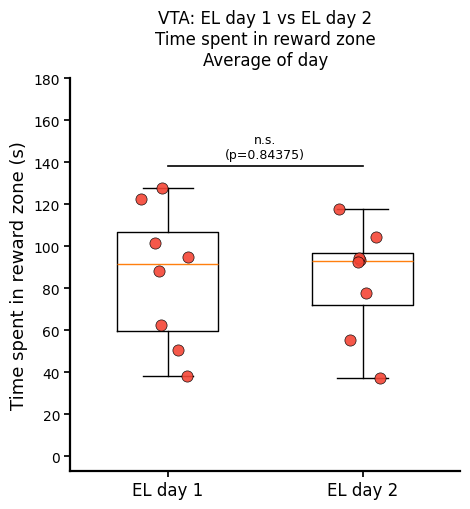


Boxplot: Average of day, EL mode = pooled
Metric: time_in_trigger_s
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AF pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=10, L day 5 mean=121.575, EL mean=85.801, L day 5 median=125.454, EL median=80.321, stat=3.000, p=0.00977


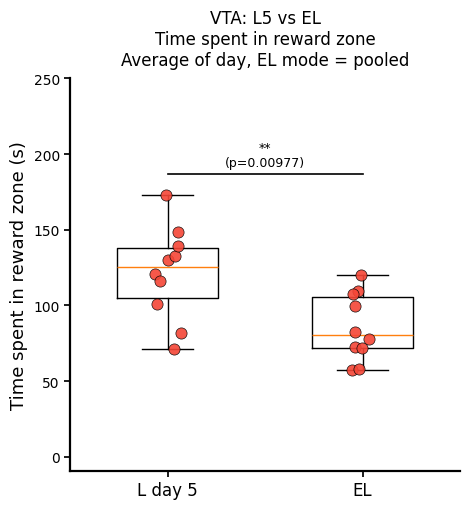


Boxplot: Best trial of day, EL mode = pooled
Metric: time_in_trigger_s
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AF pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=10, L day 5 mean=175.636, EL mean=157.008, L day 5 median=185.819, EL median=150.966, stat=17.000, p=0.32227


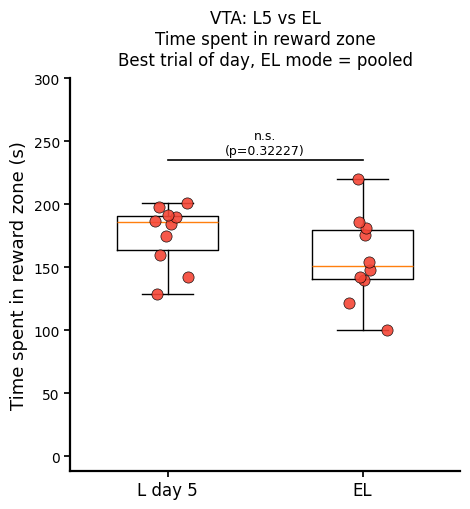


Boxplot: Final trial, trial 8, EL mode = pooled
Metric: time_in_trigger_s
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AF pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=10, L day 5 mean=142.963, EL mean=115.667, L day 5 median=148.936, EL median=117.061, stat=11.000, p=0.10547


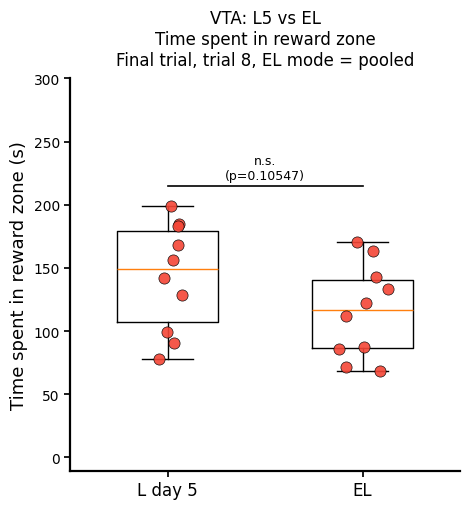


EL trial-by-trial progress plot
Metric: time_in_trigger_s
EL day mode: pooled
SEM style: shaded
  Pooled EL day 1+2: n = 10, ids = ['AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']


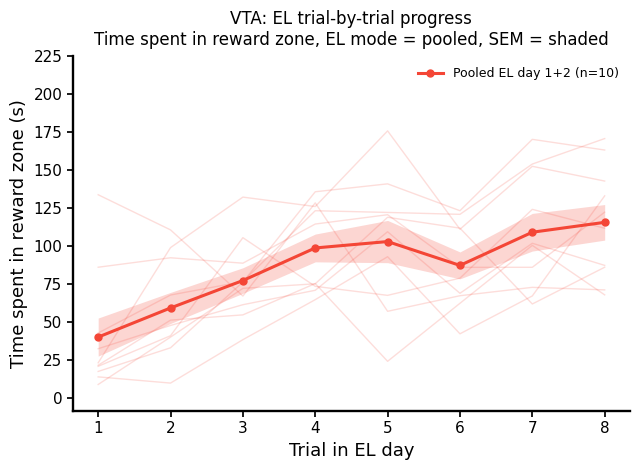



############################################################
Running EL vs L5 analysis for: time_in_near_reward_s
Label: Time spent in near-reward zone (s)
############################################################

Extra learning EL vs L5
Genotype: ChR2 (VTA)
Metric: time_in_near_reward_s
Metric label: Time spent in near-reward zone (s)
EL day mode: pooled
EL1 vs EL2 metric: avg
Stat test: wilcoxon
EL progress SEM style: shaded
Trial column used: trial_id
Filter short duration: False

Rows after filtering:
     sub  id genotype trial_type  trial_type_day  ses  trial_in_day  \
0      1   A     ChR2          L               5    8             1   
1      1   A     ChR2          L               5    8             2   
2      1   A     ChR2          L               5    8             3   
3      1   A     ChR2          L               5    8             4   
4      1   A     ChR2          L               5    8             5   
..   ...  ..      ...        ...             ...  ...    

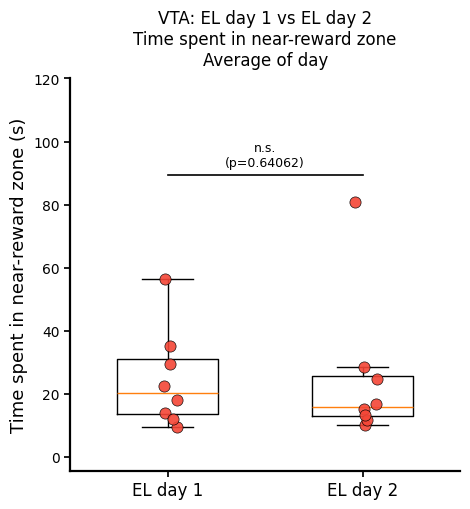


Boxplot: Average of day, EL mode = pooled
Metric: time_in_near_reward_s
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AF pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=10, L day 5 mean=17.471, EL mean=23.745, L day 5 median=15.593, EL median=16.431, stat=10.000, p=0.08398


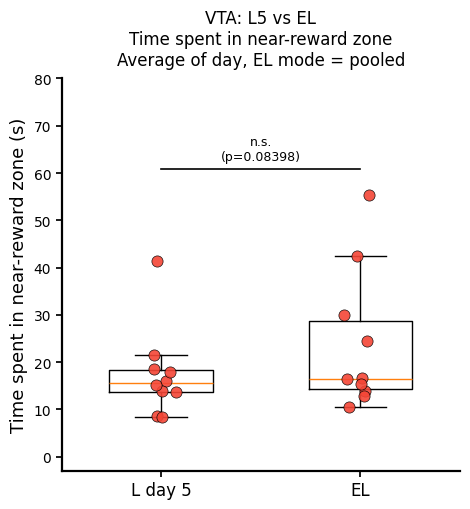


Boxplot: Best trial of day, EL mode = pooled
Metric: time_in_near_reward_s
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AF pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=10, L day 5 mean=43.755, EL mean=57.214, L day 5 median=31.491, EL median=39.472, stat=7.000, p=0.03711


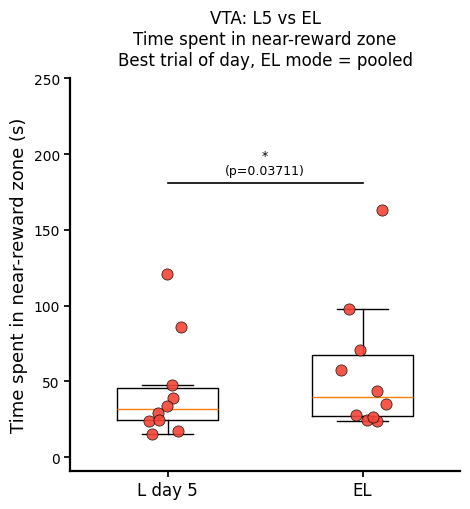


Boxplot: Final trial, trial 8, EL mode = pooled
Metric: time_in_near_reward_s
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AF pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=10, L day 5 mean=28.001, EL mean=26.100, L day 5 median=16.574, EL median=20.473, stat=27.000, p=1.00000


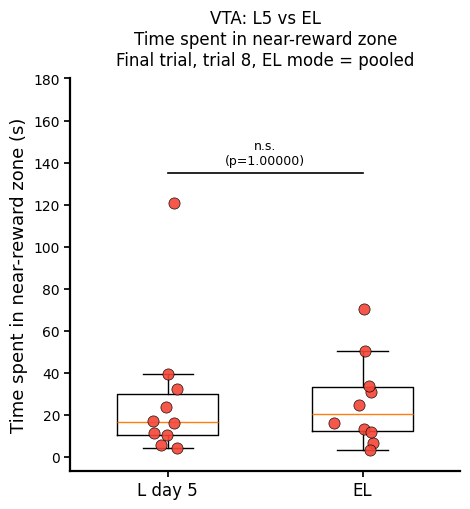


EL trial-by-trial progress plot
Metric: time_in_near_reward_s
EL day mode: pooled
SEM style: shaded
  Pooled EL day 1+2: n = 10, ids = ['AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']


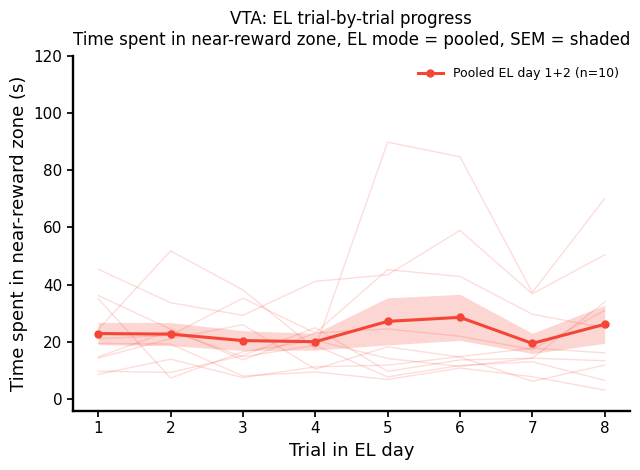



############################################################
Running EL vs L5 analysis for: time_in_edge_s
Label: Time spent in edge zone (s)
############################################################

Extra learning EL vs L5
Genotype: ChR2 (VTA)
Metric: time_in_edge_s
Metric label: Time spent in edge zone (s)
EL day mode: pooled
EL1 vs EL2 metric: avg
Stat test: wilcoxon
EL progress SEM style: shaded
Trial column used: trial_id
Filter short duration: False

Rows after filtering:
     sub  id genotype trial_type  trial_type_day  ses  trial_in_day  \
0      1   A     ChR2          L               5    8             1   
1      1   A     ChR2          L               5    8             2   
2      1   A     ChR2          L               5    8             3   
3      1   A     ChR2          L               5    8             4   
4      1   A     ChR2          L               5    8             5   
..   ...  ..      ...        ...             ...  ...           ...   
242   18  AO  

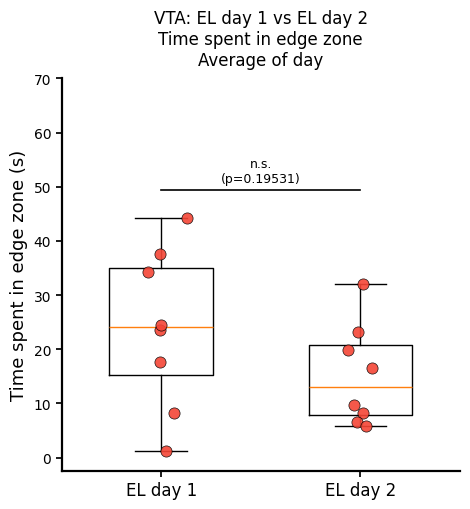


Boxplot: Average of day, EL mode = pooled
Metric: time_in_edge_s
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AF pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=10, L day 5 mean=17.714, EL mean=18.301, L day 5 median=18.889, EL median=18.168, stat=22.000, p=0.62500


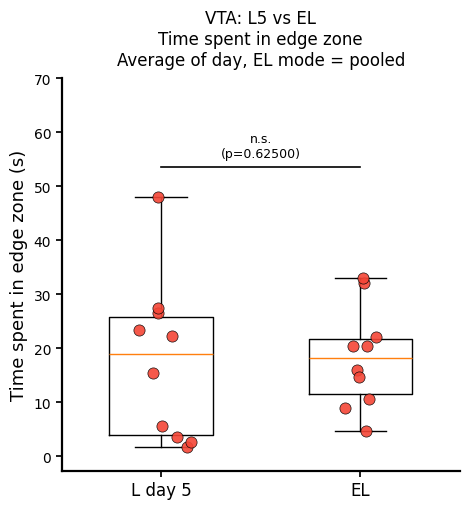


Boxplot: Best trial of day, EL mode = pooled
Metric: time_in_edge_s
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AF pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=10, L day 5 mean=49.625, EL mean=62.306, L day 5 median=57.722, EL median=61.752, stat=12.000, p=0.13086


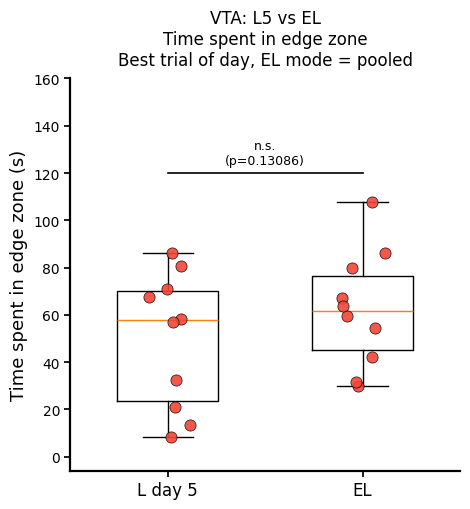


Boxplot: Final trial, trial 8, EL mode = pooled
Metric: time_in_edge_s
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AF pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=10, L day 5 mean=7.696, EL mean=7.132, L day 5 median=0.000, EL median=4.207, stat=25.000, p=0.84570


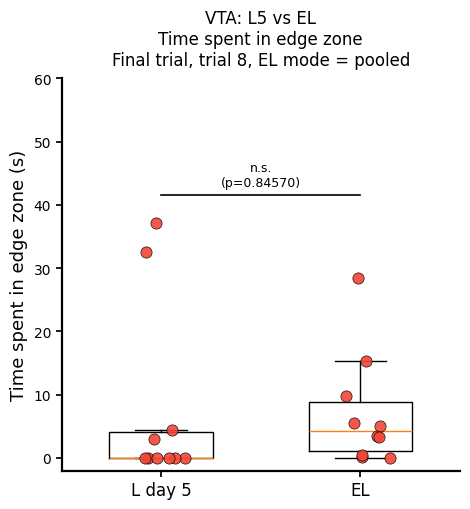


EL trial-by-trial progress plot
Metric: time_in_edge_s
EL day mode: pooled
SEM style: shaded
  Pooled EL day 1+2: n = 10, ids = ['AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']


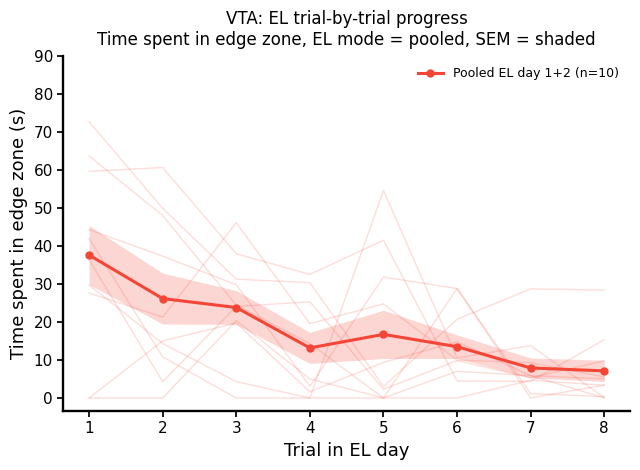

In [265]:
# ============================================================
# Extra learning EL vs last learning day L5
# Genotype: ChR2
#
# Metrics:
#   1) time_in_trigger_s
#        = time spent in reward zone
#
#   2) time_in_near_reward_s
#        = time spent in near-reward zone
#
#   3) time_in_edge_s
#        = time spent in edge zone
#
# Produces for EACH metric:
#   0) Boxplot: EL day 1 vs EL day 2
#      Default metric = average of EL day
#
#   1) Boxplot: average EL day vs average L day 5
#   2) Boxplot: best EL trial vs best L day 5 trial
#      IMPORTANT: for time-spent metrics, best = MAXIMUM time
#
#   3) Boxplot: final EL trial 8 vs final L day 5 trial 8
#
#   4) EL trial-by-trial progress plot across trials 1-8
#      This follows EL_DAY_MODE:
#         'day1'     -> EL day 1 only
#         'day2'     -> EL day 2 only
#         'separate' -> EL day 1 and EL day 2 separately
#         'pooled'   -> EL day 1 and EL day 2 pooled per animal/trial
#
# EL trial_type_day can be 1 or 2.
#
# EL_DAY_MODE:
#   'separate'
#       EL day 1 and EL day 2 are treated as separate observations.
#
#   'day1'
#       only EL trial_type_day == 1
#
#   'day2'
#       only EL trial_type_day == 2
#
#   'pooled'
#       EL day 1 and EL day 2 are averaged per animal first.
#       One EL value per animal.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, mannwhitneyu

# ============================================================
# OPTIONS
# ============================================================

GENOTYPE_TO_PLOT = 'ChR2'

EL_DAY_MODE = 'pooled'
# EL_DAY_MODE = 'day1'
# EL_DAY_MODE = 'day2'
# EL_DAY_MODE = 'separate'
# EL_DAY_MODE = 'pooled'

FILTER_SHORT_DURATION = False

EXCLUDE_ID = ['BQ', 'BP']
EXCLUDE_SUBS = []

SHOW_ANIMAL_IDS = False

# No paired lines by default
SHOW_PAIRED_LINES = False

FINAL_TRIAL_N = 8

# If True, require each paired comparison to have both values.
REQUIRE_PAIRED = True

# Stats:
#   wilcoxon is paired and best for same-animal comparisons.
#   mannwhitney is unpaired.
STAT_TEST = 'wilcoxon'
# STAT_TEST = 'mannwhitney'

# EL1 vs EL2 boxplot metric:
#   'avg'   -> average of all 8 trials
#   'best'  -> best trial = maximum time spent in zone
#   'final' -> final trial = trial 8
EL1_VS_EL2_METRIC = 'avg'
# EL1_VS_EL2_METRIC = 'best'
# EL1_VS_EL2_METRIC = 'final'

# Metrics to run
METRICS_TO_PLOT = [
    'time_in_trigger_s',
    'time_in_near_reward_s',
    'time_in_edge_s',
]

METRIC_LABEL = {
    'time_in_trigger_s': 'Time spent in reward zone (s)',
    'time_in_near_reward_s': 'Time spent in near-reward zone (s)',
    'time_in_edge_s': 'Time spent in edge zone (s)',
}

METRIC_TITLE = {
    'time_in_trigger_s': 'Time spent in reward zone',
    'time_in_near_reward_s': 'Time spent in near-reward zone',
    'time_in_edge_s': 'Time spent in edge zone',
}

# ------------------------------------------------------------
# EL trial-by-trial progress plot options
# ------------------------------------------------------------
RUN_EL_TRIAL_PROGRESS_PLOT = True
PLOT_EL_INDIVIDUAL_LINES = True

#   'bar'    -> SEM error bars
#   'shaded' -> shaded SEM area
#   'none'   -> mean line only
EL_PROGRESS_SEM_STYLE = 'shaded'
# EL_PROGRESS_SEM_STYLE = 'bar'
# EL_PROGRESS_SEM_STYLE = 'none'

EL_TRIAL_YMIN = None
EL_TRIAL_YMAX_BY_METRIC = {
    'time_in_trigger_s': None,
    'time_in_near_reward_s': None,
    'time_in_edge_s': None,
}

EL_TRIAL_Y_ZERO_PAD_FRAC = 0.04
EL_TRIAL_Y_TOP_PAD_FRAC = 0.18

# Plot styling
JITTER = 0.06
DOT_SIZE = 65
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.5
P_DECIMALS = 5

BOX_YMIN = None
BOX_YMAX_BY_METRIC = {
    'time_in_trigger_s': None,
    'time_in_near_reward_s': None,
    'time_in_edge_s': None,
}

BOX_Y_BOTTOM_PAD_FRAC = 0.04
BOX_Y_TICK_STEP = None

P_LINE_START_FRAC = 0.12
P_TEXT_OFFSET_FRAC = 0.025
P_TOP_PAD_FRAC = 0.22

np.random.seed(1)

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'CA1': 'CA1',
    'CA3': 'CA3',
    'NAc': 'NAc',
    'ArchT': 'ArchT',
    'eYFP_ArchT': 'eYFP ArchT',
    'WT': 'WT',
}

GROUP_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_PLOT, GENOTYPE_TO_PLOT)

if EL_DAY_MODE not in ['separate', 'day1', 'day2', 'pooled']:
    raise ValueError("EL_DAY_MODE must be 'separate', 'day1', 'day2', or 'pooled'")

if STAT_TEST not in ['wilcoxon', 'mannwhitney']:
    raise ValueError("STAT_TEST must be 'wilcoxon' or 'mannwhitney'")

if EL1_VS_EL2_METRIC not in ['avg', 'best', 'final']:
    raise ValueError("EL1_VS_EL2_METRIC must be 'avg', 'best', or 'final'")

if EL_PROGRESS_SEM_STYLE not in ['bar', 'shaded', 'none']:
    raise ValueError("EL_PROGRESS_SEM_STYLE must be 'bar', 'shaded', or 'none'")


# ============================================================
# Helper functions
# ============================================================

def get_plot_color(genotype):
    try:
        return get_genotype_color(genotype)
    except Exception:
        return '0.3'


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def format_p(p, decimals=P_DECIMALS):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def style_nature(ax, linewidth=1.7):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.25)
    ax.grid(False)


def apply_box_y_axis(ax, all_vals, value_col, stat_y=None):
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        y_top = 1.0
    else:
        y_top = np.nanmax(all_vals)

        if stat_y is not None and np.isfinite(stat_y):
            y_top = max(y_top, stat_y)

        if not np.isfinite(y_top) or y_top <= 0:
            y_top = 1.0

    manual_ymax = BOX_YMAX_BY_METRIC.get(value_col, None)

    if manual_ymax is not None:
        y_top = manual_ymax
    else:
        y_top = y_top * (1 + P_TOP_PAD_FRAC)

    if BOX_YMIN is not None:
        y_bottom = BOX_YMIN
    else:
        y_bottom = -BOX_Y_BOTTOM_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if BOX_Y_TICK_STEP is not None:
        ax.set_yticks(np.arange(0, y_top + BOX_Y_TICK_STEP, BOX_Y_TICK_STEP))
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]
        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)
        ax.set_yticks(yticks)


def add_trial_in_day(meta_df):
    """
    Adds trial_in_day = 1..8.

    Uses existing trial column if present.
    Otherwise infers from sub/ses order.
    """
    meta_df = meta_df.copy()

    candidate_cols = [
        'trial_in_day',
        'trial_num',
        'trial_number',
        'trial',
        'trial_idx',
        'trial_index',
        'trial_in_session',
        'trial_id_in_session',
        'trial_id',
    ]

    trial_col = next((c for c in candidate_cols if c in meta_df.columns), None)

    if trial_col is not None:
        meta_df['trial_in_day'] = meta_df[trial_col].astype(int)
    else:
        meta_df = meta_df.sort_values(['sub', 'ses']).copy()
        meta_df['trial_in_day'] = meta_df.groupby(['sub', 'ses']).cumcount() + 1

    meta_df = meta_df[meta_df['trial_in_day'].between(1, 8)].copy()

    return meta_df, trial_col


def get_animal_label(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


def trial_summary(ms, value_col):
    """
    Returns:
      average value across trials
      best value = maximum time spent in zone
      final trial value = trial_in_day == FINAL_TRIAL_N
    """
    if len(ms) == 0:
        return {
            'avg': np.nan,
            'best': np.nan,
            'final': np.nan,
        }

    by_trial = (
        ms.groupby('trial_in_day', as_index=True)[value_col]
          .mean()
          .sort_index()
    )

    by_trial = by_trial[np.isfinite(by_trial.values)]

    if len(by_trial) == 0:
        return {
            'avg': np.nan,
            'best': np.nan,
            'final': np.nan,
        }

    avg_val = float(np.nanmean(by_trial.values))

    # For time-spent metrics, "best" means maximum time spent in that zone.
    best_val = float(np.nanmax(by_trial.values))

    if FINAL_TRIAL_N in by_trial.index:
        final_val = float(by_trial.loc[FINAL_TRIAL_N])
    else:
        final_val = np.nan

    return {
        'avg': avg_val,
        'best': best_val,
        'final': final_val,
    }


def run_stat(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    ok = np.isfinite(a) & np.isfinite(b)

    if STAT_TEST == 'wilcoxon':
        a = a[ok]
        b = b[ok]

        if len(a) == 0:
            return np.nan, np.nan

        # Wilcoxon fails if all paired differences are exactly zero.
        if np.allclose(a, b, equal_nan=False):
            return np.nan, 1.0

        stat, p = wilcoxon(a, b, alternative='two-sided')
        return stat, p

    if STAT_TEST == 'mannwhitney':
        a = a[np.isfinite(a)]
        b = b[np.isfinite(b)]

        if len(a) == 0 or len(b) == 0:
            return np.nan, np.nan

        stat, p = mannwhitneyu(a, b, alternative='two-sided')
        return stat, p

    return np.nan, np.nan


def add_sig_bar(ax, positions, p, all_vals, value_col):
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        return

    ymax = np.nanmax(all_vals)
    ymin = np.nanmin(all_vals)
    yrng = ymax - ymin

    if not np.isfinite(yrng) or yrng <= 0:
        yrng = max(abs(ymax), 1.0)

    y = ymax + P_LINE_START_FRAC * yrng

    ax.plot(
        [positions[0], positions[1]],
        [y, y],
        color='black',
        linewidth=1.2
    )

    ax.text(
        np.mean(positions),
        y + P_TEXT_OFFSET_FRAC * yrng,
        f"{p_to_stars(p)}\n(p={format_p(p)})",
        ha='center',
        va='bottom',
        fontsize=9
    )

    apply_box_y_axis(ax, all_vals, value_col=value_col, stat_y=y)


def mean_sem(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return np.nan, np.nan

    if len(vals) == 1:
        return float(vals[0]), 0.0

    return float(np.nanmean(vals)), float(np.nanstd(vals, ddof=1) / np.sqrt(len(vals)))


# ============================================================
# Main plotting function for one metric
# ============================================================

def run_el_l5_plots_for_metric(VALUE_COL):
    VALUE_LABEL = METRIC_LABEL.get(VALUE_COL, VALUE_COL)
    VALUE_TITLE = METRIC_TITLE.get(VALUE_COL, VALUE_COL)

    print("\n\n############################################################")
    print(f"Running EL vs L5 analysis for: {VALUE_COL}")
    print(f"Label: {VALUE_LABEL}")
    print("############################################################")

    # ========================================================
    # 1. Filter metadata
    # ========================================================

    needed_cols = [
        'usable',
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'sub',
        VALUE_COL,
    ]

    if FILTER_SHORT_DURATION:
        needed_cols.append('short_duration')

    missing_cols = [c for c in needed_cols if c not in metadata.columns]
    if len(missing_cols) > 0:
        raise KeyError(f"Missing columns in metadata for {VALUE_COL}: {missing_cols}")

    meta = metadata[
        (metadata['usable'] == 1) &
        (metadata['genotype'] == GENOTYPE_TO_PLOT) &
        (metadata['trial_type'].isin(['L', 'EL'])) &
        (metadata[VALUE_COL].notna()) &
        (np.isfinite(metadata[VALUE_COL]))
    ].copy()

    if FILTER_SHORT_DURATION:
        meta = meta[meta['short_duration'] != 1].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in meta.columns:
        meta = meta[
            ~meta['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
        ].copy()

    if len(EXCLUDE_SUBS) > 0:
        meta = meta[
            ~meta['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
        ].copy()

    # Keep L5 and EL1/EL2 only
    meta_L5 = meta[
        (meta['trial_type'] == 'L') &
        (meta['trial_type_day'] == 5)
    ].copy()

    meta_EL = meta[
        (meta['trial_type'] == 'EL') &
        (meta['trial_type_day'].isin([1, 2]))
    ].copy()

    if EL_DAY_MODE == 'day1':
        meta_EL = meta_EL[meta_EL['trial_type_day'] == 1].copy()

    elif EL_DAY_MODE == 'day2':
        meta_EL = meta_EL[meta_EL['trial_type_day'] == 2].copy()

    meta_L5, trial_col_L5 = add_trial_in_day(meta_L5)
    meta_EL, trial_col_EL = add_trial_in_day(meta_EL)

    # Keeps all EL days for EL1-vs-EL2 and progress plot,
    # regardless of whether meta_EL was restricted by EL_DAY_MODE above.
    meta_EL_all = meta[
        (meta['trial_type'] == 'EL') &
        (meta['trial_type_day'].isin([1, 2]))
    ].copy()
    meta_EL_all, trial_col_EL_all = add_trial_in_day(meta_EL_all)

    trial_col_used = trial_col_EL if trial_col_EL is not None else trial_col_L5

    print("\n============================================================")
    print("Extra learning EL vs L5")
    print("Genotype:", GENOTYPE_TO_PLOT, f"({GROUP_LABEL})")
    print("Metric:", VALUE_COL)
    print("Metric label:", VALUE_LABEL)
    print("EL day mode:", EL_DAY_MODE)
    print("EL1 vs EL2 metric:", EL1_VS_EL2_METRIC)
    print("Stat test:", STAT_TEST)
    print("EL progress SEM style:", EL_PROGRESS_SEM_STYLE)
    print("Trial column used:", trial_col_used if trial_col_used is not None else "inferred from sub/ses order")
    print("Filter short duration:", FILTER_SHORT_DURATION)

    print("\nRows after filtering:")
    cols_to_print = ['sub']
    if 'id' in meta.columns:
        cols_to_print.append('id')
    cols_to_print += ['genotype', 'trial_type', 'trial_type_day', 'ses', 'trial_in_day', VALUE_COL]

    rows_to_print = pd.concat([meta_L5, meta_EL], ignore_index=True)

    if len(rows_to_print) > 0:
        print(
            rows_to_print[cols_to_print]
            .drop_duplicates()
            .sort_values(cols_to_print)
            .reset_index(drop=True)
        )
    else:
        print("No rows left after filtering.")

    # ========================================================
    # 2. Build paired comparison dataframe: L5 vs EL
    # ========================================================

    rows = []

    for sub in sorted(set(meta_L5['sub'].unique()).intersection(set(meta_EL['sub'].unique()))):
        ms_L5 = meta_L5[meta_L5['sub'] == sub].copy()

        if len(ms_L5) == 0:
            continue

        animal_id = get_animal_label(ms_L5, sub)
        l5_summary = trial_summary(ms_L5, VALUE_COL)

        ms_EL_sub = meta_EL[meta_EL['sub'] == sub].copy()

        if EL_DAY_MODE in ['separate', 'day1', 'day2']:
            for el_day in sorted(ms_EL_sub['trial_type_day'].dropna().unique()):
                ms_EL_day = ms_EL_sub[ms_EL_sub['trial_type_day'] == el_day].copy()

                if len(ms_EL_day) == 0:
                    continue

                el_summary = trial_summary(ms_EL_day, VALUE_COL)

                rows.append({
                    'sub': sub,
                    'id': animal_id,
                    'el_day': int(el_day),
                    'obs_label': f'{animal_id} EL{int(el_day)}',
                    'L5_avg': l5_summary['avg'],
                    'EL_avg': el_summary['avg'],
                    'L5_best': l5_summary['best'],
                    'EL_best': el_summary['best'],
                    'L5_final': l5_summary['final'],
                    'EL_final': el_summary['final'],
                })

        elif EL_DAY_MODE == 'pooled':
            el_day_summaries = []

            for el_day in sorted(ms_EL_sub['trial_type_day'].dropna().unique()):
                ms_EL_day = ms_EL_sub[ms_EL_sub['trial_type_day'] == el_day].copy()
                el_summary = trial_summary(ms_EL_day, VALUE_COL)
                el_day_summaries.append(el_summary)

            if len(el_day_summaries) == 0:
                continue

            el_summary_pooled = {
                'avg': np.nanmean([d['avg'] for d in el_day_summaries]),

                # For time-spent metrics, pooled best is maximum of the EL-day best values.
                'best': np.nanmax([d['best'] for d in el_day_summaries]),

                'final': np.nanmean([d['final'] for d in el_day_summaries]),
            }

            rows.append({
                'sub': sub,
                'id': animal_id,
                'el_day': 'pooled',
                'obs_label': f'{animal_id} pooled EL',
                'L5_avg': l5_summary['avg'],
                'EL_avg': el_summary_pooled['avg'],
                'L5_best': l5_summary['best'],
                'EL_best': el_summary_pooled['best'],
                'L5_final': l5_summary['final'],
                'EL_final': el_summary_pooled['final'],
            })

    compare_df = pd.DataFrame(rows)

    if REQUIRE_PAIRED and len(compare_df) > 0:
        metric_pairs = [
            ('L5_avg', 'EL_avg'),
            ('L5_best', 'EL_best'),
            ('L5_final', 'EL_final'),
        ]

        keep = np.ones(len(compare_df), dtype=bool)

        for l5_col, el_col in metric_pairs:
            keep = keep & compare_df[l5_col].notna().values & compare_df[el_col].notna().values

        compare_df = compare_df[keep].copy()

    print("\nComparison table:")
    if len(compare_df) > 0:
        print(
            compare_df[
                [
                    'sub', 'id', 'el_day', 'obs_label',
                    'L5_avg', 'EL_avg',
                    'L5_best', 'EL_best',
                    'L5_final', 'EL_final',
                ]
            ].reset_index(drop=True)
        )
    else:
        print("No paired L5/EL observations available.")

    # ========================================================
    # 2b. Build paired dataframe: EL day 1 vs EL day 2
    # ========================================================

    el12_rows = []

    for sub in sorted(meta_EL_all['sub'].unique()):
        ms_sub = meta_EL_all[meta_EL_all['sub'] == sub].copy()

        ms_el1 = ms_sub[ms_sub['trial_type_day'] == 1].copy()
        ms_el2 = ms_sub[ms_sub['trial_type_day'] == 2].copy()

        if len(ms_el1) == 0 or len(ms_el2) == 0:
            continue

        animal_id = get_animal_label(ms_sub, sub)

        el1_summary = trial_summary(ms_el1, VALUE_COL)
        el2_summary = trial_summary(ms_el2, VALUE_COL)

        el12_rows.append({
            'sub': sub,
            'id': animal_id,
            'EL1_avg': el1_summary['avg'],
            'EL2_avg': el2_summary['avg'],
            'EL1_best': el1_summary['best'],
            'EL2_best': el2_summary['best'],
            'EL1_final': el1_summary['final'],
            'EL2_final': el2_summary['final'],
        })

    el12_df = pd.DataFrame(el12_rows)

    print("\nEL day 1 vs EL day 2 table:")
    if len(el12_df) > 0:
        print(
            el12_df[
                [
                    'sub', 'id',
                    'EL1_avg', 'EL2_avg',
                    'EL1_best', 'EL2_best',
                    'EL1_final', 'EL2_final',
                ]
            ].reset_index(drop=True)
        )
    else:
        print("No animals with both EL day 1 and EL day 2.")

    # ========================================================
    # 3. Boxplot helpers
    # ========================================================

    def plot_two_condition_boxplot(
        plot_df,
        left_col,
        right_col,
        left_label,
        right_label,
        title_main,
        title_suffix,
        obs_label_col='obs_label'
    ):
        if len(plot_df) == 0:
            print(f"\nSkipping {title_suffix}: no data.")
            return

        plot_df = plot_df[
            plot_df[left_col].notna() &
            plot_df[right_col].notna()
        ].copy()

        if len(plot_df) == 0:
            print(f"\nSkipping {title_suffix}: no finite paired values.")
            return

        left_vals = plot_df[left_col].values.astype(float)
        right_vals = plot_df[right_col].values.astype(float)

        vals_groups = [left_vals, right_vals]
        positions = np.arange(2)

        stat, p = run_stat(left_vals, right_vals)

        if obs_label_col in plot_df.columns:
            obs_labels = list(plot_df[obs_label_col])
        else:
            obs_labels = list(plot_df['id'])

        print("\n============================================================")
        print(f"Boxplot: {title_suffix}")
        print("Metric:", VALUE_COL)
        print("Animals/observations included:")
        print(obs_labels)

        print(
            f"{STAT_TEST}: "
            f"n={len(left_vals)}, "
            f"{left_label} mean={np.nanmean(left_vals):.3f}, "
            f"{right_label} mean={np.nanmean(right_vals):.3f}, "
            f"{left_label} median={np.nanmedian(left_vals):.3f}, "
            f"{right_label} median={np.nanmedian(right_vals):.3f}, "
            f"stat={stat:.3f}, "
            f"p={format_p(p)}"
        )

        fig, ax = plt.subplots(figsize=(4.8, 5.2))

        ax.boxplot(
            vals_groups,
            positions=positions,
            widths=0.52,
            patch_artist=False,
            showfliers=False
        )

        col = get_plot_color(GENOTYPE_TO_PLOT)

        if SHOW_PAIRED_LINES:
            for left_y, right_y in zip(left_vals, right_vals):
                ax.plot(
                    positions,
                    [left_y, right_y],
                    '-',
                    color='0.65',
                    linewidth=0.8,
                    alpha=0.55,
                    zorder=1
                )

        for i, vals in enumerate(vals_groups):
            x = np.random.normal(positions[i], JITTER, size=len(vals))

            ax.scatter(
                x,
                vals,
                s=DOT_SIZE,
                color=col,
                edgecolor=DOT_EDGE_COLOR,
                linewidth=DOT_EDGE_WIDTH,
                alpha=0.9,
                zorder=3
            )

            if SHOW_ANIMAL_IDS:
                for xi, yi, animal_id in zip(x, vals, obs_labels):
                    ax.text(
                        xi + 0.035,
                        yi,
                        str(animal_id),
                        fontsize=7,
                        color=col,
                        ha='left',
                        va='center',
                        alpha=0.9,
                        zorder=4
                    )

        all_vals = np.r_[left_vals, right_vals]
        add_sig_bar(ax, positions, p, all_vals, value_col=VALUE_COL)

        ax.set_xticks(positions)
        ax.set_xticklabels([left_label, right_label], fontsize=12)

        ax.set_ylabel(VALUE_LABEL, fontsize=13)

        ax.set_title(
            f'{title_main}\n'
            f'{title_suffix}',
            fontsize=12,
            pad=10
        )

        style_nature(ax, linewidth=1.6)

        plt.tight_layout()
        plt.show()

    def plot_l5_vs_el_boxplot(l5_col, el_col, title_suffix):
        plot_two_condition_boxplot(
            plot_df=compare_df,
            left_col=l5_col,
            right_col=el_col,
            left_label='L day 5',
            right_label='EL',
            title_main=f'{GROUP_LABEL}: L5 vs EL\n{VALUE_TITLE}',
            title_suffix=f'{title_suffix}, EL mode = {EL_DAY_MODE}',
            obs_label_col='obs_label'
        )

    def plot_el1_vs_el2_boxplot():
        metric_to_cols = {
            'avg': ('EL1_avg', 'EL2_avg', 'Average of day'),
            'best': ('EL1_best', 'EL2_best', 'Best trial of day'),
            'final': ('EL1_final', 'EL2_final', f'Final trial, trial {FINAL_TRIAL_N}'),
        }

        left_col, right_col, metric_title = metric_to_cols[EL1_VS_EL2_METRIC]

        plot_two_condition_boxplot(
            plot_df=el12_df,
            left_col=left_col,
            right_col=right_col,
            left_label='EL day 1',
            right_label='EL day 2',
            title_main=f'{GROUP_LABEL}: EL day 1 vs EL day 2\n{VALUE_TITLE}',
            title_suffix=metric_title,
            obs_label_col='id'
        )

    # ========================================================
    # 4. Produce boxplots
    # ========================================================

    plot_el1_vs_el2_boxplot()

    plot_l5_vs_el_boxplot(
        l5_col='L5_avg',
        el_col='EL_avg',
        title_suffix='Average of day'
    )

    plot_l5_vs_el_boxplot(
        l5_col='L5_best',
        el_col='EL_best',
        title_suffix='Best trial of day'
    )

    plot_l5_vs_el_boxplot(
        l5_col='L5_final',
        el_col='EL_final',
        title_suffix=f'Final trial, trial {FINAL_TRIAL_N}'
    )

    # ========================================================
    # 5. EL trial-by-trial progress plot
    # ========================================================

    def build_el_trial_matrix(meta_el, mode):
        """
        Returns a dictionary of matrices for EL trial-by-trial plotting.

        Each matrix is animal x trial_in_day, values already in seconds.

        mode:
          'day1':
              one matrix for EL day 1 only

          'day2':
              one matrix for EL day 2 only

          'separate':
              one matrix for EL day 1 and one matrix for EL day 2

          'pooled':
              one matrix where EL1/EL2 are averaged per animal per trial
        """
        trials = np.arange(1, 9)
        matrices = {}

        if len(meta_el) == 0:
            return matrices

        if mode == 'day1':
            days_to_plot = [1]
        elif mode == 'day2':
            days_to_plot = [2]
        elif mode == 'separate':
            days_to_plot = [1, 2]
        elif mode == 'pooled':
            days_to_plot = ['pooled']
        else:
            raise ValueError("mode must be 'day1', 'day2', 'separate', or 'pooled'")

        if mode in ['day1', 'day2', 'separate']:

            for el_day in days_to_plot:
                md = meta_el[meta_el['trial_type_day'] == el_day].copy()

                if len(md) == 0:
                    continue

                rows = []
                ids = []

                for sub in sorted(md['sub'].unique()):
                    ms = md[md['sub'] == sub].copy()

                    by_trial = (
                        ms.groupby('trial_in_day', as_index=True)[VALUE_COL]
                          .mean()
                          .sort_index()
                    )

                    vals = np.array(
                        [by_trial.get(t, np.nan) for t in trials],
                        dtype=float
                    )

                    if np.all(np.isnan(vals)):
                        continue

                    rows.append(vals)
                    ids.append(get_animal_label(ms, sub))

                if len(rows) > 0:
                    label = f'EL day {el_day}'
                    matrices[label] = {
                        'mat': np.vstack(rows),
                        'ids': ids,
                    }

        elif mode == 'pooled':

            rows = []
            ids = []

            for sub in sorted(meta_el['sub'].unique()):
                ms = meta_el[meta_el['sub'] == sub].copy()

                # Average EL1/EL2 per trial_in_day for each animal.
                by_trial = (
                    ms.groupby('trial_in_day', as_index=True)[VALUE_COL]
                      .mean()
                      .sort_index()
                )

                vals = np.array(
                    [by_trial.get(t, np.nan) for t in trials],
                    dtype=float
                )

                if np.all(np.isnan(vals)):
                    continue

                rows.append(vals)
                ids.append(get_animal_label(ms, sub))

            if len(rows) > 0:
                matrices['Pooled EL day 1+2'] = {
                    'mat': np.vstack(rows),
                    'ids': ids,
                }

        return matrices

    def plot_el_trial_progress():
        if not RUN_EL_TRIAL_PROGRESS_PLOT:
            return

        trials = np.arange(1, 9)

        # For the progress plot, follow EL_DAY_MODE.
        if EL_DAY_MODE in ['day1', 'day2']:
            progress_meta = meta_EL.copy()
        else:
            progress_meta = meta_EL_all.copy()

        matrices = build_el_trial_matrix(progress_meta, EL_DAY_MODE)

        print("\n============================================================")
        print("EL trial-by-trial progress plot")
        print("Metric:", VALUE_COL)
        print("EL day mode:", EL_DAY_MODE)
        print("SEM style:", EL_PROGRESS_SEM_STYLE)

        if len(matrices) == 0:
            print("No EL trial-by-trial data available.")
            return

        for label, item in matrices.items():
            print(f"  {label}: n = {item['mat'].shape[0]}, ids = {item['ids']}")

        fig, ax = plt.subplots(figsize=(6.5, 4.8))

        base_col = get_plot_color(GENOTYPE_TO_PLOT)

        # Slightly different colours for EL1/EL2 when separate.
        plot_cols = {
            'EL day 1': base_col,
            'EL day 2': '0.45',
            'Pooled EL day 1+2': base_col,
        }

        all_y = []

        for label, item in matrices.items():
            mat = item['mat']

            col = plot_cols.get(label, base_col)

            if PLOT_EL_INDIVIDUAL_LINES:
                for row in mat:
                    ax.plot(
                        trials,
                        row,
                        '-',
                        color=col,
                        alpha=0.18,
                        linewidth=1.0,
                        zorder=1
                    )

            mean_ = np.full(len(trials), np.nan)
            sem_ = np.full(len(trials), np.nan)

            for i in range(len(trials)):
                m, s = mean_sem(mat[:, i])
                mean_[i] = m
                sem_[i] = s

            all_y.extend(list(mat[np.isfinite(mat)].ravel()))

            # ------------------------------------------------
            # SEM display option
            # ------------------------------------------------
            if EL_PROGRESS_SEM_STYLE == 'shaded':
                ax.fill_between(
                    trials,
                    mean_ - sem_,
                    mean_ + sem_,
                    color=col,
                    alpha=0.22,
                    linewidth=0,
                    zorder=2
                )

            ax.plot(
                trials,
                mean_,
                'o-',
                color=col,
                linewidth=2.2,
                markersize=5,
                label=f'{label} (n={mat.shape[0]})',
                zorder=3
            )

            if EL_PROGRESS_SEM_STYLE == 'bar':
                ax.errorbar(
                    trials,
                    mean_,
                    yerr=sem_,
                    fmt='none',
                    ecolor=col,
                    alpha=0.55,
                    elinewidth=1.2,
                    capsize=3,
                    zorder=4
                )

        ax.set_xlabel('Trial in EL day', fontsize=13)
        ax.set_ylabel(VALUE_LABEL, fontsize=13)

        ax.set_xticks(trials)
        ax.set_xticklabels([str(t) for t in trials], fontsize=11)
        ax.tick_params(axis='y', labelsize=11)

        ax.set_title(
            f'{GROUP_LABEL}: EL trial-by-trial progress\n'
            f'{VALUE_TITLE}, EL mode = {EL_DAY_MODE}, SEM = {EL_PROGRESS_SEM_STYLE}',
            fontsize=12,
            pad=8
        )

        style_nature(ax, linewidth=1.7)

        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(frameon=False, fontsize=9)

        all_y = np.asarray(all_y, dtype=float)
        all_y = all_y[np.isfinite(all_y)]

        if len(all_y) > 0:
            manual_ymax = EL_TRIAL_YMAX_BY_METRIC.get(VALUE_COL, None)

            if manual_ymax is not None:
                y_top = manual_ymax
            else:
                y_top = np.nanmax(all_y)
                if not np.isfinite(y_top) or y_top <= 0:
                    y_top = 1.0
                y_top = y_top * (1 + EL_TRIAL_Y_TOP_PAD_FRAC)

            if EL_TRIAL_YMIN is not None:
                y_bottom = EL_TRIAL_YMIN
            else:
                y_bottom = -EL_TRIAL_Y_ZERO_PAD_FRAC * y_top

            ax.set_ylim(y_bottom, y_top)

            yticks = ax.get_yticks()
            yticks = yticks[yticks >= 0]
            if len(yticks) == 0 or yticks[0] != 0:
                yticks = np.insert(yticks, 0, 0)
            ax.set_yticks(yticks)

        plt.tight_layout()
        plt.show()

    plot_el_trial_progress()


# ============================================================
# Run selected metrics
# ============================================================

for metric in METRICS_TO_PLOT:
    run_el_l5_plots_for_metric(metric)

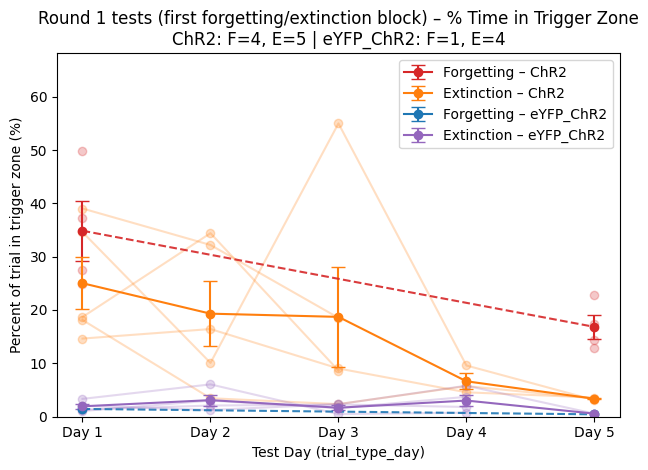

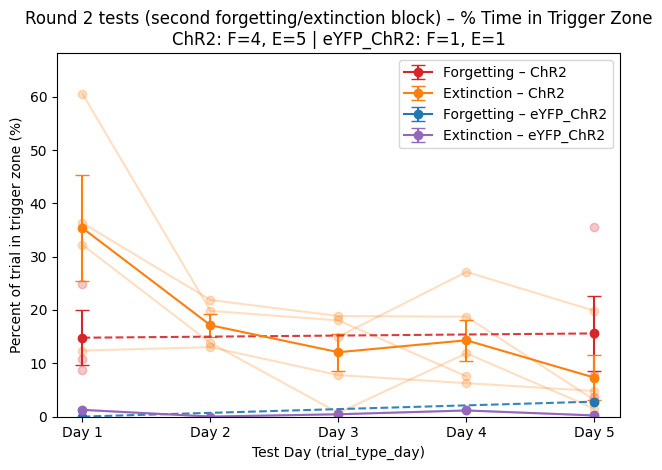

In [96]:
# plot forgetting/extinction in the order they were carried out

# 1. Filter metadata to test trials & assign test_round from test_order
# ============================================================

# Keep only test trials, the two genotypes, and non-short-duration
meta_T = metadata[
    (metadata['trial_type'] == 'T') &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['short_duration'] != 1)
].copy()

# Make sure test_order is string
meta_T['test_order'] = meta_T['test_order'].astype(str)

# Initialise test_round
meta_T['test_round'] = np.nan  # will be 1 or 2

# Rules:
# ef: extinction first, forgetting second
# fe: forgetting first, extinction second
# e:  only extinction → all extinction = round 1
# ee: two extinction rounds → split by day into first half / second half
# ff: two forgetting rounds → same as above
for sub in meta_T['sub'].unique():
    sub_mask = (meta_T['sub'] == sub)
    sub_rows = meta_T[sub_mask].sort_values('trial_type_day')

    if len(sub_rows) == 0:
        continue

    order = sub_rows['test_order'].iloc[0]

    # ef: extinction first, forgetting second
    if order == 'ef':
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'extinction'), 'test_round'] = 1
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'forgetting'), 'test_round'] = 2

    # fe: forgetting first, extinction second
    elif order == 'fe':
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'forgetting'), 'test_round'] = 1
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'extinction'), 'test_round'] = 2

    # e: only extinction → all extinction trials are round 1
    elif order == 'e':
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'extinction'), 'test_round'] = 1

    # ee: two extinction rounds → split by day into first half / second half
    elif order == 'ee':
        e_rows = sub_rows[sub_rows['test_type'] == 'extinction'].sort_values('trial_type_day')
        idx = e_rows.index.to_numpy()
        n = len(idx)
        if n > 0:
            split = int(np.ceil(n / 2))  # first ~half = round 1
            first_half = idx[:split]
            second_half = idx[split:]
            meta_T.loc[first_half, 'test_round'] = 1
            if len(second_half) > 0:
                meta_T.loc[second_half, 'test_round'] = 2

    # ff: two forgetting rounds → split by day into first half / second half
    elif order == 'ff':
        f_rows = sub_rows[sub_rows['test_type'] == 'forgetting'].sort_values('trial_type_day')
        idx = f_rows.index.to_numpy()
        n = len(idx)
        if n > 0:
            split = int(np.ceil(n / 2))
            first_half = idx[:split]
            second_half = idx[split:]
            meta_T.loc[first_half, 'test_round'] = 1
            if len(second_half) > 0:
                meta_T.loc[second_half, 'test_round'] = 2

    # else: unknown test_order → leave as NaN (ignored later)

max_day = 5
day_values = np.arange(1, max_day + 1)  # [1..5]


# ============================================================
# 2. Helper functions
# ============================================================

def build_subject_matrix(meta_group):
    """
    For a given subset (e.g. ChR2 + forgetting + round1),
    return:
      - performance_mat: (n_subjects x max_day) array with NaNs for missing days
      - subjects_used: list of subject IDs included

    Skips subjects that only have day 1 in this subset.
    """
    performance_mat = []
    subjects_used = []

    for sub in meta_group['sub'].unique():
        meta_sub = meta_group[meta_group['sub'] == sub]

        if len(meta_sub) == 0:
            continue

        # Mean % time in trigger zone per test day for this subject
        mean_pct_by_day = meta_sub.groupby('trial_type_day')['pct_time_in_trigger'].mean()
        days_present = np.array(sorted(mean_pct_by_day.index.values))

        # Exclude subjects with only day 1 in this condition
        if (len(days_present) == 1) and (days_present[0] == 1):
            continue

        subj_vec = np.full(max_day, np.nan)
        for i, day in enumerate(day_values):
            if day in mean_pct_by_day.index:
                subj_vec[i] = mean_pct_by_day.loc[day]

        if np.isnan(subj_vec).all():
            continue

        performance_mat.append(subj_vec)
        subjects_used.append(sub)

    if len(performance_mat) == 0:
        return None, []

    return np.vstack(performance_mat), subjects_used


def mean_and_sem(mat):
    """Mean ± SEM across subjects, per day, handling all-NaN columns."""
    n_days = mat.shape[1]
    mean = np.full(n_days, np.nan)
    sem = np.full(n_days, np.nan)

    for j in range(n_days):
        col = mat[:, j]
        valid = ~np.isnan(col)
        n = valid.sum()
        if n == 0:
            continue
        mean[j] = col[valid].mean()
        if n > 1:
            sem[j] = col[valid].std(ddof=1) / np.sqrt(n)
    return mean, sem


def plot_round(meta_T_full, round_num, title_prefix, y_limits=None):
    """Make a plot for test round 1 or 2."""
    meta_round = meta_T_full[meta_T_full['test_round'] == round_num].copy()
    if len(meta_round) == 0:
        print(f'No data for test_round {round_num}')
        return

    # split by genotype
    meta_ChR2 = meta_round[meta_round['genotype'] == 'ChR2']
    meta_eYFP = meta_round[meta_round['genotype'] == 'eYFP_ChR2']

    # build matrices for genotype × test_type
    perf_f_ChR2, subs_f_ChR2 = build_subject_matrix(
        meta_ChR2[meta_ChR2['test_type'] == 'forgetting'])
    perf_e_ChR2, subs_e_ChR2 = build_subject_matrix(
        meta_ChR2[meta_ChR2['test_type'] == 'extinction'])

    perf_f_YFP, subs_f_YFP = build_subject_matrix(
        meta_eYFP[meta_eYFP['test_type'] == 'forgetting'])
    perf_e_YFP, subs_e_YFP = build_subject_matrix(
        meta_eYFP[meta_eYFP['test_type'] == 'extinction'])

    # colors
    col_f_ChR2 = 'tab:red'       # soft red
    col_f_YFP = 'tab:blue'       # blue
    col_e_ChR2 = 'tab:orange'    # orange
    col_e_YFP = 'tab:purple'     # purple

    plt.figure()

    # ----- individual traces -----
    if perf_f_ChR2 is not None:
        for i in range(perf_f_ChR2.shape[0]):
            plt.plot(day_values, perf_f_ChR2[i, :],
                     '-o', color=col_f_ChR2, alpha=0.25, label='_nolegend_')

    if perf_e_ChR2 is not None:
        for i in range(perf_e_ChR2.shape[0]):
            plt.plot(day_values, perf_e_ChR2[i, :],
                     '-o', color=col_e_ChR2, alpha=0.25, label='_nolegend_')

    if perf_f_YFP is not None:
        for i in range(perf_f_YFP.shape[0]):
            plt.plot(day_values, perf_f_YFP[i, :],
                     '-o', color=col_f_YFP, alpha=0.25, label='_nolegend_')

    if perf_e_YFP is not None:
        for i in range(perf_e_YFP.shape[0]):
            plt.plot(day_values, perf_e_YFP[i, :],
                     '-o', color=col_e_YFP, alpha=0.25, label='_nolegend_')

    # ----- group means ± SEM -----
    mean_f_ChR2 = mean_f_YFP = None

    if perf_f_ChR2 is not None:
        mean_f_ChR2, sem = mean_and_sem(perf_f_ChR2)
        plt.errorbar(day_values, mean_f_ChR2, yerr=sem,
                     fmt='-o', color=col_f_ChR2, capsize=5,
                     label='Forgetting – ChR2')

    if perf_e_ChR2 is not None:
        mean, sem = mean_and_sem(perf_e_ChR2)
        plt.errorbar(day_values, mean, yerr=sem,
                     fmt='-o', color=col_e_ChR2, capsize=5,
                     label='Extinction – ChR2')

    if perf_f_YFP is not None:
        mean_f_YFP, sem = mean_and_sem(perf_f_YFP)
        plt.errorbar(day_values, mean_f_YFP, yerr=sem,
                     fmt='-o', color=col_f_YFP, capsize=5,
                     label='Forgetting – eYFP_ChR2')

    if perf_e_YFP is not None:
        mean, sem = mean_and_sem(perf_e_YFP)
        plt.errorbar(day_values, mean, yerr=sem,
                     fmt='-o', color=col_e_YFP, capsize=5,
                     label='Extinction – eYFP_ChR2')

    # dashed Day1–Day5 for forgetting group means (ChR2 & eYFP)
    if mean_f_ChR2 is not None and not np.isnan(mean_f_ChR2[0]) and not np.isnan(mean_f_ChR2[4]):
        plt.plot([1, 5], [mean_f_ChR2[0], mean_f_ChR2[4]],
                 '--', color=col_f_ChR2, alpha=0.9)

    if mean_f_YFP is not None and not np.isnan(mean_f_YFP[0]) and not np.isnan(mean_f_YFP[4]):
        plt.plot([1, 5], [mean_f_YFP[0], mean_f_YFP[4]],
                 '--', color=col_f_YFP, alpha=0.9)

    # sample sizes
    n_f_ChR2 = len(subs_f_ChR2)
    n_e_ChR2 = len(subs_e_ChR2)
    n_f_YFP = len(subs_f_YFP)
    n_e_YFP = len(subs_e_YFP)

    title_str = (
        f'{title_prefix} – % Time in Trigger Zone\n'
        f'ChR2: F={n_f_ChR2}, E={n_e_ChR2} | '
        f'eYFP_ChR2: F={n_f_YFP}, E={n_e_YFP}'
    )

    plt.title(title_str)
    plt.xlabel('Test Day (trial_type_day)')
    plt.ylabel('Percent of trial in trigger zone (%)')
    plt.xticks(day_values, [f'Day {d}' for d in day_values])
    plt.legend()

    # apply shared y-limits if provided
    if y_limits is not None:
        plt.ylim(y_limits)

    plt.tight_layout()
    plt.show()


# ============================================================
# 3. Compute shared y-axis limits across ALL test trials
# ============================================================

valid_vals = meta_T['pct_time_in_trigger'].values
valid_vals = valid_vals[~np.isnan(valid_vals)]

if len(valid_vals) > 0:
    y_min = 0
    y_max = 62
    #y_max = np.nanmax(valid_vals)
    y_limits = (y_min, y_max * 1.1)  # little headroom
else:
    y_limits = None  # fallback


# ============================================================
# 4. Make the two figures: round 1 and round 2 (shared y-axis)
# ============================================================

plot_round(
    meta_T,
    round_num=1,
    title_prefix='Round 1 tests (first forgetting/extinction block)',
    y_limits=y_limits
)

plot_round(
    meta_T,
    round_num=2,
    title_prefix='Round 2 tests (second forgetting/extinction block)',
    y_limits=y_limits
)

# time spent in each reward zone


Plotting: time_in_trigger_trig_s
Y label: Time in reward zone (s)
Groups: ['ChR2', 'ChR2_short', 'CA1', 'CA3', 'NAc']
Zones: [1, 2]

Animals included:
  VTA (ChR2), Unfavoured location:
    n animals plotted = 13
    ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  VTA (ChR2), Favoured location:
    n animals plotted = 13
    ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  VTA short (ChR2_short), Unfavoured location:
    n animals plotted = 8
    ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  VTA short (ChR2_short), Favoured location:
    n animals plotted = 8
    ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  CA1 (CA1), Unfavoured location:
    n animals plotted = 7
    ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA1 (CA1), Favoured location:
    n animals plotted = 7
    ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA3 (CA3), Unfavoured location:
    n animals plotted = 7
    ids 

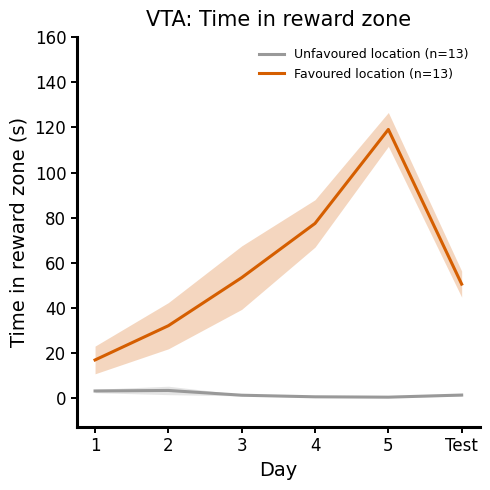

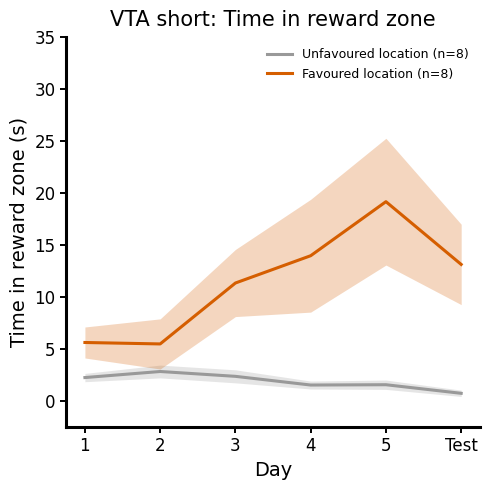

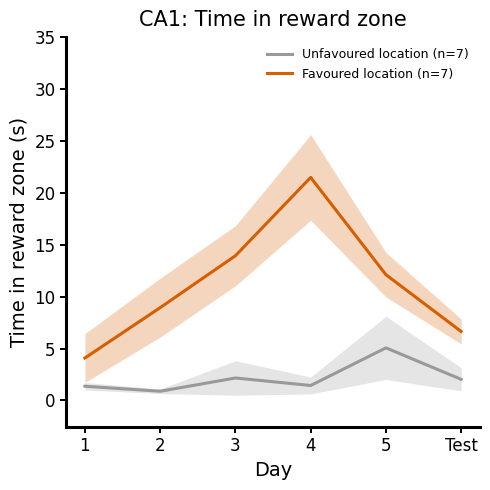

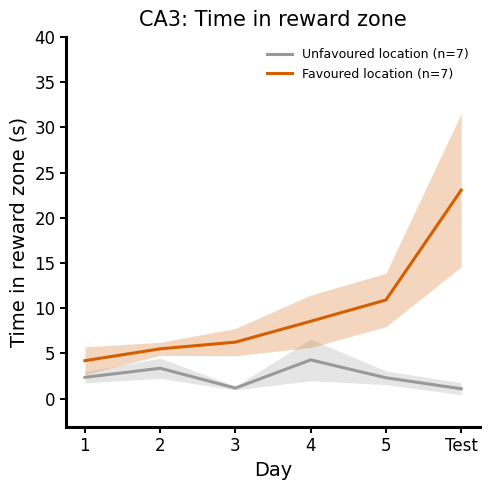

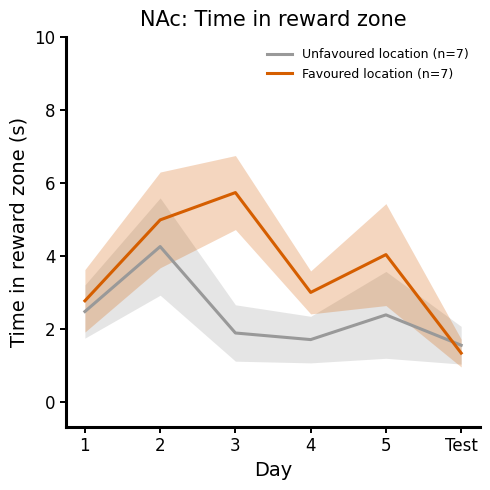

In [227]:
# ============================================================
# Time in each reward / near-reward zone across L1-L5 + Test
# Flexible groups
#
# Requires meta_pct with:
#   - trigger_id
#   - pct_in_trigger_trig
#   - time_in_trigger_trig_s
#   - pct_time_in_near_reward_trig
#   - time_in_near_reward_trig_s
#
# Favoured / unfavoured trigger_id mapping stays the same.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ============================================================
# OPTIONS
# ============================================================

GROUPS = ['ChR2', 'ChR2_short', 'CA1', 'CA3', 'NAc']

EXCLUDE_ID = [ ]
EXCLUDE_SUBS = []

REQUIRE_COMPLETE = False

ZONE_IDS = [1, 2]

ZONE_LABELS = {
    1: 'Unfavoured location',
    2: 'Favoured location'
}

ZONE_COLORS = {
    1: '#999999',
    2: '#D55E00',
}

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
}

PLOT_MODE = 'separate_figures'
# PLOT_MODE = 'same_figure'

# ------------------------------------------------------------
# Choose what to plot
# ------------------------------------------------------------
VALUE_COL = 'time_in_trigger_trig_s'
# VALUE_COL = 'pct_time_in_near_reward_trig' or 'pct_in_trigger_trig'
# VALUE_COL = 'time_in_trigger_trig_s'
# VALUE_COL = 'time_in_near_reward_trig_s'

VALUE_LABEL = {
    'pct_in_trigger_trig': 'Percent of trial in reward zone (%)',
    'pct_time_in_near_reward_trig': 'Percent of trial in near-reward zone (%)',
    'time_in_trigger_trig_s': 'Time in reward zone (s)',
    'time_in_near_reward_trig_s': 'Time in near-reward zone (s)',
}

VALUE_TITLE = {
    'pct_in_trigger_trig': 'Percent time in reward zone',
    'pct_time_in_near_reward_trig': 'Percent time in near-reward zone',
    'time_in_trigger_trig_s': 'Time in reward zone',
    'time_in_near_reward_trig_s': 'Time in near-reward zone',
}

# ------------------------------------------------------------
# Y-axis options
# ------------------------------------------------------------
YMIN = None
YMAX = 18 if 'pct' in VALUE_COL else None
Y_TICK_STEP = 5 if 'pct' in VALUE_COL else None
Y_BOTTOM_PAD_FRAC = 0.08

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

# ============================================================
# 1. Check required columns
# ============================================================

needed_cols = [
    'genotype',
    'trial_type',
    'trial_type_day',
    'ses',
    'sub',
    'trigger_id',
    VALUE_COL,
]

missing_cols = [c for c in needed_cols if c not in meta_pct.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Missing columns in meta_pct: {missing_cols}")

# ============================================================
# 2. Filter metadata
# ============================================================

mt = meta_pct[
    (meta_pct['genotype'].isin(GROUPS)) &
    (meta_pct['trial_type'].isin(['L', 'T'])) &
    (meta_pct[VALUE_COL].notna()) &
    (np.isfinite(meta_pct[VALUE_COL]))
].copy()

if len(EXCLUDE_ID) > 0 and 'id' in mt.columns:
    mt = mt[
        ~mt['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    mt = mt[
        ~mt['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ============================================================
# 3. Assign plot_day: L1-L5 + first post-learning Test = 6
# ============================================================

mt['plot_day'] = np.nan

mask_L = mt['trial_type'] == 'L'
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

mt = mt[
    (~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']

    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]

    mt.loc[idx, 'plot_day'] = 6

mt = mt[mt['plot_day'].isin(plot_days)].copy()

# ============================================================
# 4. Helpers
# ============================================================

def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.tick_params(direction='out', width=1.4, length=4)


def apply_y_axis(ax, ymax_candidates=None):
    """
    Set y-axis with:
      - optional manual YMIN / YMAX
      - automatic negative lower limit so 0 is visibly above bottom axis
      - ticks starting at 0
    """

    if YMAX is not None:
        ymax = YMAX
    else:
        if ymax_candidates is None or len(ymax_candidates) == 0:
            ymax = 10
        else:
            ymax = np.nanmax(ymax_candidates)

            if not np.isfinite(ymax) or ymax <= 0:
                ymax = 10
            else:
                ymax = ymax * 1.25

    if YMIN is not None:
        ymin = YMIN
    else:
        ymin = -Y_BOTTOM_PAD_FRAC * ymax

    ax.set_ylim(ymin, ymax)

    if Y_TICK_STEP is not None:
        tick_end = int(np.ceil(ymax))
        yticks = np.arange(0, tick_end + 1, Y_TICK_STEP)

        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)

        ax.set_yticks(yticks)
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]

        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)

        ax.set_yticks(yticks)


def build_zone_matrix(mt_all, genotype, trigger_id, value_col):
    perf_mat = []
    subjects = []
    animal_ids = []

    mt_zone = mt_all[
        (mt_all['genotype'] == genotype) &
        (mt_all['trigger_id'] == trigger_id)
    ].copy()

    for sub in mt_zone['sub'].unique():
        ms = mt_zone[mt_zone['sub'] == sub].copy()

        mean_by_day = ms.groupby('plot_day')[value_col].mean()

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_ids.append(str(ms['id'].dropna().iloc[0]))
        else:
            animal_ids.append(str(sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids

# ============================================================
# 5. Build matrices
# ============================================================

zone_data = {}

print("\n============================================================")
print("Plotting:", VALUE_COL)
print("Y label:", VALUE_LABEL.get(VALUE_COL, VALUE_COL))
print("Groups:", GROUPS)
print("Zones:", ZONE_IDS)

print("\nAnimals included:")

for g in GROUPS:
    zone_data[g] = {}

    for zid in ZONE_IDS:
        mat, subs, ids = build_zone_matrix(
            mt_all=mt,
            genotype=g,
            trigger_id=zid,
            value_col=VALUE_COL
        )

        zone_data[g][zid] = {
            'mat': mat,
            'subs': subs,
            'ids': ids,
        }

        print(f"  {DISPLAY_NAME.get(g, g)} ({g}), {ZONE_LABELS.get(zid, f'Zone {zid}')}:")
        print(f"    n animals plotted = {len(subs)}")
        print(f"    ids = {ids}")

# ============================================================
# 6A. Plot: one figure per genotype, zone 1 vs zone 2
# ============================================================

if PLOT_MODE == 'separate_figures':

    for g in GROUPS:
        fig, ax = plt.subplots(figsize=(5, 5))

        ymax_candidates = []

        for zid in ZONE_IDS:
            mat = zone_data[g][zid]['mat']
            subs = zone_data[g][zid]['subs']

            if mat is None or len(subs) == 0:
                continue

            mean_vals = np.nanmean(mat, axis=0)
            sem_vals = sem_by_day(mat)

            col = ZONE_COLORS.get(zid, get_genotype_color(g))
            label = ZONE_LABELS.get(zid, f'Reward zone {zid}')

            ax.fill_between(
                x_vals,
                mean_vals - sem_vals,
                mean_vals + sem_vals,
                color=col,
                alpha=0.25,
                linewidth=0
            )

            ax.plot(
                x_vals,
                mean_vals,
                '-',
                color=col,
                linewidth=2.2,
                label=f'{label} (n={len(subs)})'
            )

            ymax_candidates.append(np.nanmax(mean_vals + sem_vals))

        ax.set_xlabel('Day', fontsize=14)
        ax.set_ylabel(VALUE_LABEL.get(VALUE_COL, VALUE_COL), fontsize=14)

        ax.set_xticks(np.arange(6))
        ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
        ax.tick_params(axis='y', labelsize=12)

        style_nature(ax)

        ax.set_title(
            f'{DISPLAY_NAME.get(g, g)}: {VALUE_TITLE.get(VALUE_COL, VALUE_COL)}',
            fontsize=15,
            pad=8
        )

        ax.legend(frameon=False, fontsize=9)

        apply_y_axis(ax, ymax_candidates)

        plt.tight_layout()
        plt.show()

# ============================================================
# 6B. Plot: all groups/zones on same figure
# ============================================================

elif PLOT_MODE == 'same_figure':

    fig, ax = plt.subplots(figsize=(7, 5.2))

    line_styles = {
        1: '-',
        2: '--',
    }

    ymax_candidates = []

    for g in GROUPS:
        for zid in ZONE_IDS:
            mat = zone_data[g][zid]['mat']
            subs = zone_data[g][zid]['subs']

            if mat is None or len(subs) == 0:
                continue

            mean_vals = np.nanmean(mat, axis=0)
            sem_vals = sem_by_day(mat)

            col = get_genotype_color(g)
            label = (
                f'{DISPLAY_NAME.get(g, g)} '
                f'{ZONE_LABELS.get(zid, f"Zone {zid}")} '
                f'(n={len(subs)})'
            )

            ax.fill_between(
                x_vals,
                mean_vals - sem_vals,
                mean_vals + sem_vals,
                color=col,
                alpha=0.10,
                linewidth=0
            )

            ax.plot(
                x_vals,
                mean_vals,
                line_styles.get(zid, '-'),
                color=col,
                linewidth=2.1,
                label=label
            )

            ymax_candidates.append(np.nanmax(mean_vals + sem_vals))

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel(VALUE_LABEL.get(VALUE_COL, VALUE_COL), fontsize=14)

    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    style_nature(ax)

    ax.set_title(
        VALUE_TITLE.get(VALUE_COL, VALUE_COL),
        fontsize=15,
        pad=8
    )

    ax.legend(frameon=False, fontsize=8)

    apply_y_axis(ax, ymax_candidates)

    plt.tight_layout()
    plt.show()

else:
    raise ValueError("PLOT_MODE must be 'separate_figures' or 'same_figure'")


Within-day progress plot
Genotype: ChR2
Zone type: reward
Value mode: time
Using column: time_in_trigger_trig_s
Filter short duration: True
Requested YMAX: 180

Rows after filtering:
     sub  id genotype trial_type  trial_type_day  ses  trigger_id  \
0      1   A     ChR2          L               1    4           1   
1      1   A     ChR2          L               1    4           1   
2      1   A     ChR2          L               1    4           1   
3      1   A     ChR2          L               1    4           1   
4      1   A     ChR2          L               1    4           1   
..   ...  ..      ...        ...             ...  ...         ...   
809   18  AO     ChR2          L               5   33           2   
810   18  AO     ChR2          L               5   33           2   
811   18  AO     ChR2          L               5   33           2   
812   18  AO     ChR2          L               5   33           2   
813   18  AO     ChR2          L               5   33    

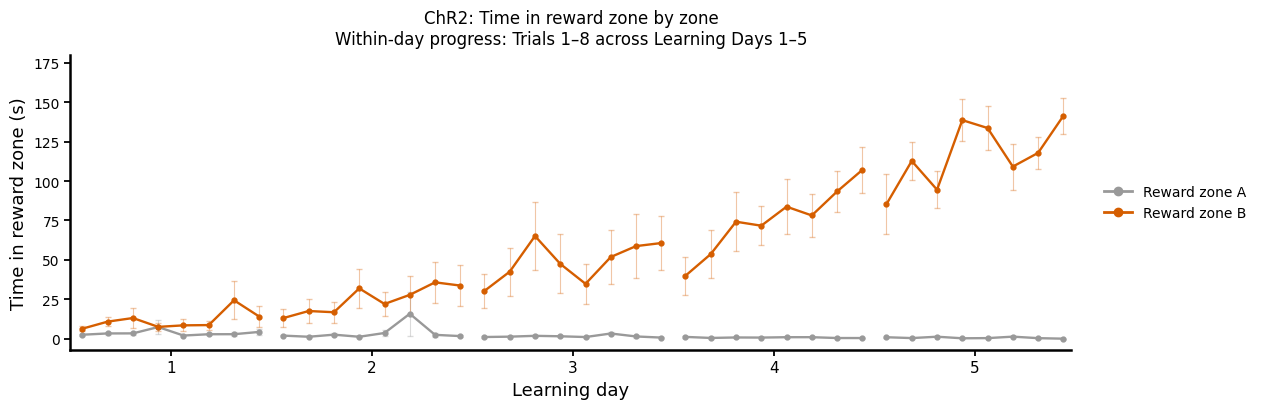

In [232]:
# ============================================================
# Within-day progress across Learning Days 1–5 (Trials 1–8)
#
# Flexible metric:
#   ZONE_TYPE = 'reward'
#       VALUE_MODE = 'pct'  -> pct_in_trigger_trig
#       VALUE_MODE = 'time' -> time_in_trigger_trig_s
#
#   ZONE_TYPE = 'near_reward'
#       VALUE_MODE = 'pct'  -> pct_in_near_reward_trig
#       VALUE_MODE = 'time' -> time_in_near_reward_trig_s
#
# Group: ChR2 only
# Separate curves for trigger_id 1 and 2
#
# Notes:
#   - excludes short_duration == 1 if FILTER_SHORT_DURATION = True
#   - allows missing trials within a day
#   - no individual background traces; mean ± SEM only
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# SETTINGS
# ============================================================

GENOTYPE_TO_PLOT = 'ChR2'

days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)
zone_ids = [1, 2]

# ------------------------------------------------------------
# Choose zone type and metric
# ------------------------------------------------------------
ZONE_TYPE = 'reward'
# ZONE_TYPE = 'near_reward'

VALUE_MODE = 'time'
# VALUE_MODE = 'pct'

# ------------------------------------------------------------
# Filtering
# ------------------------------------------------------------
FILTER_SHORT_DURATION = True

EXCLUDE_ID = []
EXCLUDE_SUBS = []

# ------------------------------------------------------------
# Plot style
# ------------------------------------------------------------
SEM_STYLE = 'bar'
# SEM_STYLE = 'shaded'
# SEM_STYLE = 'none'

colors = {
    1: '#999999',   # Zone A grey
    2: '#D55E00',   # Zone B orange
}

labels = {
    1: 'Reward zone A',
    2: 'Reward zone B',
}

near_labels = {
    1: 'Near reward zone A',
    2: 'Near reward zone B',
}

# ------------------------------------------------------------
# Y-axis options
# ------------------------------------------------------------
YMIN = None
YMAX = 180          # This will now definitely be applied.
Y_ZERO_PAD_FRAC = 0.04
Y_TOP_PAD_FRAC = 0.18
Y_TICK_STEP = None

# Example fixed axis for percent:
# YMAX = 20
# Y_TICK_STEP = 5

# Example fixed axis for time:
# YMAX = 180
# Y_TICK_STEP = 20

np.random.seed(1)

# ============================================================
# Select value column
# ============================================================

if ZONE_TYPE == 'reward':

    if VALUE_MODE == 'pct':
        VALUE_COL = 'pct_in_trigger_trig'
        VALUE_LABEL = 'Percent of trial in reward zone (%)'
        VALUE_TITLE = 'Percent time in reward zone'

    elif VALUE_MODE == 'time':
        VALUE_COL = 'time_in_trigger_trig_s'
        VALUE_LABEL = 'Time in reward zone (s)'
        VALUE_TITLE = 'Time in reward zone'

    else:
        raise ValueError("VALUE_MODE must be 'pct' or 'time'")

elif ZONE_TYPE == 'near_reward':

    if VALUE_MODE == 'pct':
        VALUE_COL = 'pct_in_near_reward_trig'
        VALUE_LABEL = 'Percent of trial in near-reward zone (%)'
        VALUE_TITLE = 'Percent time in near-reward zone'

    elif VALUE_MODE == 'time':
        VALUE_COL = 'time_in_near_reward_trig_s'
        VALUE_LABEL = 'Time in near-reward zone (s)'
        VALUE_TITLE = 'Time in near-reward zone'

    else:
        raise ValueError("VALUE_MODE must be 'pct' or 'time'")

else:
    raise ValueError("ZONE_TYPE must be 'reward' or 'near_reward'")

if ZONE_TYPE == 'near_reward':
    plot_labels = near_labels
else:
    plot_labels = labels

# ============================================================
# Check required columns
# ============================================================

needed_cols = [
    'usable',
    'genotype',
    'trial_type',
    'trial_type_day',
    'sub',
    'ses',
    'trigger_id',
    VALUE_COL,
]

if FILTER_SHORT_DURATION:
    needed_cols.append('short_duration')

missing_cols = [c for c in needed_cols if c not in meta_pct.columns]

if len(missing_cols) > 0:
    raise KeyError(
        f"Missing columns in meta_pct: {missing_cols}\n"
        f"You selected ZONE_TYPE='{ZONE_TYPE}', VALUE_MODE='{VALUE_MODE}', "
        f"so the code expects VALUE_COL='{VALUE_COL}'.\n\n"
        f"If you want VALUE_MODE='time', make sure your combined computation code "
        f"created columns like 'time_in_trigger_1_s' and also long-format "
        f"'time_in_trigger_trig_s'."
    )

# ============================================================
# 1) Filter meta_pct
# ============================================================

meta_L = meta_pct[
    (meta_pct['usable'] == 1) &
    (meta_pct['genotype'] == GENOTYPE_TO_PLOT) &
    (meta_pct['trial_type'] == 'L') &
    (meta_pct['trial_type_day'].isin(days)) &
    (meta_pct['trigger_id'].isin(zone_ids)) &
    (meta_pct[VALUE_COL].notna()) &
    (np.isfinite(meta_pct[VALUE_COL]))
].copy()

if FILTER_SHORT_DURATION:
    meta_L = meta_L[meta_L['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_L.columns:
    meta_L = meta_L[
        ~meta_L['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_L = meta_L[
        ~meta_L['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

print("\n============================================================")
print("Within-day progress plot")
print("Genotype:", GENOTYPE_TO_PLOT)
print("Zone type:", ZONE_TYPE)
print("Value mode:", VALUE_MODE)
print("Using column:", VALUE_COL)
print("Filter short duration:", FILTER_SHORT_DURATION)
print("Requested YMAX:", YMAX)

if len(meta_L) == 0:
    print("No rows left after filtering.")

else:
    cols_to_print = ['sub']

    if 'id' in meta_L.columns:
        cols_to_print.append('id')

    cols_to_print += [
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'trigger_id',
        VALUE_COL,
    ]

    print("\nRows after filtering:")
    print(
        meta_L[cols_to_print]
        .drop_duplicates()
        .sort_values(cols_to_print)
        .reset_index(drop=True)
    )

# ============================================================
# 2) Create trial_in_day = 1..8 based on UNIQUE TRIALS
#    so trigger A and B share the same trial number
# ============================================================

meta_L = meta_L.copy()

# Remove any old trial_in_day from meta_pct to avoid merge suffix problems.
if 'trial_in_day' in meta_L.columns:
    meta_L = meta_L.drop(columns=['trial_in_day'])

# Use existing trial_id if present.
# In your combined meta_pct, trial_id should usually be the original metadata index.
if 'trial_id' not in meta_L.columns:
    meta_L = meta_L.reset_index().rename(columns={'index': 'trial_id'})

trial_table = (
    meta_L[['trial_id', 'sub', 'ses', 'trial_type_day']]
    .drop_duplicates('trial_id')
    .sort_values(['sub', 'ses', 'trial_type_day', 'trial_id'])
    .copy()
)

# Assign trial number within each session.
trial_table['trial_in_day'] = trial_table.groupby(['sub', 'ses']).cumcount() + 1

# Keep only trial 1..8.
trial_table = trial_table[trial_table['trial_in_day'].between(1, 8)].copy()

meta_L = meta_L.merge(
    trial_table[['trial_id', 'trial_in_day']],
    on='trial_id',
    how='inner'
)

print("\nTrial numbering check:")
print(
    meta_L[
        ['sub', 'ses', 'trial_type_day', 'trial_id', 'trial_in_day', 'trigger_id']
    ]
    .drop_duplicates()
    .sort_values(['sub', 'ses', 'trial_in_day', 'trigger_id'])
    .head(30)
)

# ============================================================
# 3) Helper: subject × trial matrix for one day and one zone
# ============================================================

def subject_trial_matrix_for_day_and_zone(meta_g, day, zone_id, value_col):
    md = meta_g[
        (meta_g['trial_type_day'] == day) &
        (meta_g['trigger_id'] == zone_id)
    ].copy()

    if len(md) == 0:
        return None, []

    rows = []
    ids = []

    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub].copy()

        mean_by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        vals = np.array(
            [mean_by_trial.get(t, np.nan) for t in trials],
            dtype=float
        )

        if not np.all(np.isnan(vals)):
            rows.append(vals)

            if 'id' in ms.columns and ms['id'].notna().any():
                ids.append(str(ms['id'].dropna().iloc[0]))
            else:
                ids.append(str(sub))

    if len(rows) == 0:
        return None, []

    return np.vstack(rows), ids


def mean_sem_by_trial(mat):
    mean_ = np.full(mat.shape[1], np.nan)
    sem_ = np.full(mat.shape[1], np.nan)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            continue

        mean_[i] = np.nanmean(vals)

        if len(vals) > 1:
            sem_[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))
        else:
            sem_[i] = 0.0

    return mean_, sem_

# ============================================================
# 4) Plot helper: within-day curves for one zone
# ============================================================

def plot_within_day_curves_for_zone(
    ax,
    meta_g,
    zone_id,
    color,
    label,
    value_col,
    alpha=1.0
):
    offsets = np.linspace(0.06, 0.94, len(trials))
    all_vals = []
    all_ids = set()

    first_label = True

    for day in days:
        mat, ids = subject_trial_matrix_for_day_and_zone(
            meta_g,
            day,
            zone_id,
            value_col
        )

        if mat is None:
            continue

        all_ids.update(ids)

        x = day + offsets
        mean_, sem_ = mean_sem_by_trial(mat)

        finite_vals = mat[np.isfinite(mat)]

        if len(finite_vals) > 0:
            all_vals.extend(list(finite_vals))

        if SEM_STYLE == 'shaded':
            ax.fill_between(
                x,
                mean_ - sem_,
                mean_ + sem_,
                color=color,
                alpha=0.22,
                linewidth=0,
                zorder=1
            )

        ax.plot(
            x,
            mean_,
            'o-',
            color=color,
            alpha=alpha,
            linewidth=1.7,
            markersize=3.5,
            label=label if first_label else '_nolegend_',
            zorder=3
        )

        if SEM_STYLE == 'bar':
            ax.errorbar(
                x,
                mean_,
                yerr=sem_,
                fmt='none',
                ecolor=color,
                alpha=min(alpha, 0.35),
                elinewidth=0.8,
                capsize=2,
                zorder=2
            )

        elif SEM_STYLE == 'none':
            pass

        elif SEM_STYLE != 'shaded':
            raise ValueError("SEM_STYLE must be 'bar', 'shaded', or 'none'")

        first_label = False

    return all_vals, sorted(all_ids)

# ============================================================
# 5) Style helpers
# ============================================================

def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', length=4, width=1.3)
    ax.grid(False)


def apply_y_axis(ax, all_vals):
    """
    This version actually forces YMAX if YMAX is not None.

    Example:
      YMAX = 180
      Y_ZERO_PAD_FRAC = 0.04

    gives:
      ylim = (-7.2, 180)
    """
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if YMAX is not None:
        y_top = float(YMAX)
    else:
        if len(all_vals) == 0:
            y_top = 1.0
        else:
            y_top = np.nanmax(all_vals)

            if not np.isfinite(y_top) or y_top <= 0:
                y_top = 1.0

            y_top = y_top * (1 + Y_TOP_PAD_FRAC)

    if YMIN is not None:
        y_bottom = float(YMIN)
    else:
        y_bottom = -Y_ZERO_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if Y_TICK_STEP is not None:
        yticks = np.arange(0, y_top + Y_TICK_STEP, Y_TICK_STEP)
        ax.set_yticks(yticks)
    else:
        # Let matplotlib choose ticks from the forced limits,
        # then hide negative tick labels by only keeping ticks >= 0.
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]

        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0)

        ax.set_yticks(yticks)

    print("\nY-axis applied:")
    print("  YMIN setting:", YMIN)
    print("  YMAX setting:", YMAX)
    print("  Final ylim:", ax.get_ylim())

# ============================================================
# 6) Plot
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

all_y_vals = []
subs_zone = {}

for zid in zone_ids:
    vals_z, ids_z = plot_within_day_curves_for_zone(
        ax=ax,
        meta_g=meta_L,
        zone_id=zid,
        color=colors[zid],
        label=plot_labels.get(zid, f'Zone {zid}'),
        value_col=VALUE_COL,
        alpha=1.0
    )

    all_y_vals.extend(vals_z)

    subs_zone[zid] = sorted(
        meta_L.loc[meta_L['trigger_id'] == zid, 'sub'].unique()
    )

ax.set_xlabel('Learning day', fontsize=13)
ax.set_ylabel(VALUE_LABEL, fontsize=13)

ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days], fontsize=11)

ax.set_xlim(1.0, 5.98)

ax.set_title(
    f'{GENOTYPE_TO_PLOT}: {VALUE_TITLE} by zone\n'
    f'Within-day progress: Trials 1–8 across Learning Days 1–5',
    fontsize=12,
    pad=8
)

style_nature(ax)

# IMPORTANT: apply y-axis after plotting everything.
apply_y_axis(ax, all_y_vals)

legend_handles = [
    Line2D(
        [0],
        [0],
        color=colors[zid],
        lw=2,
        marker='o',
        label=plot_labels.get(zid, f'Zone {zid}')
    )
    for zid in zone_ids
]

ax.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# ============================================================
# 7) Animal counts
# ============================================================

print("\nAnimals included per zone:")
for zid in zone_ids:
    print(f"  {plot_labels.get(zid, f'Zone {zid}')}: {len(subs_zone[zid])} animals")

all_animals = sorted(set().union(*[set(v) for v in subs_zone.values()])) if len(subs_zone) > 0 else []

print(f"\nTotal unique animals included, any zone: {len(all_animals)}")
print("Animal subs:", all_animals)

if 'id' in meta_L.columns and len(meta_L) > 0:
    ids_all = sorted(meta_L['id'].dropna().astype(str).unique())
    print("Animal IDs:", ids_all)

plt.tight_layout(rect=[0, 0, 0.85, 1])

# Safety force: this prevents any later autoscale weirdness before show.
if YMAX is not None:
    final_y_top = float(YMAX)

    if YMIN is not None:
        final_y_bottom = float(YMIN)
    else:
        final_y_bottom = -Y_ZERO_PAD_FRAC * final_y_top

    ax.set_ylim(final_y_bottom, final_y_top)

    if Y_TICK_STEP is not None:
        ax.set_yticks(np.arange(0, final_y_top + Y_TICK_STEP, Y_TICK_STEP))

plt.show()

# new learning days



############################################################
RUNNING: reward, time
Using column: time_in_trigger_trig_s
############################################################

Filtered RL/Test rows:
     sub  id genotype trial_type  trial_type_day  ses  plot_day  trial_in_day  \
0      8  AD     ChR2         RL               1   21       1.0             1   
1      8  AD     ChR2         RL               1   21       1.0             1   
2      8  AD     ChR2         RL               1   21       1.0             1   
3      8  AD     ChR2         RL               1   21       1.0             2   
4      8  AD     ChR2         RL               1   21       1.0             2   
..   ...  ..      ...        ...             ...  ...       ...           ...   
976   18  AO     ChR2         RL               5   47       5.0             8   
977   18  AO     ChR2         RL               5   47       5.0             8   
978   18  AO     ChR2          T               1   48       6.0 

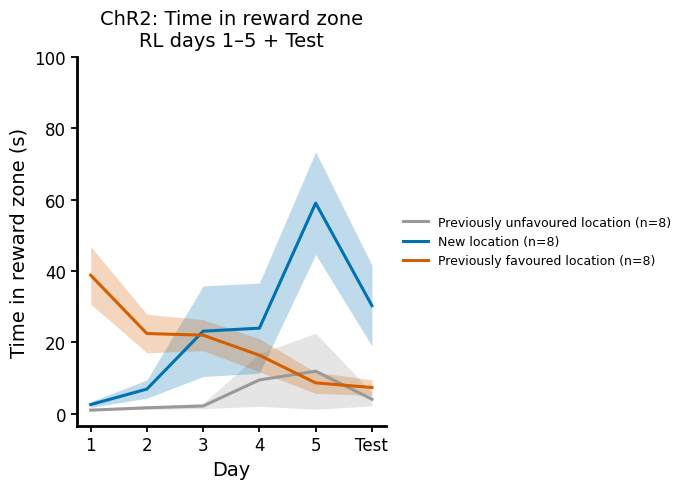


Boxplot: Time in reward zone, plot_day 1
Zone type: reward
Value mode: time
Using column: time_in_trigger_trig_s
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[0.974  0.5024 0.3252 1.8584 0.7889 1.0806 1.3529 1.032 ]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[1.2169 1.0759 1.7656 3.8485 1.5384 2.9161 0.6424 7.3775]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[38.7474 75.312  50.0305 24.4016 65.0119 16.1254 28.3265 12.7489]

Paired Wilcoxon tests, plot_day 1:
  Previously unfavoured location vs New location: paired n=8, mean=0.989 vs 2.548, median=1.003 vs 1.652, W=3.000, p=0.03906
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=0.989 vs 38.838, median=1.003 vs 33.537, W=0.000, p=0.00781
  New location vs Previously favoured location: paired n=8, mean=2.548 vs 38.838, median=1.652 vs 33.537, W=0.000, p=0.0

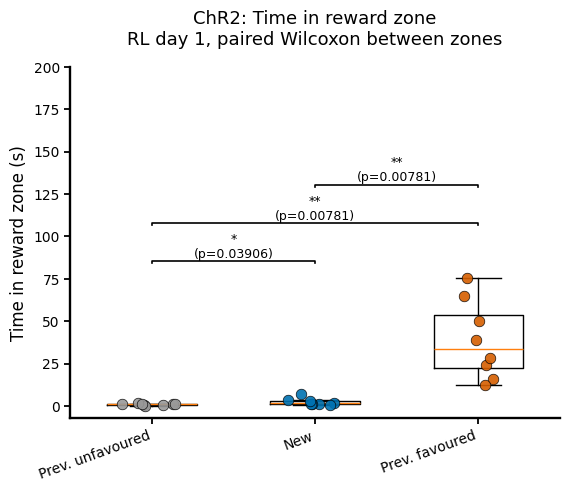


Boxplot: Time in reward zone, plot_day 2
Zone type: reward
Value mode: time
Using column: time_in_trigger_trig_s
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[1.2683 0.794  0.9669 4.5286 1.3973 2.6253 0.7996 0.8635]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 1.6695  2.7287  1.6869 12.8732  2.2185 13.6894  0.8873 19.4189]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[21.7769 41.8045 32.7154  3.0412 28.3984  7.1312 38.2941  6.6281]

Paired Wilcoxon tests, plot_day 2:
  Previously unfavoured location vs New location: paired n=8, mean=1.655 vs 6.897, median=1.118 vs 2.474, W=0.000, p=0.00781
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=1.655 vs 22.474, median=1.118 vs 25.088, W=1.000, p=0.01562
  New location vs Previously favoured location: paired n=8, mean=6.897 vs 22.474, median=2.474 vs 25.088, W=6.00

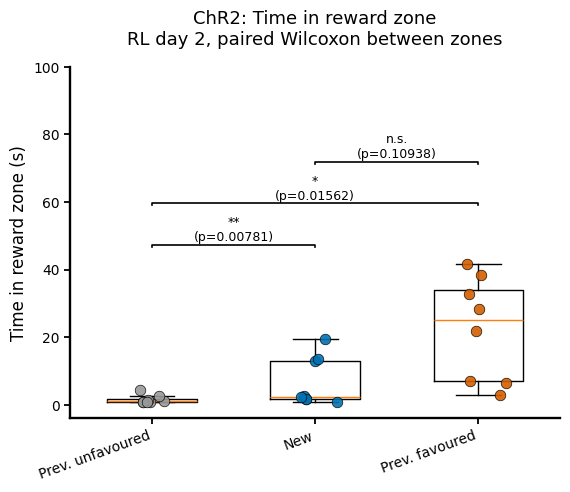


Boxplot: Time in reward zone, plot_day 3
Zone type: reward
Value mode: time
Using column: time_in_trigger_trig_s
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[0.9512 2.6004 1.2305 1.2789 2.2148 7.0613 1.2705 0.641 ]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 1.4328  1.918  23.7989 53.0016  1.8898  1.5229  1.836  99.6727]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[26.7131 35.525  27.0116 14.2459 27.0354  7.3968 35.18    2.9921]

Paired Wilcoxon tests, plot_day 3:
  Previously unfavoured location vs New location: paired n=8, mean=2.156 vs 23.134, median=1.275 vs 1.904, W=10.000, p=0.31250
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=2.156 vs 22.012, median=1.275 vs 26.862, W=0.000, p=0.00781
  New location vs Previously favoured location: paired n=8, mean=23.134 vs 22.012, median=1.904 vs 26.862, W=1

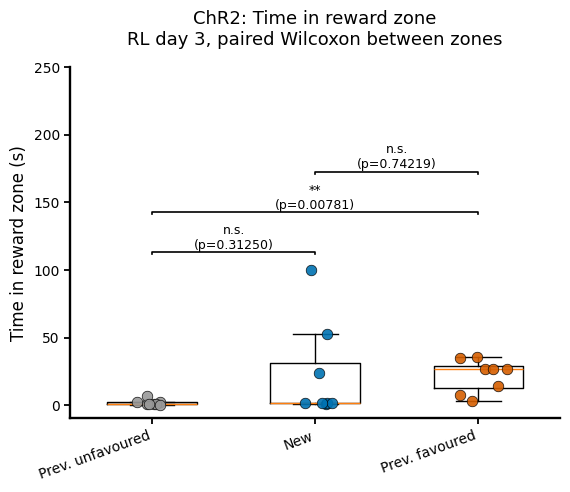


Boxplot: Time in reward zone, plot_day 4
Zone type: reward
Value mode: time
Using column: time_in_trigger_trig_s
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 0.9135  7.0715  1.1421  1.3592  2.9075 60.9634  0.3865  0.9561]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[  0.4152   1.7459  19.1989 105.7542   9.0142   2.081   11.1529  42.5011]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[21.135  39.2006 24.47    3.5824  7.2959  6.6935 25.7342  2.9819]

Paired Wilcoxon tests, plot_day 4:
  Previously unfavoured location vs New location: paired n=8, mean=9.462 vs 23.983, median=1.251 vs 10.084, W=10.000, p=0.31250
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=9.462 vs 16.387, median=1.251 vs 14.215, W=8.000, p=0.19531
  New location vs Previously favoured location: paired n=8, mean=23.983 vs 16.387, median=10.

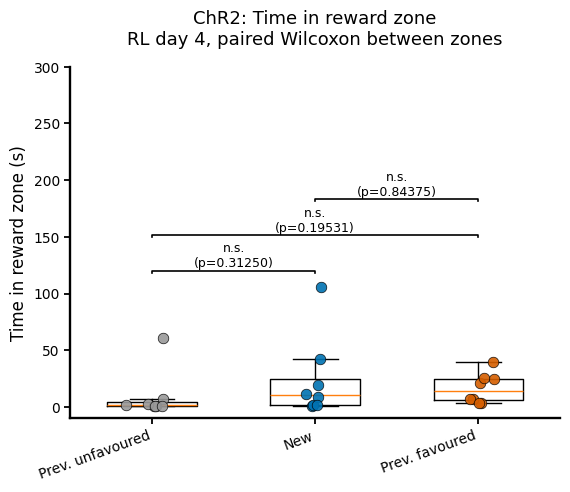


Boxplot: Time in reward zone, plot_day 5
Zone type: reward
Value mode: time
Using column: time_in_trigger_trig_s
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 0.9129  1.5078  0.2424  0.9774  2.508  86.5645  0.6555  1.9226]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 24.3455  55.1498  67.996   84.1408  29.1394   1.2098 129.2995  81.1555]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[16.0859  8.5741 25.9305  2.3485  5.3246  3.4767  5.9388  1.43  ]

Paired Wilcoxon tests, plot_day 5:
  Previously unfavoured location vs New location: paired n=8, mean=11.911 vs 59.055, median=1.243 vs 61.573, W=7.000, p=0.14844
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=11.911 vs 8.639, median=1.243 vs 5.632, W=9.000, p=0.25000
  New location vs Previously favoured location: paired n=8, mean=59.055 vs 8.639, median=61.57

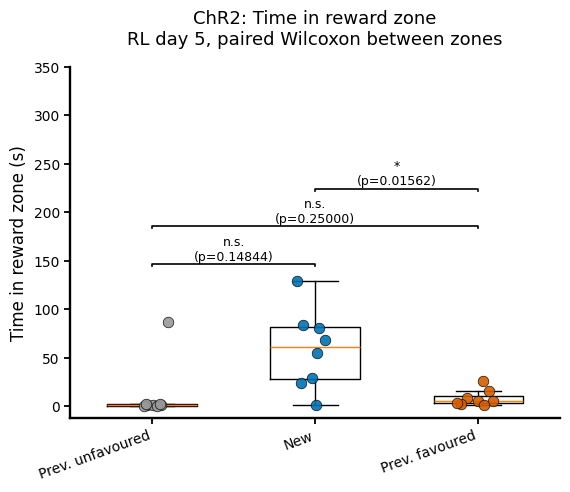


Boxplot: Time in reward zone, plot_day 6
Zone type: reward
Value mode: time
Using column: time_in_trigger_trig_s
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 0.608  0.915  1.329  5.46   2.888 16.618  2.543  2.068]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[105.282  26.347  14.203  37.354  14.979   0.596  20.042  23.605]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 4.893  3.522 21.883  5.8    5.536  5.914  8.938  2.24 ]

Paired Wilcoxon tests, plot_day 6:
  Previously unfavoured location vs New location: paired n=8, mean=4.054 vs 30.301, median=2.306 vs 21.824, W=3.000, p=0.03906
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=4.054 vs 7.341, median=2.306 vs 5.668, W=7.000, p=0.14844
  New location vs Previously favoured location: paired n=8, mean=30.301 vs 7.341, median=21.824 vs 5.668, W=3.000, p=0.0

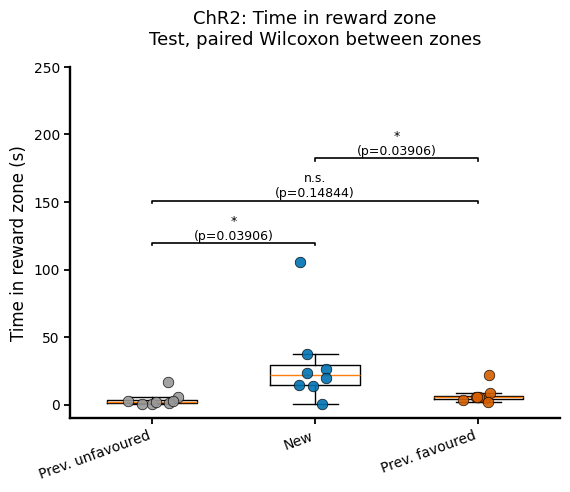


Trial-by-trial plot: Time in reward zone
Zone type: reward
Value mode: time
Using column: time_in_trigger_trig_s

Animals included per zone, trial-by-trial:
  Previously unfavoured location: 8 animals
  New location: 8 animals
  Previously favoured location: 8 animals
Total unique animals included, any zone: 8
Animal subs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(17), np.int64(18)]
Animal IDs: ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']


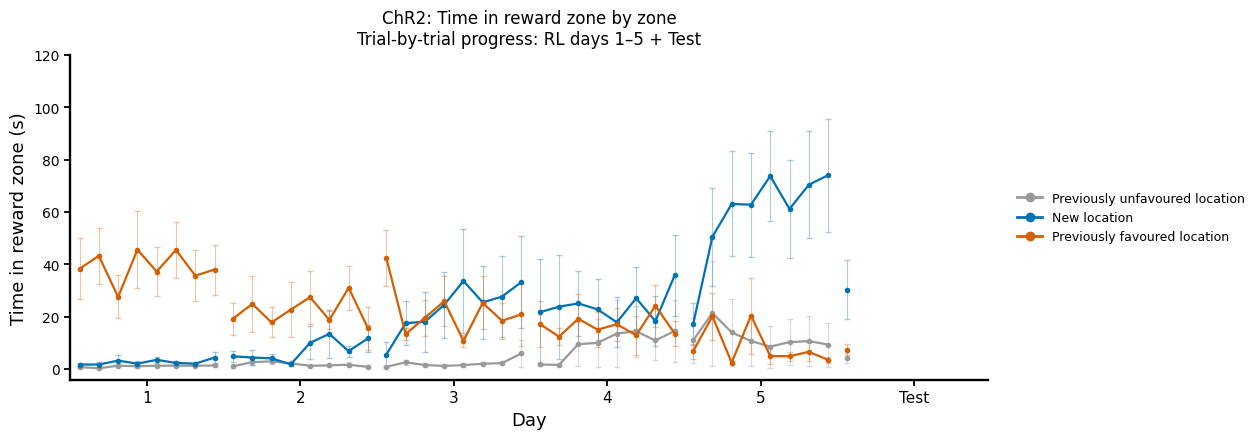


RL day 1 average vs RL day 5 average: Time in reward zone
Zone type: reward
Value mode: time
Using column: time_in_trigger_trig_s

Previously unfavoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=10.000, p=0.31250, Day1 mean=0.989, Day5 mean=11.911


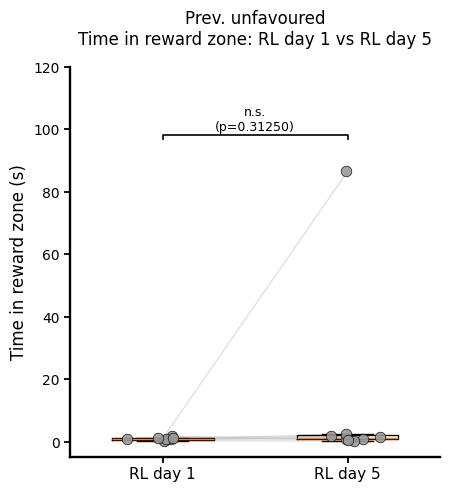


New location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=1.000, p=0.01562, Day1 mean=2.548, Day5 mean=59.055


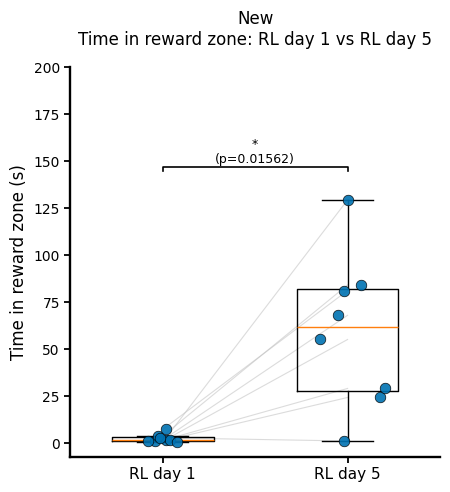


Previously favoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=0.000, p=0.00781, Day1 mean=38.838, Day5 mean=8.639


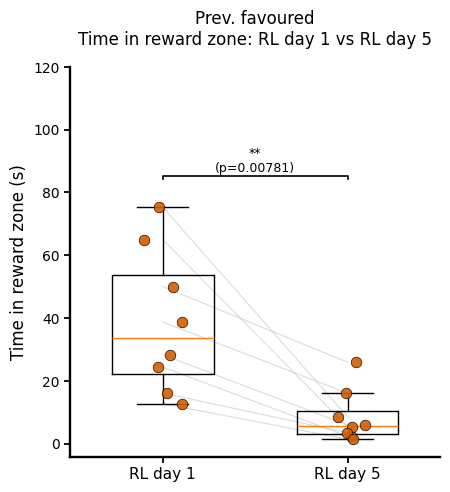


RL day 1 trial 1 vs Test-day average: Time in reward zone
Zone type: reward
Value mode: time
Using column: time_in_trigger_trig_s

Previously unfavoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=3.000, p=0.03906, Day1 trial1 mean=0.667, Test mean=4.054


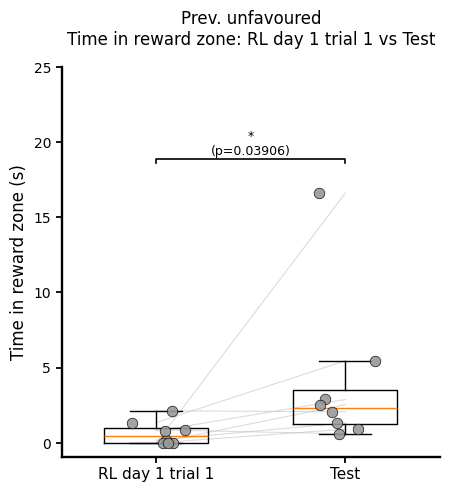


New location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=1.000, p=0.01562, Day1 trial1 mean=1.628, Test mean=30.301


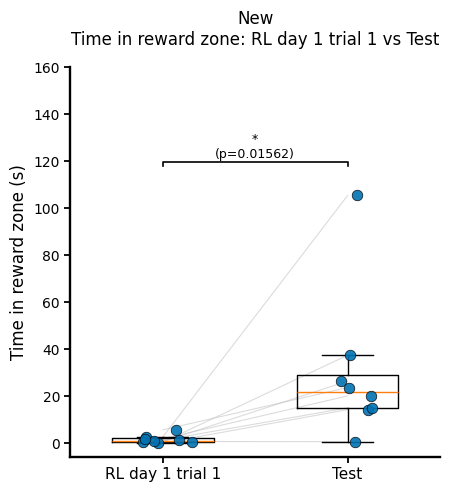


Previously favoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=5.000, p=0.07812, Day1 trial1 mean=38.236, Test mean=7.341


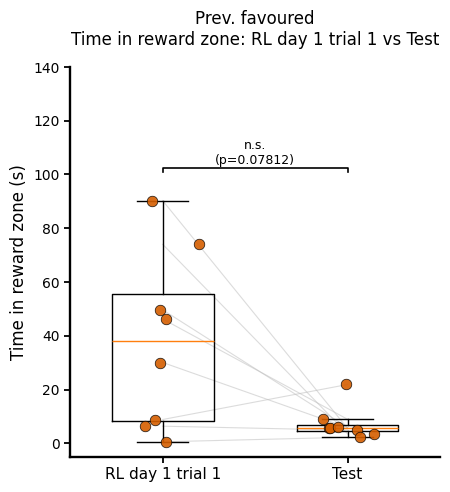



############################################################
RUNNING: near_reward, time
Using column: time_in_near_reward_trig_s
############################################################

Filtered RL/Test rows:
     sub  id genotype trial_type  trial_type_day  ses  plot_day  trial_in_day  \
0      8  AD     ChR2         RL               1   21       1.0             1   
1      8  AD     ChR2         RL               1   21       1.0             1   
2      8  AD     ChR2         RL               1   21       1.0             1   
3      8  AD     ChR2         RL               1   21       1.0             2   
4      8  AD     ChR2         RL               1   21       1.0             2   
..   ...  ..      ...        ...             ...  ...       ...           ...   
976   18  AO     ChR2         RL               5   47       5.0             8   
977   18  AO     ChR2         RL               5   47       5.0             8   
978   18  AO     ChR2          T               1   48  

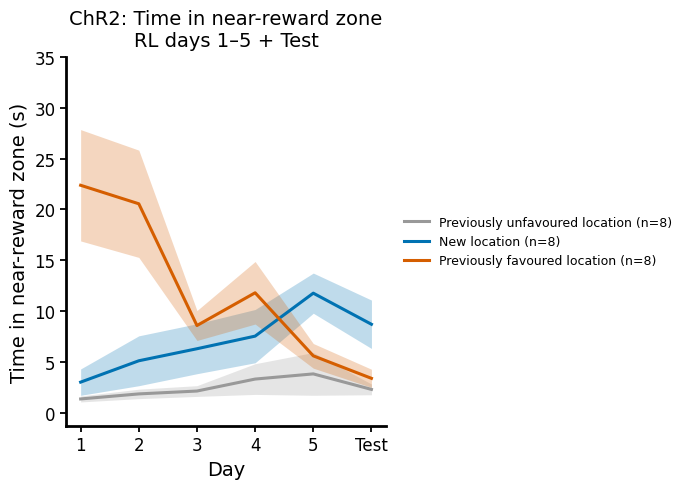


Boxplot: Time in near-reward zone, plot_day 1
Zone type: near_reward
Value mode: time
Using column: time_in_near_reward_trig_s
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[1.2171 0.4634 0.5701 3.0464 1.0432 0.9326 1.7831 1.7464]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 0.6974  1.7782  1.6371  2.0356  2.201   2.4391  1.2729 11.9856]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[21.4396 13.5552 56.3461 21.7189 25.1684  9.8961 25.2004  5.7465]

Paired Wilcoxon tests, plot_day 1:
  Previously unfavoured location vs New location: paired n=8, mean=1.350 vs 3.006, median=1.130 vs 1.907, W=6.000, p=0.10938
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=1.350 vs 22.384, median=1.130 vs 21.579, W=0.000, p=0.00781
  New location vs Previously favoured location: paired n=8, mean=3.006 vs 22.384, median=1.907 vs 

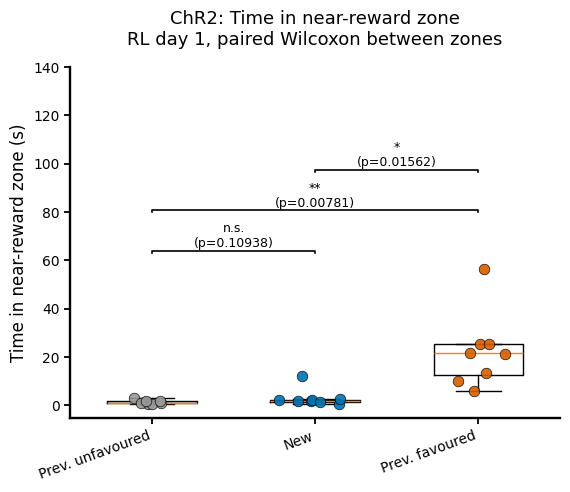


Boxplot: Time in near-reward zone, plot_day 2
Zone type: near_reward
Value mode: time
Using column: time_in_near_reward_trig_s
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[0.9205 1.5641 0.6804 4.6786 1.682  2.8269 1.1314 1.2884]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 1.1295  1.6394  2.2285  7.3201  2.9901  3.4415  0.608  21.5055]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[26.8705 11.4984 48.7206  5.0156 27.4831  8.937  28.1819  7.7921]

Paired Wilcoxon tests, plot_day 2:
  Previously unfavoured location vs New location: paired n=8, mean=1.847 vs 5.108, median=1.426 vs 2.609, W=3.000, p=0.03906
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=1.847 vs 20.562, median=1.426 vs 19.184, W=0.000, p=0.00781
  New location vs Previously favoured location: paired n=8, mean=5.108 vs 20.562, median=2.609 vs 

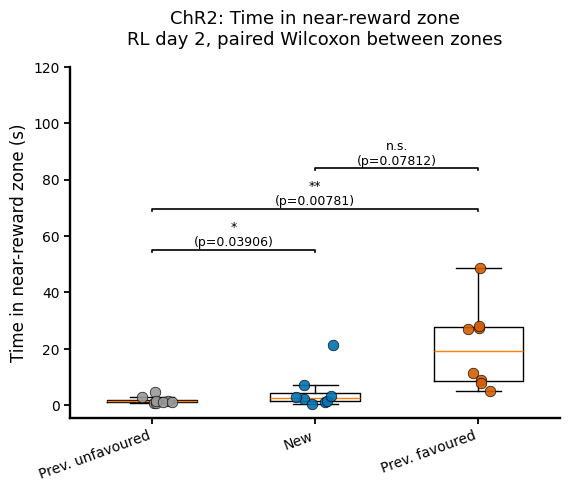


Boxplot: Time in near-reward zone, plot_day 3
Zone type: near_reward
Value mode: time
Using column: time_in_near_reward_trig_s
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[0.7099 2.1231 1.6265 1.8825 3.656  5.0035 1.3749 0.6569]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 2.1726  1.535   9.813   7.6846  3.157   2.075   2.1281 21.7786]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 8.0375 13.019  14.1369  4.4321 10.217   9.0766  8.2301  1.4815]

Paired Wilcoxon tests, plot_day 3:
  Previously unfavoured location vs New location: paired n=8, mean=2.129 vs 6.293, median=1.754 vs 2.665, W=8.000, p=0.19531
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=2.129 vs 8.579, median=1.754 vs 8.653, W=0.000, p=0.00781
  New location vs Previously favoured location: paired n=8, mean=6.293 vs 8.579, median=2.665 vs 8.6

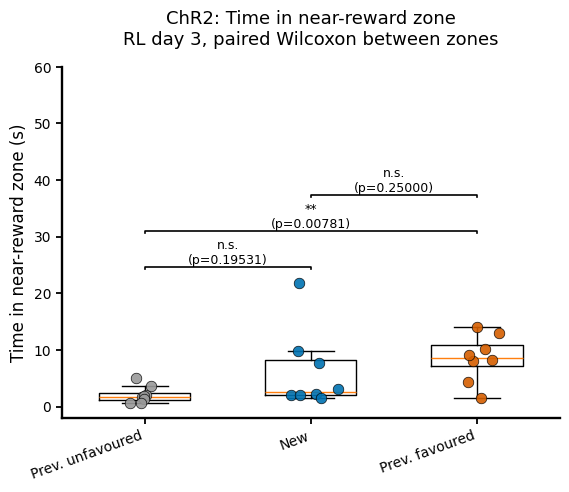


Boxplot: Time in near-reward zone, plot_day 4
Zone type: near_reward
Value mode: time
Using column: time_in_near_reward_trig_s
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 1.3211  2.5904  0.2501  1.8412  3.7525 13.5764  1.795   1.3325]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 0.6238  1.1648 18.4472  8.0224  5.6834  1.8502  5.2611 19.2186]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[14.1955  9.4495 28.4604  2.3392 10.842   5.9819 19.2283  3.9126]

Paired Wilcoxon tests, plot_day 4:
  Previously unfavoured location vs New location: paired n=8, mean=3.307 vs 7.534, median=1.818 vs 5.472, W=9.000, p=0.25000
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=3.307 vs 11.801, median=1.818 vs 10.146, W=5.000, p=0.07812
  New location vs Previously favoured location: paired n=8, mean=7.534 vs 11.801, median=5

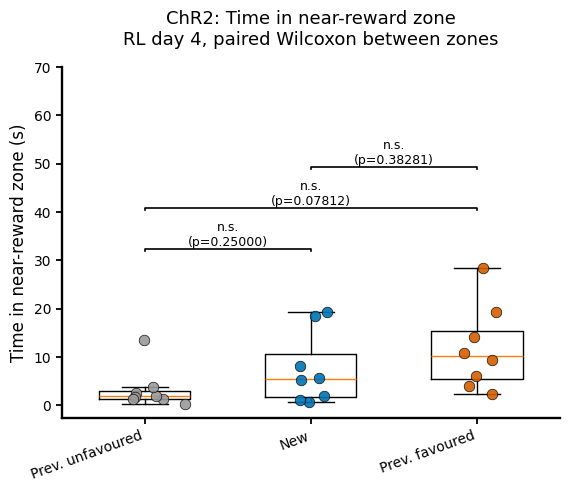


Boxplot: Time in near-reward zone, plot_day 5
Zone type: near_reward
Value mode: time
Using column: time_in_near_reward_trig_s
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 0.7641  2.508   1.1002  1.283   3.8908 18.3261  0.8811  1.7809]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 9.4858 13.6122 13.3179 14.8554  8.3776  1.3605 12.4985 20.6006]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[11.6641  9.3029  5.312   1.9861  5.4071  4.0084  5.4876  1.5805]

Paired Wilcoxon tests, plot_day 5:
  Previously unfavoured location vs New location: paired n=8, mean=3.817 vs 11.764, median=1.532 vs 12.908, W=7.000, p=0.14844
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=3.817 vs 5.594, median=1.532 vs 5.360, W=9.000, p=0.25000
  New location vs Previously favoured location: paired n=8, mean=11.764 vs 5.594, median=1

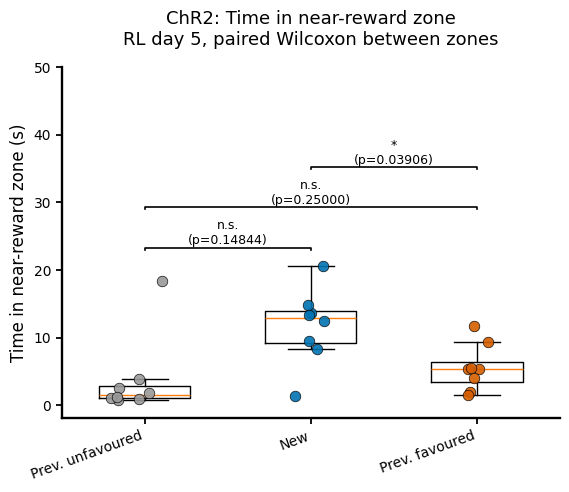


Boxplot: Time in near-reward zone, plot_day 6
Zone type: near_reward
Value mode: time
Using column: time_in_near_reward_trig_s
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[0.634 1.357 2.331 0.874 3.207 4.294 4.334 1.29 ]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 1.782  4.293 10.047  6.342 14.104  1.107 10.946 20.995]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[1.51  4.134 0.465 4.383 1.706 8.074 5.177 1.59 ]

Paired Wilcoxon tests, plot_day 6:
  Previously unfavoured location vs New location: paired n=8, mean=2.290 vs 8.702, median=1.844 vs 8.194, W=3.000, p=0.03906
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=2.290 vs 3.380, median=1.844 vs 2.920, W=9.000, p=0.25000
  New location vs Previously favoured location: paired n=8, mean=8.702 vs 3.380, median=8.194 vs 2.920, W=5.000, p=0.07812


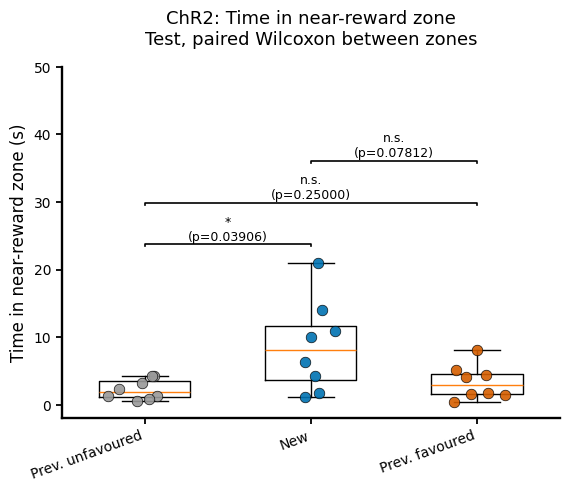


Trial-by-trial plot: Time in near-reward zone
Zone type: near_reward
Value mode: time
Using column: time_in_near_reward_trig_s

Animals included per zone, trial-by-trial:
  Previously unfavoured location: 8 animals
  New location: 8 animals
  Previously favoured location: 8 animals
Total unique animals included, any zone: 8
Animal subs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(17), np.int64(18)]
Animal IDs: ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']


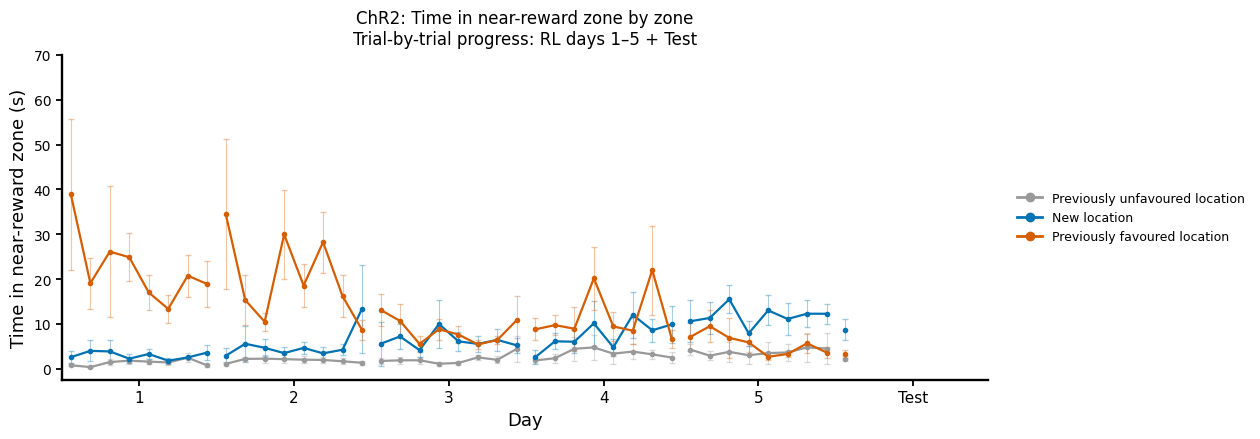


RL day 1 average vs RL day 5 average: Time in near-reward zone
Zone type: near_reward
Value mode: time
Using column: time_in_near_reward_trig_s

Previously unfavoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=11.000, p=0.38281, Day1 mean=1.350, Day5 mean=3.817


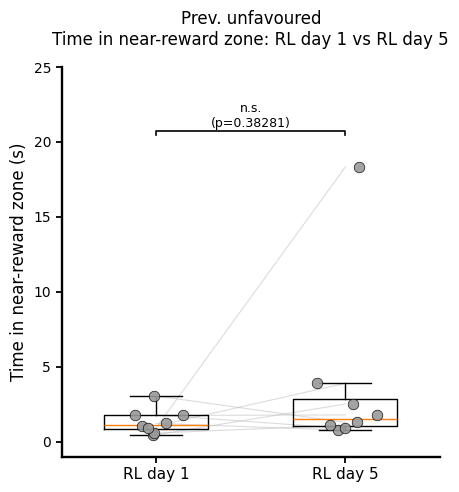


New location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=1.000, p=0.01562, Day1 mean=3.006, Day5 mean=11.764


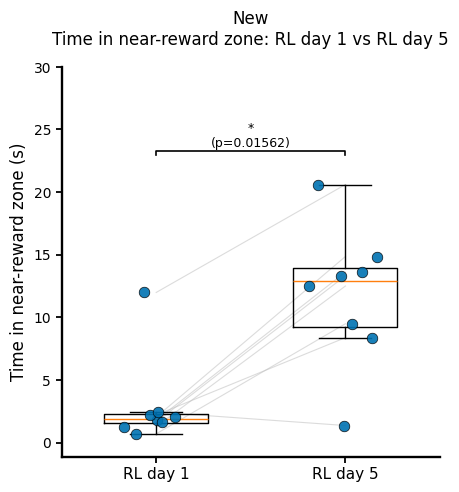


Previously favoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=0.000, p=0.00781, Day1 mean=22.384, Day5 mean=5.594


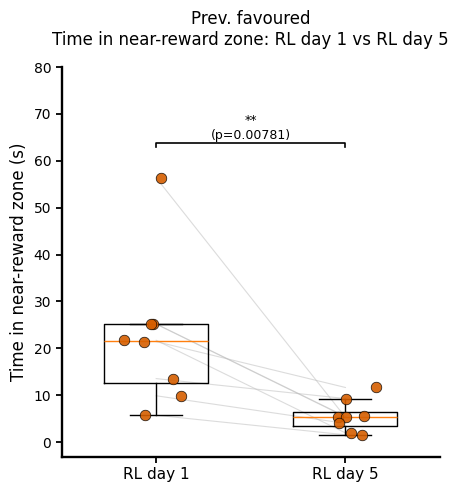


RL day 1 trial 1 vs Test-day average: Time in near-reward zone
Zone type: near_reward
Value mode: time
Using column: time_in_near_reward_trig_s

Previously unfavoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=7.000, p=0.14844, Day1 trial1 mean=0.797, Test mean=2.290


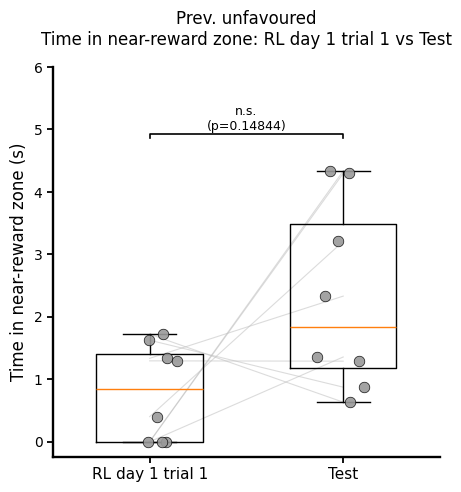


New location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=2.000, p=0.02344, Day1 trial1 mean=2.602, Test mean=8.702


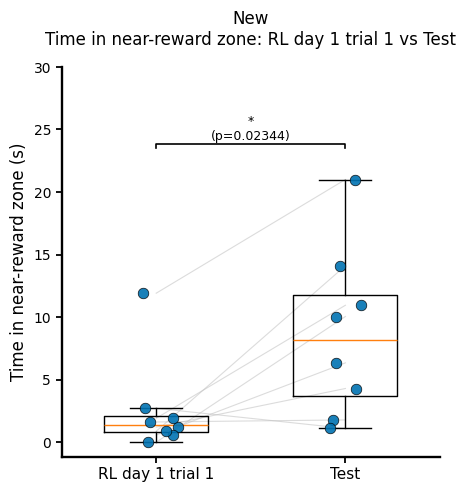


Previously favoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=0.000, p=0.00781, Day1 trial1 mean=38.882, Test mean=3.380


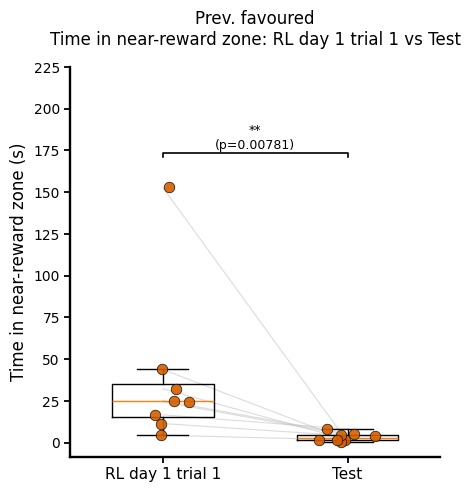

In [251]:
# ============================================================
# RL days 1–5 + first post-RL Test day 6
#
# Flexible metric:
#   ZONE_TYPE = 'reward'
#       VALUE_MODE = 'pct'  -> pct_in_trigger_trig
#       VALUE_MODE = 'time' -> time_in_trigger_trig_s
#
#   ZONE_TYPE = 'near_reward'
#       VALUE_MODE = 'pct'  -> pct_in_near_reward_trig
#       VALUE_MODE = 'time' -> time_in_near_reward_trig_s
#
# Produces, for BOTH reward and near-reward zones:
#   1) Wide line plot across RL1–RL5 + Test
#   2) Boxplots for selected days, comparing zones 1/2/3
#      - paired Wilcoxon tests only
#      - no Friedman test
#      - no multiple-comparison correction
#   3) Trial-by-trial within-day progress plot
#   4) For each zone: RL day 1 average vs RL day 5 average
#   5) For each zone: RL day 1 trial 1 vs Test-day average
#
# Requires meta_pct with long-format per-trigger columns:
#   trigger_id
#   pct_in_trigger_trig
#   time_in_trigger_trig_s
#   pct_in_near_reward_trig
#   time_in_near_reward_trig_s
#
# IMPORTANT:
#   short_duration is NOT filtered anywhere in this code.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon

# ============================================================
# OPTIONS
# ============================================================

GENOTYPE_TO_PLOT = 'ChR2'

# Choose value mode:
#   'pct'  -> percent of trial
#   'time' -> seconds
VALUE_MODE = 'time'
# VALUE_MODE = 'pct'

# Run both reward and near-reward plots
ZONE_TYPES_TO_PLOT = ['reward', 'near_reward']

# Trigger zones
ZONE_IDS = [1, 2, 3]

ZONE_LABELS = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

ZONE_SHORT_LABELS = {
    1: 'Prev. unfavoured',
    2: 'New',
    3: 'Prev. favoured',
}

ZONE_COLORS = {
    1: '#999999',  # grey
    2: '#0072B2',  # blue
    3: '#D55E00',  # orange
}

EXCLUDE_ID = []
EXCLUDE_SUBS = []

# If True, line-plot matrices require all 6 days.
# Usually False is better because animals may miss some days.
REQUIRE_COMPLETE_LINE = False

# Line plot SEM style:
#   'shaded' -> shaded SEM band
#   'bar'    -> SEM error bars
#   'none'   -> mean line only
LINE_SEM_STYLE = 'shaded'
# LINE_SEM_STYLE = 'bar'
# LINE_SEM_STYLE = 'none'

# Trial-by-trial SEM style:
#   'shaded' -> shaded SEM band
#   'bar'    -> SEM error bars
#   'none'   -> mean line only
TRIAL_SEM_STYLE = 'bar'
# TRIAL_SEM_STYLE = 'shaded'
# TRIAL_SEM_STYLE = 'none'

RUN_LINE_PLOTS = True
RUN_DAY_BOXPLOTS = True
RUN_TRIAL_BY_TRIAL_PLOTS = True
RUN_DAY1_VS_DAY5_BOXPLOTS = True
RUN_DAY1_TRIAL1_VS_TEST_BOXPLOTS = True

# Boxplots comparing zones on each selected day:
#   1 = RL day 1
#   2 = RL day 2
#   ...
#   6 = Test
BOXPLOT_DAYS = [1, 2, 3, 4, 5, 6]

# Pairwise paired Wilcoxon comparisons between zones
ZONE_COMPARISONS = [
    (1, 2),
    (1, 3),
    (2, 3),
]

SHOW_ANIMAL_IDS = False
SHOW_PAIRED_LINES_IN_BOXPLOT = False

# For the added within-zone paired plots
SHOW_PAIRED_LINES_DAY1_DAY5 = True
SHOW_PAIRED_LINES_TRIAL1_TEST = True

# Plot-day labels
plot_days = np.arange(1, 7)
plot_day_labels = ['1', '2', '3', '4', '5', 'Test']

# Trial-by-trial
trials = np.arange(1, 9)

# Figure sizes
LINE_FIGSIZE = (8.8, 5.0)
TRIAL_FIGSIZE = (15, 4.5)
BOX_FIGSIZE = (5.8, 5.4)
PAIR_BOX_FIGSIZE = (4.6, 5.4)

# ------------------------------------------------------------
# Y-axis padding
# ------------------------------------------------------------
# These are separate now, so trial plots and boxplots do not inherit
# too much padding from each other.

LINE_Y_ZERO_PAD_FRAC = 0.04
LINE_Y_TOP_PAD_FRAC = 0.18

TRIAL_Y_ZERO_PAD_FRAC = 0.04
TRIAL_Y_TOP_PAD_FRAC = 0.12

BOX_Y_ZERO_PAD_FRAC = 0.04
BOX_Y_TOP_PAD_FRAC = 0.12

# Extra p-value/stat bar space for boxplots.
# Larger value = more headroom above the p-value text.
BOX_STAT_EXTRA_TOP_FRAC = 0.10

# Optional manual y-axis maxima.
# Use None for auto.
YMAX_BY_METRIC = {
    ('reward', 'pct'): None,
    ('reward', 'time'): None,
    ('near_reward', 'pct'): None,
    ('near_reward', 'time'): None,
}

# Example:
# YMAX_BY_METRIC[('reward', 'pct')] = 20
# YMAX_BY_METRIC[('reward', 'time')] = 180

YMIN_BY_METRIC = {
    ('reward', 'pct'): None,
    ('reward', 'time'): None,
    ('near_reward', 'pct'): None,
    ('near_reward', 'time'): None,
}

Y_TICK_STEP_BY_METRIC = {
    ('reward', 'pct'): None,
    ('reward', 'time'): None,
    ('near_reward', 'pct'): None,
    ('near_reward', 'time'): None,
}

# Boxplot p-value spacing
JITTER = 0.08
DOT_SIZE = 58
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.5

P_DECIMALS = 5
P_LINE_START_FRAC = 0.12
P_LINE_STEP_FRAC = 0.30
P_TEXT_OFFSET_FRAC = 0.02

np.random.seed(1)


# ============================================================
# Column selector
# ============================================================

def get_value_info(zone_type, value_mode):
    if zone_type == 'reward':
        if value_mode == 'pct':
            return {
                'value_col': 'pct_in_trigger_trig',
                'ylabel': 'Percent of trial in reward zone (%)',
                'title': 'Percent time in reward zone',
                'short_title': 'reward zone',
            }
        elif value_mode == 'time':
            return {
                'value_col': 'time_in_trigger_trig_s',
                'ylabel': 'Time in reward zone (s)',
                'title': 'Time in reward zone',
                'short_title': 'reward zone',
            }

    elif zone_type == 'near_reward':
        if value_mode == 'pct':
            return {
                'value_col': 'pct_in_near_reward_trig',
                'ylabel': 'Percent of trial in near-reward zone (%)',
                'title': 'Percent time in near-reward zone',
                'short_title': 'near-reward zone',
            }
        elif value_mode == 'time':
            return {
                'value_col': 'time_in_near_reward_trig_s',
                'ylabel': 'Time in near-reward zone (s)',
                'title': 'Time in near-reward zone',
                'short_title': 'near-reward zone',
            }

    raise ValueError("zone_type must be 'reward' or 'near_reward'; value_mode must be 'pct' or 'time'")


# ============================================================
# General helpers
# ============================================================

def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def format_p(p, decimals=P_DECIMALS):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def style_nature(ax, linewidth=1.8):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', width=1.3, length=4)
    ax.grid(False)


def mean_sem(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return np.nan, np.nan

    if len(vals) == 1:
        return float(vals[0]), 0.0

    return float(np.nanmean(vals)), float(np.nanstd(vals, ddof=1) / np.sqrt(len(vals)))


def mean_sem_by_col(mat):
    if mat is None or mat.size == 0:
        return None, None

    mean_ = np.full(mat.shape[1], np.nan)
    sem_ = np.full(mat.shape[1], np.nan)

    for j in range(mat.shape[1]):
        m, s = mean_sem(mat[:, j])
        mean_[j] = m
        sem_[j] = s

    return mean_, sem_


def wilcoxon_safe(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    ok = np.isfinite(a) & np.isfinite(b)
    a = a[ok]
    b = b[ok]

    if len(a) == 0:
        return np.nan, np.nan

    if np.allclose(a, b, equal_nan=False):
        return np.nan, 1.0

    try:
        stat, p = wilcoxon(a, b, alternative='two-sided')
    except ValueError:
        stat, p = np.nan, 1.0

    return stat, p


def apply_y_axis(
    ax,
    all_vals,
    zone_type,
    value_mode,
    context='line',
    extra_top_y=None
):
    """
    Sets y-axis with:
      - optional manual YMIN/YMAX by metric
      - automatic range from the values actually plotted
      - separate padding for line/trial/box plots
      - 0 padded below x-axis unless manual ymin is set

    context:
      'line'  -> line plot
      'trial' -> trial-by-trial plot
      'box'   -> boxplot
    """

    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    key = (zone_type, value_mode)

    manual_ymax = YMAX_BY_METRIC.get(key, None)
    manual_ymin = YMIN_BY_METRIC.get(key, None)
    tick_step = Y_TICK_STEP_BY_METRIC.get(key, None)

    if context == 'line':
        zero_pad = LINE_Y_ZERO_PAD_FRAC
        top_pad = LINE_Y_TOP_PAD_FRAC
    elif context == 'trial':
        zero_pad = TRIAL_Y_ZERO_PAD_FRAC
        top_pad = TRIAL_Y_TOP_PAD_FRAC
    elif context == 'box':
        zero_pad = BOX_Y_ZERO_PAD_FRAC
        top_pad = BOX_Y_TOP_PAD_FRAC
    else:
        raise ValueError("context must be 'line', 'trial', or 'box'")

    if len(all_vals) == 0:
        data_top = 1.0
    else:
        data_top = np.nanmax(all_vals)
        if not np.isfinite(data_top) or data_top <= 0:
            data_top = 1.0

    if extra_top_y is not None and np.isfinite(extra_top_y):
        data_top = max(data_top, extra_top_y)

    if manual_ymax is not None:
        y_top = float(manual_ymax)
    else:
        y_top = data_top * (1 + top_pad)

    if manual_ymin is not None:
        y_bottom = float(manual_ymin)
    else:
        y_bottom = -zero_pad * y_top

    ax.set_ylim(y_bottom, y_top)

    if tick_step is not None:
        ax.set_yticks(np.arange(0, y_top + tick_step, tick_step))
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]

        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)

        ax.set_yticks(yticks)


def draw_sig_bar(ax, x1, x2, y, p, yrng):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + 0.015 * yrng, y + 0.015 * yrng, y],
        color='black',
        linewidth=1.2
    )

    ax.text(
        (x1 + x2) / 2,
        y + P_TEXT_OFFSET_FRAC * yrng,
        f"{p_to_stars(p)}\n(p={format_p(p)})",
        ha='center',
        va='bottom',
        fontsize=9
    )


def get_animal_id(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


# ============================================================
# Prepare RL + Test data
# ============================================================

def prepare_rl_test_data(meta_pct, value_col):
    needed_cols = [
        'usable',
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'sub',
        'trigger_id',
        value_col,
    ]

    missing_cols = [c for c in needed_cols if c not in meta_pct.columns]
    if len(missing_cols) > 0:
        raise KeyError(
            f"Missing columns in meta_pct: {missing_cols}\n"
            f"The selected VALUE_COL is '{value_col}'."
        )

    mt = meta_pct[
        (meta_pct['usable'] == 1) &
        (meta_pct['genotype'] == GENOTYPE_TO_PLOT) &
        (meta_pct['trial_type'].isin(['RL', 'T'])) &
        (meta_pct['trigger_id'].isin(ZONE_IDS)) &
        (meta_pct[value_col].notna()) &
        (np.isfinite(meta_pct[value_col]))
    ].copy()

    # No short_duration filtering anywhere.

    if len(EXCLUDE_ID) > 0 and 'id' in mt.columns:
        mt = mt[
            ~mt['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
        ].copy()

    if len(EXCLUDE_SUBS) > 0:
        mt = mt[
            ~mt['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
        ].copy()

    # --------------------------------------------------------
    # Assign plot_day:
    # RL -> trial_type_day 1–5
    # T  -> first T session after last RL = day 6
    # --------------------------------------------------------
    mt['plot_day'] = np.nan

    mask_RL = mt['trial_type'] == 'RL'
    mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

    mt = mt[
        (~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))
    ].copy()

    for sub in mt['sub'].unique():
        ms = mt[mt['sub'] == sub].copy()

        RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']

        if len(RL_ses) == 0:
            continue

        last_RL_ses = RL_ses.max()

        T_after = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] > last_RL_ses)
        ]

        if len(T_after) == 0:
            continue

        first_T_ses = T_after['ses'].min()

        idx = mt.index[
            (mt['sub'] == sub) &
            (mt['trial_type'] == 'T') &
            (mt['ses'] == first_T_ses)
        ]

        mt.loc[idx, 'plot_day'] = 6

    mt = mt[mt['plot_day'].isin(plot_days)].copy()

    # --------------------------------------------------------
    # Create trial_in_day = 1..8 based on unique trial_id.
    # Important because each trial has 3 trigger rows.
    # --------------------------------------------------------
    if 'trial_in_day' in mt.columns:
        mt = mt.drop(columns=['trial_in_day'])

    if 'trial_id' not in mt.columns:
        mt = mt.reset_index().rename(columns={'index': 'trial_id'})

    trial_table = (
        mt[['trial_id', 'sub', 'ses', 'plot_day']]
        .drop_duplicates('trial_id')
        .sort_values(['sub', 'ses', 'plot_day', 'trial_id'])
        .copy()
    )

    trial_table['trial_in_day'] = trial_table.groupby(['sub', 'ses']).cumcount() + 1
    trial_table = trial_table[trial_table['trial_in_day'].between(1, 8)].copy()

    mt = mt.merge(
        trial_table[['trial_id', 'trial_in_day']],
        on='trial_id',
        how='inner'
    )

    return mt


# ============================================================
# Matrix / values builders
# ============================================================

def build_zone_day_matrix(mt_all, zone_id, value_col):
    mt_zone = mt_all[mt_all['trigger_id'] == zone_id].copy()

    perf_mat = []
    subjects = []
    ids = []

    for sub in sorted(mt_zone['sub'].unique()):
        ms = mt_zone[mt_zone['sub'] == sub].copy()

        mean_by_day = (
            ms.groupby('plot_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE_LINE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)
        ids.append(get_animal_id(ms, sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, ids


def build_zone_trial_matrix(mt_all, plot_day, zone_id, value_col):
    md = mt_all[
        (mt_all['plot_day'] == plot_day) &
        (mt_all['trigger_id'] == zone_id)
    ].copy()

    if len(md) == 0:
        return None, []

    rows = []
    ids = []

    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub].copy()

        mean_by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        vals = np.array(
            [mean_by_trial.get(t, np.nan) for t in trials],
            dtype=float
        )

        if np.all(np.isnan(vals)):
            continue

        rows.append(vals)
        ids.append(get_animal_id(ms, sub))

    if len(rows) == 0:
        return None, []

    return np.vstack(rows), ids


def day_values_for_zone(mt_all, plot_day, zone_id, value_col):
    md = mt_all[
        (mt_all['plot_day'] == plot_day) &
        (mt_all['trigger_id'] == zone_id)
    ].copy()

    rows = []

    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub].copy()

        if len(ms) == 0:
            continue

        val = ms[value_col].mean()

        if not np.isfinite(val):
            continue

        rows.append({
            'sub': sub,
            'id': get_animal_id(ms, sub),
            'zone_id': zone_id,
            'plot_day': plot_day,
            'value': float(val),
        })

    return pd.DataFrame(rows)


def day_trial_value_for_zone(mt_all, plot_day, trial_in_day, zone_id, value_col):
    md = mt_all[
        (mt_all['plot_day'] == plot_day) &
        (mt_all['trial_in_day'] == trial_in_day) &
        (mt_all['trigger_id'] == zone_id)
    ].copy()

    rows = []

    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub].copy()

        if len(ms) == 0:
            continue

        val = ms[value_col].mean()

        if not np.isfinite(val):
            continue

        rows.append({
            'sub': sub,
            'id': get_animal_id(ms, sub),
            'zone_id': zone_id,
            'plot_day': plot_day,
            'trial_in_day': trial_in_day,
            'value': float(val),
        })

    return pd.DataFrame(rows)


# ============================================================
# Plot 1: line plot across RL1–RL5 + Test
# ============================================================

def plot_line_across_days(mt, zone_type, value_mode, value_col, value_label, value_title):
    if not RUN_LINE_PLOTS:
        return

    zone_data = {}

    print("\n============================================================")
    print(f"Line plot: {value_title}")
    print("Zone type:", zone_type)
    print("Value mode:", value_mode)
    print("Using column:", value_col)

    for zid in ZONE_IDS:
        mat, subs, ids = build_zone_day_matrix(mt, zid, value_col)

        zone_data[zid] = {
            'mat': mat,
            'subs': subs,
            'ids': ids,
        }

        print(f"  {ZONE_LABELS[zid]}:")
        print(f"    n animals plotted = {len(subs)}")
        print(f"    ids = {ids}")

    fig, ax = plt.subplots(figsize=LINE_FIGSIZE)

    x_vals = plot_days - 1
    all_y = []

    for zid in ZONE_IDS:
        mat = zone_data[zid]['mat']
        subs = zone_data[zid]['subs']

        if mat is None or len(subs) == 0:
            continue

        mean_vals, sem_vals = mean_sem_by_col(mat)

        col = ZONE_COLORS[zid]

        if LINE_SEM_STYLE == 'shaded':
            ax.fill_between(
                x_vals,
                mean_vals - sem_vals,
                mean_vals + sem_vals,
                color=col,
                alpha=0.25,
                linewidth=0,
                zorder=1
            )

        ax.plot(
            x_vals,
            mean_vals,
            '-',
            color=col,
            linewidth=2.2,
            label=f'{ZONE_LABELS[zid]} (n={len(subs)})',
            zorder=3
        )

        if LINE_SEM_STYLE == 'bar':
            ax.errorbar(
                x_vals,
                mean_vals,
                yerr=sem_vals,
                fmt='none',
                ecolor=col,
                alpha=0.45,
                elinewidth=1.1,
                capsize=3,
                zorder=2
            )

        elif LINE_SEM_STYLE == 'none':
            pass

        elif LINE_SEM_STYLE != 'shaded':
            raise ValueError("LINE_SEM_STYLE must be 'shaded', 'bar', or 'none'")

        # Axis for line plot is based on mean ± SEM.
        all_y.extend(list((mean_vals + sem_vals)[np.isfinite(mean_vals + sem_vals)]))
        all_y.extend(list((mean_vals - sem_vals)[np.isfinite(mean_vals - sem_vals)]))

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel(value_label, fontsize=14)

    ax.set_xticks(x_vals)
    ax.set_xticklabels(plot_day_labels, fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    ax.set_title(
        f'{GENOTYPE_TO_PLOT}: {value_title}\nRL days 1–5 + Test',
        fontsize=14,
        pad=8
    )

    style_nature(ax, linewidth=2.0)
    apply_y_axis(ax, all_y, zone_type, value_mode, context='line')

    ax.legend(
        frameon=False,
        fontsize=9,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5)
    )

    plt.tight_layout(rect=[0, 0, 0.80, 1])
    plt.show()


# ============================================================
# Plot 2: boxplot comparing zones for selected days
# ============================================================

def plot_day_boxplot(mt, zone_type, value_mode, value_col, value_label, value_title, test_day):
    if not RUN_DAY_BOXPLOTS:
        return

    zone_dfs = {
        zid: day_values_for_zone(mt, test_day, zid, value_col)
        for zid in ZONE_IDS
    }

    vals_groups = [
        zone_dfs[zid]['value'].values.astype(float)
        for zid in ZONE_IDS
    ]

    print("\n============================================================")
    print(f"Boxplot: {value_title}, plot_day {test_day}")
    print("Zone type:", zone_type)
    print("Value mode:", value_mode)
    print("Using column:", value_col)

    for zid in ZONE_IDS:
        df_z = zone_dfs[zid]
        print(
            f"  {ZONE_LABELS[zid]}: "
            f"n={len(df_z)}, ids={list(df_z['id'])}, "
            f"values={np.round(df_z['value'].values.astype(float), 4)}"
        )

    fig, ax = plt.subplots(figsize=BOX_FIGSIZE)

    positions = np.arange(len(ZONE_IDS))

    ax.boxplot(
        vals_groups,
        positions=positions,
        widths=0.55,
        patch_artist=False,
        showfliers=False
    )

    for i, zid in enumerate(ZONE_IDS):
        vals = vals_groups[i]

        if len(vals) == 0:
            continue

        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=ZONE_COLORS[zid],
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            alpha=0.9,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, zone_dfs[zid]['id'].values):
                ax.text(
                    xi + 0.035,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=ZONE_COLORS[zid],
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    # --------------------------------------------------------
    # Paired Wilcoxon tests between zones, no correction
    # --------------------------------------------------------
    print(f"\nPaired Wilcoxon tests, plot_day {test_day}:")

    stats_to_draw = []

    for zid1, zid2 in ZONE_COMPARISONS:
        df1 = zone_dfs[zid1][['sub', 'value']].rename(columns={'value': 'value_1'})
        df2 = zone_dfs[zid2][['sub', 'value']].rename(columns={'value': 'value_2'})

        paired = df1.merge(df2, on='sub', how='inner')
        paired = paired[
            paired['value_1'].notna() &
            paired['value_2'].notna() &
            np.isfinite(paired['value_1']) &
            np.isfinite(paired['value_2'])
        ].copy()

        vals1 = paired['value_1'].values.astype(float)
        vals2 = paired['value_2'].values.astype(float)

        stat, p = wilcoxon_safe(vals1, vals2)

        print(
            f"  {ZONE_LABELS[zid1]} vs {ZONE_LABELS[zid2]}: "
            f"paired n={len(paired)}, "
            f"mean={np.nanmean(vals1) if len(vals1) else np.nan:.3f} vs "
            f"{np.nanmean(vals2) if len(vals2) else np.nan:.3f}, "
            f"median={np.nanmedian(vals1) if len(vals1) else np.nan:.3f} vs "
            f"{np.nanmedian(vals2) if len(vals2) else np.nan:.3f}, "
            f"W={stat:.3f}, p={format_p(p)}"
        )

        stats_to_draw.append((
            ZONE_IDS.index(zid1),
            ZONE_IDS.index(zid2),
            p
        ))

        if SHOW_PAIRED_LINES_IN_BOXPLOT and len(paired) > 0:
            for _, row in paired.iterrows():
                ax.plot(
                    [ZONE_IDS.index(zid1), ZONE_IDS.index(zid2)],
                    [row['value_1'], row['value_2']],
                    '-',
                    color='0.75',
                    linewidth=0.7,
                    alpha=0.45,
                    zorder=1
                )

    # --------------------------------------------------------
    # Significance bars
    # --------------------------------------------------------
    nonempty_vals = [v for v in vals_groups if len(v) > 0]
    extra_top_y = None

    if len(nonempty_vals) > 0:
        all_vals = np.concatenate(nonempty_vals)
        all_vals = all_vals[np.isfinite(all_vals)]

        if len(all_vals) > 0:
            ymax = np.nanmax(all_vals)
            ymin = np.nanmin(all_vals)
            yrng = ymax - ymin

            if not np.isfinite(yrng) or yrng <= 0:
                yrng = max(abs(ymax), 1.0)

            current_y = ymax + P_LINE_START_FRAC * yrng
            y_step = P_LINE_STEP_FRAC * yrng

            for x1, x2, p in stats_to_draw:
                draw_sig_bar(ax, x1, x2, current_y, p, yrng)
                current_y += y_step

            extra_top_y = current_y + BOX_STAT_EXTRA_TOP_FRAC * yrng

    ax.set_xticks(positions)
    ax.set_xticklabels(
        [ZONE_SHORT_LABELS[zid] for zid in ZONE_IDS],
        fontsize=10,
        rotation=20,
        ha='right'
    )

    ax.set_ylabel(value_label, fontsize=12)

    day_label = 'Test' if test_day == 6 else f'RL day {test_day}'

    ax.set_title(
        f'{GENOTYPE_TO_PLOT}: {value_title}\n'
        f'{day_label}, paired Wilcoxon between zones',
        fontsize=13,
        pad=16
    )

    style_nature(ax, linewidth=1.7)

    all_for_axis = np.concatenate(nonempty_vals) if len(nonempty_vals) > 0 else np.array([])

    # Important:
    # Boxplots use context='box', so time-axis is based on the box range,
    # not the line/trial plot range.
    apply_y_axis(
        ax,
        all_for_axis,
        zone_type,
        value_mode,
        context='box',
        extra_top_y=extra_top_y
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


# ============================================================
# Plot 3: trial-by-trial within-day plot
# ============================================================

def plot_trial_by_trial(mt, zone_type, value_mode, value_col, value_label, value_title):
    if not RUN_TRIAL_BY_TRIAL_PLOTS:
        return

    print("\n============================================================")
    print(f"Trial-by-trial plot: {value_title}")
    print("Zone type:", zone_type)
    print("Value mode:", value_mode)
    print("Using column:", value_col)

    fig, ax = plt.subplots(figsize=TRIAL_FIGSIZE)

    offsets = np.linspace(0.06, 0.94, len(trials))

    all_y_for_axis = []
    subs_zone = {}

    for zid in ZONE_IDS:
        first_label = True

        for day in plot_days:
            mat, ids = build_zone_trial_matrix(mt, day, zid, value_col)

            if mat is None:
                continue

            x = day + offsets

            mean_, sem_ = mean_sem_by_col(mat)

            col = ZONE_COLORS[zid]

            # Axis for trial plot is based on plotted mean ± SEM,
            # not all raw trial values. This prevents huge y-axes from outliers.
            valid_band = np.isfinite(mean_) & np.isfinite(sem_)
            if np.any(valid_band):
                all_y_for_axis.extend(list((mean_ + sem_)[valid_band]))
                all_y_for_axis.extend(list((mean_ - sem_)[valid_band]))

            if TRIAL_SEM_STYLE == 'shaded':
                ax.fill_between(
                    x,
                    mean_ - sem_,
                    mean_ + sem_,
                    color=col,
                    alpha=0.20,
                    linewidth=0,
                    zorder=1
                )

            ax.plot(
                x,
                mean_,
                'o-',
                color=col,
                linewidth=1.6,
                markersize=3,
                label=ZONE_LABELS[zid] if first_label else '_nolegend_',
                zorder=3
            )

            if TRIAL_SEM_STYLE == 'bar':
                ax.errorbar(
                    x,
                    mean_,
                    yerr=sem_,
                    fmt='none',
                    ecolor=col,
                    alpha=0.35,
                    elinewidth=0.8,
                    capsize=2,
                    zorder=2
                )

            elif TRIAL_SEM_STYLE == 'none':
                pass

            elif TRIAL_SEM_STYLE != 'shaded':
                raise ValueError("TRIAL_SEM_STYLE must be 'shaded', 'bar', or 'none'")

            first_label = False

        subs_zone[zid] = sorted(mt.loc[mt['trigger_id'] == zid, 'sub'].unique())

    ax.set_xlabel('Day', fontsize=13)
    ax.set_ylabel(value_label, fontsize=13)

    ax.set_xticks(plot_days + 0.5)
    ax.set_xticklabels(plot_day_labels, fontsize=11)

    ax.set_xlim(1.0, 6.98)

    ax.set_title(
        f'{GENOTYPE_TO_PLOT}: {value_title} by zone\n'
        f'Trial-by-trial progress: RL days 1–5 + Test',
        fontsize=12,
        pad=8
    )

    style_nature(ax, linewidth=1.7)

    # Important:
    # Trial plot uses context='trial' and all_y_for_axis = mean ± SEM values only.
    apply_y_axis(
        ax,
        all_y_for_axis,
        zone_type,
        value_mode,
        context='trial'
    )

    legend_handles = [
        Line2D(
            [0],
            [0],
            color=ZONE_COLORS[zid],
            lw=2,
            marker='o',
            label=ZONE_LABELS[zid]
        )
        for zid in ZONE_IDS
    ]

    ax.legend(
        handles=legend_handles,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=9
    )

    print("\nAnimals included per zone, trial-by-trial:")
    for zid in ZONE_IDS:
        ids_z = sorted(mt.loc[mt['trigger_id'] == zid, 'sub'].unique())
        print(f"  {ZONE_LABELS[zid]}: {len(ids_z)} animals")

    all_animals = sorted(set().union(*[
        set(mt.loc[mt['trigger_id'] == zid, 'sub'].unique())
        for zid in ZONE_IDS
    ]))

    print(f"Total unique animals included, any zone: {len(all_animals)}")
    print("Animal subs:", all_animals)

    if 'id' in mt.columns and len(mt) > 0:
        ids_all = sorted(mt['id'].dropna().astype(str).unique())
        print("Animal IDs:", ids_all)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()


# ============================================================
# Plot 4: each zone, RL day 1 average vs RL day 5 average
# ============================================================

def plot_day1_vs_day5_for_each_zone(mt, zone_type, value_mode, value_col, value_label, value_title):
    if not RUN_DAY1_VS_DAY5_BOXPLOTS:
        return

    print("\n============================================================")
    print(f"RL day 1 average vs RL day 5 average: {value_title}")
    print("Zone type:", zone_type)
    print("Value mode:", value_mode)
    print("Using column:", value_col)

    for zid in ZONE_IDS:
        df_day1 = day_values_for_zone(mt, 1, zid, value_col).rename(
            columns={'value': 'day1_value', 'id': 'day1_id'}
        )
        df_day5 = day_values_for_zone(mt, 5, zid, value_col).rename(
            columns={'value': 'day5_value', 'id': 'day5_id'}
        )

        if len(df_day1) == 0 or len(df_day5) == 0:
            print(f"\n{ZONE_LABELS[zid]}: no paired day 1/day 5 data.")
            continue

        paired = df_day1[['sub', 'day1_id', 'day1_value']].merge(
            df_day5[['sub', 'day5_id', 'day5_value']],
            on='sub',
            how='inner'
        )

        paired['id'] = paired['day1_id'].fillna(paired['day5_id'])

        paired = paired[
            paired['day1_value'].notna() &
            paired['day5_value'].notna() &
            np.isfinite(paired['day1_value']) &
            np.isfinite(paired['day5_value'])
        ].copy()

        if len(paired) == 0:
            print(f"\n{ZONE_LABELS[zid]}: no finite paired day 1/day 5 data.")
            continue

        d1 = paired['day1_value'].values.astype(float)
        d5 = paired['day5_value'].values.astype(float)

        stat, p = wilcoxon_safe(d1, d5)

        print(f"\n{ZONE_LABELS[zid]}")
        print(f"  Paired n = {len(paired)}")
        print(f"  IDs = {list(paired['id'])}")
        print(
            f"  Wilcoxon: W={stat:.3f}, p={format_p(p)}, "
            f"Day1 mean={np.nanmean(d1):.3f}, Day5 mean={np.nanmean(d5):.3f}"
        )

        fig, ax = plt.subplots(figsize=PAIR_BOX_FIGSIZE)

        data = [d1, d5]
        positions = np.arange(2)

        ax.boxplot(
            data,
            positions=positions,
            widths=0.55,
            patch_artist=False,
            showfliers=False
        )

        if SHOW_PAIRED_LINES_DAY1_DAY5:
            for v1, v5 in zip(d1, d5):
                ax.plot(
                    positions,
                    [v1, v5],
                    '-',
                    color='0.75',
                    linewidth=0.8,
                    alpha=0.55,
                    zorder=1
                )

        for i, vals in enumerate(data):
            x = np.random.normal(positions[i], JITTER, size=len(vals))
            ax.scatter(
                x,
                vals,
                s=DOT_SIZE,
                color=ZONE_COLORS[zid],
                edgecolor=DOT_EDGE_COLOR,
                linewidth=DOT_EDGE_WIDTH,
                alpha=0.9,
                zorder=3
            )

            if SHOW_ANIMAL_IDS:
                for xi, yi, animal_id in zip(x, vals, paired['id'].values):
                    ax.text(
                        xi + 0.035,
                        yi,
                        str(animal_id),
                        fontsize=7,
                        color=ZONE_COLORS[zid],
                        ha='left',
                        va='center',
                        alpha=0.9,
                        zorder=4
                    )

        all_vals = np.r_[d1, d5]
        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)
        yrng = ymax - ymin
        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        y = ymax + P_LINE_START_FRAC * yrng
        draw_sig_bar(ax, positions[0], positions[1], y, p, yrng)

        ax.set_xticks(positions)
        ax.set_xticklabels(['RL day 1', 'RL day 5'], fontsize=11)

        ax.set_ylabel(value_label, fontsize=12)

        ax.set_title(
            f'{ZONE_SHORT_LABELS[zid]}\n'
            f'{value_title}: RL day 1 vs RL day 5',
            fontsize=12,
            pad=16
        )

        style_nature(ax, linewidth=1.7)

        apply_y_axis(
            ax,
            all_vals,
            zone_type,
            value_mode,
            context='box',
            extra_top_y=y + BOX_STAT_EXTRA_TOP_FRAC * yrng
        )

        plt.tight_layout(rect=[0, 0, 1, 0.93])
        plt.show()


# ============================================================
# Plot 5: each zone, RL day 1 trial 1 vs Test-day average
# ============================================================

def plot_day1_trial1_vs_test_for_each_zone(mt, zone_type, value_mode, value_col, value_label, value_title):
    if not RUN_DAY1_TRIAL1_VS_TEST_BOXPLOTS:
        return

    print("\n============================================================")
    print(f"RL day 1 trial 1 vs Test-day average: {value_title}")
    print("Zone type:", zone_type)
    print("Value mode:", value_mode)
    print("Using column:", value_col)

    for zid in ZONE_IDS:
        df_trial1 = day_trial_value_for_zone(
            mt_all=mt,
            plot_day=1,
            trial_in_day=1,
            zone_id=zid,
            value_col=value_col
        ).rename(columns={'value': 'day1_trial1_value', 'id': 'trial1_id'})

        df_test = day_values_for_zone(
            mt_all=mt,
            plot_day=6,
            zone_id=zid,
            value_col=value_col
        ).rename(columns={'value': 'test_value', 'id': 'test_id'})

        if len(df_trial1) == 0 or len(df_test) == 0:
            print(f"\n{ZONE_LABELS[zid]}: no paired day 1 trial 1 / Test data.")
            continue

        paired = df_trial1[['sub', 'trial1_id', 'day1_trial1_value']].merge(
            df_test[['sub', 'test_id', 'test_value']],
            on='sub',
            how='inner'
        )

        paired['id'] = paired['trial1_id'].fillna(paired['test_id'])

        paired = paired[
            paired['day1_trial1_value'].notna() &
            paired['test_value'].notna() &
            np.isfinite(paired['day1_trial1_value']) &
            np.isfinite(paired['test_value'])
        ].copy()

        if len(paired) == 0:
            print(f"\n{ZONE_LABELS[zid]}: no finite paired day 1 trial 1 / Test data.")
            continue

        t1 = paired['day1_trial1_value'].values.astype(float)
        test = paired['test_value'].values.astype(float)

        stat, p = wilcoxon_safe(t1, test)

        print(f"\n{ZONE_LABELS[zid]}")
        print(f"  Paired n = {len(paired)}")
        print(f"  IDs = {list(paired['id'])}")
        print(
            f"  Wilcoxon: W={stat:.3f}, p={format_p(p)}, "
            f"Day1 trial1 mean={np.nanmean(t1):.3f}, Test mean={np.nanmean(test):.3f}"
        )

        fig, ax = plt.subplots(figsize=PAIR_BOX_FIGSIZE)

        data = [t1, test]
        positions = np.arange(2)

        ax.boxplot(
            data,
            positions=positions,
            widths=0.55,
            patch_artist=False,
            showfliers=False
        )

        if SHOW_PAIRED_LINES_TRIAL1_TEST:
            for v1, v2 in zip(t1, test):
                ax.plot(
                    positions,
                    [v1, v2],
                    '-',
                    color='0.75',
                    linewidth=0.8,
                    alpha=0.55,
                    zorder=1
                )

        for i, vals in enumerate(data):
            x = np.random.normal(positions[i], JITTER, size=len(vals))
            ax.scatter(
                x,
                vals,
                s=DOT_SIZE,
                color=ZONE_COLORS[zid],
                edgecolor=DOT_EDGE_COLOR,
                linewidth=DOT_EDGE_WIDTH,
                alpha=0.9,
                zorder=3
            )

            if SHOW_ANIMAL_IDS:
                for xi, yi, animal_id in zip(x, vals, paired['id'].values):
                    ax.text(
                        xi + 0.035,
                        yi,
                        str(animal_id),
                        fontsize=7,
                        color=ZONE_COLORS[zid],
                        ha='left',
                        va='center',
                        alpha=0.9,
                        zorder=4
                    )

        all_vals = np.r_[t1, test]
        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)
        yrng = ymax - ymin
        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        y = ymax + P_LINE_START_FRAC * yrng
        draw_sig_bar(ax, positions[0], positions[1], y, p, yrng)

        ax.set_xticks(positions)
        ax.set_xticklabels(['RL day 1 trial 1', 'Test'], fontsize=11)

        ax.set_ylabel(value_label, fontsize=12)

        ax.set_title(
            f'{ZONE_SHORT_LABELS[zid]}\n'
            f'{value_title}: RL day 1 trial 1 vs Test',
            fontsize=12,
            pad=16
        )

        style_nature(ax, linewidth=1.7)

        apply_y_axis(
            ax,
            all_vals,
            zone_type,
            value_mode,
            context='box',
            extra_top_y=y + BOX_STAT_EXTRA_TOP_FRAC * yrng
        )

        plt.tight_layout(rect=[0, 0, 1, 0.93])
        plt.show()


# ============================================================
# Run full analysis for reward and near-reward zones
# ============================================================

for zone_type in ZONE_TYPES_TO_PLOT:

    info = get_value_info(zone_type, VALUE_MODE)

    VALUE_COL = info['value_col']
    VALUE_LABEL = info['ylabel']
    VALUE_TITLE = info['title']

    print("\n\n############################################################")
    print(f"RUNNING: {zone_type}, {VALUE_MODE}")
    print("Using column:", VALUE_COL)
    print("############################################################")

    mt = prepare_rl_test_data(meta_pct, VALUE_COL)

    print("\nFiltered RL/Test rows:")
    if len(mt) == 0:
        print("No rows left after filtering.")
        continue

    cols_to_print = ['sub']
    if 'id' in mt.columns:
        cols_to_print.append('id')

    cols_to_print += [
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'plot_day',
        'trial_in_day',
        'trigger_id',
        VALUE_COL,
    ]

    print(
        mt[cols_to_print]
        .drop_duplicates()
        .sort_values(cols_to_print)
        .reset_index(drop=True)
    )

    # 1) Wide line plot
    plot_line_across_days(
        mt=mt,
        zone_type=zone_type,
        value_mode=VALUE_MODE,
        value_col=VALUE_COL,
        value_label=VALUE_LABEL,
        value_title=VALUE_TITLE
    )

    # 2) Day boxplots comparing zones
    if RUN_DAY_BOXPLOTS:
        for d in BOXPLOT_DAYS:
            plot_day_boxplot(
                mt=mt,
                zone_type=zone_type,
                value_mode=VALUE_MODE,
                value_col=VALUE_COL,
                value_label=VALUE_LABEL,
                value_title=VALUE_TITLE,
                test_day=d
            )

    # 3) Trial-by-trial plot
    plot_trial_by_trial(
        mt=mt,
        zone_type=zone_type,
        value_mode=VALUE_MODE,
        value_col=VALUE_COL,
        value_label=VALUE_LABEL,
        value_title=VALUE_TITLE
    )

    # 4) Each zone: RL day 1 average vs RL day 5 average
    plot_day1_vs_day5_for_each_zone(
        mt=mt,
        zone_type=zone_type,
        value_mode=VALUE_MODE,
        value_col=VALUE_COL,
        value_label=VALUE_LABEL,
        value_title=VALUE_TITLE
    )

    # 5) Each zone: RL day 1 trial 1 vs Test-day average
    plot_day1_trial1_vs_test_for_each_zone(
        mt=mt,
        zone_type=zone_type,
        value_mode=VALUE_MODE,
        value_col=VALUE_COL,
        value_label=VALUE_LABEL,
        value_title=VALUE_TITLE
    )

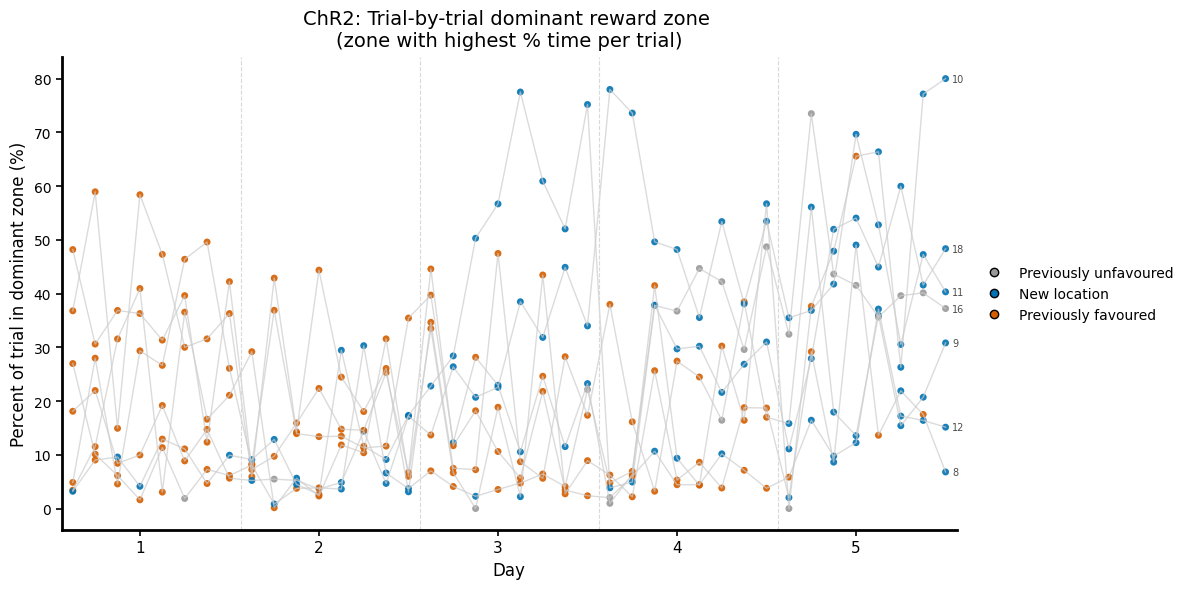

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# 1) Build RL dataset for plot_day 1–5 only
# ============================================================

mt = meta_pct[
    (meta_pct['usable'] == 1) &
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'] == 'RL') &
    (meta_pct['trial_type_day'].between(1,5)) &
    (meta_pct['pct_in_trigger_trig'].notna())
].copy()

# RL days map directly
mt['plot_day'] = mt['trial_type_day']

plot_days = np.arange(1, 6)   # only RL days

# ============================================================
# 2) Ensure trial_in_day (1..8) shared across zones
# ============================================================

candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in mt.columns), None)

if trial_col is None:
    if 'trial_id' not in mt.columns:
        mt = mt.reset_index().rename(columns={'index': 'trial_id'})
    trial_table = (
        mt[['trial_id', 'sub', 'ses', 'plot_day']]
        .drop_duplicates('trial_id')
        .sort_values(['sub', 'ses', 'plot_day', 'trial_id'])
        .copy()
    )
    trial_table['trial_in_day'] = trial_table.groupby(['sub','ses']).cumcount() + 1
    mt = mt.merge(trial_table[['trial_id','trial_in_day']], on='trial_id', how='inner')
else:
    mt['trial_in_day'] = mt[trial_col].astype(int)

mt = mt[mt['trial_in_day'].between(1,8)].copy()

# ============================================================
# 3) Dominant (max %) zone per trial
# ============================================================

if 'trial_id' in mt.columns:
    group_key = 'trial_id'
else:
    group_key = ['sub','ses','plot_day','trial_in_day']

idx_max = mt.groupby(group_key)['pct_in_trigger_trig'].idxmax()
dominant = mt.loc[idx_max].copy()

dominant['trial_idx_global'] = (dominant['plot_day'] - 1) * 8 + dominant['trial_in_day']

# ============================================================
# 4) Plot
# ============================================================

fig, ax = plt.subplots(figsize=(12,6))

zone_colors = {
    1: '#999999',  # previously unfavoured
    2: '#0072B2',  # new
    3: '#D55E00',  # previously favoured
}

zone_labels = {
    1: 'Previously unfavoured',
    2: 'New location',
    3: 'Previously favoured',
}

for sub in sorted(dominant['sub'].unique()):
    ms = dominant[dominant['sub']==sub].sort_values(['plot_day','trial_in_day'])
    x = ms['trial_idx_global'].values
    y = ms['pct_in_trigger_trig'].values

    ax.plot(
        x, y,
        '-', color='0.8',
        linewidth=1.0,
        alpha=0.7,
        label='_nolegend_'
    )

    for zid in [1,2,3]:
        ms_z = ms[ms['trigger_id']==zid]
        if len(ms_z):
            ax.scatter(
                ms_z['trial_idx_global'].values,
                ms_z['pct_in_trigger_trig'].values,
                s=25,
                color=zone_colors[zid],
                edgecolor='none',
                alpha=0.9,
                label='_nolegend_'
            )

    ax.text(
        x[-1] + 0.3,
        y[-1],
        str(sub),
        fontsize=7,
        alpha=0.7,
        va='center'
    )

# ============================================================
# 5) Cosmetics - RL only
# ============================================================

max_day = 5
trials_per_day = 8
max_trial_idx = max_day * trials_per_day

for d in range(1, max_day):
    ax.axvline(d*trials_per_day + 0.5, color='0.85', linestyle='--', linewidth=0.8)

day_centers = [(d-0.5)*trials_per_day for d in range(1, max_day+1)]
ax.set_xticks(day_centers)
ax.set_xticklabels([str(d) for d in range(1, max_day+1)], fontsize=11)

ax.set_xlim(0.5, max_trial_idx + 0.5)
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Percent of trial in dominant zone (%)', fontsize=12)

# --- legend to the right of the figure ---
handles = [
    Line2D([0],[0], marker='o', color='none',
           markerfacecolor=zone_colors[zid],
           markersize=6, label=zone_labels[zid])
    for zid in [1,2,3]
]

ax.legend(
    handles=handles,
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.2)

ax.set_title(
    'ChR2: Trial-by-trial dominant reward zone \n'
    '(zone with highest % time per trial)',
    fontsize=14, pad=8
)

plt.tight_layout()
plt.show()

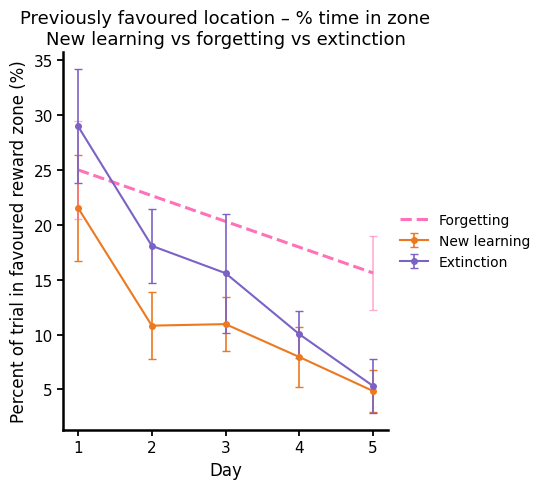

In [247]:
# plot pct time spent in previously favoured location for new learning vs forgetting/extinction

# ============================================================
# 1) RL stage – % time in previously favoured location (trigger 3)
# ============================================================

# Start from RL/T filter in meta_pct
mt_rl = meta_pct[
    (meta_pct['usable'] == 1) &
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'].isin(['RL', 'T']))
].copy()

# Assign plot_day: RL days = 1–5, Test (T) = 6
mt_rl['plot_day'] = np.nan

mask_RL = (mt_rl['trial_type'] == 'RL')
mt_rl.loc[mask_RL, 'plot_day'] = mt_rl.loc[mask_RL, 'trial_type_day']

# keep only RL 1–5 for RL
mt_rl = mt_rl[(~mask_RL) | (mt_rl['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# (We don't actually need T=6 for this plot, but we keep the logic parallel)
for sub in mt_rl['sub'].unique():
    ms = mt_rl[mt_rl['sub'] == sub]
    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue
    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue
    first_T_ses = T_after['ses'].min()
    idx = mt_rl.index[
        (mt_rl['sub'] == sub) &
        (mt_rl['trial_type'] == 'T') &
        (mt_rl['ses'] == first_T_ses)
    ]
    mt_rl.loc[idx, 'plot_day'] = 6

# We only care about RL days 1–5 here
rl_days = np.arange(1, 6)

def rl_fav_stats_pct(mt_rl, trigger_id=3):
    """
    Percent of trial spent in 'previously favoured' trigger (id=3)
    for RL days 1–5, averaged:
      1) per subject per day
      2) across subjects
    Returns mean_pct, sem_pct (arrays of length 5).
    """
    df = mt_rl[
        (mt_rl['trigger_id'] == trigger_id) &
        (mt_rl['trial_type'] == 'RL') &
        (mt_rl['plot_day'].isin(rl_days)) &
        (mt_rl['pct_in_trigger_trig'].notna())
    ].copy()

    mean_pct = np.full(len(rl_days), np.nan)
    sem_pct  = np.full(len(rl_days), np.nan)

    for i, d in enumerate(rl_days):
        df_day = df[df['plot_day'] == d]
        if df_day.empty:
            continue

        # average per animal first, then across animals
        per_sub = (
            df_day.groupby('sub')['pct_in_trigger_trig']
                  .mean()
        )
        vals = per_sub.values.astype(float)
        if vals.size == 0:
            continue

        mean_pct[i] = np.nanmean(vals)
        if vals.size > 1:
            sem_pct[i] = np.nanstd(vals, ddof=1) / np.sqrt(vals.size)

    return mean_pct, sem_pct  # units: percent

mean_rl_pct, sem_rl_pct = rl_fav_stats_pct(mt_rl, trigger_id=3)


# ============================================================
# 2) Forgetting / extinction – % time in favoured zone (trigger 2)
# ============================================================

# Filter: ChR2, TEST, usable, not short, forgetting/extinction
meta_T_pct = meta_pct[
    (meta_pct['usable'] == 1) &
    (meta_pct['trial_type'] == 'T') &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['short_duration'] != 1) &
    (meta_pct['test_type'].isin(['forgetting', 'extinction'])) &
    (meta_pct['pct_in_trigger_trig'].notna())
].copy()

test_days = np.arange(1, 6)  # test days 1–5

def build_pct_zone2(meta_df):
    """
    For a meta_df subset (forgetting or extinction),
    compute % time in trigger_id = 2 per test day (1–5):

      1) mean pct per subject per day
      2) mean & SEM across subjects

    Returns mean_pct, sem_pct (each length 5, in %).
    """
    df = meta_df[meta_df['trigger_id'] == 2].copy()
    mean_pct = np.full(len(test_days), np.nan)
    sem_pct  = np.full(len(test_days), np.nan)

    for i, d in enumerate(test_days):
        df_day = df[df['trial_type_day'] == d]
        if df_day.empty:
            continue

        per_sub = (
            df_day.groupby('sub')['pct_in_trigger_trig']
                  .mean()
        )
        vals = per_sub.values.astype(float)
        if vals.size == 0:
            continue

        mean_pct[i] = np.nanmean(vals)
        if vals.size > 1:
            sem_pct[i] = np.nanstd(vals, ddof=1) / np.sqrt(vals.size)

    return mean_pct, sem_pct  # percent

meta_forg_pct = meta_T_pct[meta_T_pct['test_type'] == 'forgetting'].copy()
meta_ext_pct  = meta_T_pct[meta_T_pct['test_type'] == 'extinction'].copy()

mean_forg_pct, sem_forg_pct = build_pct_zone2(meta_forg_pct)
mean_ext_pct,  sem_ext_pct  = build_pct_zone2(meta_ext_pct)


# ============================================================
# 3) Combined plot: RL + forgetting/extinction – favoured zone (% time)
# ============================================================

plt.figure(figsize=(7, 5))

# ---- RL previously favoured location (solid, orange) ----
plt.errorbar(
    rl_days, mean_rl_pct, yerr=sem_rl_pct,
    fmt='-o',
    color="#EC7920",         # same RL orange you used before
    ecolor="#EC7920",
    elinewidth=1.2,
    capsize=3,
    markersize=4,
    label='New learning'
)

# ---- colours for test trials (same as latency version) ----
col_f = '#FF69B4'    # pink for forgetting
col_e = '#7b62c5ff'  # purple for extinction

# ---- Forgetting (only day 1 & 5, dashed) ----
forget_days = np.array([1, 5])
x_f = forget_days
y_f = np.array([mean_forg_pct[0], mean_forg_pct[4]])
e_f = np.array([sem_forg_pct[0],  sem_forg_pct[4]])

plt.plot(
    x_f, y_f,
    '--',
    color=col_f,
    linewidth=2.2,
    alpha=0.95,
    label='Forgetting'
)
plt.errorbar(
    x_f, y_f, yerr=e_f,
    fmt='none',
    ecolor=col_f,
    alpha=0.55,
    capsize=3,
    elinewidth=1.2
)

# ---- Extinction (day 1–5, solid) ----
plt.errorbar(
    test_days, mean_ext_pct, yerr=sem_ext_pct,
    fmt='-o',
    color=col_e,
    ecolor=col_e,
    elinewidth=1.2,
    capsize=3,
    markersize=4,
    label='Extinction'
)

# ---- Axes, style ----
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.3)

plt.xlabel('Day', fontsize=12)
plt.ylabel('Percent of trial in favoured reward zone (%)', fontsize=12)
plt.xticks(rl_days, [str(d) for d in rl_days], fontsize=11)
plt.yticks(fontsize=11)

plt.title(
    'Previously favoured location – % time in zone\n'
    'New learning vs forgetting vs extinction',
    fontsize=13,
    pad=6
)

plt.legend(
    frameon=False,
    fontsize=10,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.
)

plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()


Line plot: Previously unfavoured location
Metric: time_in_trigger_trig_s
New learning trigger: 1 - Previously unfavoured location
Forgetting/extinction trigger: 1

New learning animals by day:
  RL day 1: n=7, subs=[8, 9, 10, 11, 12, 16, 18]
  RL day 2: n=7, subs=[8, 9, 10, 11, 12, 16, 18]
  RL day 3: n=7, subs=[8, 9, 10, 11, 12, 16, 18]
  RL day 4: n=7, subs=[8, 9, 10, 11, 12, 16, 18]
  RL day 5: n=7, subs=[8, 9, 10, 11, 12, 16, 18]

Forgetting animals by day:
  T day 1: n=8, subs=[6, 7, 9, 10, 11, 12, 16, 18]
  T day 2: n=0, subs=[]
  T day 3: n=0, subs=[]
  T day 4: n=0, subs=[]
  T day 5: n=8, subs=[6, 7, 9, 10, 11, 12, 16, 18]

Extinction animals by day:
  T day 1: n=9, subs=[1, 6, 7, 8, 10, 11, 12, 16, 18]
  T day 2: n=9, subs=[1, 6, 7, 8, 10, 11, 12, 16, 18]
  T day 3: n=9, subs=[1, 6, 7, 8, 10, 11, 12, 16, 18]
  T day 4: n=8, subs=[6, 7, 8, 10, 11, 12, 16, 18]
  T day 5: n=7, subs=[6, 7, 8, 10, 11, 16, 18]


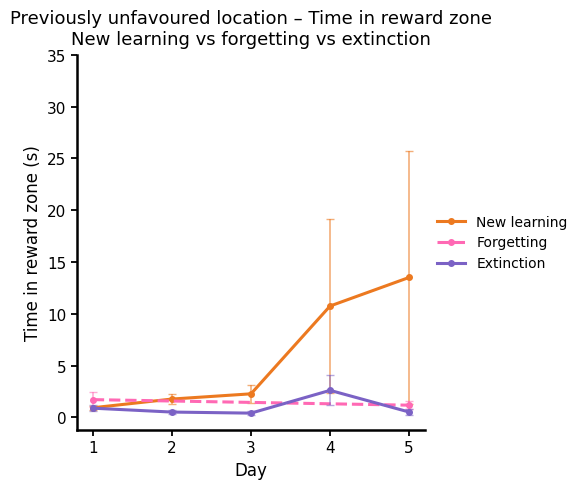


Line plot: New location
Metric: time_in_trigger_trig_s
New learning trigger: 2 - New location
Forgetting/extinction trigger: none

New learning animals by day:
  RL day 1: n=7, subs=[8, 9, 10, 11, 12, 16, 18]
  RL day 2: n=7, subs=[8, 9, 10, 11, 12, 16, 18]
  RL day 3: n=7, subs=[8, 9, 10, 11, 12, 16, 18]
  RL day 4: n=7, subs=[8, 9, 10, 11, 12, 16, 18]
  RL day 5: n=7, subs=[8, 9, 10, 11, 12, 16, 18]


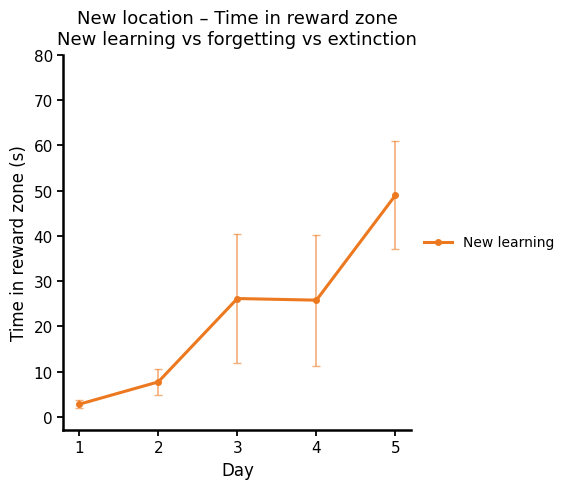


Line plot: Previously favoured location
Metric: time_in_trigger_trig_s
New learning trigger: 3 - Previously favoured location
Forgetting/extinction trigger: 2

New learning animals by day:
  RL day 1: n=7, subs=[8, 9, 10, 11, 12, 16, 18]
  RL day 2: n=7, subs=[8, 9, 10, 11, 12, 16, 18]
  RL day 3: n=7, subs=[8, 9, 10, 11, 12, 16, 18]
  RL day 4: n=7, subs=[8, 9, 10, 11, 12, 16, 18]
  RL day 5: n=7, subs=[8, 9, 10, 11, 12, 16, 18]

Forgetting animals by day:
  T day 1: n=8, subs=[6, 7, 9, 10, 11, 12, 16, 18]
  T day 2: n=0, subs=[]
  T day 3: n=0, subs=[]
  T day 4: n=0, subs=[]
  T day 5: n=8, subs=[6, 7, 9, 10, 11, 12, 16, 18]

Extinction animals by day:
  T day 1: n=9, subs=[1, 6, 7, 8, 10, 11, 12, 16, 18]
  T day 2: n=9, subs=[1, 6, 7, 8, 10, 11, 12, 16, 18]
  T day 3: n=9, subs=[1, 6, 7, 8, 10, 11, 12, 16, 18]
  T day 4: n=8, subs=[6, 7, 8, 10, 11, 12, 16, 18]
  T day 5: n=7, subs=[6, 7, 8, 10, 11, 16, 18]


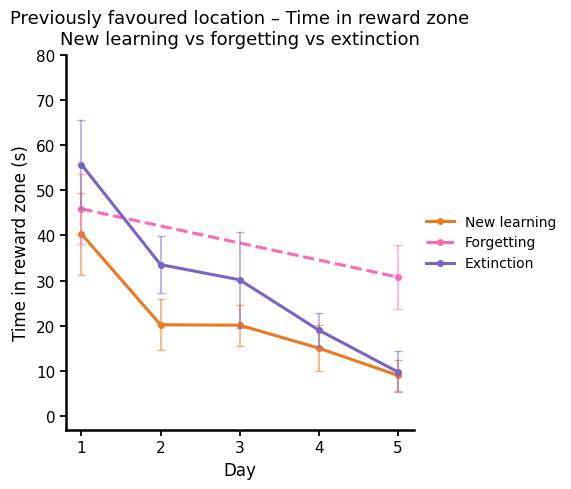


Extracted new-learning test rows
No rows

Extracted forgetting day-5 test rows
    experiment  sub  id  trigger_id                      zone_label   value  \
0   Forgetting    6  AB           1  Previously unfavoured location   0.301   
1   Forgetting    6  AB           2    Previously favoured location  31.241   
2   Forgetting    7  AC           1  Previously unfavoured location   0.069   
3   Forgetting    7  AC           2    Previously favoured location  26.224   
4   Forgetting    9  AE           1  Previously unfavoured location   3.005   
5   Forgetting    9  AE           2    Previously favoured location  69.086   
6   Forgetting   10  AF           1  Previously unfavoured location   0.000   
7   Forgetting   10  AF           2    Previously favoured location  48.458   
8   Forgetting   11  AG           1  Previously unfavoured location   2.608   
9   Forgetting   11  AG           2    Previously favoured location  12.238   
10  Forgetting   12  AH           1  Previously unf

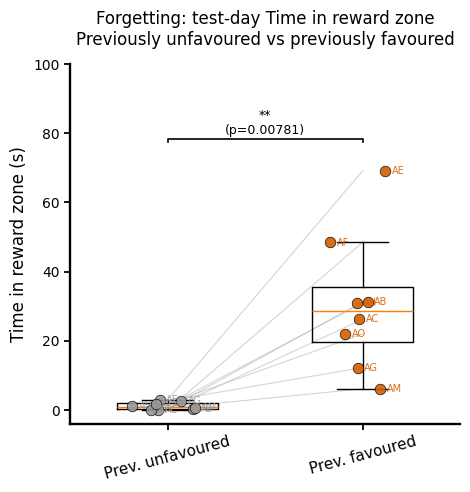


Test-day paired boxplot: Extinction
Metric: time_in_trigger_trig_s
Comparison: Previously unfavoured vs Previously favoured
Paired animals:
   sub  id  unfav_value  fav_value
0    6  AB        0.000     5.7780
1    7  AC        2.061     7.1060
2    8  AD        0.000    36.7355
3   10  AF        0.384     1.7350
4   11  AG        0.000     6.1330
5   16  AM        1.216     5.1940
6   18  AO        0.000     5.8000
Wilcoxon paired test: n=7, unfav mean=0.523, fav mean=9.783, unfav median=0.000, fav median=5.800, W=0.000, p=0.01562


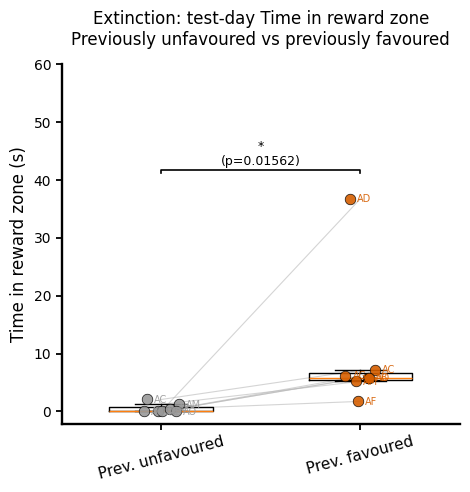

In [248]:
# ============================================================
# Compare time / pct spent in reward zones:
#
# New learning:
#   RL days 1–5, ChR2
#   trigger_id:
#       1 = Previously unfavoured location
#       2 = New location
#       3 = Previously favoured location
#
# Forgetting / extinction:
#   T days 1–5, ChR2
#   trigger_id:
#       1 = Previously unfavoured location
#       2 = Previously favoured location
#
# Produces:
#   1) Line plot for each target zone:
#        New learning vs forgetting vs extinction
#
#      For "New location", forgetting/extinction are not plotted because
#      they only have trigger 1 and trigger 2.
#
#   2) Test-day paired boxplots comparing:
#        Previously unfavoured location vs Previously favoured location
#
#      New learning test extraction:
#        T trial where trial_id == 11
#        and ses == ses of RL day 5 for that animal
#
#      Forgetting/extinction test extraction:
#        T trial_type_day == 5
#
# Flexible metric:
#   VALUE_MODE = 'pct'  -> pct_in_trigger_trig
#   VALUE_MODE = 'time' -> time_in_trigger_trig_s
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# ============================================================
# OPTIONS
# ============================================================

GENOTYPE_TO_PLOT = 'ChR2'

VALUE_MODE = 'time'
# VALUE_MODE = 'pct'

EXCLUDE_ID = []
EXCLUDE_SUBS = []

# If True, excludes short_duration == 1.
# You can set this to False if you do not want short-duration filtering.
FILTER_SHORT_DURATION = True

RUN_LINE_PLOTS = True
RUN_TEST_ZONE_BOXPLOTS = True

SHOW_ANIMAL_IDS = True
SHOW_PAIRED_LINES = True

# New learning:
# 1 = prev unfavoured, 2 = new, 3 = prev favoured
NL_ZONE_LABELS = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

# Forgetting/extinction:
# 1 = prev unfavoured, 2 = prev favoured
FE_ZONE_LABELS = {
    1: 'Previously unfavoured location',
    2: 'Previously favoured location',
}

# Target zones to plot from new learning.
TARGET_ZONES_NL = [1, 2, 3]

ZONE_COLORS = {
    1: '#999999',  # previously unfavoured
    2: '#0072B2',  # new location
    3: '#D55E00',  # previously favoured
}

# Experiment colours
COL_NEW_LEARNING = '#EC7920'
COL_FORGETTING = '#FF69B4'
COL_EXTINCTION = '#7b62c5ff'

# Plot style
LINE_SEM_STYLE = 'bar'
# LINE_SEM_STYLE = 'shaded'
# LINE_SEM_STYLE = 'none'

Y_ZERO_PAD_FRAC = 0.04
Y_TOP_PAD_FRAC = 0.18

YMAX_LINE = None
YMIN_LINE = None
Y_TICK_STEP_LINE = None

YMAX_BOX = None
YMIN_BOX = None
Y_TICK_STEP_BOX = None

JITTER = 0.08
DOT_SIZE = 58
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.5

P_DECIMALS = 5
P_LINE_START_FRAC = 0.12
P_TEXT_OFFSET_FRAC = 0.025
BOX_TOP_PAD_FRAC = 0.28

np.random.seed(1)

# ============================================================
# Metric column
# ============================================================

if VALUE_MODE == 'pct':
    VALUE_COL = 'pct_in_trigger_trig'
    VALUE_LABEL = 'Percent of trial in reward zone (%)'
    VALUE_TITLE = '% time in reward zone'
elif VALUE_MODE == 'time':
    VALUE_COL = 'time_in_trigger_trig_s'
    VALUE_LABEL = 'Time in reward zone (s)'
    VALUE_TITLE = 'Time in reward zone'
else:
    raise ValueError("VALUE_MODE must be 'pct' or 'time'")

# ============================================================
# Helpers
# ============================================================

def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def format_p(p, decimals=P_DECIMALS):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def style_nature(ax, linewidth=1.8):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.3)
    ax.grid(False)


def mean_sem(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return np.nan, np.nan

    if len(vals) == 1:
        return float(vals[0]), 0.0

    return float(np.nanmean(vals)), float(np.nanstd(vals, ddof=1) / np.sqrt(len(vals)))


def wilcoxon_safe(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    ok = np.isfinite(a) & np.isfinite(b)
    a = a[ok]
    b = b[ok]

    if len(a) == 0:
        return np.nan, np.nan

    if np.allclose(a, b, equal_nan=False):
        return np.nan, 1.0

    try:
        stat, p = wilcoxon(a, b, alternative='two-sided')
    except ValueError:
        stat, p = np.nan, 1.0

    return stat, p


def get_animal_id(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


def apply_y_axis_line(ax, all_vals):
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if YMAX_LINE is not None:
        y_top = float(YMAX_LINE)
    else:
        if len(all_vals) == 0:
            y_top = 1.0
        else:
            y_top = np.nanmax(all_vals)
            if not np.isfinite(y_top) or y_top <= 0:
                y_top = 1.0
        y_top = y_top * (1 + Y_TOP_PAD_FRAC)

    if YMIN_LINE is not None:
        y_bottom = float(YMIN_LINE)
    else:
        y_bottom = -Y_ZERO_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if Y_TICK_STEP_LINE is not None:
        ax.set_yticks(np.arange(0, y_top + Y_TICK_STEP_LINE, Y_TICK_STEP_LINE))
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]
        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)
        ax.set_yticks(yticks)


def apply_y_axis_box(ax, all_vals, stat_y=None):
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if YMAX_BOX is not None:
        y_top = float(YMAX_BOX)
    else:
        if len(all_vals) == 0:
            y_top = 1.0
        else:
            y_top = np.nanmax(all_vals)

            if stat_y is not None and np.isfinite(stat_y):
                y_top = max(y_top, stat_y)

            if not np.isfinite(y_top) or y_top <= 0:
                y_top = 1.0

        y_top = y_top * (1 + BOX_TOP_PAD_FRAC)

    if YMIN_BOX is not None:
        y_bottom = float(YMIN_BOX)
    else:
        y_bottom = -Y_ZERO_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if Y_TICK_STEP_BOX is not None:
        ax.set_yticks(np.arange(0, y_top + Y_TICK_STEP_BOX, Y_TICK_STEP_BOX))
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]
        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)
        ax.set_yticks(yticks)


def draw_sig_bar(ax, x1, x2, y, p, yrng):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + 0.015 * yrng, y + 0.015 * yrng, y],
        color='black',
        linewidth=1.2
    )

    ax.text(
        (x1 + x2) / 2,
        y + P_TEXT_OFFSET_FRAC * yrng,
        f"{p_to_stars(p)}\n(p={format_p(p)})",
        ha='center',
        va='bottom',
        fontsize=9
    )


# ============================================================
# Check required columns
# ============================================================

needed_cols = [
    'usable',
    'genotype',
    'trial_type',
    'trial_type_day',
    'ses',
    'sub',
    'trigger_id',
    VALUE_COL,
]

if FILTER_SHORT_DURATION:
    needed_cols.append('short_duration')

# trial_id needed for new-learning test extraction
needed_cols_for_test = ['trial_id']

missing_cols = [c for c in needed_cols if c not in meta_pct.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Missing columns in meta_pct: {missing_cols}")

missing_test_cols = [c for c in needed_cols_for_test if c not in meta_pct.columns]
if len(missing_test_cols) > 0:
    raise KeyError(
        f"Missing columns in meta_pct: {missing_test_cols}. "
        "New-learning test extraction requires trial_id == 11."
    )

# ============================================================
# 1. New learning data: RL days 1–5
# ============================================================

def prepare_new_learning_rl(meta_pct):
    mt = meta_pct[
        (meta_pct['usable'] == 1) &
        (meta_pct['genotype'] == GENOTYPE_TO_PLOT) &
        (meta_pct['trial_type'].isin(['RL', 'T'])) &
        (meta_pct['trigger_id'].isin([1, 2, 3])) &
        (meta_pct[VALUE_COL].notna()) &
        (np.isfinite(meta_pct[VALUE_COL]))
    ].copy()

    if FILTER_SHORT_DURATION:
        mt = mt[mt['short_duration'] != 1].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in mt.columns:
        mt = mt[~mt['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])].copy()

    if len(EXCLUDE_SUBS) > 0:
        mt = mt[~mt['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])].copy()

    mt['plot_day'] = np.nan

    mask_RL = mt['trial_type'] == 'RL'
    mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

    mt = mt[
        (~mask_RL) |
        (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))
    ].copy()

    return mt


mt_rl = prepare_new_learning_rl(meta_pct)

rl_days = np.arange(1, 6)


def build_new_learning_zone_stats(mt_rl, trigger_id):
    """
    New learning:
      trigger 1 = previously unfavoured
      trigger 2 = new location
      trigger 3 = previously favoured

    Returns mean, SEM for RL days 1–5.
    """
    df = mt_rl[
        (mt_rl['trial_type'] == 'RL') &
        (mt_rl['trigger_id'] == trigger_id) &
        (mt_rl['plot_day'].isin(rl_days))
    ].copy()

    mean_vals = np.full(len(rl_days), np.nan)
    sem_vals = np.full(len(rl_days), np.nan)
    ids_by_day = {}

    for i, d in enumerate(rl_days):
        df_day = df[df['plot_day'] == d].copy()

        if len(df_day) == 0:
            continue

        per_sub = (
            df_day.groupby('sub', as_index=False)
                  .agg(value=(VALUE_COL, 'mean'))
        )

        vals = per_sub['value'].values.astype(float)
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            continue

        mean_vals[i], sem_vals[i] = mean_sem(vals)
        ids_by_day[d] = list(per_sub['sub'])

    return mean_vals, sem_vals, ids_by_day


# ============================================================
# 2. Forgetting / extinction data: T days 1–5
# ============================================================

def prepare_forgetting_extinction(meta_pct):
    if 'test_type' not in meta_pct.columns:
        raise KeyError("Missing column in meta_pct: test_type")

    mt = meta_pct[
        (meta_pct['usable'] == 1) &
        (meta_pct['genotype'] == GENOTYPE_TO_PLOT) &
        (meta_pct['trial_type'] == 'T') &
        (meta_pct['test_type'].isin(['forgetting', 'extinction'])) &
        (meta_pct['trigger_id'].isin([1, 2])) &
        (meta_pct['trial_type_day'].isin([1, 2, 3, 4, 5])) &
        (meta_pct[VALUE_COL].notna()) &
        (np.isfinite(meta_pct[VALUE_COL]))
    ].copy()

    if FILTER_SHORT_DURATION:
        mt = mt[mt['short_duration'] != 1].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in mt.columns:
        mt = mt[~mt['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])].copy()

    if len(EXCLUDE_SUBS) > 0:
        mt = mt[~mt['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])].copy()

    return mt


mt_fe = prepare_forgetting_extinction(meta_pct)

test_days = np.arange(1, 6)


def build_fe_zone_stats(mt_fe, test_type, trigger_id):
    """
    Forgetting/extinction:
      trigger 1 = previously unfavoured
      trigger 2 = previously favoured

    Returns mean, SEM for T days 1–5.
    """
    df = mt_fe[
        (mt_fe['test_type'] == test_type) &
        (mt_fe['trigger_id'] == trigger_id)
    ].copy()

    mean_vals = np.full(len(test_days), np.nan)
    sem_vals = np.full(len(test_days), np.nan)
    ids_by_day = {}

    for i, d in enumerate(test_days):
        df_day = df[df['trial_type_day'] == d].copy()

        if len(df_day) == 0:
            continue

        per_sub = (
            df_day.groupby('sub', as_index=False)
                  .agg(value=(VALUE_COL, 'mean'))
        )

        vals = per_sub['value'].values.astype(float)
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            continue

        mean_vals[i], sem_vals[i] = mean_sem(vals)
        ids_by_day[d] = list(per_sub['sub'])

    return mean_vals, sem_vals, ids_by_day


# ============================================================
# 3. Line plot for one zone
# ============================================================

def plot_zone_line(new_learning_trigger_id):
    """
    Plot New learning vs forgetting vs extinction for one logical zone.

    Mapping:
      New learning:
        1 = prev unfavoured
        2 = new
        3 = prev favoured

      Forgetting/extinction:
        1 = prev unfavoured
        2 = prev favoured

    There is no equivalent 'new location' in forgetting/extinction.
    """
    zone_name = NL_ZONE_LABELS[new_learning_trigger_id]

    mean_nl, sem_nl, ids_nl = build_new_learning_zone_stats(
        mt_rl,
        trigger_id=new_learning_trigger_id
    )

    # Map equivalent trigger in forgetting/extinction
    if new_learning_trigger_id == 1:
        fe_trigger_id = 1
    elif new_learning_trigger_id == 3:
        fe_trigger_id = 2
    else:
        fe_trigger_id = None

    if fe_trigger_id is not None:
        mean_forg, sem_forg, ids_forg = build_fe_zone_stats(
            mt_fe,
            test_type='forgetting',
            trigger_id=fe_trigger_id
        )
        mean_ext, sem_ext, ids_ext = build_fe_zone_stats(
            mt_fe,
            test_type='extinction',
            trigger_id=fe_trigger_id
        )
    else:
        mean_forg = np.full(len(test_days), np.nan)
        sem_forg = np.full(len(test_days), np.nan)
        mean_ext = np.full(len(test_days), np.nan)
        sem_ext = np.full(len(test_days), np.nan)
        ids_forg = {}
        ids_ext = {}

    print("\n============================================================")
    print(f"Line plot: {zone_name}")
    print("Metric:", VALUE_COL)
    print("New learning trigger:", new_learning_trigger_id, "-", zone_name)
    print("Forgetting/extinction trigger:", fe_trigger_id if fe_trigger_id is not None else "none")

    print("\nNew learning animals by day:")
    for d in rl_days:
        print(f"  RL day {d}: n={len(ids_nl.get(d, []))}, subs={ids_nl.get(d, [])}")

    if fe_trigger_id is not None:
        print("\nForgetting animals by day:")
        for d in test_days:
            print(f"  T day {d}: n={len(ids_forg.get(d, []))}, subs={ids_forg.get(d, [])}")

        print("\nExtinction animals by day:")
        for d in test_days:
            print(f"  T day {d}: n={len(ids_ext.get(d, []))}, subs={ids_ext.get(d, [])}")

    fig, ax = plt.subplots(figsize=(7.3, 5))

    all_y = []

    # New learning
    if LINE_SEM_STYLE == 'shaded':
        ax.fill_between(
            rl_days,
            mean_nl - sem_nl,
            mean_nl + sem_nl,
            color=COL_NEW_LEARNING,
            alpha=0.22,
            linewidth=0
        )

    ax.plot(
        rl_days,
        mean_nl,
        '-o',
        color=COL_NEW_LEARNING,
        linewidth=2.2,
        markersize=4,
        label='New learning'
    )

    if LINE_SEM_STYLE == 'bar':
        ax.errorbar(
            rl_days,
            mean_nl,
            yerr=sem_nl,
            fmt='none',
            ecolor=COL_NEW_LEARNING,
            alpha=0.6,
            capsize=3,
            elinewidth=1.2
        )

    all_y.extend(list((mean_nl + sem_nl)[np.isfinite(mean_nl + sem_nl)]))
    all_y.extend(list((mean_nl - sem_nl)[np.isfinite(mean_nl - sem_nl)]))

    # Forgetting and extinction only for zones that exist in that experiment
    if fe_trigger_id is not None:

        # Forgetting: show day 1 and day 5 only, matching your previous style
        forget_days = np.array([1, 5])
        y_f = np.array([mean_forg[0], mean_forg[4]], dtype=float)
        e_f = np.array([sem_forg[0], sem_forg[4]], dtype=float)

        ax.plot(
            forget_days,
            y_f,
            '--o',
            color=COL_FORGETTING,
            linewidth=2.2,
            markersize=4,
            label='Forgetting'
        )

        if LINE_SEM_STYLE == 'bar':
            ax.errorbar(
                forget_days,
                y_f,
                yerr=e_f,
                fmt='none',
                ecolor=COL_FORGETTING,
                alpha=0.55,
                capsize=3,
                elinewidth=1.2
            )

        elif LINE_SEM_STYLE == 'shaded':
            ax.fill_between(
                forget_days,
                y_f - e_f,
                y_f + e_f,
                color=COL_FORGETTING,
                alpha=0.18,
                linewidth=0
            )

        all_y.extend(list((y_f + e_f)[np.isfinite(y_f + e_f)]))
        all_y.extend(list((y_f - e_f)[np.isfinite(y_f - e_f)]))

        # Extinction: day 1–5
        if LINE_SEM_STYLE == 'shaded':
            ax.fill_between(
                test_days,
                mean_ext - sem_ext,
                mean_ext + sem_ext,
                color=COL_EXTINCTION,
                alpha=0.20,
                linewidth=0
            )

        ax.plot(
            test_days,
            mean_ext,
            '-o',
            color=COL_EXTINCTION,
            linewidth=2.2,
            markersize=4,
            label='Extinction'
        )

        if LINE_SEM_STYLE == 'bar':
            ax.errorbar(
                test_days,
                mean_ext,
                yerr=sem_ext,
                fmt='none',
                ecolor=COL_EXTINCTION,
                alpha=0.55,
                capsize=3,
                elinewidth=1.2
            )

        all_y.extend(list((mean_ext + sem_ext)[np.isfinite(mean_ext + sem_ext)]))
        all_y.extend(list((mean_ext - sem_ext)[np.isfinite(mean_ext - sem_ext)]))

    ax.set_xlabel('Day', fontsize=12)
    ax.set_ylabel(VALUE_LABEL, fontsize=12)

    ax.set_xticks(rl_days)
    ax.set_xticklabels([str(d) for d in rl_days], fontsize=11)
    ax.tick_params(axis='y', labelsize=11)

    ax.set_title(
        f'{zone_name} – {VALUE_TITLE}\n'
        f'New learning vs forgetting vs extinction',
        fontsize=13,
        pad=8
    )

    style_nature(ax, linewidth=1.8)

    apply_y_axis_line(ax, all_y)

    ax.legend(
        frameon=False,
        fontsize=10,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.
    )

    plt.tight_layout(rect=[0, 0, 0.8, 1])
    plt.show()


# ============================================================
# 4. Test-day extraction for paired boxplots
# ============================================================

def extract_new_learning_test_values():
    """
    New learning test values:
      - T trial
      - trial_id == 11
      - same ses as RL day 5 for that animal
      - compare trigger 1 vs trigger 3
    """
    rows = []

    mt = meta_pct[
        (meta_pct['usable'] == 1) &
        (meta_pct['genotype'] == GENOTYPE_TO_PLOT) &
        (meta_pct['trigger_id'].isin([1, 3])) &
        (meta_pct[VALUE_COL].notna()) &
        (np.isfinite(meta_pct[VALUE_COL]))
    ].copy()

    if FILTER_SHORT_DURATION:
        mt = mt[mt['short_duration'] != 1].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in mt.columns:
        mt = mt[~mt['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])].copy()

    if len(EXCLUDE_SUBS) > 0:
        mt = mt[~mt['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])].copy()

    for sub in sorted(mt['sub'].unique()):
        ms = mt[mt['sub'] == sub].copy()

        rl5 = ms[
            (ms['trial_type'] == 'RL') &
            (ms['trial_type_day'] == 5)
        ].copy()

        if len(rl5) == 0:
            continue

        # If multiple RL5 sessions are present, use the last.
        rl5_ses = rl5['ses'].max()

        test = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] == rl5_ses) &
            (ms['trial_id'] == 11) &
            (ms['trigger_id'].isin([1, 3]))
        ].copy()

        if len(test) == 0:
            continue

        for trig_id in [1, 3]:
            ms_trig = test[test['trigger_id'] == trig_id].copy()

            if len(ms_trig) == 0:
                continue

            value = ms_trig[VALUE_COL].mean()

            if not np.isfinite(value):
                continue

            rows.append({
                'experiment': 'New learning',
                'sub': sub,
                'id': get_animal_id(ms_trig, sub),
                'trigger_id': trig_id,
                'zone_label': NL_ZONE_LABELS[trig_id],
                'value': float(value),
                'ses': rl5_ses,
                'trial_id': 11,
            })

    return pd.DataFrame(rows)


def extract_fe_test_day5_values(test_type):
    """
    Forgetting/extinction test values:
      - T trial
      - test_type == forgetting or extinction
      - trial_type_day == 5
      - compare trigger 1 vs trigger 2
    """
    rows = []

    mt = meta_pct[
        (meta_pct['usable'] == 1) &
        (meta_pct['genotype'] == GENOTYPE_TO_PLOT) &
        (meta_pct['trial_type'] == 'T') &
        (meta_pct['test_type'] == test_type) &
        (meta_pct['trial_type_day'] == 5) &
        (meta_pct['trigger_id'].isin([1, 2])) &
        (meta_pct[VALUE_COL].notna()) &
        (np.isfinite(meta_pct[VALUE_COL]))
    ].copy()

    if FILTER_SHORT_DURATION:
        mt = mt[mt['short_duration'] != 1].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in mt.columns:
        mt = mt[~mt['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])].copy()

    if len(EXCLUDE_SUBS) > 0:
        mt = mt[~mt['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])].copy()

    for sub in sorted(mt['sub'].unique()):
        ms = mt[mt['sub'] == sub].copy()

        for trig_id in [1, 2]:
            ms_trig = ms[ms['trigger_id'] == trig_id].copy()

            if len(ms_trig) == 0:
                continue

            value = ms_trig[VALUE_COL].mean()

            if not np.isfinite(value):
                continue

            rows.append({
                'experiment': test_type.capitalize(),
                'sub': sub,
                'id': get_animal_id(ms_trig, sub),
                'trigger_id': trig_id,
                'zone_label': FE_ZONE_LABELS[trig_id],
                'value': float(value),
                'ses': ms_trig['ses'].iloc[0] if 'ses' in ms_trig.columns else np.nan,
                'trial_type_day': 5,
            })

    return pd.DataFrame(rows)


# ============================================================
# 5. Paired boxplot: prev unfavoured vs prev favoured
# ============================================================

def plot_prev_unfav_vs_prev_fav_boxplot(df, experiment_name):
    if len(df) == 0:
        print(f"\nSkipping {experiment_name}: no data.")
        return

    # For new learning:
    #   prev unfavoured = trigger 1
    #   prev favoured = trigger 3
    #
    # For forgetting/extinction:
    #   prev unfavoured = trigger 1
    #   prev favoured = trigger 2
    if experiment_name == 'New learning':
        trig_unfav = 1
        trig_fav = 3
    else:
        trig_unfav = 1
        trig_fav = 2

    df_unfav = df[df['trigger_id'] == trig_unfav][['sub', 'id', 'value']].rename(
        columns={'id': 'id_unfav', 'value': 'unfav_value'}
    )

    df_fav = df[df['trigger_id'] == trig_fav][['sub', 'id', 'value']].rename(
        columns={'id': 'id_fav', 'value': 'fav_value'}
    )

    paired = df_unfav.merge(df_fav, on='sub', how='inner')
    paired['id'] = paired['id_unfav'].fillna(paired['id_fav'])

    paired = paired[
        paired['unfav_value'].notna() &
        paired['fav_value'].notna() &
        np.isfinite(paired['unfav_value']) &
        np.isfinite(paired['fav_value'])
    ].copy()

    print("\n============================================================")
    print(f"Test-day paired boxplot: {experiment_name}")
    print("Metric:", VALUE_COL)
    print("Comparison: Previously unfavoured vs Previously favoured")
    print("Paired animals:")
    if len(paired) > 0:
        print(paired[['sub', 'id', 'unfav_value', 'fav_value']].reset_index(drop=True))
    else:
        print("No paired animals.")
        return

    unfav_vals = paired['unfav_value'].values.astype(float)
    fav_vals = paired['fav_value'].values.astype(float)

    stat, p = wilcoxon_safe(unfav_vals, fav_vals)

    print(
        f"Wilcoxon paired test: "
        f"n={len(paired)}, "
        f"unfav mean={np.nanmean(unfav_vals):.3f}, "
        f"fav mean={np.nanmean(fav_vals):.3f}, "
        f"unfav median={np.nanmedian(unfav_vals):.3f}, "
        f"fav median={np.nanmedian(fav_vals):.3f}, "
        f"W={stat:.3f}, "
        f"p={format_p(p)}"
    )

    fig, ax = plt.subplots(figsize=(4.8, 5.4))

    positions = np.arange(2)
    data = [unfav_vals, fav_vals]

    ax.boxplot(
        data,
        positions=positions,
        widths=0.52,
        patch_artist=False,
        showfliers=False
    )

    if SHOW_PAIRED_LINES:
        for u, f in zip(unfav_vals, fav_vals):
            ax.plot(
                positions,
                [u, f],
                '-',
                color='0.72',
                linewidth=0.8,
                alpha=0.6,
                zorder=1
            )

    plot_colors = [ZONE_COLORS[1], ZONE_COLORS[3]]

    for i, vals in enumerate(data):
        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=plot_colors[i],
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            alpha=0.9,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, paired['id'].values):
                ax.text(
                    xi + 0.035,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=plot_colors[i],
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    all_vals = np.r_[unfav_vals, fav_vals]
    ymax = np.nanmax(all_vals)
    ymin = np.nanmin(all_vals)
    yrng = ymax - ymin

    if not np.isfinite(yrng) or yrng <= 0:
        yrng = max(abs(ymax), 1.0)

    y = ymax + P_LINE_START_FRAC * yrng

    draw_sig_bar(
        ax=ax,
        x1=positions[0],
        x2=positions[1],
        y=y,
        p=p,
        yrng=yrng
    )

    ax.set_xticks(positions)
    ax.set_xticklabels(
        ['Prev. unfavoured', 'Prev. favoured'],
        fontsize=11,
        rotation=15
    )

    ax.set_ylabel(VALUE_LABEL, fontsize=12)

    ax.set_title(
        f'{experiment_name}: test-day {VALUE_TITLE}\n'
        f'Previously unfavoured vs previously favoured',
        fontsize=12,
        pad=14
    )

    style_nature(ax, linewidth=1.7)
    apply_y_axis_box(ax, all_vals, stat_y=y)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


# ============================================================
# Run line plots
# ============================================================

if RUN_LINE_PLOTS:
    for trig_id in TARGET_ZONES_NL:
        plot_zone_line(trig_id)


# ============================================================
# Run paired test-day boxplots
# ============================================================

if RUN_TEST_ZONE_BOXPLOTS:
    df_nl_test = extract_new_learning_test_values()
    df_forg_test = extract_fe_test_day5_values('forgetting')
    df_ext_test = extract_fe_test_day5_values('extinction')

    print("\n============================================================")
    print("Extracted new-learning test rows")
    print(df_nl_test.reset_index(drop=True) if len(df_nl_test) > 0 else "No rows")

    print("\n============================================================")
    print("Extracted forgetting day-5 test rows")
    print(df_forg_test.reset_index(drop=True) if len(df_forg_test) > 0 else "No rows")

    print("\n============================================================")
    print("Extracted extinction day-5 test rows")
    print(df_ext_test.reset_index(drop=True) if len(df_ext_test) > 0 else "No rows")

    plot_prev_unfav_vs_prev_fav_boxplot(df_nl_test, 'New learning')
    plot_prev_unfav_vs_prev_fav_boxplot(df_forg_test, 'Forgetting')
    plot_prev_unfav_vs_prev_fav_boxplot(df_ext_test, 'Extinction')

N per group (Day 5, % time):
  New Learning (RL, trig3): 7
  Forgetting (T, trig2):    8
  Extinction (T, trig2):    7
RL vs Forg: raw p = 0.00932
RL vs Ext: raw p = 0.805
Forg vs Ext: raw p = 0.014

FDR-corrected p-values (Benjamini–Hochberg):
  RL vs Forg: p_FDR = 0.021
  RL vs Ext: p_FDR = 0.805
  Forg vs Ext: p_FDR = 0.021


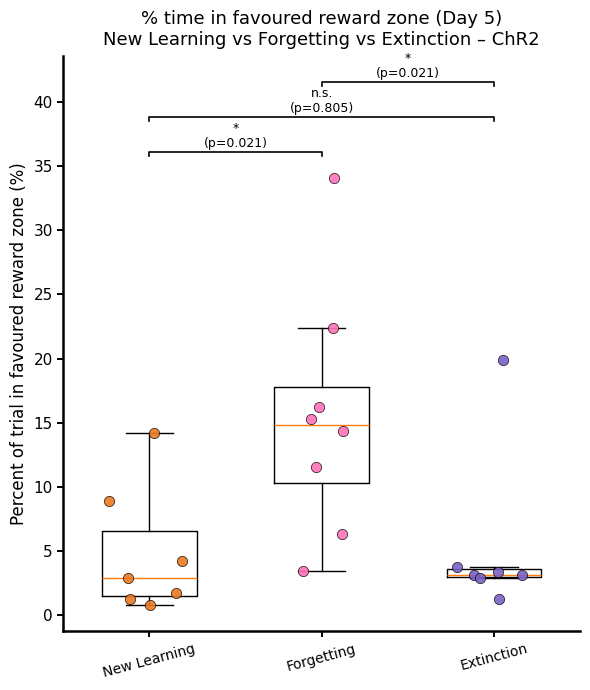

In [ ]:

from scipy.stats import mannwhitneyu

# Try to import statsmodels for FDR correction
try:
    from statsmodels.stats.multitest import multipletests
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("Warning: statsmodels not installed → FDR correction skipped (raw p-values used).")

# ------------------------------------------------------------
# 1) Extract data for three groups (all ChR2, Day 5, % time)
#    - New Learning: RL day 5, trigger_id = 3 (previously favoured)
#    - Forgetting:   Test day 5, trigger_id = 2 (favoured)
#    - Extinction:   Test day 5, trigger_id = 2 (favoured)
#    Metric: pct_in_trigger_trig (% of trial in that zone),
#            averaged per animal for that day.
#    Source: meta_pct
# ------------------------------------------------------------

# ---- New Learning (RL day 5, trig=3) ----
rl_df_pct = meta_pct[
    (meta_pct['usable'] == 1) &
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'] == 'RL') &
    (meta_pct['trigger_id'] == 3) &
    (meta_pct['trial_type_day'] == 5) &
    (meta_pct['pct_in_trigger_trig'].notna())
].copy()

rl_per_sub_pct = (
    rl_df_pct.groupby('sub')['pct_in_trigger_trig']
             .mean()
             .astype(float)
)
vals_rl_pct = rl_per_sub_pct.values   # percent


# ---- Forgetting (Test day 5, T, trig=2) ----
forg_df_pct = meta_pct[
    (meta_pct['usable'] == 1) &
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'] == 'T') &
    (meta_pct['test_type'] == 'forgetting') &
    (meta_pct['trigger_id'] == 2) &
    (meta_pct['trial_type_day'] == 5) &
    (meta_pct['pct_in_trigger_trig'].notna())
].copy()

forg_per_sub_pct = (
    forg_df_pct.groupby('sub')['pct_in_trigger_trig']
               .mean()
               .astype(float)
)
vals_forg_pct = forg_per_sub_pct.values   # percent


# ---- Extinction (Test day 5, T, trig=2) ----
ext_df_pct = meta_pct[
    (meta_pct['usable'] == 1) &
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'] == 'T') &
    (meta_pct['test_type'] == 'extinction') &
    (meta_pct['trigger_id'] == 2) &
    (meta_pct['trial_type_day'] == 5) &
    (meta_pct['pct_in_trigger_trig'].notna())
].copy()

ext_per_sub_pct = (
    ext_df_pct.groupby('sub')['pct_in_trigger_trig']
              .mean()
              .astype(float)
)
vals_ext_pct = ext_per_sub_pct.values   # percent

print("N per group (Day 5, % time):")
print("  New Learning (RL, trig3):", len(vals_rl_pct))
print("  Forgetting (T, trig2):   ", len(vals_forg_pct))
print("  Extinction (T, trig2):   ", len(vals_ext_pct))

# ------------------------------------------------------------
# 2) Prepare boxplot data
# ------------------------------------------------------------
groups = ["New Learning", "Forgetting", "Extinction"]
data   = [vals_rl_pct,   vals_forg_pct,   vals_ext_pct]
positions = np.arange(len(groups))

colors = {
    "New Learning": "#EC7920",   # orange (same as line plot)
    "Forgetting":   "#FF72B8",   # pink
    "Extinction":   "#7b62c5ff"  # purple
}

# ------------------------------------------------------------
# 3) Boxplot + jittered individual points
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 7))

# plain black boxes, no fliers
bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.55,
    patch_artist=False,
    showfliers=False
)

# jittered animal points
for i, g in enumerate(groups):
    vals = data[i]
    if len(vals) == 0:
        continue
    jitter = 0.10
    x = np.random.normal(positions[i], jitter, size=len(vals))
    ax.scatter(
        x, vals,
        s=55,
        color=colors[g],
        edgecolor='k',
        linewidth=0.5,
        alpha=0.9,
        zorder=3
    )

# ------------------------------------------------------------
# 4) Mann–Whitney tests + FDR + significance stars
# ------------------------------------------------------------
def mannwhitney_safe(a, b):
    if (len(a) < 1) or (len(b) < 1):
        return np.nan
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    return p

p_raw = []

comparisons = [
    ("RL vs Forg",   0, 1, vals_rl_pct,   vals_forg_pct),
    ("RL vs Ext",    0, 2, vals_rl_pct,   vals_ext_pct),
    ("Forg vs Ext",  1, 2, vals_forg_pct, vals_ext_pct),
]

for name, i1, i2, v1, v2 in comparisons:
    p = mannwhitney_safe(v1, v2)
    p_raw.append(p)
    print(f"{name}: raw p = {p:.3g}" if not np.isnan(p) else f"{name}: p = NaN")

p_raw = np.array(p_raw, dtype=float)

# FDR correction (if statsmodels available)
if HAS_SM:
    mask_valid = ~np.isnan(p_raw)
    p_adj = p_raw.copy()
    if mask_valid.any():
        rej, p_corr, _, _ = multipletests(p_raw[mask_valid], alpha=0.05, method='fdr_bh')
        p_adj[mask_valid] = p_corr
    print("\nFDR-corrected p-values (Benjamini–Hochberg):")
    for (name, *_), p_corr_val in zip(comparisons, p_adj):
        print(f"  {name}: p_FDR = {p_corr_val:.3g}")
else:
    p_adj = p_raw
    print("\nUsing raw p-values for annotation (no FDR correction).")

def p_to_stars(p):
    if np.isnan(p):   return "n.s."
    if p < 1e-4:      return "****"
    if p < 1e-3:      return "***"
    if p < 1e-2:      return "**"
    if p < 0.05:      return "*"
    return "n.s."

# Add significance bars above boxes
all_vals = np.concatenate([v for v in data if len(v) > 0])
y_max = np.nanmax(all_vals)
y_step = 0.08 * y_max  # vertical spacing
current_y = y_max * 1.05

for (name, x1, x2, _, _), p in zip(comparisons, p_adj):
    if np.isnan(p):
        continue
    stars = p_to_stars(p)

    # bar
    ax.plot(
        [x1, x1, x2, x2],
        [current_y, current_y + 0.01 * y_max,
         current_y + 0.01 * y_max, current_y],
        color='k',
        linewidth=1.2
    )
    # text (stars + p)
    ax.text(
        (x1 + x2) / 2,
        current_y + 0.015 * y_max,
        f"{stars}\n(p={p:.3g})",
        ha='center',
        va='bottom',
        fontsize=9
    )

    current_y += y_step

# ------------------------------------------------------------
# 5) Axes, labels, style
# ------------------------------------------------------------
ax.set_xticks(positions)
ax.set_xticklabels(groups, rotation=15)
ax.set_ylabel('Percent of trial in favoured reward zone (%)', fontsize=12)
ax.set_xlabel('')
ax.set_title(
    '% time in favoured reward zone (Day 5)\n'
    'New Learning vs Forgetting vs Extinction – ChR2',
    fontsize=13,
    pad=8
)

# Nature-ish style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.4)
plt.yticks(fontsize=11)
plt.xticks(fontsize=10)

plt.tight_layout()
plt.show()